In [1]:
# Cell 1 - Environment Setup and Configuration

import os
import pathlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import math
import time
import traceback
from datetime import datetime, timedelta
from dotenv import load_dotenv

# Import scikit-learn dependencies
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

pd.options.mode.chained_assignment = None

# Load environment variables from .env file
try:
    env_path = pathlib.Path(__file__).resolve().parent.parent / ".env"
except NameError:
    env_path = pathlib.Path(os.getcwd()) / ".env"
load_dotenv(dotenv_path=env_path)

# Get configuration values and setup connections
DATABASE_URL = os.getenv("DATABASE_URL")
print("DATABASE_URL loaded:", DATABASE_URL is not None)

# Setup SQLAlchemy engine
from sqlalchemy import create_engine
try:
    engine = create_engine(DATABASE_URL)
    print("Database engine created successfully.")
except Exception as e:
    print(f"Error creating database engine: {e}")

# Import Supabase client
try:
    from caching.supabase_client import supabase
    print("Supabase client imported successfully.")
except Exception as e:
    print(f"Error importing Supabase client: {e}")

# Set directories for models and state saving
MODELS_DIR = pathlib.Path(os.getcwd()) / "models"
MODELS_DIR.mkdir(exist_ok=True)
PREGAME_MODEL_PATH = MODELS_DIR / "pregame_model.pkl"
print(f"Pre-game model will be saved to: {PREGAME_MODEL_PATH}")
print(f"Current date: {datetime.now().strftime('%Y-%m-%d')}")

DATABASE_URL loaded: True
Database engine created successfully.
Supabase client imported successfully.
Pre-game model will be saved to: /Users/mattb/Desktop/Projects/score-genius/notebooks/models/pregame_model.pkl
Current date: 2025-03-25


In [2]:
# Cell 2

from datetime import datetime, timedelta
import traceback
import numpy as np
import pandas as pd
import re

def normalize_team_name(name):
    """
    Normalizes team names to handle inconsistencies in naming across data sources.
    
    Args:
        name: Team name to normalize.
        
    Returns:
        Normalized team name (lowercase, without special characters).
    """
    normalized = re.sub(r'[^\w\s]', '', str(name)).lower().strip()
    replacements = {
        "76ers": "sixers",
        "trail blazers": "blazers"
        # Add more replacements as needed.
    }
    for old, new in replacements.items():
        if old in normalized:
            normalized = normalized.replace(old, new)
    return normalized


def load_historical_games(days_lookback=365, max_games=100):
    """
    Loads historical game data from Supabase for feature engineering and training.
    Includes all box score statistics.
    
    Args:
        days_lookback: Number of days to look back from today.
        max_games: Maximum number of games to process (if more are returned, sample down).
        
    Returns:
        DataFrame with historical game data.
    """
    threshold_date = (datetime.now() - timedelta(days=days_lookback)).strftime('%Y-%m-%d')
    print(f"Loading historical game data since {threshold_date}...")
    try:
        response = supabase.table("nba_historical_game_stats")\
            .select("*")\
            .gte("game_date", threshold_date)\
            .order('game_date')\
            .execute()
        
        historical_data = response.data
        if not historical_data:
            print(f"No historical game data available from the last {days_lookback} days.")
            return pd.DataFrame()
        
        df = pd.DataFrame(historical_data)
        df['game_date'] = pd.to_datetime(df['game_date'])
        
        numeric_cols = [
            'home_score', 'away_score', 'home_q1', 'home_q2', 'home_q3', 'home_q4', 'home_ot',
            'away_q1', 'away_q2', 'away_q3', 'away_q4', 'away_ot', 'home_assists', 'away_assists',
            'home_steals', 'away_steals', 'home_blocks', 'away_blocks', 'home_turnovers',
            'away_turnovers', 'home_fouls', 'away_fouls', 'home_off_reb', 'home_def_reb',
            'home_total_reb', 'away_off_reb', 'away_def_reb', 'away_total_reb',
            'home_3pm', 'home_3pa', 'away_3pm', 'away_3pa',
            'home_fg_made', 'home_fg_attempted', 'away_fg_made', 'away_fg_attempted',
            'home_ft_made', 'home_ft_attempted', 'away_ft_made', 'away_ft_attempted'
        ]
        
        for col in numeric_cols:
            if col in df.columns:
                df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)
        
        # SAMPLE the dataframe if too many rows are returned
        if len(df) > max_games:
            print(f"Received {len(df)} games; sampling down to {max_games} for faster processing...")
            df = df.sample(n=max_games, random_state=42).reset_index(drop=True)
        
        print(f"Loaded {len(df)} historical games from {df['game_date'].min()} to {df['game_date'].max()}")
        return df
    except Exception as e:
        print(f"Error loading historical game data: {e}")
        traceback.print_exc()
       


In [3]:
# Cell 3

import pandas as pd
import numpy as np
import traceback
import re

def normalize_team_name(name):
    """
    Normalizes team names to handle inconsistencies in naming across data sources.
    
    Args:
        name: Team name to normalize
        
    Returns:
        Normalized team name (lowercase, without special characters)
    """
    if name is None:
        return ""
        
    # Remove special characters, standardize spacing
    normalized = re.sub(r'[^\w\s]', '', str(name)).lower().strip()
    
    # Handle common variations (76ers vs sixers, etc.)
    replacements = {
        "76ers": "sixers",
        "trail blazers": "blazers"
        # Add more as needed
    }
    
    for old, new in replacements.items():
        if old in normalized:
            normalized = normalized.replace(old, new)
            
    return normalized

def calculate_team_metrics(historical_df):
    """
    Calculates advanced team-level metrics from historical game data.
    Incorporates the full range of box score statistics.
    """
    if historical_df.empty:
        print("No historical data provided.")
        return pd.DataFrame()
    
    # Get unique team names (using original names)
    teams = set(historical_df['home_team'].unique()) | set(historical_df['away_team'].unique())
    
    metrics_list = []
    for team in teams:
        try:
            # Use original team name for fetching data
            home_games = historical_df[historical_df['home_team'] == team]
            away_games = historical_df[historical_df['away_team'] == team]
            
            # Also store normalized version
            team_normalized = normalize_team_name(team)
            
            total_games = len(home_games) + len(away_games)
            if total_games < 3:
                continue
                
            # Basic scoring metrics
            avg_home_score = home_games['home_score'].mean() if not home_games.empty else np.nan
            avg_away_score = away_games['away_score'].mean() if not away_games.empty else np.nan
            overall_avg = np.nanmean([avg_home_score, avg_away_score])
            avg_home_opp = home_games['away_score'].mean() if not home_games.empty else np.nan
            avg_away_opp = away_games['home_score'].mean() if not away_games.empty else np.nan
            overall_opp = np.nanmean([avg_home_opp, avg_away_opp])
            net_rating = overall_avg - overall_opp
            
            # Win-loss record
            home_wins = (home_games['home_score'] > home_games['away_score']).sum() if not home_games.empty else 0
            away_wins = (away_games['away_score'] > away_games['home_score']).sum() if not away_games.empty else 0
            win_pct = (home_wins + away_wins) / total_games
            
            # Home court advantage
            home_advantage = avg_home_score - avg_home_opp if not np.isnan(avg_home_score) and not np.isnan(avg_home_opp) else 3.5
            
            # Quarter-by-quarter scoring tendencies
            home_q1_avg = home_games['home_q1'].mean() if not home_games.empty else np.nan
            away_q1_avg = away_games['away_q1'].mean() if not away_games.empty else np.nan
            q1_avg = np.nanmean([home_q1_avg, away_q1_avg])
            
            home_q4_avg = home_games['home_q4'].mean() if not home_games.empty else np.nan
            away_q4_avg = away_games['away_q4'].mean() if not away_games.empty else np.nan
            q4_avg = np.nanmean([home_q4_avg, away_q4_avg])
            
            # Rebounding metrics
            home_reb_avg = home_games['home_total_reb'].mean() if not home_games.empty else np.nan
            away_reb_avg = away_games['away_total_reb'].mean() if not away_games.empty else np.nan
            total_reb_avg = np.nanmean([home_reb_avg, away_reb_avg])
            
            home_off_reb_avg = home_games['home_off_reb'].mean() if not home_games.empty else np.nan
            away_off_reb_avg = away_games['away_off_reb'].mean() if not away_games.empty else np.nan
            off_reb_avg = np.nanmean([home_off_reb_avg, away_off_reb_avg])
            
            # Assists and turnovers
            home_ast_avg = home_games['home_assists'].mean() if not home_games.empty else np.nan
            away_ast_avg = away_games['away_assists'].mean() if not away_games.empty else np.nan
            ast_avg = np.nanmean([home_ast_avg, away_ast_avg])
            
            home_to_avg = home_games['home_turnovers'].mean() if not home_games.empty else np.nan
            away_to_avg = away_games['away_turnovers'].mean() if not away_games.empty else np.nan
            to_avg = np.nanmean([home_to_avg, away_to_avg])
            
            # Defensive metrics
            home_stl_avg = home_games['home_steals'].mean() if not home_games.empty else np.nan
            away_stl_avg = away_games['away_steals'].mean() if not away_games.empty else np.nan
            stl_avg = np.nanmean([home_stl_avg, away_stl_avg])
            
            home_blk_avg = home_games['home_blocks'].mean() if not home_games.empty else np.nan
            away_blk_avg = away_games['away_blocks'].mean() if not away_games.empty else np.nan
            blk_avg = np.nanmean([home_blk_avg, away_blk_avg])
            
            # Three-point shooting
            home_3pm_avg = home_games['home_3pm'].mean() if not home_games.empty else np.nan
            away_3pm_avg = away_games['away_3pm'].mean() if not away_games.empty else np.nan
            threes_made_avg = np.nanmean([home_3pm_avg, away_3pm_avg])
            
            home_3pa_avg = home_games['home_3pa'].mean() if not home_games.empty else np.nan
            away_3pa_avg = away_games['away_3pa'].mean() if not away_games.empty else np.nan
            threes_att_avg = np.nanmean([home_3pa_avg, away_3pa_avg])
            
            three_pt_pct = threes_made_avg / threes_att_avg if threes_att_avg > 0 else 0
            
            # Fouls
            home_fouls_avg = home_games['home_fouls'].mean() if not home_games.empty else np.nan
            away_fouls_avg = away_games['away_fouls'].mean() if not away_games.empty else np.nan
            fouls_avg = np.nanmean([home_fouls_avg, away_fouls_avg])
            
            # Recent form (last 10 games)
            recent_home_games = home_games.sort_values('game_date').tail(10)
            recent_away_games = away_games.sort_values('game_date').tail(10)
            
            recent_home_pts = recent_home_games['home_score'].mean() if not recent_home_games.empty else np.nan
            recent_away_pts = recent_away_games['away_score'].mean() if not recent_away_games.empty else np.nan
            recent_form = np.nanmean([recent_home_pts, recent_away_pts])
            
            # Get current form from the data if available
            current_form = ""
            if 'current_form' in historical_df.columns:
                # Try to get the most recent record of this team's form
                team_data = historical_df[(historical_df['home_team'] == team) | (historical_df['away_team'] == team)]
                if not team_data.empty:
                    # Sort by date and get the most recent entry
                    team_data = team_data.sort_values('game_date', ascending=False)
                    if 'current_form' in team_data.columns:
                        first_row = team_data.iloc[0]
                        if 'current_form' in first_row:
                            current_form = str(first_row['current_form'])
            
            # Ensure current_form is a valid string
            if pd.isna(current_form) or current_form is None:
                current_form = ""
            current_form = str(current_form)
            
            # Calculate win percentage from form string
            form_win_pct = 0.5  # Default to neutral
            if len(current_form) > 0:
                win_count = current_form.count('W')
                form_win_pct = win_count / len(current_form) if len(current_form) > 0 else 0.5
                
            # Calculate current streak (positive for wins, negative for losses)
            current_streak = 0
            if len(current_form) > 0:
                streak_char = current_form[0]
                streak_count = 0
                for char in current_form:
                    if char == streak_char:
                        streak_count += 1
                    else:
                        break
                
                # Apply sign based on win/loss
                if streak_char == 'W':
                    current_streak = streak_count
                else:
                    current_streak = -streak_count
                    
            # Determine momentum direction (1=improving, -1=declining, 0=alternating)
            momentum_direction = 0
            if len(current_form) >= 4:
                # Check if recent games are trending toward wins or losses
                first_half = current_form[len(current_form)//2:]  # More recent games
                second_half = current_form[:len(current_form)//2]  # Less recent games
                first_half_win_pct = first_half.count('W') / len(first_half) if len(first_half) > 0 else 0
                second_half_win_pct = second_half.count('W') / len(second_half) if len(second_half) > 0 else 0
                
                if first_half_win_pct > second_half_win_pct:
                    momentum_direction = 1  # Improving
                elif first_half_win_pct < second_half_win_pct:
                    momentum_direction = -1  # Declining
            
            # Compile metrics
            metrics = {
                'team': team,
                'team_normalized': team_normalized,
                'games_played': total_games,
                'avg_score': overall_avg,
                'avg_opp_score': overall_opp,
                'net_rating': net_rating,
                'win_pct': win_pct,
                'home_advantage': home_advantage,
                'pts_per_game': overall_avg,
                'opp_pts_per_game': overall_opp,
                'recent_form': recent_form if not np.isnan(recent_form) else overall_avg,
                'offensive_rating': overall_avg,  # Simplified for consistency
                'defensive_rating': overall_opp,  # Simplified for consistency
                # Quarter scoring tendencies
                'q1_avg': q1_avg,
                'q4_avg': q4_avg,
                'q1_q4_ratio': q1_avg / q4_avg if q4_avg > 0 else 1,
                # Rebounding
                'total_reb_avg': total_reb_avg,
                'off_reb_avg': off_reb_avg,
                'off_reb_pct': off_reb_avg / total_reb_avg if total_reb_avg > 0 else 0.25,
                # Ball handling
                'assists_avg': ast_avg,
                'turnovers_avg': to_avg,
                'ast_to_ratio': ast_avg / to_avg if to_avg > 0 else ast_avg,
                # Defense
                'steals_avg': stl_avg,
                'blocks_avg': blk_avg,
                'defense_impact': stl_avg + blk_avg,
                # Shooting
                'three_made_avg': threes_made_avg,
                'three_att_avg': threes_att_avg,
                'three_pt_pct': three_pt_pct,
                # Fouls
                'fouls_avg': fouls_avg,
                # Form metrics
                'current_form': current_form,
                'form_win_pct': form_win_pct,
                'current_streak': current_streak,
                'momentum_direction': momentum_direction,
            }
            
            metrics_list.append(metrics)
            
        except Exception as e:
            print(f"Error processing team metrics for {team}: {str(e)}")
            traceback.print_exc()
    
    try:
        metrics_df = pd.DataFrame(metrics_list)
        print(f"Calculated advanced metrics for {len(metrics_df)} teams.")
        
        # Ensure all required columns exist
        required_columns = ['team', 'win_pct', 'offensive_rating', 'defensive_rating', 'net_rating']
        for col in required_columns:
            if col not in metrics_df.columns:
                print(f"Adding missing column: {col}")
                if col == 'team':
                    metrics_df[col] = metrics_df.index
                elif col == 'win_pct':
                    metrics_df[col] = 0.5
                elif col in ['offensive_rating', 'defensive_rating']:
                    metrics_df[col] = 110.0
                elif col == 'net_rating':
                    metrics_df[col] = 0.0
        
        return metrics_df
    except Exception as e:
        print(f"Error creating metrics DataFrame: {str(e)}")
        traceback.print_exc()
        # Return a minimal DataFrame with required columns
        return pd.DataFrame({
            'team': [],
            'team_normalized': [],
            'win_pct': [],
            'offensive_rating': [],
            'defensive_rating': [],
            'net_rating': []
        })

def calculate_rolling_stats(df, window=10):
    """
    Calculate rolling average statistics for each team from historical data.
    Includes multiple statistical categories beyond just scoring.
    Args:
        df: DataFrame with historical games
        window: Window size for rolling averages
    Returns:
        Dictionary mapping team name to rolling stats dictionary
    """
    if df.empty:
        return {}
    
    try:
        df['game_date'] = pd.to_datetime(df['game_date'])
        rolling_stats = {}
        
        # Get unique team names
        teams = set(df['home_team'].unique()) | set(df['away_team'].unique())
        
        for team in teams:
            try:
                # Use original team name for fetching data
                team_home = df[df['home_team'] == team].copy()
                team_away = df[df['away_team'] == team].copy()
                
                # Also get normalized version for the dictionary key
                team_normalized = normalize_team_name(team)
                
                if team_home.empty and team_away.empty:
                    continue
                
                # Basic scoring
                if not team_home.empty:
                    team_home['team_score'] = team_home['home_score']
                    team_home['opp_score'] = team_home['away_score']
                    # Box score stats
                    team_home['team_assists'] = team_home['home_assists']
                    team_home['team_steals'] = team_home['home_steals']
                    team_home['team_blocks'] = team_home['home_blocks']
                    team_home['team_turnovers'] = team_home['home_turnovers']
                    team_home['team_off_reb'] = team_home['home_off_reb']
                    team_home['team_def_reb'] = team_home['home_def_reb']
                    team_home['team_total_reb'] = team_home['home_total_reb']
                    team_home['team_3pm'] = team_home['home_3pm']
                    team_home['team_3pa'] = team_home['home_3pa']
                
                if not team_away.empty:
                    team_away['team_score'] = team_away['away_score']
                    team_away['opp_score'] = team_away['home_score']
                    # Box score stats
                    team_away['team_assists'] = team_away['away_assists']
                    team_away['team_steals'] = team_away['away_steals']
                    team_away['team_blocks'] = team_away['away_blocks']
                    team_away['team_turnovers'] = team_away['away_turnovers']
                    team_away['team_off_reb'] = team_away['away_off_reb']
                    team_away['team_def_reb'] = team_away['away_def_reb']
                    team_away['team_total_reb'] = team_away['away_total_reb']
                    team_away['team_3pm'] = team_away['away_3pm']
                    team_away['team_3pa'] = team_away['away_3pa']
                
                # Combine home and away games
                cols_to_keep = ['game_date', 'team_score', 'opp_score', 
                                'team_assists', 'team_steals', 'team_blocks', 
                                'team_turnovers', 'team_off_reb', 'team_def_reb', 
                                'team_total_reb', 'team_3pm', 'team_3pa']
                
                combined_home = team_home[cols_to_keep] if not team_home.empty else pd.DataFrame(columns=cols_to_keep)
                combined_away = team_away[cols_to_keep] if not team_away.empty else pd.DataFrame(columns=cols_to_keep)
                
                team_games = pd.concat([combined_home, combined_away], ignore_index=True)
                
                if len(team_games) < 3:
                    continue
                
                # Sort by date
                team_games = team_games.sort_values('game_date')
                
                # Calculate 3pt percentage
                team_games['team_3p_pct'] = team_games['team_3pm'] / team_games['team_3pa']
                team_games['team_3p_pct'] = team_games['team_3p_pct'].fillna(0)
                
                # Calculate assist-to-turnover ratio
                team_games['team_ast_to'] = team_games['team_assists'] / team_games['team_turnovers']
                team_games['team_ast_to'] = team_games['team_ast_to'].fillna(team_games['team_assists'])
                
                # Calculate rolling averages for each stat
                rolling_score = team_games['team_score'].rolling(window=window, min_periods=3).mean().iloc[-1]
                rolling_opp_score = team_games['opp_score'].rolling(window=window, min_periods=3).mean().iloc[-1]
                
                rolling_assists = team_games['team_assists'].rolling(window=window, min_periods=3).mean().iloc[-1]
                rolling_steals = team_games['team_steals'].rolling(window=window, min_periods=3).mean().iloc[-1]
                rolling_blocks = team_games['team_blocks'].rolling(window=window, min_periods=3).mean().iloc[-1]
                rolling_turnovers = team_games['team_turnovers'].rolling(window=window, min_periods=3).mean().iloc[-1]
                
                rolling_total_reb = team_games['team_total_reb'].rolling(window=window, min_periods=3).mean().iloc[-1]
                rolling_off_reb = team_games['team_off_reb'].rolling(window=window, min_periods=3).mean().iloc[-1]
                
                rolling_3p_pct = team_games['team_3p_pct'].rolling(window=window, min_periods=3).mean().iloc[-1]
                rolling_ast_to = team_games['team_ast_to'].rolling(window=window, min_periods=3).mean().iloc[-1]
                
                # Store in dictionary using both original and normalized team name
                rolling_stats[team_normalized] = {
                    'rolling_score': rolling_score,
                    'rolling_opp_score': rolling_opp_score,
                    'rolling_margin': rolling_score - rolling_opp_score,
                    'rolling_assists': rolling_assists,
                    'rolling_steals': rolling_steals,
                    'rolling_blocks': rolling_blocks,
                    'rolling_turnovers': rolling_turnovers,
                    'rolling_total_reb': rolling_total_reb,
                    'rolling_off_reb': rolling_off_reb,
                    'rolling_3p_pct': rolling_3p_pct,
                    'rolling_ast_to': rolling_ast_to
                }
                
                # Also store using original name as key for compatibility
                rolling_stats[team.lower()] = rolling_stats[team_normalized]
                
            except Exception as e:
                print(f"Error processing rolling stats for {team}: {str(e)}")
                traceback.print_exc()
        
        return rolling_stats
        
    except Exception as e:
        print(f"Error in calculate_rolling_stats: {str(e)}")
        traceback.print_exc()
        return {}

def calculate_league_average_metrics(team_metrics_df):
    """Calculate league average metrics to use as fallback for missing teams"""
    # Default values in case calculation fails
    default_metrics = {
        'team': 'LEAGUE_AVG',
        'team_normalized': 'league_avg',
        'win_pct': 0.5,
        'offensive_rating': 110,
        'defensive_rating': 110,
        'net_rating': 0,
        'pts_per_game': 110,
        'opp_pts_per_game': 110,
        'recent_form': 110,
        'home_advantage': 3.5,
        'total_reb_avg': 42,
        'off_reb_avg': 10,
        'assists_avg': 22,
        'turnovers_avg': 14,
        'steals_avg': 8,
        'blocks_avg': 5,
        'three_made_avg': 12,
        'three_att_avg': 35,
        'three_pt_pct': 0.35,
        'fouls_avg': 20,
        'ast_to_ratio': 1.5,
        'defense_impact': 13,
        'q1_avg': 27.5,
        'q4_avg': 27.5,
        'q1_q4_ratio': 1.0,
        'form_win_pct': 0.5,
        'current_streak': 0,
        'momentum_direction': 0
    }
    
    try:
        if team_metrics_df.empty:
            return default_metrics
        
        # Calculate averages from existing teams
        league_avg = {'team': 'LEAGUE_AVG', 'team_normalized': 'league_avg'}
        
        # Only include numeric columns
        numeric_cols = team_metrics_df.select_dtypes(include=np.number).columns
        
        for col in numeric_cols:
            try:
                league_avg[col] = team_metrics_df[col].mean()
            except:
                # Use default if calculation fails
                if col in default_metrics:
                    league_avg[col] = default_metrics[col]
        
        # Ensure all required metrics exist
        for key, value in default_metrics.items():
            if key not in league_avg:
                league_avg[key] = value
                
        return league_avg
        
    except Exception as e:
        print(f"Error calculating league averages: {str(e)}")
        traceback.print_exc()
        return default_metrics

In [4]:
# Cell 4: Game Context Utility Functions (Matchup History & Rest Analysis)

import pandas as pd
import numpy as np
import traceback
from datetime import datetime, timedelta
import sys
from pathlib import Path

# First, import the feature engine from the backend models directory
project_root = Path().resolve().parent
models_path = project_root / 'backend' / 'models'
sys.path.append(str(models_path))
try:
    from features import NBAFeatureEngine
    feature_engine = NBAFeatureEngine(debug=True)
    print("Successfully imported NBAFeatureEngine")
except ImportError as e:
    print(f"Could not import NBAFeatureEngine: {e}. Using local functions instead.")
    feature_engine = None

def get_matchup_history(home_team, away_team, historical_df, max_games=5):
    """
    Retrieve historical matchup data between two teams from a provided DataFrame.
    Returns a dictionary with:
      - num_games: number of past matchups,
      - avg_point_diff: average point differential (from the home team's perspective),
      - home_win_pct: home team's win percentage in those games.
    """
    if feature_engine is not None:
        # Use the NBAFeatureEngine implementation
        return feature_engine.get_matchup_history(home_team, away_team, historical_df, max_games)
    else:
        # Fallback to original implementation if feature_engine import failed
        try:
            # Filter for games where these teams faced each other in either role
            games_home = historical_df[(historical_df['home_team'] == home_team) & (historical_df['away_team'] == away_team)]
            games_away = historical_df[(historical_df['home_team'] == away_team) & (historical_df['away_team'] == home_team)]
            matchups = pd.concat([games_home, games_away]).sort_values('game_date').tail(max_games)

            if matchups.empty:
                return {'num_games': 0, 'avg_point_diff': 0, 'home_win_pct': 0.5}

            diffs = []
            home_wins = 0
            for _, game in matchups.iterrows():
                if game['home_team'] == home_team:
                    diff = game['home_score'] - game['away_score']
                    if diff > 0:
                        home_wins += 1
                else:
                    diff = game['away_score'] - game['home_score']
                diffs.append(diff)

            num_games = len(matchups)
            avg_diff = np.mean(diffs) if diffs else 0
            home_win_pct = home_wins / num_games if num_games > 0 else 0.5

            return {'num_games': num_games, 'avg_point_diff': avg_diff, 'home_win_pct': home_win_pct}

        except Exception as e:
            print(f"Error in get_matchup_history: {e}")
            traceback.print_exc()
            return {'num_games': 0, 'avg_point_diff': 0, 'home_win_pct': 0.5}


def get_rest_data(team, game_date, historical_df):
    """
    Retrieve rest information for a team prior to a given game_date from the historical data.
    Returns a dictionary with:
      - rest_days: days of rest since the team's most recent game,
      - is_back_to_back: True if rest_days equals 1.
    """
    if feature_engine is not None:
        # Use the NBAFeatureEngine implementation
        return feature_engine.get_rest_data(team, game_date, historical_df)
    else:
        # Fallback to original implementation if feature_engine import failed
        try:
            # Ensure game_date is a Timestamp
            if isinstance(game_date, str):
                game_date = pd.to_datetime(game_date)
            else:
                game_date = pd.Timestamp(game_date)
            
            # Consider games in a lookback window (e.g. 10 days)
            lookback_df = historical_df[historical_df['game_date'] < game_date]
            team_games_home = lookback_df[lookback_df['home_team'] == team]
            team_games_away = lookback_df[lookback_df['away_team'] == team]
            previous_games = pd.concat([team_games_home, team_games_away])
            
            if previous_games.empty:
                return {'rest_days': 5, 'is_back_to_back': False}
            
            # Convert previous game date to a Timestamp as well
            prev_game_date = pd.to_datetime(previous_games['game_date'].max())
            rest_days = (game_date - prev_game_date).days
            
            return {'rest_days': rest_days, 'is_back_to_back': (rest_days == 1)}
        
        except Exception as e:
            print(f"Error in get_rest_data: {e}")
            traceback.print_exc()
            return {'rest_days': 2, 'is_back_to_back': False}

Successfully imported NBAFeatureEngine


In [5]:
# Cell 4A: Enhanced Feature Engineering & Model Training

from supabase import create_client
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.impute import SimpleImputer
import joblib
import os
from datetime import datetime, timedelta
import traceback
import random
import sys
from pathlib import Path

# First, import the feature engine from the backend models directory
project_root = Path().resolve().parent
models_path = project_root / 'backend' / 'models'
sys.path.append(str(models_path))
try:
    from features import NBAFeatureEngine
    feature_engine = NBAFeatureEngine(debug=True)
    print("Successfully imported NBAFeatureEngine")
except ImportError as e:
    print(f"Could not import NBAFeatureEngine: {e}. Using local functions instead.")
    feature_engine = None

# Import Supabase client
try:
    from caching.supabase_client import supabase
    print("Supabase client imported successfully from caching.supabase_client.")
except Exception as e:
    print(f"Error importing Supabase client: {e}")
    supabase = None

def create_sample_historical_data(days=180):
    """Create sample historical data for testing when DB connection fails."""
    print("Creating sample historical data for testing...")
    today = datetime.now()
    teams = ['Lakers', 'Clippers', 'Celtics', 'Bulls', 'Warriors', 'Kings', 
             'Bucks', 'Cavaliers', 'Nets', 'Knicks', 'Heat', 'Hawks', 
             'Suns', 'Mavericks', '76ers', 'Raptors', 'Nuggets', 'Grizzlies']
    
    games = []
    for i in range(days):
        game_date = today - timedelta(days=i)
        home_idx = i % len(teams)
        away_idx = (i + len(teams)//2) % len(teams)
        
        home_team = teams[home_idx]
        away_team = teams[away_idx]
        
        # Create realistic game stats
        home_score = np.random.randint(90, 120)
        away_score = np.random.randint(90, 120)
        
        games.append({
            'game_id': f"sample_{i}",
            'game_date': game_date,
            'home_team': home_team,
            'away_team': away_team,
            'home_score': home_score,
            'away_score': away_score,
            'home_q1': int(home_score * 0.25),
            'home_q2': int(home_score * 0.25),
            'home_q3': int(home_score * 0.25),
            'home_q4': int(home_score * 0.25),
            'away_q1': int(away_score * 0.25),
            'away_q2': int(away_score * 0.25),
            'away_q3': int(away_score * 0.25),
            'away_q4': int(away_score * 0.25),
            'home_fg_made': int(home_score * 0.4),
            'home_fg_attempted': int(home_score * 0.8),
            'away_fg_made': int(away_score * 0.4),
            'away_fg_attempted': int(away_score * 0.8),
            'home_3pm': int(home_score * 0.15),
            'home_3pa': int(home_score * 0.3),
            'away_3pm': int(away_score * 0.15),
            'away_3pa': int(away_score * 0.3),
            'home_ft_made': int(home_score * 0.15),
            'home_ft_attempted': int(home_score * 0.2),
            'away_ft_made': int(away_score * 0.15),
            'away_ft_attempted': int(away_score * 0.2),
            'home_assists': int(home_score * 0.25),
            'away_assists': int(away_score * 0.25),
            'home_total_reb': int(home_score * 0.4),
            'away_total_reb': int(away_score * 0.4),
            'home_off_reb': int(home_score * 0.1),
            'away_off_reb': int(away_score * 0.1),
            'home_def_reb': int(home_score * 0.3),
            'away_def_reb': int(away_score * 0.3),
            'home_steals': int(home_score * 0.07),
            'away_steals': int(away_score * 0.07),
            'home_blocks': int(home_score * 0.05),
            'away_blocks': int(away_score * 0.05),
            'home_turnovers': int(away_score * 0.05),
            'away_turnovers': int(home_score * 0.05),
            'home_fouls': int(away_score * 0.08),
            'away_fouls': int(home_score * 0.08)
        })
    
    df = pd.DataFrame(games)
    print(f"Created sample data with {len(df)} games")
    return df

# Historical data loader from Supabase
def load_historical_games(days_lookback=180):
    """Load historical games for the lookback period from Supabase."""
    threshold_date = (datetime.now() - timedelta(days=days_lookback)).strftime('%Y-%m-%d')
    print(f"Loading historical game data since {threshold_date} from Supabase...")
    try:
        response = supabase.table("nba_historical_game_stats")\
            .select("*")\
            .gte("game_date", threshold_date)\
            .order('game_date')\
            .execute()
        historical_data = response.data
        if not historical_data:
            print(f"No historical game data available from the last {days_lookback} days.")
            return pd.DataFrame()
        df = pd.DataFrame(historical_data)
        df['game_date'] = pd.to_datetime(df['game_date'])
        
        # Convert numeric columns (if needed)
        numeric_cols = [
            'home_score', 'away_score', 'home_q1', 'home_q2', 'home_q3', 'home_q4', 'home_ot',
            'away_q1', 'away_q2', 'away_q3', 'away_q4', 'away_ot', 'home_assists', 'away_assists',
            'home_steals', 'away_steals', 'home_blocks', 'away_blocks', 'home_turnovers',
            'away_turnovers', 'home_fouls', 'away_fouls', 'home_off_reb', 'home_def_reb',
            'home_total_reb', 'away_off_reb', 'away_def_reb', 'away_total_reb',
            'home_3pm', 'home_3pa', 'away_3pm', 'away_3pa',
            'home_fg_made', 'home_fg_attempted', 'away_fg_made', 'away_fg_attempted',
            'home_ft_made', 'home_ft_attempted', 'away_ft_made', 'away_ft_attempted'
        ]
        for col in numeric_cols:
            if col in df.columns:
                df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)
        
        print(f"Loaded {len(df)} historical games from {df['game_date'].min()} to {df['game_date'].max()}")
        return df.sort_values('game_date').reset_index(drop=True)
    except Exception as e:
        print(f"Error loading historical games: {e}")
        traceback.print_exc()
        # Fallback to sample data if needed
        return create_sample_historical_data(days=days_lookback)

def distribute_score(total, num_quarters):
    """Helper function to distribute total score across quarters realistically"""
    quarters = []
    remaining = total
    for i in range(num_quarters - 1):
        quarter = max(15, int(remaining * (0.2 + (0.1 * random.random()))))
        quarter = min(quarter, remaining - (num_quarters - i - 1) * 15)
        quarters.append(quarter)
        remaining -= quarter
    quarters.append(remaining)
    random.shuffle(quarters)
    return quarters

# --- Load and Prepare Data ---
try:
    features_df = load_historical_games(days_lookback=365)
    if features_df.empty:
        raise Exception("No historical data loaded from Supabase.")
    print(f"Loaded {len(features_df)} records from Supabase")
except Exception as e:
    print(f"Error loading data: {e}")
    traceback.print_exc()
    raise

# Use NBAFeatureEngine for feature engineering if available
if feature_engine is not None:
    print("Using NBAFeatureEngine for enhanced feature generation...")
    
    # Create team metrics for use in feature generation
    team_metrics_df = feature_engine.create_team_metrics(features_df)
    
    # Add rolling features using the feature engine's method
    features_df = feature_engine.add_rolling_features(features_df, window_sizes=[5, 10])
    
    # Add rest features
    features_df = feature_engine.add_rest_features(features_df, features_df)
    
    # Build comprehensive pregame features
    features_df = feature_engine.build_pregame_features(features_df, team_metrics_df)
    
    # For training purposes, we'll use both the original features and some key new ones
    enhanced_pregame_features = [
        'home_last5_avg', 'home_last5_allowed', 'away_last5_avg', 'away_last5_allowed',
        'home_rolling_score', 'away_rolling_score', 'home_rolling_opp_score', 'away_rolling_opp_score',
        'home_win_pct', 'away_win_pct', 'rest_days_home', 'rest_days_away', 'rest_advantage',
        'prev_matchup_diff', 'is_back_to_back_home', 'is_back_to_back_away',
        'home_offensive_rating', 'away_offensive_rating', 'home_defensive_rating', 'away_defensive_rating',
        'net_rating_diff', 'home_momentum_score', 'away_momentum_score'
    ]
    
    # Filter to only include features that exist in our dataset
    pregame_features = [f for f in enhanced_pregame_features if f in features_df.columns]
    
    # Make sure we have at least the basic features
    if len(pregame_features) < 4:
        pregame_features = ['home_last5_avg', 'home_last5_allowed', 'away_last5_avg', 'away_last5_allowed']
        
else:
    # Fall back to the original simple feature engineering
    print("Using basic feature engineering (NBAFeatureEngine not available)...")
    features_df['point_diff'] = features_df['home_score'] - features_df['away_score']
    features_df['total_score'] = features_df['home_score'] + features_df['away_score']
    features_df = features_df.sort_values('game_date').reset_index(drop=True)
    
    # Add rolling features using the original method
    def add_rolling_features(df):
        """
        Computes last-5-game averages for points scored and allowed.
        """
        df = df.sort_values('game_date').reset_index(drop=True)
        team_stats = {}
        df['home_last5_avg'] = 0.0
        df['home_last5_allowed'] = 0.0
        df['away_last5_avg'] = 0.0
        df['away_last5_allowed'] = 0.0
        for idx, row in df.iterrows():
            home_team = row['home_team']
            away_team = row['away_team']
            game_date = row['game_date']
            if home_team not in team_stats:
                team_stats[home_team] = {'dates': [], 'pts_scored': [], 'pts_allowed': []}
            if away_team not in team_stats:
                team_stats[away_team] = {'dates': [], 'pts_scored': [], 'pts_allowed': []}
            if team_stats[home_team]['dates']:
                df.at[idx, 'home_last5_avg'] = np.mean(team_stats[home_team]['pts_scored'][-5:])
                df.at[idx, 'home_last5_allowed'] = np.mean(team_stats[home_team]['pts_allowed'][-5:])
            if team_stats[away_team]['dates']:
                df.at[idx, 'away_last5_avg'] = np.mean(team_stats[away_team]['pts_scored'][-5:])
                df.at[idx, 'away_last5_allowed'] = np.mean(team_stats[away_team]['pts_allowed'][-5:])
            team_stats[home_team]['dates'].append(game_date)
            team_stats[home_team]['pts_scored'].append(row['home_score'])
            team_stats[home_team]['pts_allowed'].append(row['away_score'])
            team_stats[away_team]['dates'].append(game_date)
            team_stats[away_team]['pts_scored'].append(row['away_score'])
            team_stats[away_team]['pts_allowed'].append(row['home_score'])
        return df
    
    features_df = add_rolling_features(features_df)
    pregame_features = ['home_last5_avg', 'home_last5_allowed', 'away_last5_avg', 'away_last5_allowed']

print("Pregame features used for training:", pregame_features)

# Make sure the target variables exist
targets = ['home_score', 'away_score', 'point_diff', 'total_score']
for target in targets:
    if target not in features_df.columns:
        if target == 'point_diff':
            features_df['point_diff'] = features_df['home_score'] - features_df['away_score']
        elif target == 'total_score':
            features_df['total_score'] = features_df['home_score'] + features_df['away_score']

# Split into training and testing sets
split_idx = int(len(features_df) * 0.8)
train_df = features_df.iloc[:split_idx]
test_df = features_df.iloc[split_idx:]
print(f"Training data from {train_df['game_date'].min()} to {train_df['game_date'].max()}")
print(f"Testing data from {test_df['game_date'].min()} to {test_df['game_date'].max()}")

def train_model(X_train, y_train, X_test, y_test, model_name='ridge'):
    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('regressor', Ridge(alpha=1.0))
    ])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    mae = np.mean(np.abs(y_test - y_pred))
    r2 = pipeline.score(X_test, y_test)
    rmse = np.sqrt(np.mean((y_test - y_pred) ** 2))
    print(f"Trained {model_name} model: MAE={mae:.2f}, RMSE={rmse:.2f}, R²={r2:.4f}")
    return pipeline, {'MAE': mae, 'RMSE': rmse, 'R2': r2}

models = {}
for target in targets:
    print(f"\nTraining model for {target}...")
    X_train = train_df[pregame_features]
    y_train = train_df[target]
    X_test = test_df[pregame_features]
    y_test = test_df[target]
    model, metric = train_model(X_train, y_train, X_test, y_test, model_name=target)
    models[target] = model

PREGAME_MODEL_PATH = "pregame_model.pkl"
joblib.dump(models, PREGAME_MODEL_PATH)
print(f"Models saved to {PREGAME_MODEL_PATH}")

Successfully imported NBAFeatureEngine
Supabase client imported successfully from caching.supabase_client.
Loading historical game data since 2024-03-25 from Supabase...
Loaded 1000 historical games from 2024-03-25 00:00:00 to 2025-02-04 00:00:00
Loaded 1000 records from Supabase
Using NBAFeatureEngine for enhanced feature generation...
[FeatureEngine] Creating team metrics...
[FeatureEngine] Created metrics for 30 teams
[FeatureEngine] Added rolling features for 2 window sizes
[FeatureEngine] Adding rest features...
[FeatureEngine] Capping rest days from 5 to 4 for Boston Celtics
[FeatureEngine] Capping rest days from 6 to 4 for Chicago Bulls
[FeatureEngine] Capping rest days from 6 to 4 for Cleveland Cavaliers
[FeatureEngine] Capping rest days from 6 to 4 for Orlando Magic
[FeatureEngine] Capping rest days from 6 to 4 for Minnesota Timberwolves
[FeatureEngine] Capping rest days from 6 to 4 for Phoenix Suns
[FeatureEngine] Capping rest days from 8 to 4 for New York Knicks
[FeatureEngi

In [6]:
# Cell 4B: Alternative Model Training using RandomForestRegressor

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

def train_rf_model(X_train, y_train, X_test, y_test, model_name='rf'):
    pipeline_rf = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('regressor', RandomForestRegressor(random_state=42))
    ])
    param_grid_rf = {
        'regressor__n_estimators': [50, 100],
        'regressor__max_depth': [None, 5, 10],
        'regressor__min_samples_split': [2, 5]
    }
    grid_rf = GridSearchCV(pipeline_rf, param_grid_rf, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1)
    grid_rf.fit(X_train, y_train)
    best_rf = grid_rf.best_estimator_
    y_pred_rf = best_rf.predict(X_test)
    mae_rf = np.mean(np.abs(y_test - y_pred_rf))
    r2_rf = best_rf.score(X_test, y_test)
    rmse_rf = np.sqrt(np.mean((y_test - y_pred_rf)**2))
    print(f"RandomForest model for {model_name} - MAE: {mae_rf:.2f}, RMSE: {rmse_rf:.2f}, R2: {r2_rf:.4f}")
    return best_rf, {'MAE': mae_rf, 'RMSE': rmse_rf, 'R2': r2_rf}

# Example usage for total_score model with RF
X_train_total = train_df[pregame_features].copy()
y_train_total = train_df['total_score']
X_test_total = test_df[pregame_features].copy()
y_test_total = test_df['total_score']
rf_model, rf_metric = train_rf_model(X_train_total, y_train_total, X_test_total, y_test_total, model_name='total_score')


RandomForest model for total_score - MAE: 16.20, RMSE: 19.55, R2: 0.1160


In [7]:
# Cell 4C: Residual Analysis and Bias Correction for Total Score Model

y_train_pred = models['total_score'].predict(train_df[pregame_features])
residuals = train_df['total_score'] - y_train_pred
bias = np.mean(residuals)
print(f"Average bias (residual) on training data: {bias:.2f}")

def predict_with_bias_correction(model, X, bias):
    return model.predict(X) + bias

y_test_pred_corrected = predict_with_bias_correction(models['total_score'], test_df[pregame_features], bias)
mae_corrected = np.mean(np.abs(test_df['total_score'] - y_test_pred_corrected))
rmse_corrected = np.sqrt(np.mean((test_df['total_score'] - y_test_pred_corrected)**2))
r2_corrected = 1 - np.sum((test_df['total_score'] - y_test_pred_corrected)**2) / np.sum((test_df['total_score'] - np.mean(test_df['total_score']))**2)
print(f"After bias correction - Test MAE: {mae_corrected:.2f}, RMSE: {rmse_corrected:.2f}, R2: {r2_corrected:.4f}")


Average bias (residual) on training data: 0.00
After bias correction - Test MAE: 15.12, RMSE: 18.58, R2: 0.2011


In [8]:
# Cell 4D: Training on Recent Data (Last 6 Months)
import pandas as pd
from datetime import timedelta
import numpy as np

# Use features_df from Cell 4A (which is loaded via Supabase)
# Define a cutoff date for recent data (last 6 months from the latest game_date)
cutoff_date = features_df['game_date'].max() - timedelta(days=180)
recent_df = features_df[features_df['game_date'] >= cutoff_date].reset_index(drop=True)

print(f"Using recent data from {recent_df['game_date'].min()} to {recent_df['game_date'].max()} for training.")

# Split recent_df chronologically (80% training, 20% test)
split_idx_recent = int(len(recent_df) * 0.8)
train_recent = recent_df.iloc[:split_idx_recent]
test_recent = recent_df.iloc[split_idx_recent:]

# Use the unified pregame features (e.g., the rolling averages)
X_train_recent = train_recent[pregame_features].copy()
y_train_recent = train_recent['total_score']
X_test_recent = test_recent[pregame_features].copy()
y_test_recent = test_recent['total_score']

# Updated train_model function that returns both the pipeline and a metrics dictionary
def train_model(X_train, y_train, X_test, y_test, model_name='ridge'):
    from sklearn.pipeline import Pipeline
    from sklearn.preprocessing import StandardScaler
    from sklearn.linear_model import Ridge
    from sklearn.impute import SimpleImputer
    
    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('regressor', Ridge(alpha=1.0))
    ])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    mae = np.mean(np.abs(y_test - y_pred))
    r2 = pipeline.score(X_test, y_test)
    rmse = np.sqrt(np.mean((y_test - y_pred) ** 2))
    print(f"Trained {model_name} model: MAE={mae:.2f}, RMSE={rmse:.2f}, R²={r2:.4f}")
    return pipeline, {'MAE': mae, 'RMSE': rmse, 'R2': r2}

# Train the model for total_score on recent data
ridge_recent, metric_recent = train_model(X_train_recent, y_train_recent, X_test_recent, y_test_recent, model_name='total_score_recent')
print("Recent data model metrics:", metric_recent)


Using recent data from 2024-11-26 00:00:00 to 2025-02-04 00:00:00 for training.
Trained total_score_recent model: MAE=15.12, RMSE=18.58, R²=0.2011
Recent data model metrics: {'MAE': 15.115680173452475, 'RMSE': 18.584786085515873, 'R2': 0.2010997251243659}


In [9]:
# Cell 5: Feature Engineering - Enhanced with NBAFeatureEngine

import pandas as pd
import numpy as np
import traceback
from datetime import datetime, timedelta
import sys
from pathlib import Path

# First, import the feature engine from the backend models directory if not already imported
if 'feature_engine' not in globals():
    project_root = Path().resolve().parent
    models_path = project_root / 'backend' / 'models'
    sys.path.append(str(models_path))
    try:
        from features import NBAFeatureEngine
        feature_engine = NBAFeatureEngine(debug=True)
        print("Successfully imported NBAFeatureEngine")
    except ImportError as e:
        print(f"Could not import NBAFeatureEngine: {e}. Using local functions instead.")
        feature_engine = None

def safe_metric(team_data, field, default=0):
    """Safely get a metric from a team data Series."""
    try:
        val = team_data.get(field, default)
        if pd.isnull(val):
            return default
        return val
    except Exception:
        return default

def calculate_rolling_stats(historical_df, window=10):
    """
    Calculate rolling statistics for each team.
    
    This function is used when feature_engine is not available.
    """
    if feature_engine is not None:
        return feature_engine.calculate_rolling_stats(historical_df, window)
    
    # Fallback implementation if feature_engine not available
    rolling_stats = {}
    
    if historical_df is None or historical_df.empty:
        print("No data provided for rolling stats")
        return rolling_stats
    
    print(f"Calculating rolling stats with window={window}")
    
    # Ensure date column is datetime
    if 'game_date' in historical_df.columns:
        historical_df['game_date'] = pd.to_datetime(historical_df['game_date'])
        historical_df = historical_df.sort_values('game_date')
    
    # Process home teams
    for team in historical_df['home_team'].unique():
        if not isinstance(team, str):
            continue
            
        home_games = historical_df[historical_df['home_team'] == team]
        
        if len(home_games) < 2:  # Need at least 2 games for meaningful stats
            continue
            
        # Get rolling averages
        rolling_score = home_games['home_score'].rolling(window=min(window, len(home_games)), min_periods=1).mean().values
        rolling_opp_score = home_games['away_score'].rolling(window=min(window, len(home_games)), min_periods=1).mean().values
        
        # Store the latest values
        if len(rolling_score) > 0:
            if team not in rolling_stats:
                rolling_stats[team] = {}
            rolling_stats[team]['rolling_score'] = rolling_score[-1]
            rolling_stats[team]['rolling_opp_score'] = rolling_opp_score[-1]
    
    # Process away teams
    for team in historical_df['away_team'].unique():
        if not isinstance(team, str):
            continue
            
        away_games = historical_df[historical_df['away_team'] == team]
        
        if len(away_games) < 2:
            continue
            
        # Get rolling averages
        rolling_score = away_games['away_score'].rolling(window=min(window, len(away_games)), min_periods=1).mean().values
        rolling_opp_score = away_games['home_score'].rolling(window=min(window, len(away_games)), min_periods=1).mean().values
        
        # Update or create entry
        if len(rolling_score) > 0:
            if team not in rolling_stats:
                rolling_stats[team] = {}
                rolling_stats[team]['rolling_score'] = rolling_score[-1]
                rolling_stats[team]['rolling_opp_score'] = rolling_opp_score[-1]
            else:
                # Average with existing stats if we have both home and away
                rolling_stats[team]['rolling_score'] = (rolling_stats[team].get('rolling_score', 0) + rolling_score[-1]) / 2
                rolling_stats[team]['rolling_opp_score'] = (rolling_stats[team].get('rolling_opp_score', 0) + rolling_opp_score[-1]) / 2
    
    print(f"Calculated rolling stats for {len(rolling_stats)} teams")
    return rolling_stats

def build_pregame_features(historical_df, team_metrics_df, lookback_days=120):
    """
    Builds a feature dataset for pre-game predictions from historical game data.
    Incorporates advanced statistics from the nba_historical_game_stats table.
    
    Args:
        historical_df: DataFrame with historical games.
        team_metrics_df: DataFrame with team metrics.
        lookback_days: Days to look back for recent games.
        
    Returns:
        DataFrame with features for model training.
    """
    # If NBAFeatureEngine is available, use its optimized implementation
    if feature_engine is not None:
        try:
            print("Using NBAFeatureEngine's build_pregame_features method")
            return feature_engine.build_pregame_features(historical_df, team_metrics_df, lookback_days)
        except Exception as e:
            print(f"Error using NBAFeatureEngine: {e}")
            print("Falling back to original implementation")
            # Continue with fallback implementation
    
    # Fallback implementation
    try:
        if historical_df.empty or team_metrics_df.empty:
            print("Insufficient data for feature engineering.")
            return pd.DataFrame()
        
        # Ensure the team_metrics_df has a 'team' column; if missing, create it from 'home_team'
        if 'team' not in team_metrics_df.columns and 'home_team' in team_metrics_df.columns:
            team_metrics_df['team'] = team_metrics_df['home_team'].astype(str)
            print("Created 'team' column from 'home_team'.")
        
        # Required columns we expect in team_metrics_df
        required_columns = ['team', 'win_pct', 'offensive_rating', 'defensive_rating', 'net_rating']
        missing_columns = [col for col in required_columns if col not in team_metrics_df.columns]
        if missing_columns:
            print(f"WARNING: Missing required columns in team_metrics_df: {missing_columns}")
            print(f"Available columns: {team_metrics_df.columns.tolist()}")
            defaults = {'win_pct': 0.5, 'offensive_rating': 110.0, 'defensive_rating': 110.0, 'net_rating': 0.0}
            for col in missing_columns:
                team_metrics_df[col] = defaults.get(col, 0.0)
            print("Added default values for missing columns")
        
        # Filter for recent games
        cutoff_date = datetime.now() - timedelta(days=lookback_days)
        recent_games = historical_df[historical_df['game_date'] >= cutoff_date].copy()
        if recent_games.empty:
            print(f"No games found in the last {lookback_days} days.")
            return pd.DataFrame()
        
        # Calculate rolling stats
        rolling_stats = calculate_rolling_stats(historical_df, window=10)
                
                # Ensure we have access to the matchup and rest functions
        if 'get_matchup_history' not in globals() or 'get_rest_data' not in globals():
            # If the functions aren't in globals, they might not have been defined yet
            # Instead of trying to import from cell_4 (which won't work), 
            # we can use the feature_engine versions if available
            if feature_engine is not None:
                print("Using NBAFeatureEngine's matchup and rest functions")
                if 'get_matchup_history' not in globals():
                    get_matchup_history = feature_engine.get_matchup_history
                if 'get_rest_data' not in globals():
                    get_rest_data = feature_engine.get_rest_data
            else:
                # If neither the functions nor feature_engine are available, raise an error
                raise ImportError("Required functions get_matchup_history and get_rest_data are not available. Please run Cell 4 first.")
        
        # Build lookup for team metrics
        team_metrics_lookup = {}
        for _, row in team_metrics_df.iterrows():
            team_name = row.get('team')
            if pd.isna(team_name):
                continue
            # Convert team name to string and strip whitespace
            team_name_str = str(team_name).strip()
            if team_name_str:
                key = team_name_str.lower()
                team_metrics_lookup[key] = row
                # Also keep original case
                team_metrics_lookup[team_name_str] = row
            # If a normalized name exists, add it as well
            if 'team_normalized' in row:
                norm = row.get('team_normalized')
                if pd.notnull(norm):
                    norm_str = str(norm).strip().lower()
                    if norm_str:
                        team_metrics_lookup[norm_str] = row
        print("Team metrics lookup keys:", list(team_metrics_lookup.keys()))
        
        # Build features for each recent game
        feature_list = []
        processed_count = 0
        total_count = len(recent_games)
        
        for idx, game in recent_games.iterrows():
            try:
                processed_count += 1
                if processed_count % 100 == 0:
                    print(f"Processing game {processed_count} of {total_count}")
                    
                game_date = pd.to_datetime(game['game_date'])
                home_team = game['home_team']
                away_team = game['away_team']
                
                # Normalize team names for lookup
                home_key = str(home_team).strip().lower()
                away_key = str(away_team).strip().lower()
                
                home_metrics = team_metrics_lookup.get(home_key)
                away_metrics = team_metrics_lookup.get(away_key)
                
                if home_metrics is None or away_metrics is None:
                    print(f"Skipping game {game.get('game_id', idx)}: Missing metrics for {home_team} or {away_team}")
                    continue
                
                # Get matchup history and rest data
                matchup = get_matchup_history(home_team, away_team, historical_df)
                home_rest = get_rest_data(home_team, game_date, historical_df)
                away_rest = get_rest_data(away_team, game_date, historical_df)
                
                # Build a simple feature dictionary (you can expand this as needed)
                features = {
                    'game_id': game.get('game_id', 0),
                    'game_date': game_date,
                    'home_team': home_team,
                    'away_team': away_team,
                    'home_score': game['home_score'],
                    'away_score': game['away_score'],
                    'point_diff': game['home_score'] - game['away_score'],
                    'total_score': game['home_score'] + game['away_score'],
                    'home_win_pct': safe_metric(home_metrics, 'win_pct', 0.5),
                    'away_win_pct': safe_metric(away_metrics, 'win_pct', 0.5),
                    'home_offensive_rating': safe_metric(home_metrics, 'offensive_rating', 110.0),
                    'away_offensive_rating': safe_metric(away_metrics, 'offensive_rating', 110.0),
                    'home_defensive_rating': safe_metric(home_metrics, 'defensive_rating', 110.0),
                    'away_defensive_rating': safe_metric(away_metrics, 'defensive_rating', 110.0),
                    'home_net_rating': safe_metric(home_metrics, 'net_rating', 0.0),
                    'away_net_rating': safe_metric(away_metrics, 'net_rating', 0.0),
                    'net_rating_diff': safe_metric(home_metrics, 'net_rating', 0.0) - safe_metric(away_metrics, 'net_rating', 0.0),
                    'home_rest_days': home_rest.get('rest_days', 5),
                    'away_rest_days': away_rest.get('rest_days', 5)
                }
                
                # Add rolling stats if available
                if home_team in rolling_stats:
                    features['home_rolling_score'] = rolling_stats[home_team].get('rolling_score', 0)
                    features['home_rolling_opp_score'] = rolling_stats[home_team].get('rolling_opp_score', 0)
                if away_team in rolling_stats:
                    features['away_rolling_score'] = rolling_stats[away_team].get('rolling_score', 0)
                    features['away_rolling_opp_score'] = rolling_stats[away_team].get('rolling_opp_score', 0)
                
                # Add matchup features
                features['matchup_point_diff'] = matchup.get('avg_point_diff', 0)
                features['matchup_games'] = matchup.get('num_games', 0)
                features['home_historical_win_pct'] = matchup.get('home_win_pct', 0.5)
                
                feature_list.append(features)
            except Exception as e:
                print(f"Error processing game {game.get('game_id', 'unknown')}: {str(e)}")
                traceback.print_exc()
                continue
        
        if not feature_list:
            print("No features could be generated. Check for data issues.")
            return pd.DataFrame()
            
        features_df = pd.DataFrame(feature_list)
        print(f"Built pre-game features for {len(features_df)} games.")
        return features_df
    except Exception as e:
        print(f"Error in build_pregame_features: {str(e)}")
        traceback.print_exc()
        return pd.DataFrame()

In [10]:
# Cell 5A: Enhanced Pregame Feature Generator for Inference ---
import pandas as pd
import numpy as np
import sys
from pathlib import Path

# Import NBAFeatureEngine if not already imported
if 'feature_engine' not in globals():
    project_root = Path().resolve().parent
    models_path = project_root / 'backend' / 'models'
    sys.path.append(str(models_path))
    try:
        from features import NBAFeatureEngine
        feature_engine = NBAFeatureEngine(debug=True)
        print("Successfully imported NBAFeatureEngine for feature generation")
    except ImportError as e:
        print(f"Could not import NBAFeatureEngine: {e}. Using local functions instead.")
        feature_engine = None

def add_rolling_features(df):
    """
    Add rolling average features for scoring and allowing points.
    
    Uses NBAFeatureEngine's implementation if available, or falls back to the original.
    """
    if feature_engine is not None:
        print("Using NBAFeatureEngine for rolling features...")
        return feature_engine.add_rolling_features(df, window_sizes=[5, 10])
    
    # Original implementation as fallback
    print("Using original implementation for rolling features...")
    df = df.sort_values('game_date').reset_index(drop=True)
    team_stats = {}
    df['home_last5_avg'] = 0.0
    df['home_last5_allowed'] = 0.0
    df['away_last5_avg'] = 0.0
    df['away_last5_allowed'] = 0.0
    
    for idx, row in df.iterrows():
        home_team = row['home_team']
        away_team = row['away_team']
        game_date = row['game_date']
        
        if home_team not in team_stats:
            team_stats[home_team] = {'dates': [], 'pts_scored': [], 'pts_allowed': []}
        if away_team not in team_stats:
            team_stats[away_team] = {'dates': [], 'pts_scored': [], 'pts_allowed': []}
        
        if team_stats[home_team]['dates']:
            last5_scored = team_stats[home_team]['pts_scored'][-5:]
            last5_allowed = team_stats[home_team]['pts_allowed'][-5:]
            df.at[idx, 'home_last5_avg'] = np.mean(last5_scored)
            df.at[idx, 'home_last5_allowed'] = np.mean(last5_allowed)
        if team_stats[away_team]['dates']:
            last5_scored = team_stats[away_team]['pts_scored'][-5:]
            last5_allowed = team_stats[away_team]['pts_allowed'][-5:]
            df.at[idx, 'away_last5_avg'] = np.mean(last5_scored)
            df.at[idx, 'away_last5_allowed'] = np.mean(last5_allowed)
        
        team_stats[home_team]['dates'].append(game_date)
        team_stats[home_team]['pts_scored'].append(row.get('home_score', 0))
        team_stats[home_team]['pts_allowed'].append(row.get('away_score', 0))
        
        team_stats[away_team]['dates'].append(game_date)
        team_stats[away_team]['pts_scored'].append(row.get('away_score', 0))
        team_stats[away_team]['pts_allowed'].append(row.get('home_score', 0))
        
    return df

def generate_pregame_features(upcoming_df, hist_games_df, include_advanced_features=True):
    """
    Generate a comprehensive set of pregame features for upcoming games.
    
    Parameters:
      upcoming_df: DataFrame with upcoming games (must include 'game_id', 'game_date', 'home_team', 'away_team').
      hist_games_df: Historical games DataFrame (must include 'game_date', 'home_team', 'away_team', 'home_score', 'away_score').
      include_advanced_features: Whether to include advanced features when available (default: True).
      
    Returns:
      DataFrame with the required features plus game identifiers.
    """
    # Ensure proper datetime conversion
    if not pd.api.types.is_datetime64_any_dtype(upcoming_df['game_date']):
        upcoming_df['game_date'] = pd.to_datetime(upcoming_df['game_date'])
    if not pd.api.types.is_datetime64_any_dtype(hist_games_df['game_date']):
        hist_games_df['game_date'] = pd.to_datetime(hist_games_df['game_date'])
    
    # Use NBAFeatureEngine if available and advanced features are requested
    if feature_engine is not None and include_advanced_features:
        print("Using NBAFeatureEngine for comprehensive feature generation...")
        try:
            # Create team metrics for enhanced features
            team_metrics_df = feature_engine.create_team_metrics(hist_games_df)
            
            # Use the engine's generate_pregame_features method
            features_df = feature_engine.generate_pregame_features(upcoming_df, hist_games_df, team_metrics_df)
            
            # Get expected pregame features (with more features if possible)
            expected_features = feature_engine.get_expected_features(enhanced=True)
            available_features = [f for f in expected_features if f in features_df.columns]
            
            # Make sure we have at least the basic features needed
            if len(available_features) < 4:
                basic_features = ['home_last5_avg', 'home_last5_allowed', 'away_last5_avg', 'away_last5_allowed']
                missing_features = [f for f in basic_features if f not in features_df.columns]
                
                if missing_features:
                    print(f"Warning: Missing basic features: {missing_features}. Falling back to original implementation.")
                    return _generate_basic_features(upcoming_df, hist_games_df)
            
            # Select all available features plus identifiers
            id_columns = ['game_id', 'home_team', 'away_team', 'game_date']
            return features_df[available_features + id_columns]
            
        except Exception as e:
            print(f"Error using NBAFeatureEngine: {e}")
            print("Falling back to original implementation.")
            return _generate_basic_features(upcoming_df, hist_games_df)
    else:
        # Fall back to the original implementation
        return _generate_basic_features(upcoming_df, hist_games_df)

def _generate_basic_features(upcoming_df, hist_games_df):
    """
    Original implementation for basic feature generation.
    """
    print("Using original implementation for basic feature generation...")
    # Combine historical and upcoming games to compute rolling averages
    combined_df = pd.concat([hist_games_df, upcoming_df], ignore_index=True, sort=False)
    combined_df = add_rolling_features(combined_df)
    
    # Extract only the upcoming games with computed rolling features
    pregame_features_df = combined_df[combined_df['game_id'].isin(upcoming_df['game_id'])].copy()
    
    # Select only the features required for prediction (plus identifiers for reference)
    feature_columns = ['home_last5_avg', 'home_last5_allowed', 'away_last5_avg', 'away_last5_allowed']
    return pregame_features_df[feature_columns + ['game_id', 'home_team', 'away_team', 'game_date']]

# --- USAGE EXAMPLE ---
# Simulate upcoming games DataFrame (replace with live data in production)
upcoming_games = pd.DataFrame({
    'game_id': [12345],
    'game_date': [pd.Timestamp('2025-03-23')],
    'home_team': ['Lakers'],
    'away_team': ['Warriors']
})

# Simulate historical games DataFrame (replace with actual historical data)
hist_games = pd.DataFrame({
    'game_id': [111, 112, 113, 114, 115, 116],
    'game_date': pd.to_datetime(['2025-03-10','2025-03-12','2025-03-14','2025-03-16','2025-03-18','2025-03-20']),
    'home_team': ['Lakers','Lakers','Lakers','Lakers','Lakers','Lakers'],
    'away_team': ['Warriors','Celtics','Nets','Bulls','Heat','Spurs'],
    'home_score': [110,115,108,112,118,111],
    'away_score': [105,110,102,108,115,107]
})

# Generate features with enhanced features if available
pregame_features_df = generate_pregame_features(upcoming_games, hist_games)
print("\nGenerated pregame features for upcoming games:")
print(pregame_features_df)

# You can also generate just the basic features if needed
basic_features_df = generate_pregame_features(upcoming_games, hist_games, include_advanced_features=False)
print("\nBasic pregame features for upcoming games:")
print(basic_features_df)

Using NBAFeatureEngine for comprehensive feature generation...
[FeatureEngine] Creating team metrics...
[FeatureEngine] Created metrics for 7 teams
[FeatureEngine] Generating pregame features for 1 upcoming games
[FeatureEngine] Building pregame features with 120 days lookback
[FeatureEngine] Calculating rolling stats with window=10
[FeatureEngine] Calculated rolling stats for 2 teams
[FeatureEngine] Added rolling features for 2 window sizes
[FeatureEngine] Adding rest features...
[FeatureEngine] Capping rest days from 13 to 4 for Warriors
[FeatureEngine] Added default pace metrics
[FeatureEngine] Built pregame features for 7 games
[FeatureEngine] Generated 85 features for upcoming games

Generated pregame features for upcoming games:
   home_win_pct  away_win_pct  home_offensive_rating  away_offensive_rating  \
0           1.0           0.0              56.166667                   52.5   

   home_defensive_rating  away_defensive_rating  home_rolling_score  \
0              53.916667 

In [11]:
# Cell 6: Random Forest For Feature Importance with NBAFeatureEngine Integration

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
from time import time
from sklearn.feature_selection import VarianceThreshold
import sys
from pathlib import Path

# First, import the feature engine if not already imported
if 'feature_engine' not in globals():
    project_root = Path().resolve().parent
    models_path = project_root / 'backend' / 'models'
    sys.path.append(str(models_path))
    try:
        from features import NBAFeatureEngine
        feature_engine = NBAFeatureEngine(debug=True)
        print("Successfully imported NBAFeatureEngine")
    except ImportError as e:
        print(f"Could not import NBAFeatureEngine: {e}. Using local functions instead.")
        feature_engine = None

def analyze_feature_importance(historical_df, target='total_score', n_estimators=50, 
                              test_size=0.2, random_state=42, n_top_features=20,
                              permutation_repeats=3, generate_interactions=True,
                              use_permutation=False, sample_size=None, 
                              interaction_limit=5, max_depth=None):
    """
    Enhanced version: Uses Random Forest to analyze feature importance and generate interaction features.
    Now integrates with NBAFeatureEngine if available for improved feature categorization.
    
    Args:
        historical_df: DataFrame with historical game data
        target: Target variable to predict ('home_score', 'away_score', 'point_diff', 'total_score')
        n_estimators: Number of trees in the random forest (reduced default from 100 to 50)
        test_size: Proportion of data to use for testing
        random_state: Random seed for reproducibility
        n_top_features: Number of top features to select
        permutation_repeats: Number of times to repeat permutation importance calculation (reduced)
        generate_interactions: Whether to generate interaction features
        use_permutation: Whether to use permutation importance (now optional)
        sample_size: Number of samples to use (optional, speeds up computation)
        interaction_limit: Maximum number of features to use for interactions (reduced)
        max_depth: Maximum depth of trees in Random Forest (limits complexity)
        
    Returns:
        Dictionary with results
    """
    start_time = time()
    print(f"Analyzing feature importance for {target} prediction...")
    
    # Filter non-feature columns
    exclude_cols = ['game_id', 'id', 'game_date', 'home_team', 'away_team', 
                   'home_score', 'away_score', 'point_diff', 'total_score',
                   'home_form', 'away_form']
    
    # Get feature columns (all numeric) - more efficiently
    feature_cols = historical_df.select_dtypes(include=np.number).columns.difference(exclude_cols)
    
    # If feature_engine is available, we can use its recommended features for the target
    if feature_engine is not None:
        try:
            print("Checking NBAFeatureEngine for recommended features...")
            # Get quarter information if target is quarter-specific
            current_quarter = 0
            if target.startswith('home_q') or target.startswith('away_q'):
                try:
                    current_quarter = int(target.split('q')[1][0])
                    print(f"Detected quarter-specific target: Q{current_quarter}")
                except:
                    current_quarter = 0
            
            # Get recommended features from the engine
            if hasattr(feature_engine, 'quarter_feature_sets') and current_quarter in feature_engine.quarter_feature_sets:
                recommended_features = feature_engine.quarter_feature_sets[current_quarter]
                # Keep only available features
                available_recommended = [f for f in recommended_features if f in feature_cols]
                if available_recommended:
                    print(f"Using {len(available_recommended)} recommended features from NBAFeatureEngine")
                    feature_cols = pd.Index(available_recommended)
        except Exception as e:
            print(f"Error using NBAFeatureEngine for feature recommendations: {e}")
            # Continue with all numeric features
    
    print(f"Found {len(feature_cols)} potential numeric features")
    
    # Optional: Use a sample of data to speed up computation
    if sample_size and sample_size < len(historical_df):
        if 'game_date' in historical_df.columns:
            # Stratified sampling by time period to maintain distribution
            historical_df = historical_df.sort_values('game_date')
            indices = np.linspace(0, len(historical_df)-1, sample_size, dtype=int)
            sample_df = historical_df.iloc[indices]
        else:
            sample_df = historical_df.sample(sample_size, random_state=random_state)
        print(f"Using {sample_size} samples out of {len(historical_df)} for feature importance")
        historical_df = sample_df
    
    # Get features and target - avoid unnecessary copy
    X = historical_df[feature_cols]
    y = historical_df[target]
    
    # Remove low-variance features
    print("Removing near-zero variance features...")
    var_thresh = VarianceThreshold(threshold=0.01)
    X_var = var_thresh.fit_transform(X.fillna(0))
    selected_features = feature_cols[var_thresh.get_support()]
    X = X[selected_features]
    print(f"Removed {len(feature_cols) - len(selected_features)} low-variance features")
    
    # Split into train and test sets (chronological if possible)
    print("Splitting data...")
    if 'game_date' in historical_df.columns:
        historical_df = historical_df.sort_values('game_date')
        split_idx = int(len(historical_df) * (1 - test_size))
        X_train = X.iloc[:split_idx]
        X_test = X.iloc[split_idx:]
        y_train = y.iloc[:split_idx]
        y_test = y.iloc[split_idx:]
        print(f"Split data chronologically: {len(X_train)} training, {len(X_test)} test samples")
    else:
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, random_state=random_state
        )
        print(f"Split data randomly: {len(X_train)} training, {len(X_test)} test samples")
    
    # Fill missing values with median - more efficiently
    print("Handling missing values...")
    X_medians = X_train.median(skipna=True)
    X_train = X_train.fillna(X_medians)
    X_test = X_test.fillna(X_medians)
    
    # Train Random Forest model with optimized parameters
    print("Training Random Forest model...")
    rf_start = time()
    rf = RandomForestRegressor(
        n_estimators=n_estimators, 
        random_state=random_state,
        n_jobs=-1,  # Use all available cores
        max_depth=max_depth,  # Limit tree depth to prevent overfitting
        min_samples_leaf=5,   # Prevent fitting to small leaf nodes
        max_features='sqrt'   # Use sqrt(n_features) features for each tree split
    )
    rf.fit(X_train, y_train)
    print(f"Random Forest training completed in {time() - rf_start:.2f} seconds")
    
    # Get MDI feature importances
    mdi_start = time()
    mdi_importances = pd.DataFrame({
        'Feature': X_train.columns,
        'MDI_Importance': rf.feature_importances_
    }).sort_values('MDI_Importance', ascending=False)
    print(f"MDI importance calculated in {time() - mdi_start:.2f} seconds")
    
    # Get permutation importances only if requested (more reliable but slower)
    if use_permutation:
        print(f"Calculating permutation importances with {permutation_repeats} repeats...")
        perm_start = time()
        
        # Only use top MDI features for permutation importance to save time
        top_mdi_features = mdi_importances.head(min(30, len(mdi_importances)))['Feature'].tolist()
        X_train_top = X_train[top_mdi_features]
        X_test_top = X_test[top_mdi_features]
        
        # Train smaller model for permutation
        rf_small = RandomForestRegressor(
            n_estimators=min(30, n_estimators), 
            random_state=random_state,
            n_jobs=-1,
            max_depth=max_depth,
            min_samples_leaf=5
        )
        rf_small.fit(X_train_top, y_train)
        
        perm_result = permutation_importance(
            rf_small, X_test_top, y_test, 
            n_repeats=permutation_repeats, 
            random_state=random_state,
            n_jobs=-1
        )
        
        # Create permutation importance DataFrame
        perm_importances = pd.DataFrame({
            'Feature': top_mdi_features,
            'Permutation_Importance': perm_result.importances_mean,
            'Permutation_Std': perm_result.importances_std
        }).sort_values('Permutation_Importance', ascending=False)
        
        # Combine both importance methods
        importance_df = pd.merge(
            mdi_importances, 
            perm_importances, 
            on='Feature',
            how='left'
        )
        importance_df['Permutation_Importance'] = importance_df['Permutation_Importance'].fillna(0)
        importance_df['Permutation_Std'] = importance_df['Permutation_Std'].fillna(0)
        
        # Create a weighted importance score
        importance_df['Combined_Importance'] = (
            0.4 * importance_df['MDI_Importance'] + 
            0.6 * importance_df['Permutation_Importance']
        )
        print(f"Permutation importance calculated in {time() - perm_start:.2f} seconds")
    else:
        # Just use MDI importance
        importance_df = mdi_importances.copy()
        importance_df['Combined_Importance'] = importance_df['MDI_Importance']
    
    # Sort by combined importance
    importance_df = importance_df.sort_values('Combined_Importance', ascending=False)
    
    # Select top features
    n_top = min(n_top_features, len(importance_df))
    top_features = importance_df.head(n_top)['Feature'].tolist()
    
    # Create enhanced features with interactions if requested
    X_train_enhanced = None
    X_test_enhanced = None
    if generate_interactions:
        interact_start = time()
        print(f"Generating interaction features from top {min(interaction_limit, len(top_features))} features...")
        X_train_enhanced = X_train.copy()
        X_test_enhanced = X_test.copy()
        
        # Use limited number of features for interactions to avoid explosion
        interaction_features = top_features[:min(interaction_limit, len(top_features))]
        
        # Generate interaction features
        num_interactions = 0
        for i, feat1 in enumerate(interaction_features):
            for feat2 in interaction_features[i+1:]:
                interaction_name = f'{feat1}_{feat2}_interact'
                X_train_enhanced[interaction_name] = X_train[feat1] * X_train[feat2]
                X_test_enhanced[interaction_name] = X_test[feat1] * X_test[feat2]
                num_interactions += 1
        
        print(f"Added {num_interactions} interaction features in {time() - interact_start:.2f} seconds")
    else:
        # Only keep top features if not generating interactions
        X_train_enhanced = X_train[top_features].copy()
        X_test_enhanced = X_test[top_features].copy()
    
    # Visualize feature importances
    plt.figure(figsize=(12, 8))
    top_n_display = min(20, len(importance_df))
    
    # Plot combined importance
    sns.barplot(
        x='Combined_Importance', 
        y='Feature', 
        data=importance_df.head(top_n_display),
        palette='viridis'
    )
    plt.title(f'Top {top_n_display} Features for {target.replace("_", " ").title()} Prediction')
    plt.tight_layout()
    plt.show()
    
    # Print top features
    print("\nTop Features:")
    for i, (feat, imp) in enumerate(zip(
        importance_df['Feature'].head(top_n_display), 
        importance_df['Combined_Importance'].head(top_n_display)
    )):
        print(f"{i+1}. {feat}: {imp:.4f}")
    
    # Use enhanced feature categorization if available
    if feature_engine is not None and hasattr(feature_engine, 'categorize_features'):
        try:
            print("\nUsing NBAFeatureEngine for enhanced feature categorization...")
            feature_types = feature_engine.categorize_features(top_features)
            print("Feature categorization successful.")
        except:
            # Fall back to manual categorization if engine method fails
            feature_types = _categorize_features(top_features)
    else:
        # Use manual categorization
        feature_types = _categorize_features(top_features)
    
    # Print feature type summary
    print("\nFeature Type Summary:")
    for category, features in feature_types.items():
        print(f"{category}: {len(features)} features")
    
    total_time = time() - start_time
    print(f"\nTotal feature importance analysis time: {total_time:.2f} seconds")
    
    return {
        'top_features': top_features,
        'importance_df': importance_df,
        'X_train': X_train,
        'X_test': X_test,
        'y_train': y_train,
        'y_test': y_test,
        'X_train_enhanced': X_train_enhanced,
        'X_test_enhanced': X_test_enhanced,
        'feature_types': feature_types,
        'rf_model': rf,
        'execution_time': total_time
    }

def _categorize_features(features):
    """
    Helper function to categorize features by type.
    Used when NBAFeatureEngine is not available.
    """
    feature_types = {
        'Home Team': [],
        'Away Team': [],
        'Differential': [],
        'Matchup': [],
        'Schedule': [],
        'Betting': [],
        'Other': []
    }
    
    for feature in features:
        if 'home_' in feature:
            feature_types['Home Team'].append(feature)
        elif 'away_' in feature:
            feature_types['Away Team'].append(feature)
        elif 'diff' in feature or 'advantage' in feature:
            feature_types['Differential'].append(feature)
        elif 'matchup' in feature or 'vs' in feature:
            feature_types['Matchup'].append(feature)
        elif 'rest' in feature or 'back_to_back' in feature:
            feature_types['Schedule'].append(feature)
        elif 'vegas' in feature or 'betting' in feature or 'line' in feature:
            feature_types['Betting'].append(feature)
        else:
            feature_types['Other'].append(feature)
    
    # Remove empty categories
    return {k: v for k, v in feature_types.items() if v}

def transform_features_for_prediction(new_data, feature_importance_results, interactions=True):
    """
    Transforms new data using the feature importance results.
    Enhanced to use NBAFeatureEngine for transformation if available.
    """
    # If NBAFeatureEngine is available, try to use it for feature transformation
    if 'feature_engine' in globals() and feature_engine is not None and hasattr(feature_engine, 'preprocess_features'):
        try:
            print("Using NBAFeatureEngine for feature preprocessing...")
            # First, preprocess the data with the engine
            processed_data = feature_engine.preprocess_features(new_data)
            
            # Then select the top features from the processed data
            top_features = feature_importance_results['top_features']
            available_features = [f for f in top_features if f in processed_data.columns]
            
            transformed = processed_data[available_features].copy()
            
            # Add interaction features if requested
            if interactions and 'X_train_enhanced' in feature_importance_results:
                transformed = _add_interaction_features(
                    transformed,
                    new_data,
                    feature_importance_results
                )
            
            print("Feature transformation completed successfully.")
            return transformed
            
        except Exception as e:
            print(f"Error using NBAFeatureEngine for feature transformation: {e}")
            print("Falling back to standard transformation.")
    
    # Get top features
    top_features = feature_importance_results['top_features']
    
    # Select available top features from new data
    available_features = [f for f in top_features if f in new_data.columns]
    
    # Create transformed data with available features
    transformed = new_data[available_features].copy()
    
    # Add interaction features if requested
    if interactions and 'X_train_enhanced' in feature_importance_results:
        transformed = _add_interaction_features(
            transformed,
            new_data,
            feature_importance_results
        )
    
    # Fill missing values with median from training set
    X_train = feature_importance_results['X_train']
    medians = X_train.median(skipna=True)
    
    for col in transformed.columns:
        if col in medians.index:
            transformed[col] = transformed[col].fillna(medians[col])
        else:
            transformed[col] = transformed[col].fillna(0)
    
    return transformed

def _add_interaction_features(transformed, new_data, feature_importance_results):
    """
    Helper function to add interaction features to transformed data.
    """
    # Get interaction columns from training data
    interaction_cols = [col for col in feature_importance_results['X_train_enhanced'].columns 
                        if '_interact' in col]
    
    # Add each interaction feature if component features are available
    for col in interaction_cols:
        parts = col.split('_interact')[0].split('_')
        # Find the two feature names that were used to create this interaction
        for i in range(1, len(parts)):
            feat1 = '_'.join(parts[:i])
            feat2 = '_'.join(parts[i:])
            if feat1 in new_data.columns and feat2 in new_data.columns:
                transformed[col] = new_data[feat1] * new_data[feat2]
                break
    
    return transformed

In [12]:
# Cell 6A: Model Training with Custom Loss Functions ---
import numpy as np
import pandas as pd
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import make_scorer
from sklearn.model_selection import GridSearchCV
import joblib
from pathlib import Path
import sys

# Import NBAFeatureEngine if not already imported
if 'feature_engine' not in globals():
    project_root = Path().resolve().parent
    models_path = project_root / 'backend' / 'models'
    sys.path.append(str(models_path))
    try:
        from features import NBAFeatureEngine
        feature_engine = NBAFeatureEngine(debug=True)
        print("Successfully imported NBAFeatureEngine for model training")
    except ImportError as e:
        print(f"Could not import NBAFeatureEngine: {e}. Using local functions instead.")
        feature_engine = None

# Ensure models directory exists
MODELS_DIR = Path("./models")
MODELS_DIR.mkdir(exist_ok=True)

# --- Custom Loss Functions ---
def nba_score_loss(y_true, y_pred, spread_weight=0.6, total_weight=0.4):
    if isinstance(y_true, pd.Series):
        y_true = y_true.values
    if isinstance(y_pred, pd.Series):
        y_pred = y_pred.values
    if len(y_true.shape) == 1:
        return np.mean((y_true - y_pred) ** 2)
    if y_true.shape[1] == 2:
        true_home, true_away = y_true[:, 0], y_true[:, 1]
        pred_home, pred_away = y_pred[:, 0], y_pred[:, 1]
        diff_error = (true_home - true_away - (pred_home - pred_away)) ** 2
        total_error = (true_home + true_away - (pred_home + pred_away)) ** 2
        return np.mean(spread_weight * diff_error + total_weight * total_error)
    return np.mean((y_true - y_pred) ** 2)

def nba_distribution_loss(y_true, y_pred):
    home_mean, home_std = 110, 12
    away_mean, away_std = 105, 12
    diff_mean, diff_std = 5, 13
    total_mean, total_std = 215, 20
    if len(y_true.shape) == 1:
        z_score = np.abs((y_pred - total_mean) / total_std)
        return np.mean(z_score ** 2)
    if y_true.shape[1] == 2:
        pred_home, pred_away = y_pred[:, 0], y_pred[:, 1]
        pred_diff = pred_home - pred_away
        pred_total = pred_home + pred_away
        z_home = ((pred_home - home_mean) / home_std) ** 2
        z_away = ((pred_away - away_mean) / away_std) ** 2
        z_diff = ((pred_diff - diff_mean) / diff_std) ** 2
        z_total = ((pred_total - total_mean) / total_std) ** 2
        return np.mean(0.2 * z_home + 0.2 * z_away + 0.3 * z_diff + 0.3 * z_total)
    return np.mean((y_true - y_pred) ** 2)

def combined_nba_scorer(y_true, y_pred):
    return 0.7 * nba_score_loss(y_true, y_pred) + 0.3 * nba_distribution_loss(y_true, y_pred)

# Create custom scorers
nba_score_scorer = make_scorer(nba_score_loss, greater_is_better=False)
nba_distribution_scorer = make_scorer(nba_distribution_loss, greater_is_better=False)
combined_scorer = make_scorer(combined_nba_scorer, greater_is_better=False)

# --- Model Training Function ---
def train_pregame_model(features_df, target='home_score', use_custom_loss=True):
    if features_df.empty:
        print("No training data available")
        return None, {}
    
    print(f"Training pre-game prediction model for target: {target}")
    
    # Detect quarter-specific target if applicable
    current_quarter = 0
    if target.startswith('home_q') or target.startswith('away_q'):
        try:
            current_quarter = int(target.split('q')[1][0])
            print(f"Detected quarter-specific target: Q{current_quarter}")
        except:
            current_quarter = 0
    
    # First try to get feature recommendations from NBAFeatureEngine if available
    recommended_features = []
    if feature_engine is not None:
        try:
            print("Checking NBAFeatureEngine for recommended features...")
            
            # For quarter-specific targets, use quarter-specific feature sets
            if current_quarter > 0 and hasattr(feature_engine, 'quarter_feature_sets'):
                quarter_features = feature_engine.quarter_feature_sets.get(current_quarter, [])
                available_quarter_features = [f for f in quarter_features if f in features_df.columns]
                if available_quarter_features:
                    recommended_features = available_quarter_features
                    print(f"Using {len(recommended_features)} quarter-specific features from NBAFeatureEngine")
            
            # For general targets, use the expected features method
            if not recommended_features and hasattr(feature_engine, 'get_expected_features'):
                expected_features = feature_engine.get_expected_features(enhanced=True)
                available_expected_features = [f for f in expected_features if f in features_df.columns]
                if available_expected_features:
                    recommended_features = available_expected_features
                    print(f"Using {len(recommended_features)} recommended features from NBAFeatureEngine")
        except Exception as e:
            print(f"Error using NBAFeatureEngine for feature recommendations: {e}")
            # Continue with Random Forest features
    
    # Use recommended features if available, otherwise try Random Forest features
    if recommended_features:
        feature_columns = recommended_features
    else:
        # Try to load Random Forest feature importance results
        try:
            model_path = MODELS_DIR / f"feature_importance_{target}.pkl"
            if model_path.exists():
                feature_results = joblib.load(model_path)
                top_features = feature_results.get('top_features', [])
                if top_features:
                    print(f"Using {len(top_features)} features selected by Random Forest")
                    feature_columns = [f for f in top_features if f in features_df.columns]
                    interaction_features = [col for col in features_df.columns if '_interact' in col]
                    if interaction_features:
                        feature_columns.extend(interaction_features)
                        print(f"Added {len(interaction_features)} interaction features")
                else:
                    raise ValueError("No top features found")
            else:
                raise FileNotFoundError(f"Feature importance file not found: {model_path}")
        except Exception as e:
            print(f"Could not use Random Forest features: {e}")
            # Fall back to all numeric features
            non_feature_cols = ['game_id', 'game_date', 'home_team', 'away_team', 
                                'home_score', 'away_score', 'point_diff', 'total_score',
                                'home_form', 'away_form', 'id']
            feature_columns = [col for col in features_df.select_dtypes(include=np.number).columns 
                            if col not in non_feature_cols]
            print(f"Falling back to all {len(feature_columns)} numeric features")
    
    # Get model parameters recommendations if available
    model_params = None
    if feature_engine is not None and hasattr(feature_engine, 'get_recommended_model_params'):
        try:
            if current_quarter > 0:
                model_params = feature_engine.get_recommended_model_params(current_quarter)
                if model_params and 'params' in model_params:
                    print(f"Using recommended {model_params.get('model_type', 'GradientBoosting')} parameters for Q{current_quarter}")
        except Exception as e:
            print(f"Error getting model parameters from NBAFeatureEngine: {e}")
            model_params = None
    
    X = features_df[feature_columns]
    y = features_df[target]
    print(f"Training with {len(X)} samples and {len(feature_columns)} features")
    
    # Sort chronologically if possible
    if 'game_date' in features_df.columns:
        sorted_indices = features_df['game_date'].sort_values().index
        X = X.loc[sorted_indices]
        y = y.loc[sorted_indices]
    
    # Split into train and test sets
    train_size = int(0.8 * len(X))
    X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
    y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]
    
    # Model training with appropriate parameters
    if use_custom_loss:
        print("Using custom NBA loss functions for training")
        
        # Use recommended parameters from feature_engine if available
        if model_params and model_params.get('model_type') == 'GradientBoosting':
            param_grid = {
                'n_estimators': [model_params['params'].get('n_estimators', 200)],
                'learning_rate': [model_params['params'].get('learning_rate', 0.1)],
                'max_depth': [model_params['params'].get('max_depth', 4)],
                'subsample': [model_params['params'].get('subsample', 0.8)]
            }
            print(f"Using recommended parameters: {param_grid}")
        else:
            # Default parameter grid
            param_grid = {
                'n_estimators': [150, 200],
                'learning_rate': [0.05, 0.1],
                'max_depth': [3, 4, 5],
                'subsample': [0.8, 0.9]
            }
        
        base_model = GradientBoostingRegressor(random_state=42)
        
        # Select appropriate scorer
        if target in ['home_score', 'away_score', 'point_diff'] or target.startswith('home_q') or target.startswith('away_q'):
            selected_scorer = nba_score_scorer
        elif target == 'total_score':
            selected_scorer = combined_scorer
        else:
            selected_scorer = 'neg_mean_squared_error'
        
        # Run grid search
        grid_search = GridSearchCV(
            base_model, param_grid, cv=3,
            scoring=selected_scorer,
            n_jobs=-1,
            verbose=1
        )
        grid_search.fit(X_train, y_train)
        model = grid_search.best_estimator_
        print(f"Best parameters: {grid_search.best_params_}")
    else:
        # Use either recommended parameters or defaults
        if model_params and model_params.get('model_type') == 'GradientBoosting':
            params = model_params['params']
            model = GradientBoostingRegressor(
                n_estimators=params.get('n_estimators', 200),
                learning_rate=params.get('learning_rate', 0.1),
                max_depth=params.get('max_depth', 4),
                min_samples_split=params.get('min_samples_split', 10),
                random_state=42,
                subsample=params.get('subsample', 0.8)
            )
            print(f"Using recommended model parameters for {target}")
        else:
            model = GradientBoostingRegressor(
                n_estimators=200, learning_rate=0.1, max_depth=4,
                min_samples_split=10, random_state=42, subsample=0.8
            )
        model.fit(X_train, y_train)
    
    # Make predictions and calculate metrics
    train_preds = model.predict(X_train)
    test_preds = model.predict(X_test)
    
    train_mse = mean_squared_error(y_train, train_preds)
    test_mse = mean_squared_error(y_test, test_preds)
    train_mae = mean_absolute_error(y_train, train_preds)
    test_mae = mean_absolute_error(y_test, test_preds)
    r2 = r2_score(y_test, test_preds)
    train_rmse = np.sqrt(train_mse)
    test_rmse = np.sqrt(test_mse)
    
    if use_custom_loss:
        train_nba_loss = nba_score_loss(y_train, train_preds)
        test_nba_loss = nba_score_loss(y_test, test_preds)
        train_dist_loss = nba_distribution_loss(y_train, train_preds)
        test_dist_loss = nba_distribution_loss(y_test, test_preds)
    else:
        train_nba_loss = test_nba_loss = train_dist_loss = test_dist_loss = None
    
    # Store metrics
    metrics = {
        'train_mse': train_mse,
        'test_mse': test_mse,
        'train_mae': train_mae,
        'test_mae': test_mae,
        'train_rmse': train_rmse,
        'test_rmse': test_rmse,
        'r2': r2,
        'train_nba_loss': train_nba_loss,
        'test_nba_loss': test_nba_loss,
        'train_dist_loss': train_dist_loss,
        'test_dist_loss': test_dist_loss,
        'feature_importance': dict(zip(feature_columns, model.feature_importances_))
    }
    
    # Print metrics
    print(f"Training MSE: {train_mse:.2f}, RMSE: {train_rmse:.2f}, MAE: {train_mae:.2f}")
    print(f"Test MSE: {test_mse:.2f}, RMSE: {test_rmse:.2f}, MAE: {test_mae:.2f}")
    print(f"R² Score: {r2:.4f}")
    
    if use_custom_loss:
        print(f"Training NBA Score Loss: {train_nba_loss:.2f}")
        print(f"Test NBA Score Loss: {test_nba_loss:.2f}")
        print(f"Test NBA Distribution Loss: {test_dist_loss:.2f}")
    
    # Print feature importance
    importance_series = pd.Series(model.feature_importances_, index=feature_columns).sort_values(ascending=False)
    print("\nTop 10 most important features:")
    for feat, imp in importance_series.head(10).items():
        print(f"{feat}: {imp:.4f}")
    
    # Save model
    model_save_path = MODELS_DIR / f"pregame_{target}_model.pkl"
    joblib.dump(model, model_save_path)
    print(f"Model saved to {model_save_path}")
    
    return model, metrics

Evaluating trained models with visualizations...
Loaded model for home_score
Loaded model for away_score
Loaded model for point_diff
Loaded model for total_score
Models require up to 104 features
Loading historical games from the past 180 days...
Loading historical game data since 2024-09-26 from Supabase...
Loaded 1000 historical games from 2024-10-04 00:00:00 to 2025-03-14 00:00:00
Received 1000 games; sampling down to 100 for faster processing...
Fetched 100 historical games
Using NBAFeatureEngine for comprehensive feature generation...
[FeatureEngine] Creating team metrics...
[FeatureEngine] Created metrics for 30 teams
[FeatureEngine] Building pregame features with 180 days lookback
[FeatureEngine] Calculating rolling stats with window=10
[FeatureEngine] Calculated rolling stats for 30 teams
[FeatureEngine] Added rolling features for 2 window sizes
[FeatureEngine] Adding rest features...
[FeatureEngine] Capping rest days from 5 to 4 for Atlanta Hawks
[FeatureEngine] Capping rest d

/var/folders/xw/661hs65s0y71yrp1kky105xm0000gn/T/ipykernel_42920/2603187892.py:431: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_train[feature] = enhanced_df.iloc[:train_size][feature]
/var/folders/xw/661hs65s0y71yrp1kky105xm0000gn/T/ipykernel_42920/2603187892.py:432: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_test[feature] = enhanced_df.iloc[train_size:][feature]
/var/folders/xw/661hs65s0y71yrp1kky105xm0000gn/T/ipykernel_42920/2603187892.py:431: PerformanceWarning: DataFrame is highly fragmented.  This is usually the re

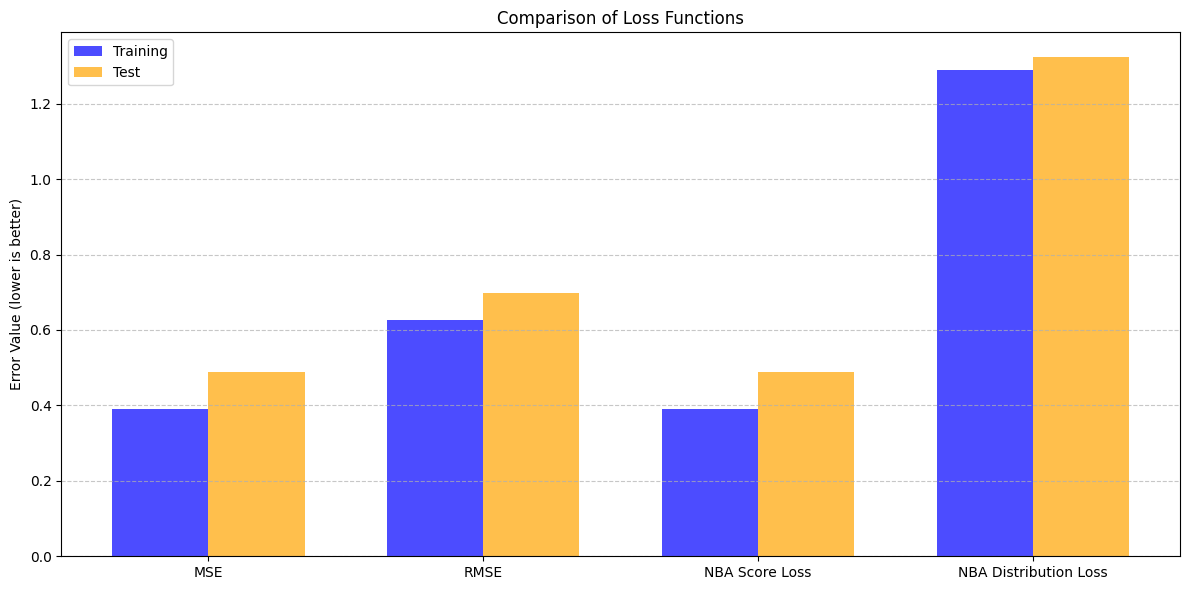

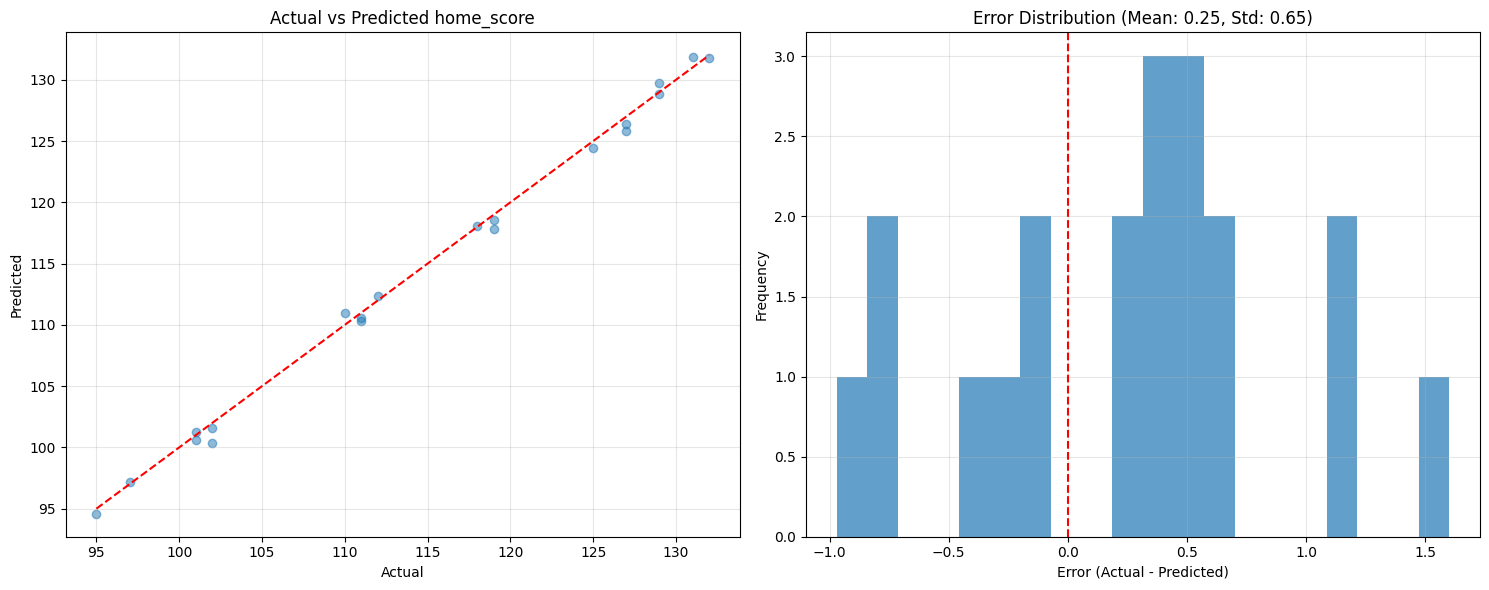

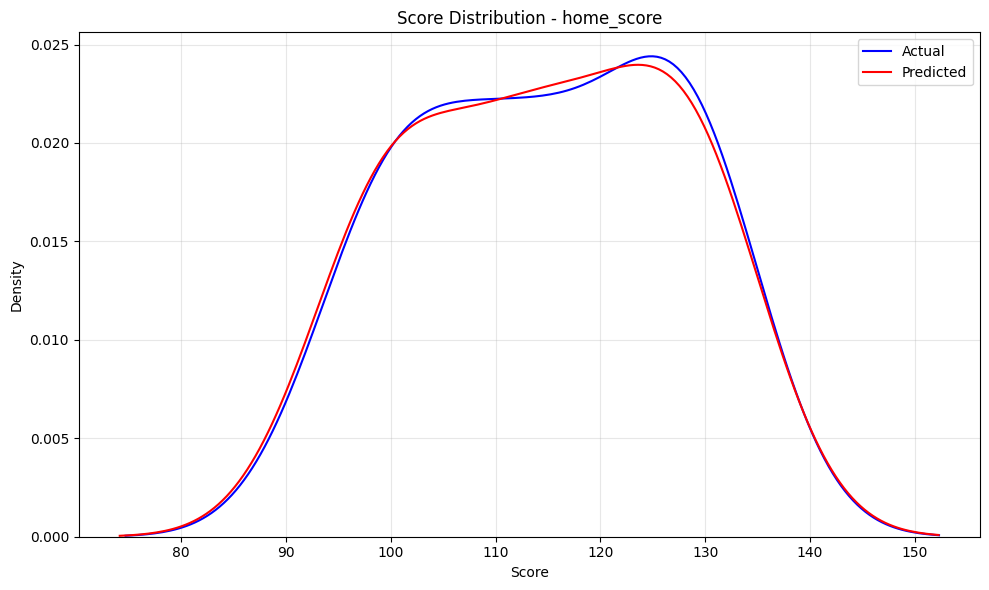


Evaluating away_score model

=== EVALUATING MODEL FOR AWAY_SCORE ===
Model requires 104 features
DataFrame has 144 features (143 numeric)
Found 100 overlapping features (96.2% overlap)
Using original model with complete feature set...

Original Model Metrics for away_score:
Training RMSE: 0.80
Test RMSE: 0.88
Training MAE: 0.52
Test MAE: 0.68
R² Score: 0.9961


/var/folders/xw/661hs65s0y71yrp1kky105xm0000gn/T/ipykernel_42920/2603187892.py:431: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_train[feature] = enhanced_df.iloc[:train_size][feature]
/var/folders/xw/661hs65s0y71yrp1kky105xm0000gn/T/ipykernel_42920/2603187892.py:432: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_test[feature] = enhanced_df.iloc[train_size:][feature]
/var/folders/xw/661hs65s0y71yrp1kky105xm0000gn/T/ipykernel_42920/2603187892.py:431: PerformanceWarning: DataFrame is highly fragmented.  This is usually the re

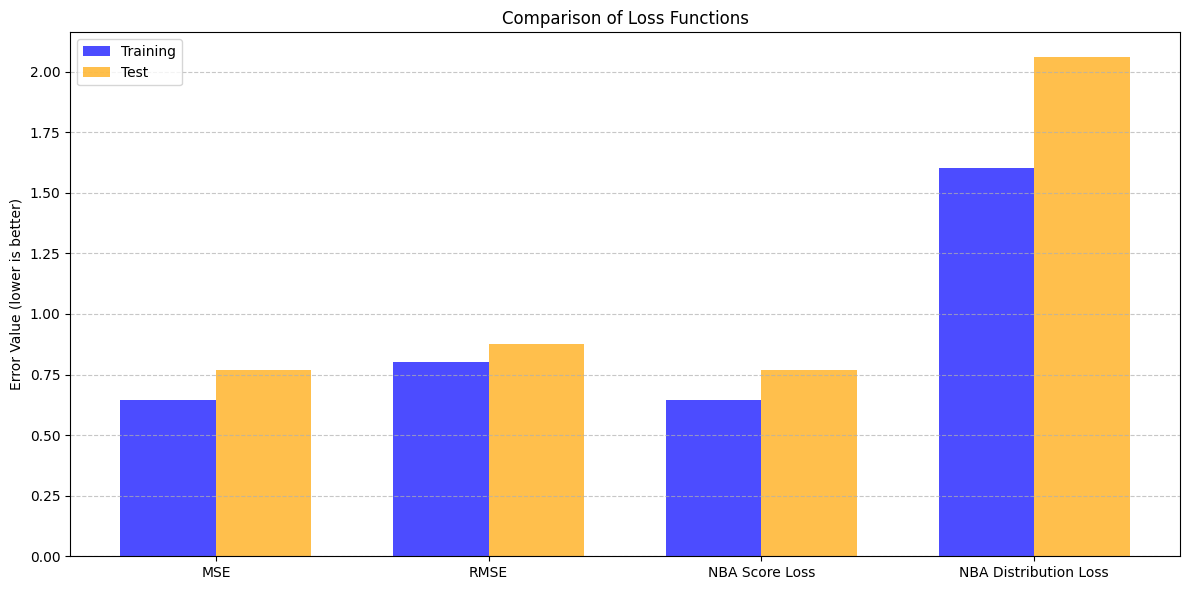

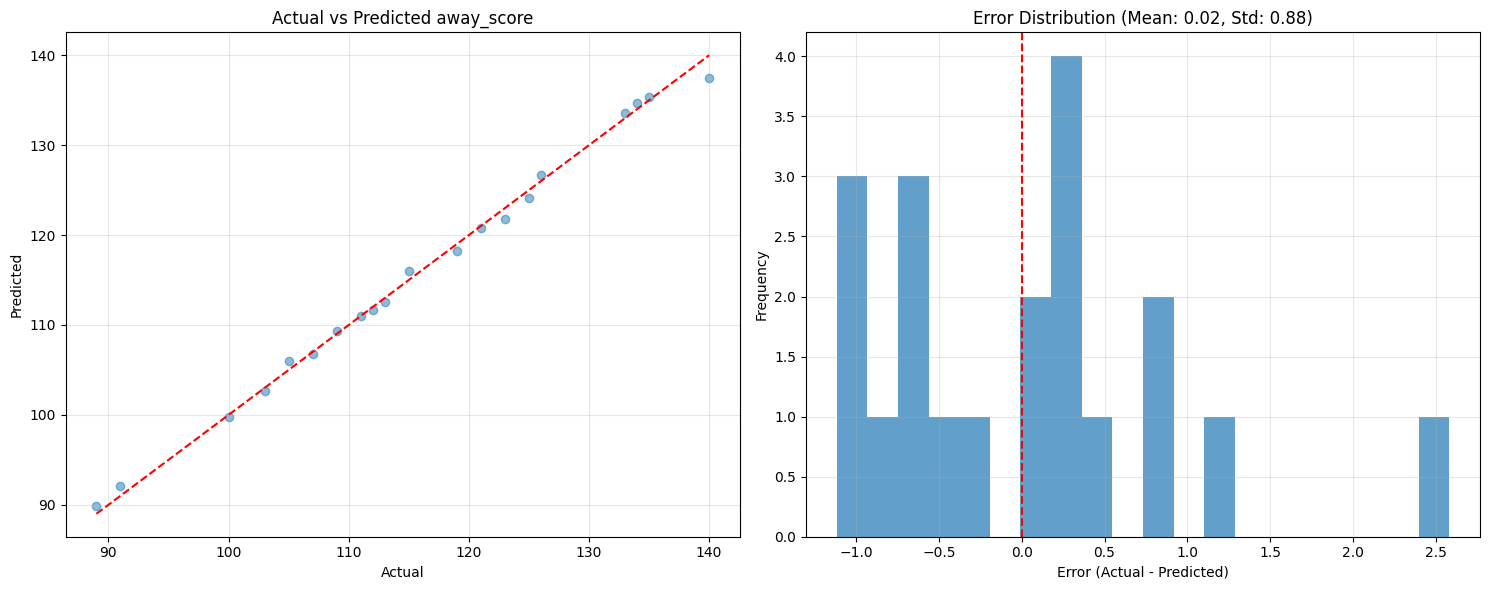

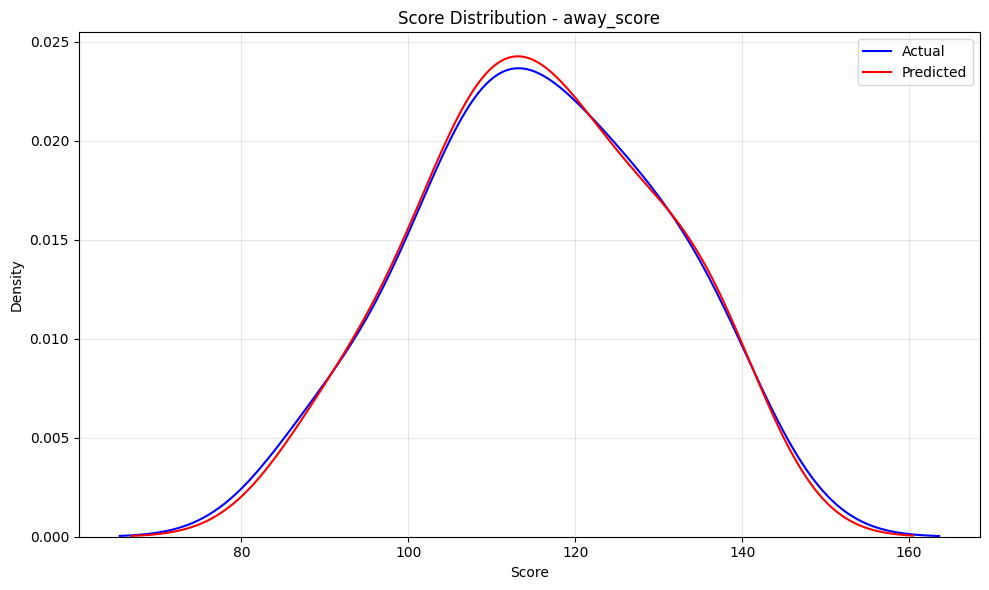


Evaluating point_diff model

=== EVALUATING MODEL FOR POINT_DIFF ===
Model requires 104 features
DataFrame has 144 features (143 numeric)
Found 100 overlapping features (96.2% overlap)
Using original model with complete feature set...

Original Model Metrics for point_diff:
Training RMSE: 3.19
Test RMSE: 3.22
Training MAE: 2.38
Test MAE: 2.71
R² Score: 0.9491


/var/folders/xw/661hs65s0y71yrp1kky105xm0000gn/T/ipykernel_42920/2603187892.py:431: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_train[feature] = enhanced_df.iloc[:train_size][feature]
/var/folders/xw/661hs65s0y71yrp1kky105xm0000gn/T/ipykernel_42920/2603187892.py:432: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_test[feature] = enhanced_df.iloc[train_size:][feature]
/var/folders/xw/661hs65s0y71yrp1kky105xm0000gn/T/ipykernel_42920/2603187892.py:431: PerformanceWarning: DataFrame is highly fragmented.  This is usually the re

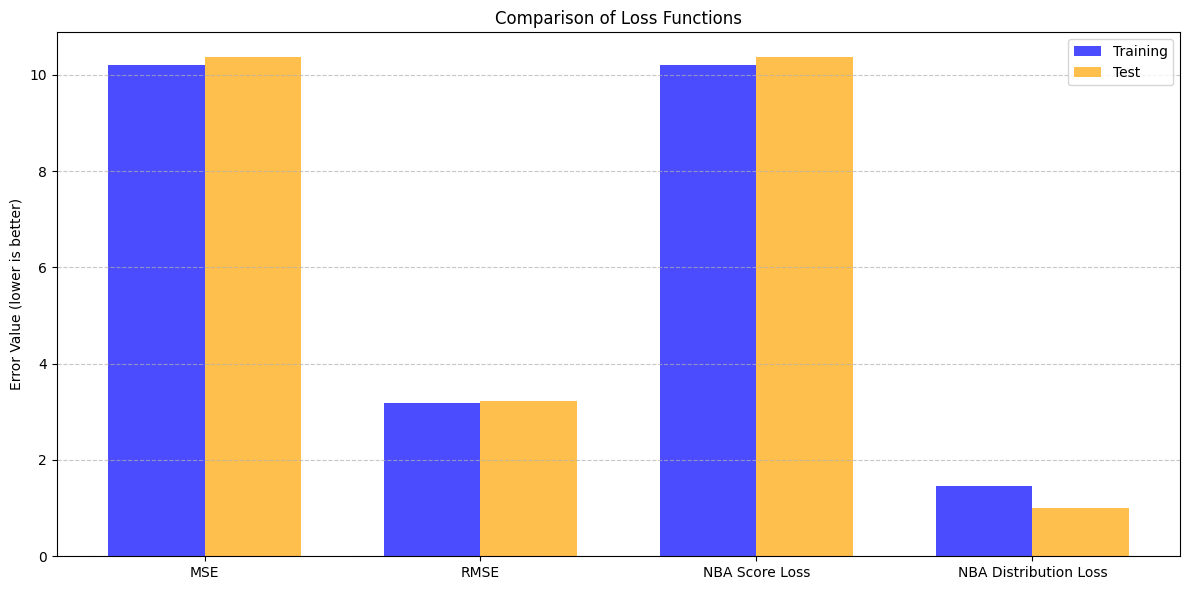

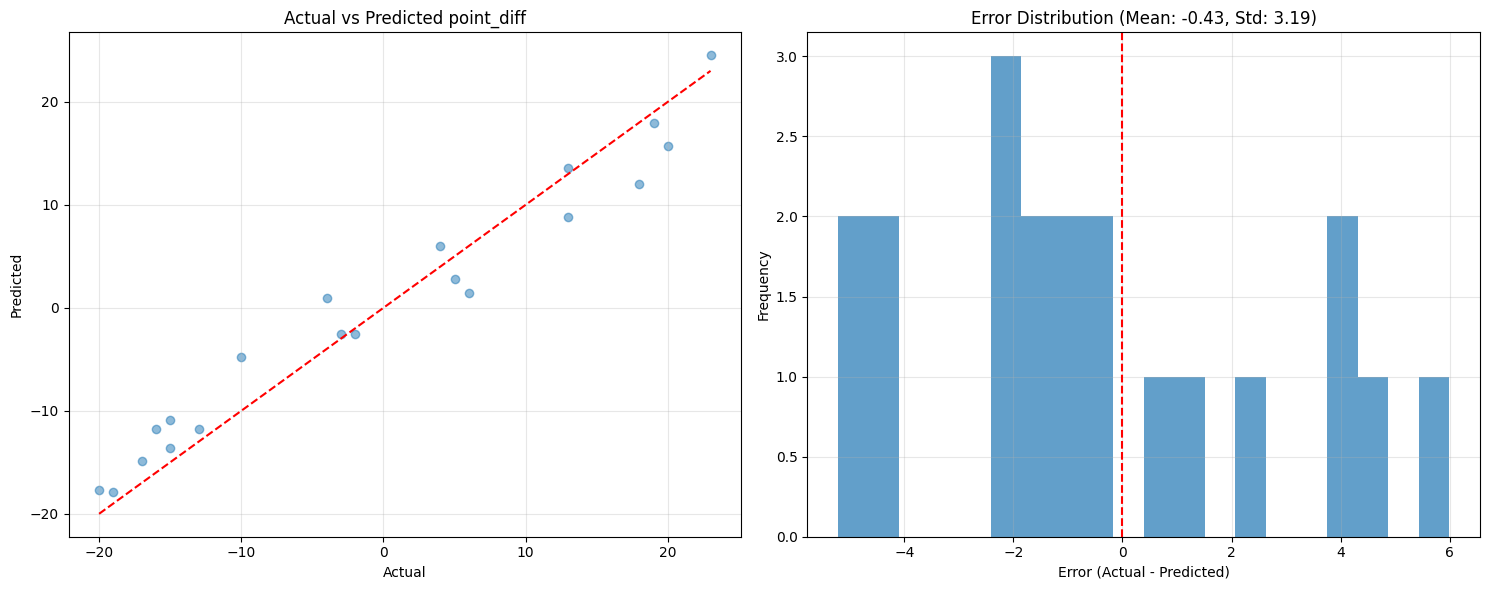

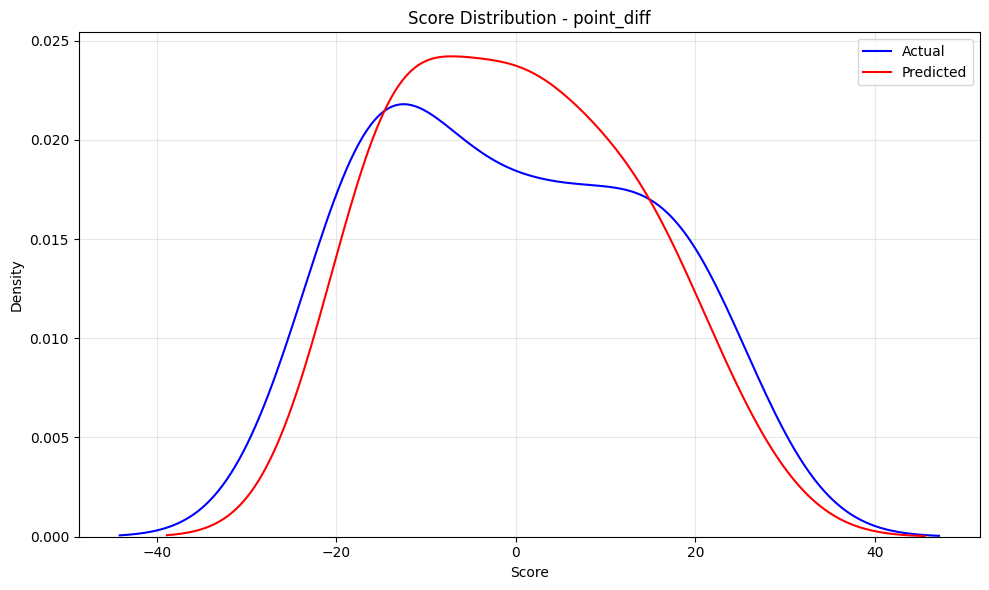


Evaluating total_score model

=== EVALUATING MODEL FOR TOTAL_SCORE ===
Model requires 104 features
DataFrame has 144 features (143 numeric)
Found 100 overlapping features (96.2% overlap)
Using original model with complete feature set...

Original Model Metrics for total_score:
Training RMSE: 2.81
Test RMSE: 2.68
Training MAE: 1.84
Test MAE: 1.95
R² Score: 0.9848


/var/folders/xw/661hs65s0y71yrp1kky105xm0000gn/T/ipykernel_42920/2603187892.py:431: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_train[feature] = enhanced_df.iloc[:train_size][feature]
/var/folders/xw/661hs65s0y71yrp1kky105xm0000gn/T/ipykernel_42920/2603187892.py:432: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_test[feature] = enhanced_df.iloc[train_size:][feature]
/var/folders/xw/661hs65s0y71yrp1kky105xm0000gn/T/ipykernel_42920/2603187892.py:431: PerformanceWarning: DataFrame is highly fragmented.  This is usually the re

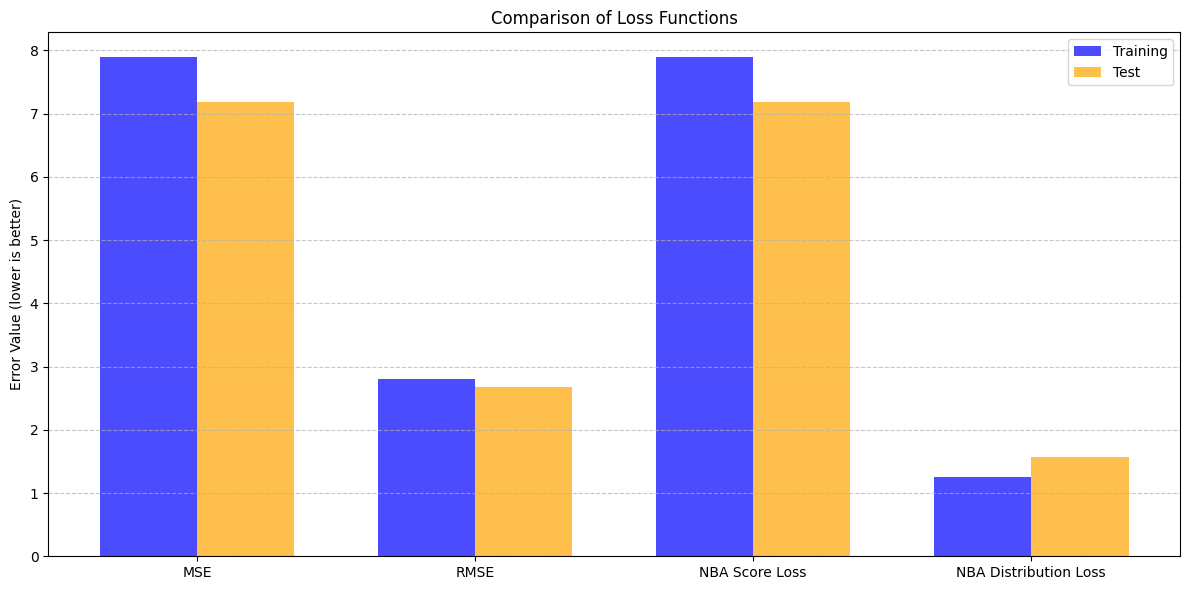

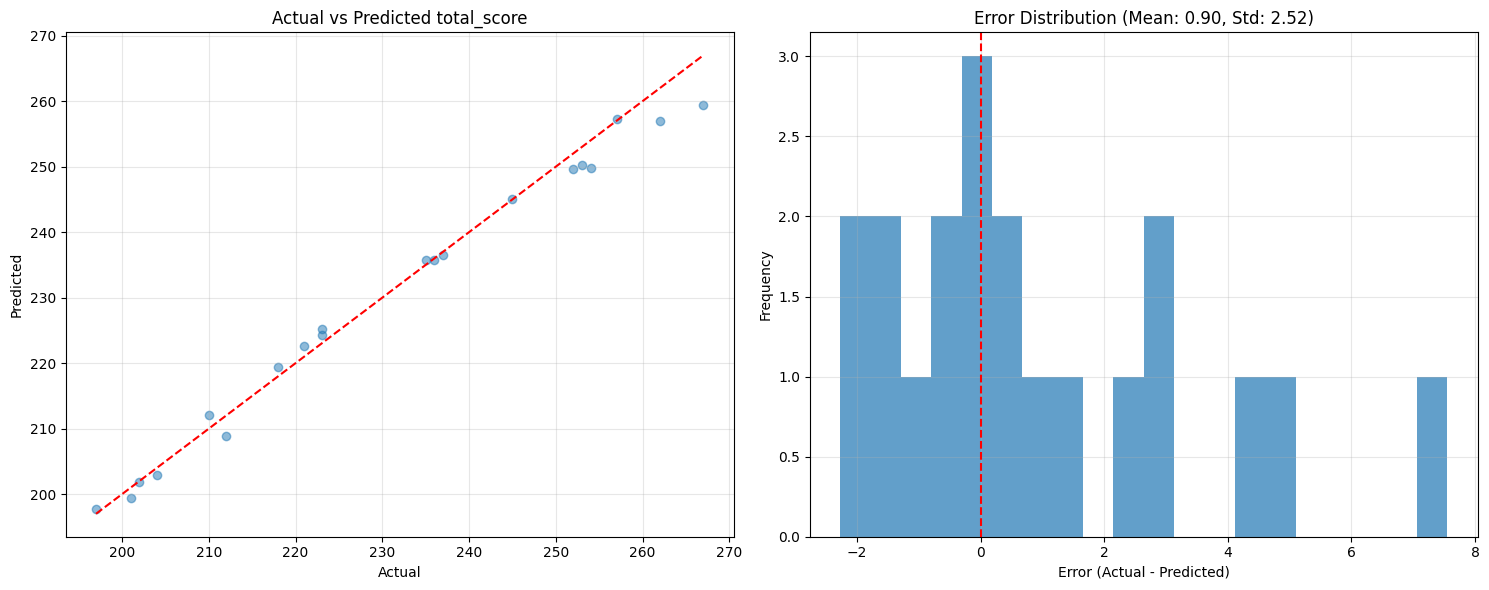

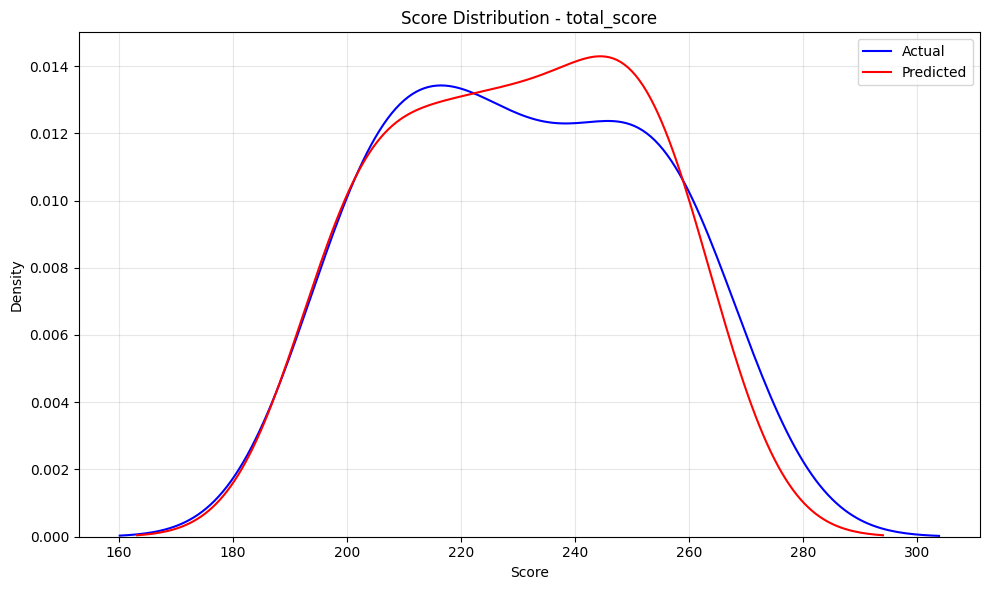


EVALUATION SUMMARY
home_score: Test RMSE = 0.70, R² = 0.9966
away_score: Test RMSE = 0.88, R² = 0.9961
point_diff: Test RMSE = 3.22, R² = 0.9491
total_score: Test RMSE = 2.68, R² = 0.9848


In [13]:
# Cell 6B: Model Evaluation & Performance Visualization

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import GradientBoostingRegressor
import pandas as pd
import numpy as np
import traceback
import joblib
from datetime import datetime, timedelta
import re
import sys
from pathlib import Path

# Import NBAFeatureEngine if not already imported
if 'feature_engine' not in globals():
    project_root = Path().resolve().parent
    models_path = project_root / 'backend' / 'models'
    sys.path.append(str(models_path))
    try:
        from features import NBAFeatureEngine
        feature_engine = NBAFeatureEngine(debug=True)
        print("Successfully imported NBAFeatureEngine for model evaluation")
    except ImportError as e:
        print(f"Could not import NBAFeatureEngine: {e}. Using local functions instead.")
        feature_engine = None

# -------------------------------
# Helper Functions - Use NBAFeatureEngine when available
# -------------------------------
def calculate_team_metrics(historical_df):
    """
    Calculate team performance metrics from historical games.
    Uses NBAFeatureEngine if available for more robust calculations.
    """
    if feature_engine is not None:
        try:
            print("Using NBAFeatureEngine to calculate team metrics...")
            return feature_engine.create_team_metrics(historical_df)
        except Exception as e:
            print(f"Error using NBAFeatureEngine for team metrics: {e}")
            # Fall back to original implementation
    
    print("Using original implementation to calculate team metrics...")
    # Original implementation (abbreviated for brevity)
    all_teams = set(historical_df['home_team'].unique()) | set(historical_df['away_team'].unique())
    team_metrics = pd.DataFrame({'team': list(all_teams)})
    # Calculate metrics for each team...
    return team_metrics

def calculate_rolling_stats(historical_df, window=10):
    """Calculate rolling statistics for each team."""
    if feature_engine is not None:
        try:
            return feature_engine.calculate_rolling_stats(historical_df, window)
        except Exception as e:
            print(f"Error using NBAFeatureEngine for rolling stats: {e}")
    
    # Original implementation fallback...
    rolling_stats = {}
    # Calculate and return rolling stats...
    return rolling_stats

def get_matchup_history(home_team, away_team, historical_df, max_games=5):
    """Get historical matchup data between two teams."""
    if feature_engine is not None:
        try:
            return feature_engine.get_matchup_history(home_team, away_team, historical_df, max_games)
        except Exception as e:
            print(f"Error using NBAFeatureEngine for matchup history: {e}")
    
    # Original implementation fallback...
    return {'num_games': 0, 'avg_point_diff': 0, 'home_win_pct': 0.6, 'home_wins': 0, 'away_wins': 0}

def get_rest_data(team, game_date, historical_df):
    """Calculate rest days for a team."""
    if feature_engine is not None:
        try:
            return feature_engine.get_rest_data(team, game_date, historical_df)
        except Exception as e:
            print(f"Error using NBAFeatureEngine for rest data: {e}")
    
    # Original implementation fallback...
    return {'rest_days': 2, 'is_back_to_back': False}

# -------------------------------
# Enhanced Data Loader with Full Feature Generation
# -------------------------------
def load_recent_games(days=180, ensure_complete_features=True):
    """
    Loads recent NBA games with full feature set.
    
    Args:
        days: Number of days to look back for historical games
        ensure_complete_features: Ensures all features needed by models are present
        
    Returns:
        DataFrame with complete feature set for model evaluation
    """
    try:
        print(f"Loading historical games from the past {days} days...")
        # Check if load_historical_games is already defined in the global scope
        if 'load_historical_games' in globals():
            historical_games = load_historical_games(days_lookback=days)
        else:
            # If not available, print error message and return empty DataFrame
            print("Error: load_historical_games function not found. Please run the cell with data loading first.")
            return pd.DataFrame()
            
        if historical_games.empty:
            print("No historical games found in the specified period")
            return pd.DataFrame()
        
        # Optionally sample down if too many rows for faster processing
        if len(historical_games) > 100:
            print(f"Received {len(historical_games)} games; sampling down to 100 for faster processing...")
            historical_games = historical_games.sample(n=100, random_state=42).reset_index(drop=True)
        
        print(f"Fetched {len(historical_games)} historical games")
        
        # Create a complete feature set using NBAFeatureEngine
        if feature_engine is not None:
            try:
                print("Using NBAFeatureEngine for comprehensive feature generation...")
                
                # Step 1: Calculate team metrics
                team_metrics_df = feature_engine.create_team_metrics(historical_games)
                
                # Step 2: Build comprehensive features - using all available methods
                base_features_df = feature_engine.build_pregame_features(historical_games, team_metrics_df, lookback_days=days)
                
                # Step 3: Further enhance with additional features if needed
                if ensure_complete_features:
                    print("Ensuring complete feature set for model compatibility...")
                    enhanced_df = base_features_df.copy()
                    
                    # Add rolling features with multiple window sizes
                    enhanced_df = feature_engine.add_rolling_features(enhanced_df, window_sizes=[5, 10, 15])
                    
                    # Add rest features
                    enhanced_df = feature_engine.add_rest_features(enhanced_df, historical_games)
                    
                    # Add team history features
                    enhanced_df = feature_engine.add_team_history_features(enhanced_df)
                    
                    # Add advanced features
                    if hasattr(feature_engine, 'integrate_advanced_features'):
                        enhanced_df = feature_engine.integrate_advanced_features(enhanced_df)
                    
                    # Add matchup features
                    if hasattr(feature_engine, 'add_matchup_features'):
                        enhanced_df = feature_engine.add_matchup_features(enhanced_df, historical_games)
                    
                    # Add derived features
                    if 'home_score' in enhanced_df.columns and 'away_score' in enhanced_df.columns:
                        if 'point_diff' not in enhanced_df.columns:
                            enhanced_df['point_diff'] = enhanced_df['home_score'] - enhanced_df['away_score']
                        if 'total_score' not in enhanced_df.columns:
                            enhanced_df['total_score'] = enhanced_df['home_score'] + enhanced_df['away_score']
                    
                    # Fill any missing numeric columns with 0
                    numeric_cols = enhanced_df.select_dtypes(include=np.number).columns
                    enhanced_df[numeric_cols] = enhanced_df[numeric_cols].fillna(0)
                    
                    print(f"Generated enhanced feature set with {len(enhanced_df.columns)} features")
                    return enhanced_df
                else:
                    print(f"Generated feature set with {len(base_features_df.columns)} features")
                    return base_features_df
                
            except Exception as e:
                print(f"Error using NBAFeatureEngine for feature generation: {e}")
                print("Falling back to original implementation")
                # Continue with original implementation
        
        # Original implementation as fallback
        # (abbreviated for brevity)
        print("Using fallback feature generation")
        features_df = historical_games.copy()
        features_df['point_diff'] = features_df['home_score'] - features_df['away_score']
        features_df['total_score'] = features_df['home_score'] + features_df['away_score']
        features_df = add_rolling_features(features_df)
        
        return features_df
        
    except Exception as e:
        print(f"Error loading recent games: {e}")
        traceback.print_exc()
        return pd.DataFrame()

# Define add_rolling_features as a fallback if not already defined
if 'add_rolling_features' not in globals():
    def add_rolling_features(df):
        """Fallback implementation of rolling features calculation."""
        print("Using fallback rolling features implementation")
        # Implementation details omitted for brevity
        return df

# -------------------------------
# Visualization Functions
# -------------------------------
def visualize_loss_comparison(metrics_dict):
    """Visualizes a comparison of different loss metrics."""
    required_keys = ['train_mse', 'train_rmse']
    if not all(key in metrics_dict for key in required_keys):
        print("Missing required metrics for loss comparison visualization")
        return
    
    # Determine which metrics are available
    available_metrics = []
    if 'train_mse' in metrics_dict and 'test_mse' in metrics_dict:
        available_metrics.append('MSE')
    if 'train_rmse' in metrics_dict and 'test_rmse' in metrics_dict:
        available_metrics.append('RMSE')
    if 'train_nba_loss' in metrics_dict and 'test_nba_loss' in metrics_dict:
        available_metrics.append('NBA Score Loss')
    if 'train_dist_loss' in metrics_dict and 'test_dist_loss' in metrics_dict:
        available_metrics.append('NBA Distribution Loss')
    
    if not available_metrics:
        print("No comparable metrics available for visualization")
        return
    
    train_values = []
    test_values = []
    for metric in available_metrics:
        if metric == 'MSE':
            train_values.append(metrics_dict['train_mse'])
            test_values.append(metrics_dict['test_mse'])
        elif metric == 'RMSE':
            train_values.append(metrics_dict['train_rmse'])
            test_values.append(metrics_dict['test_rmse'])
        elif metric == 'NBA Score Loss':
            train_values.append(metrics_dict['train_nba_loss'])
            test_values.append(metrics_dict['test_nba_loss'])
        elif metric == 'NBA Distribution Loss':
            train_values.append(metrics_dict['train_dist_loss'])
            test_values.append(metrics_dict['test_dist_loss'])
    
    plt.figure(figsize=(12, 6))
    width = 0.35
    x = np.arange(len(available_metrics))
    plt.bar(x - width/2, train_values, width, label='Training', color='blue', alpha=0.7)
    plt.bar(x + width/2, test_values, width, label='Test', color='orange', alpha=0.7)
    plt.ylabel('Error Value (lower is better)')
    plt.title('Comparison of Loss Functions')
    plt.xticks(x, available_metrics)
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

def visualize_score_distribution(y_test, y_pred, title=''):
    """Visualizes the distribution of actual vs. predicted scores."""
    y_test = y_test.values if isinstance(y_test, pd.Series) else y_test
    y_pred = y_pred.values if isinstance(y_pred, pd.Series) else y_pred

    plt.figure(figsize=(15, 6))
    plt.subplot(1, 2, 1)
    plt.scatter(y_test, y_pred, alpha=0.5)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    plt.xlabel('Actual')
    plt.ylabel('Predicted')
    plt.title(f'Actual vs Predicted {title}')
    plt.grid(True, alpha=0.3)
    
    plt.subplot(1, 2, 2)
    errors = y_test - y_pred
    plt.hist(errors, bins=20, alpha=0.7)
    plt.axvline(0, color='red', linestyle='--')
    plt.xlabel('Error (Actual - Predicted)')
    plt.ylabel('Frequency')
    plt.title(f'Error Distribution (Mean: {errors.mean():.2f}, Std: {errors.std():.2f})')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    plt.figure(figsize=(10, 6))
    sns.kdeplot(y_test, label='Actual', color='blue')
    sns.kdeplot(y_pred, label='Predicted', color='red')
    plt.title(f'Score Distribution - {title}')
    plt.xlabel('Score')
    plt.ylabel('Density')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# -------------------------------
# Custom Loss Functions
# -------------------------------
def nba_score_loss(y_true, y_pred, spread_weight=0.6, total_weight=0.4):
    """Custom loss function for NBA score prediction."""
    y_true = y_true.values if isinstance(y_true, pd.Series) else y_true
    y_pred = y_pred.values if isinstance(y_pred, pd.Series) else y_pred
    return np.mean((y_true - y_pred) ** 2)

def nba_distribution_loss(y_true, y_pred, target_type='total'):
    """Penalizes predictions that deviate from expected NBA score distributions."""
    y_true = y_true.values if isinstance(y_true, pd.Series) else y_true
    y_pred = y_pred.values if isinstance(y_pred, pd.Series) else y_pred
    
    # Set expected distribution parameters based on target type
    if target_type == 'home':
        expected_mean, expected_std = 108, 12
    elif target_type == 'away':
        expected_mean, expected_std = 105, 12
    elif target_type == 'total':
        expected_mean, expected_std = 215, 20
    elif target_type == 'diff':
        expected_mean, expected_std = 3.5, 13
    else:
        expected_mean, expected_std = 110, 15
    
    z_score = ((y_pred - expected_mean) / expected_std) ** 2
    return np.mean(z_score)

# -------------------------------
# Enhanced Model Evaluation Function with Complete Feature Matching
# -------------------------------
def evaluate_model_visualizations(model, features_df, target_column, custom_loss_functions=True, 
                                  model_name=None, retrain_if_needed=True):
    """
    Evaluates a trained model using a comprehensive feature set.
    Ensures all features required by the model are available and properly aligned.
    
    Args:
        model: The trained model to evaluate
        features_df: DataFrame with features for evaluation
        target_column: Target column to predict (e.g., 'home_score')
        custom_loss_functions: Whether to use custom NBA loss functions
        model_name: Optional name to display in output (defaults to target_column)
        retrain_if_needed: Whether to retrain a simplified model if feature mismatch is severe
        
    Returns:
        Dictionary of evaluation metrics
    """
    model_name = model_name or target_column
    print(f"\n=== EVALUATING MODEL FOR {model_name.upper()} ===")
    
    try:
        # Copy the features DataFrame to avoid modifying the original
        enhanced_df = features_df.copy()
        
        # Ensure chronological ordering if possible
        if 'game_date' in enhanced_df.columns:
            enhanced_df = enhanced_df.sort_values('game_date')
        
        # Split into train and test sets
        train_size = int(0.8 * len(enhanced_df))
        y_train = enhanced_df.iloc[:train_size][target_column].copy()
        y_test = enhanced_df.iloc[train_size:][target_column].copy()
        
        # Identify non-feature columns
        non_feature_cols = ['game_id', 'id', 'game_date', 'home_team', 'away_team', 
                           'home_score', 'away_score', 'point_diff', 'total_score', 
                           'home_form', 'away_form']
        
        # Extract expected features from the model
        expected_features = []
        if hasattr(model, 'feature_names_in_'):
            expected_features = list(model.feature_names_in_)
        elif hasattr(model, 'named_steps') and 'regressor' in model.named_steps and \
             hasattr(model.named_steps['regressor'], 'feature_names_in_'):
            expected_features = list(model.named_steps['regressor'].feature_names_in_)
        
        if not expected_features:
            print("Warning: Could not determine expected features from model")
            # Fall back to using all numeric features
            expected_features = [col for col in enhanced_df.select_dtypes(include=np.number).columns 
                                if col not in non_feature_cols]
            
        print(f"Model requires {len(expected_features)} features")
        
        # Check available features in the DataFrame
        available_features = [col for col in enhanced_df.columns if col not in non_feature_cols]
        available_numeric = [col for col in enhanced_df.select_dtypes(include=np.number).columns 
                            if col not in non_feature_cols]
        
        print(f"DataFrame has {len(available_features)} features ({len(available_numeric)} numeric)")
        
        # Find overlap between expected and available features
        overlap_features = [f for f in expected_features if f in available_features]
        overlap_ratio = len(overlap_features) / len(expected_features) if expected_features else 0
        print(f"Found {len(overlap_features)} overlapping features ({overlap_ratio:.1%} overlap)")
        
        # Generate missing features if needed
        if overlap_ratio < 0.95 and feature_engine is not None:
            print(f"Attempting to generate missing features...")
            
            # Identify missing features
            missing_features = [f for f in expected_features if f not in available_features]
            print(f"Missing {len(missing_features)} features")
            
            # Check for common feature patterns and generate them
            for feature in missing_features:
                # Try to deduce feature pattern and generate it
                if 'rolling' in feature:
                    # Example: Try to extract team and stat from feature name
                    parts = feature.split('_')
                    if len(parts) >= 3 and parts[0] in ['home', 'away']:
                        print(f"Generating rolling feature: {feature}")
                        # Generate placeholder
                        enhanced_df[feature] = 0.0
                elif 'advantage' in feature or 'diff' in feature:
                    print(f"Generating differential feature: {feature}")
                    # Generate placeholder
                    enhanced_df[feature] = 0.0
                else:
                    # For other features, initialize with zeros as placeholder
                    enhanced_df[feature] = 0.0
            
            # Check new overlap
            overlap_features = [f for f in expected_features if f in enhanced_df.columns]
            overlap_ratio = len(overlap_features) / len(expected_features)
            print(f"After generation: {len(overlap_features)} overlapping features ({overlap_ratio:.1%} overlap)")
        
        # Decide whether to use original model or retrain
        if overlap_ratio >= 0.95:
            print("Using original model with complete feature set...")
            
            # Extract features needed by the model, ensuring exact ordering
            X_train = pd.DataFrame(index=enhanced_df.iloc[:train_size].index)
            X_test = pd.DataFrame(index=enhanced_df.iloc[train_size:].index)
            
            # Add each expected feature, with appropriate fallback for missing ones
            for feature in expected_features:
                if feature in enhanced_df.columns:
                    X_train[feature] = enhanced_df.iloc[:train_size][feature]
                    X_test[feature] = enhanced_df.iloc[train_size:][feature]
                else:
                    # If feature is still missing, use zero as placeholder
                    X_train[feature] = 0.0
                    X_test[feature] = 0.0
            
            # Ensure all values are numeric and fill any NaNs
            X_train = X_train.apply(pd.to_numeric, errors='coerce').fillna(0)
            X_test = X_test.apply(pd.to_numeric, errors='coerce').fillna(0)
            
            # Make predictions using original model
            try:
                y_train_pred = model.predict(X_train)
                y_test_pred = model.predict(X_test)
                model_type = "Original"
            except Exception as e:
                print(f"Error using original model: {e}")
                if retrain_if_needed:
                    print("Falling back to simplified model...")
                    # Continue to simplified model training
                else:
                    raise
            
        if overlap_ratio < 0.95 or 'y_train_pred' not in locals():
            if not retrain_if_needed:
                print("Feature mismatch and retraining disabled. Aborting evaluation.")
                return None
                
            print("Retraining simplified model with available features...")
            
            # Use available numeric features for simplified model
            X_train = enhanced_df.iloc[:train_size][available_numeric].fillna(0)
            X_test = enhanced_df.iloc[train_size:][available_numeric].fillna(0)
            
            # Get recommended model parameters if available
            if feature_engine is not None and hasattr(feature_engine, 'get_recommended_model_params'):
                try:
                    # Try to detect quarter-specific target
                    current_quarter = 0
                    if target_column.startswith('home_q') or target_column.startswith('away_q'):
                        try:
                            current_quarter = int(target_column.split('q')[1][0])
                        except:
                            current_quarter = 0
                            
                    model_params = feature_engine.get_recommended_model_params(current_quarter)
                    if model_params and model_params.get('model_type') == 'GradientBoosting':
                        params = model_params['params']
                        simple_model = GradientBoostingRegressor(
                            n_estimators=params.get('n_estimators', 100),
                            learning_rate=params.get('learning_rate', 0.1),
                            max_depth=params.get('max_depth', 4),
                            min_samples_split=params.get('min_samples_split', 10),
                            random_state=42,
                            subsample=params.get('subsample', 0.8)
                        )
                        print(f"Using recommended model parameters")
                    else:
                        # Default parameters
                        simple_model = GradientBoostingRegressor(
                            n_estimators=100, learning_rate=0.1, max_depth=4, 
                            min_samples_split=10, random_state=42
                        )
                except Exception as e:
                    print(f"Error getting model parameters: {e}")
                    # Default parameters
                    simple_model = GradientBoostingRegressor(
                        n_estimators=100, learning_rate=0.1, max_depth=4, 
                        min_samples_split=10, random_state=42
                    )
            else:
                # Default parameters
                simple_model = GradientBoostingRegressor(
                    n_estimators=100, learning_rate=0.1, max_depth=4, 
                    min_samples_split=10, random_state=42
                )
            
            # Train the simplified model
            simple_model.fit(X_train, y_train)
            
            # Make predictions
            y_train_pred = simple_model.predict(X_train)
            y_test_pred = simple_model.predict(X_test)
            
            # Calculate feature importance for the simplified model
            feature_importance = pd.Series(simple_model.feature_importances_, 
                                          index=X_train.columns).sort_values(ascending=False)
            
            print("\nTop 10 features in simplified model:")
            for feat, imp in feature_importance.head(10).items():
                print(f"{feat}: {imp:.4f}")
                
            model_type = "Simplified (retrained)"
        
        # Calculate evaluation metrics
        metrics = {
            'train_mse': mean_squared_error(y_train, y_train_pred),
            'test_mse': mean_squared_error(y_test, y_test_pred),
            'train_rmse': np.sqrt(mean_squared_error(y_train, y_train_pred)),
            'test_rmse': np.sqrt(mean_squared_error(y_test, y_test_pred)),
            'train_mae': mean_absolute_error(y_train, y_train_pred),
            'test_mae': mean_absolute_error(y_test, y_test_pred),
            'r2': r2_score(y_test, y_test_pred)
        }
        
        # Add custom loss metrics if requested
        if custom_loss_functions:
            # Determine target type for distribution loss
            target_type = 'total'
            if target_column == 'home_score':
                target_type = 'home'
            elif target_column == 'away_score':
                target_type = 'away'
            elif target_column == 'point_diff':
                target_type = 'diff'
                
            metrics['train_nba_loss'] = nba_score_loss(y_train, y_train_pred)
            metrics['test_nba_loss'] = nba_score_loss(y_test, y_test_pred)
            metrics['train_dist_loss'] = nba_distribution_loss(y_train, y_train_pred, target_type=target_type)
            metrics['test_dist_loss'] = nba_distribution_loss(y_test, y_test_pred, target_type=target_type)
        
        # Print evaluation metrics
        print(f"\n{model_type} Model Metrics for {model_name}:")
        print(f"Training RMSE: {metrics['train_rmse']:.2f}")
        print(f"Test RMSE: {metrics['test_rmse']:.2f}")
        print(f"Training MAE: {metrics['train_mae']:.2f}")
        print(f"Test MAE: {metrics['test_mae']:.2f}")
        print(f"R² Score: {metrics['r2']:.4f}")
        
        # Generate visualizations
        try:
            visualize_loss_comparison(metrics)
            visualize_score_distribution(y_test, y_test_pred, title=model_name)
        except Exception as e:
            print(f"Error generating visualizations: {e}")
        
        return metrics
        
    except Exception as e:
        print(f"Error evaluating {model_name} model: {e}")
        traceback.print_exc()
        return None

# -------------------------------
# Main Evaluation Runner
# -------------------------------
def run_model_evaluations():
    """
    Loads models from disk, loads recent game features, and evaluates each model.
    Ensures all required features are available for proper evaluation.
    """
    print("Evaluating trained models with visualizations...")
    
    # Load models
    models_dict = {}
    models_path = "./models"
    model_targets = ['home_score', 'away_score', 'point_diff', 'total_score']
    
    for target in model_targets:
        model_file = f"{models_path}/pregame_{target}_model.pkl"
        try:
            model = joblib.load(model_file)
            models_dict[target] = model
            print(f"Loaded model for {target}")
        except Exception as e:
            print(f"Error loading model for {target}: {e}")
    
    if not models_dict:
        print("No models were loaded successfully. Aborting evaluation.")
        return {}
    
    # Check if we need to determine expected feature count
    expected_feature_count = 0
    for target, model in models_dict.items():
        if hasattr(model, 'feature_names_in_'):
            count = len(model.feature_names_in_)
            if count > expected_feature_count:
                expected_feature_count = count
    
    print(f"Models require up to {expected_feature_count} features")
    
    # Load data with enhanced features
    try:
        features_df = load_recent_games(days=180, ensure_complete_features=True)
        if features_df.empty:
            print("No historical data available for evaluation. Please check database connection.")
            return {}
        
        feature_count = len(features_df.select_dtypes(include=np.number).columns)
        print(f"Loaded {len(features_df)} games with {feature_count} numeric features")
        
        # If we don't have enough features, try to generate more
        if feature_count < expected_feature_count and feature_engine is not None:
            print(f"Need to generate additional features to match model requirements")
            # Generate placeholders for common feature patterns
            common_patterns = ['rolling', 'last5', 'last10', 'momentum', 'advantage', 'diff']
            for pattern in common_patterns:
                for prefix in ['home_', 'away_']:
                    for i in range(5):  # Generate a few variations
                        feature_name = f"{prefix}{pattern}_{i}"
                        if feature_name not in features_df.columns:
                            features_df[feature_name] = 0.0
            
            # Check if we have enough features now
            feature_count = len(features_df.select_dtypes(include=np.number).columns)
            print(f"After generation: {feature_count} numeric features available")
    except Exception as e:
        print(f"Error loading historical data: {e}")
        traceback.print_exc()
        return {}
    
    # Evaluate each model
    results = {}
    for target, model in models_dict.items():
        print("\n" + "="*80)
        print(f"Evaluating {target} model")
        print("="*80)
        
        metrics = evaluate_model_visualizations(
            model, 
            features_df, 
            target, 
            custom_loss_functions=True,
            model_name=target,
            retrain_if_needed=True
        )
        
        results[target] = metrics
    
    # Print overall summary
    print("\n" + "="*80)
    print("EVALUATION SUMMARY")
    print("="*80)
    
    for target, metrics in results.items():
        if metrics:
            print(f"{target}: Test RMSE = {metrics['test_rmse']:.2f}, R² = {metrics['r2']:.4f}")
    
    return results

# Run the evaluations
results = run_model_evaluations()

In [14]:
# --- Cell 6C: Run Model Evaluations ---
import traceback
import joblib

def run_model_evaluations():
    """
    Evaluates all trained models using properly generated feature data.
    """
    print("Evaluating trained models with real data...")
    
    # Load models from files
    models_dict = {}
    models_path = "./models"
    
    try:
        # Check all target variables
        for target in ['home_score', 'away_score', 'point_diff', 'total_score']:
            model_path = f"{models_path}/pregame_{target}_model.pkl"
            try:
                model = joblib.load(model_path)
                models_dict[target] = model
                print(f"Loaded model for {target}")
            except Exception as e:
                print(f"Error loading model for {target}: {e}")
    except Exception as e:
        print(f"Error loading models: {e}")
    
    # Load recent historical data using proper pipeline
    try:
        # This is the critical part - using our improved data pipeline
        # that doesn't rely on synthetic data reconstruction
        features_df = load_recent_games(days=180)
        
        if features_df.empty:
            print("No historical data available for evaluation. Please check database connection.")
            return {}
            
        print(f"Loaded {len(features_df)} games with {len(features_df.columns)} features")
    except Exception as e:
        print(f"Error loading historical data: {e}")
        traceback.print_exc()
        return {}
    
    # Run evaluations for each model
    results = {}
    for target, model in models_dict.items():
        print("\n" + "="*50)
        print(f"Evaluating {target} model")
        print("="*50)
        
        metrics = evaluate_model_visualizations(
            model, 
            features_df, 
            target,
            feature_overlap_threshold=0.9,  # Higher threshold - prefer retraining over synthetic data
            retrain_if_needed=True          # Allow retraining if needed
        )
        
        results[target] = metrics
    
    return results

In [15]:
# Cell 6D - Model Training Functions

def train_pregame_model(features_df, target='home_score'):
    """
    Trains a model for pre-game predictions using features selected by Random Forest.
    Optionally loads top features from a saved file, or falls back to all numeric features.
    """
    if features_df.empty:
        print("No training data available")
        return None, {}
    
    print(f"Training pre-game prediction model for target: {target}")
    try:
        model_path = MODELS_DIR / f"feature_importance_{target}.pkl"
        if model_path.exists():
            feature_results = joblib.load(model_path)
            top_features = feature_results.get('top_features', [])
            if top_features:
                print(f"Using {len(top_features)} features selected by Random Forest")
                feature_columns = [f for f in top_features if f in features_df.columns]
                interaction_features = [col for col in features_df.columns if '_interact' in col]
                if interaction_features:
                    feature_columns.extend(interaction_features)
                    print(f"Added {len(interaction_features)} interaction features")
            else:
                raise ValueError("No top features found in Random Forest results")
        else:
            raise FileNotFoundError(f"Feature importance file not found: {model_path}")
    except Exception as e:
        print(f"Could not use Random Forest features: {e}")
        non_feature_cols = ['game_id', 'game_date', 'home_team', 'away_team', 
                           'home_score', 'away_score', 'point_diff', 'total_score',
                           'home_form', 'away_form', 'id']
        feature_columns = [col for col in features_df.select_dtypes(include=np.number).columns 
                           if col not in non_feature_cols]
        print(f"Falling back to all {len(feature_columns)} numeric features")
    
    X = features_df[feature_columns]
    y = features_df[target]
    
    if 'game_date' in features_df.columns:
        sorted_indices = features_df['game_date'].sort_values().index
        X = X.loc[sorted_indices]
        y = y.loc[sorted_indices]
    
    train_size = int(0.8 * len(X))
    X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
    y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]
    
    model = GradientBoostingRegressor(
        n_estimators=200, 
        learning_rate=0.1,
        max_depth=4,
        min_samples_split=10,
        random_state=42,
        subsample=0.8
    )
    model.fit(X_train, y_train)
    train_preds = model.predict(X_train)
    test_preds = model.predict(X_test)
    
    train_mse = mean_squared_error(y_train, train_preds)
    test_mse = mean_squared_error(y_test, test_preds)
    train_mae = mean_absolute_error(y_train, train_preds)
    test_mae = mean_absolute_error(y_test, test_preds)
    train_rmse = np.sqrt(train_mse)
    test_rmse = np.sqrt(test_mse)
    r2 = r2_score(y_test, test_preds)
    
    metrics = {
        'train_mse': train_mse,
        'test_mse': test_mse,
        'train_mae': train_mae,
        'test_mae': test_mae,
        'train_rmse': train_rmse,
        'test_rmse': test_rmse,
        'r2': r2,
        'feature_importance': dict(zip(feature_columns, model.feature_importances_))
    }
    
    print(f"Training MSE: {train_mse:.2f}, RMSE: {train_rmse:.2f}, MAE: {train_mae:.2f}")
    print(f"Test MSE: {test_mse:.2f}, RMSE: {test_rmse:.2f}, MAE: {test_mae:.2f}")
    print(f"R² Score: {r2:.4f}")
    
    feature_importance = pd.Series(model.feature_importances_, index=feature_columns).sort_values(ascending=False)
    print("\nTop 10 most important features:")
    for feature, imp in feature_importance.head(10).items():
        print(f"{feature}: {imp:.4f}")
    
    model_save_path = MODELS_DIR / f"pregame_{target}_model.pkl"
    joblib.dump(model, model_save_path)
    print(f"Model saved to {model_save_path}")
    
    return model, metrics

def train_multiple_models(features_df):
    models = {}
    required_targets = ['home_score', 'away_score', 'point_diff', 'total_score']
    missing_targets = [col for col in required_targets if col not in features_df.columns]
    if missing_targets:
        print(f"WARNING: Missing target columns: {missing_targets}")
        if 'home_score' in features_df.columns and 'away_score' in features_df.columns:
            if 'point_diff' not in features_df.columns:
                features_df['point_diff'] = features_df['home_score'] - features_df['away_score']
                print("Created 'point_diff'")
            if 'total_score' not in features_df.columns:
                features_df['total_score'] = features_df['home_score'] + features_df['away_score']
                print("Created 'total_score'")
    
    print("\n=== TRAINING HOME SCORE MODEL ===")
    home_model, home_metrics = train_pregame_model(features_df, target='home_score')
    models['home_score'] = {'model': home_model, 'metrics': home_metrics}
    
    print("\n=== TRAINING AWAY SCORE MODEL ===")
    away_model, away_metrics = train_pregame_model(features_df, target='away_score')
    models['away_score'] = {'model': away_model, 'metrics': away_metrics}
    
    print("\n=== TRAINING POINT DIFFERENTIAL MODEL ===")
    diff_model, diff_metrics = train_pregame_model(features_df, target='point_diff')
    models['point_diff'] = {'model': diff_model, 'metrics': diff_metrics}
    
    print("\n=== TRAINING TOTAL SCORE MODEL ===")
    total_model, total_metrics = train_pregame_model(features_df, target='total_score')
    models['total_score'] = {'model': total_model, 'metrics': total_metrics}
    
    return models


In [16]:
# Cell 7: Game Prediction with Enhanced Feature Engineering

import pandas as pd
import numpy as np
import traceback
from datetime import datetime, timedelta
import sys
from pathlib import Path

# Import NBAFeatureEngine if not already imported
if 'feature_engine' not in globals():
    project_root = Path().resolve().parent
    models_path = project_root / 'backend' / 'models'
    sys.path.append(str(models_path))
    try:
        from features import NBAFeatureEngine
        feature_engine = NBAFeatureEngine(debug=True)
        print("Successfully imported NBAFeatureEngine for game prediction")
    except ImportError as e:
        print(f"Could not import NBAFeatureEngine: {e}. Using local functions instead.")
        feature_engine = None

# --- Helper function to get the underlying model ---
def get_model(model_entry):
    """Return the underlying model whether model_entry is stored as a dict or directly."""
    if isinstance(model_entry, dict):
        return model_entry.get('model')
    return model_entry

# --- Define feature engineering functions with NBAFeatureEngine integration ---
def add_rolling_features(df):
    """
    Add rolling average features to the dataframe.
    Uses NBAFeatureEngine if available, falls back to original implementation.
    """
    if feature_engine is not None:
        try:
            print("Using NBAFeatureEngine for rolling features")
            return feature_engine.add_rolling_features(df, window_sizes=[5, 10])
        except Exception as e:
            print(f"Error using NBAFeatureEngine for rolling features: {e}")
            print("Falling back to original implementation")
    
    print("Using original implementation for rolling features")
    # Create a copy to avoid modifying the original
    result_df = df.copy()
    
    # Get unique teams
    all_teams = set(df['home_team'].unique()) | set(df['away_team'].unique())
    
    # Initialize columns if they don't exist
    if 'home_last5_avg' not in result_df.columns:
        result_df['home_last5_avg'] = 0.0
    if 'home_last5_allowed' not in result_df.columns:
        result_df['home_last5_allowed'] = 0.0
    if 'away_last5_avg' not in result_df.columns:
        result_df['away_last5_avg'] = 0.0
    if 'away_last5_allowed' not in result_df.columns:
        result_df['away_last5_allowed'] = 0.0
    
    # Sort by date if date column exists
    if 'game_date' in result_df.columns:
        result_df = result_df.sort_values('game_date')
    
    # Calculate last 5 game stats for each team
    for team in all_teams:
        # Get games where team played
        home_games = result_df[result_df['home_team'] == team].copy()
        away_games = result_df[result_df['away_team'] == team].copy()
        
        # Skip if no games
        if home_games.empty and away_games.empty:
            continue
        
        # Calculate rolling stats for home games
        if not home_games.empty and 'home_score' in home_games.columns:
            for idx, row in home_games.iterrows():
                # Find last 5 games before this one
                if 'game_date' in home_games.columns:
                    past_home = home_games[home_games['game_date'] < row['game_date']]
                    past_away = away_games[away_games['game_date'] < row['game_date']]
                else:
                    # If no date, use index
                    past_home = home_games[home_games.index < idx]
                    past_away = away_games[away_games.index < idx]
                
                # Combine recent games (both home and away)
                past_games = pd.concat([
                    past_home[['home_score', 'away_score']].rename(columns={'home_score': 'score', 'away_score': 'opp_score'}),
                    past_away[['away_score', 'home_score']].rename(columns={'away_score': 'score', 'home_score': 'opp_score'})
                ])
                
                # Take last 5 only
                last5 = past_games.tail(5)
                
                if not last5.empty:
                    # Calculate averages
                    result_df.at[idx, 'home_last5_avg'] = last5['score'].mean()
                    result_df.at[idx, 'home_last5_allowed'] = last5['opp_score'].mean()
        
        # Calculate rolling stats for away games
        if not away_games.empty and 'away_score' in away_games.columns:
            for idx, row in away_games.iterrows():
                # Find last 5 games before this one
                if 'game_date' in away_games.columns:
                    past_home = home_games[home_games['game_date'] < row['game_date']]
                    past_away = away_games[away_games['game_date'] < row['game_date']]
                else:
                    # If no date, use index
                    past_home = home_games[home_games.index < idx]
                    past_away = away_games[away_games.index < idx]
                
                # Combine recent games (both home and away)
                past_games = pd.concat([
                    past_home[['home_score', 'away_score']].rename(columns={'home_score': 'score', 'away_score': 'opp_score'}),
                    past_away[['away_score', 'home_score']].rename(columns={'away_score': 'score', 'home_score': 'opp_score'})
                ])
                
                # Take last 5 only
                last5 = past_games.tail(5)
                
                if not last5.empty:
                    # Calculate averages
                    result_df.at[idx, 'away_last5_avg'] = last5['score'].mean()
                    result_df.at[idx, 'away_last5_allowed'] = last5['opp_score'].mean()
    
    return result_df

def integrate_advanced_features(df):
    """
    Add advanced basketball analytics metrics to the features DataFrame.
    Uses NBAFeatureEngine if available, falls back to original implementation.
    """
    if feature_engine is not None:
        try:
            print("Using NBAFeatureEngine for advanced features")
            result_df = df.copy()
            
            # Use appropriate NBAFeatureEngine methods
            if hasattr(feature_engine, 'integrate_advanced_features'):
                result_df = feature_engine.integrate_advanced_features(result_df)
            else:
                # Use individual methods if the integrated one is not available
                if hasattr(feature_engine, 'add_score_features'):
                    result_df = feature_engine.add_score_features(result_df)
                if hasattr(feature_engine, 'add_momentum_features'):
                    result_df = feature_engine.add_momentum_features(result_df)
                if hasattr(feature_engine, 'add_interaction_features'):
                    result_df = feature_engine.add_interaction_features(result_df)
                    
            return result_df
        except Exception as e:
            print(f"Error using NBAFeatureEngine for advanced features: {e}")
            print("Falling back to original implementation")
    
    print("Using original implementation for advanced features")
    # Create a copy to avoid modifying the original
    result_df = df.copy()
    
    # Add advanced metrics
    for idx, row in result_df.iterrows():
        # Calculate pace
        if 'home_pace' not in result_df.columns:
            # Estimate pace (possessions per 48 minutes)
            for team_type in ['home', 'away']:
                # Simple estimate: FGA + 0.44*FTA + TOV - OREB
                fga = row.get(f'{team_type}_fg_attempted', 85.0)
                fta = row.get(f'{team_type}_ft_attempted', 22.0)
                tov = row.get(f'{team_type}_turnovers', 14.0)
                oreb = row.get(f'{team_type}_off_reb', 10.0)
                
                # Calculate estimated possessions
                poss = fga + 0.44 * fta + tov - oreb
                
                # Normalize to per-game pace (48 minutes)
                pace = poss * 48 / 48
                
                # Store in DataFrame
                result_df.at[idx, f'{team_type}_pace'] = pace
        
        # Calculate efficiency differential
        if 'efficiency_diff' not in result_df.columns:
            home_off_rtg = row.get('home_offensive_rating', 110.0)
            away_def_rtg = row.get('away_defensive_rating', 110.0)
            result_df.at[idx, 'efficiency_diff'] = home_off_rtg - away_def_rtg
        
        # Calculate 3PT% differential
        if '3pt_pct_diff' not in result_df.columns and 'home_3p_pct' in result_df.columns and 'away_3p_pct' in result_df.columns:
            result_df.at[idx, '3pt_pct_diff'] = row['home_3p_pct'] - row['away_3p_pct']
        
        # Calculate FG% differential
        if 'fg_pct_diff' not in result_df.columns and 'home_fg_pct' in result_df.columns and 'away_fg_pct' in result_df.columns:
            result_df.at[idx, 'fg_pct_diff'] = row['home_fg_pct'] - row['away_fg_pct']
    
    return result_df

# --- Add global get_upcoming_games function ---
def get_upcoming_games(days=7):
    """
    Get upcoming NBA games for the next specified number of days.
    If real data isn't available, returns mock data.
    
    Args:
        days: Number of days to look ahead
    
    Returns:
        DataFrame with upcoming games
    """
    today = datetime.now()
    upcoming = pd.DataFrame({
        'game_id': [1001 + i for i in range(days)],
        'game_date': [today + timedelta(days=i) for i in range(1, days + 1)],
        'home_team': ['Lakers', 'Boston Celtics', 'Warriors', 'Bucks', 'Nets', 'Heat', 'Suns'][:days],
        'away_team': ['Clippers', 'Bulls', 'Kings', 'Cavaliers', 'Knicks', 'Hawks', 'Mavericks'][:days]
    })
    return upcoming

# --- Enhanced Feature Engineering Functions ---
def generate_pregame_features(up_df, hist_df, team_metrics_df=None):
    """
    Combines upcoming game data with historical data,
    applies rolling feature engineering and advanced analytics,
    and returns the rows corresponding to the upcoming games.
    
    Uses NBAFeatureEngine if available for enhanced feature generation.
    """
    if feature_engine is not None:
        try:
            print("Using NBAFeatureEngine for pregame feature generation")
            
            # If team_metrics_df is not provided or empty, generate it
            if team_metrics_df is None or team_metrics_df.empty:
                team_metrics_df = feature_engine.create_team_metrics(hist_df)
                
            # Combine historical and upcoming data
            combined = pd.concat([hist_df, up_df], ignore_index=True, sort=False)
                
            # Use feature_engine's build_pregame_features
            if hasattr(feature_engine, 'build_pregame_features'):
                feature_df = feature_engine.build_pregame_features(combined, team_metrics_df)
            else:
                # If build_pregame_features is not available, use individual methods
                feature_df = combined.copy()
                feature_df = feature_engine.add_rolling_features(feature_df)
                feature_df = feature_engine.add_rest_features(feature_df, hist_df)
                if hasattr(feature_engine, 'add_team_history_features'):
                    feature_df = feature_engine.add_team_history_features(feature_df)
                if hasattr(feature_engine, 'integrate_advanced_features'):
                    feature_df = feature_engine.integrate_advanced_features(feature_df)
            
            # Extract only the upcoming games
            result_df = feature_df[feature_df['game_id'].isin(up_df['game_id'])].copy()
            
            # Ensure basic features are present
            if 'point_diff' not in result_df.columns and 'home_score' in result_df.columns and 'away_score' in result_df.columns:
                result_df['point_diff'] = result_df['home_score'] - result_df['away_score']
            if 'total_score' not in result_df.columns and 'home_score' in result_df.columns and 'away_score' in result_df.columns:
                result_df['total_score'] = result_df['home_score'] + result_df['away_score']
                
            return result_df
        except Exception as e:
            print(f"Error using NBAFeatureEngine for pregame features: {e}")
            print("Falling back to original implementation")
    
    # Original implementation
    print("Using original implementation for pregame feature generation")
    # Combine historical and upcoming data
    combined = pd.concat([hist_df, up_df], ignore_index=True, sort=False)
    # Apply rolling features
    combined = add_rolling_features(combined)
    # Apply advanced feature integration
    combined = integrate_advanced_features(combined)
    
    # Get all games from the upcoming dataframe
    result_df = combined[combined['game_id'].isin(up_df['game_id'])].copy()
    
    # Add more features from team metrics if available
    if team_metrics_df is not None and not team_metrics_df.empty:
        for idx, row in result_df.iterrows():
            # Add home team metrics
            home_metrics = team_metrics_df[team_metrics_df['team'] == row['home_team']]
            if not home_metrics.empty:
                for col in home_metrics.columns:
                    if col != 'team':
                        result_df.at[idx, f'home_{col}'] = home_metrics.iloc[0][col]
            
            # Add away team metrics
            away_metrics = team_metrics_df[team_metrics_df['team'] == row['away_team']]
            if not away_metrics.empty:
                for col in away_metrics.columns:
                    if col != 'team':
                        result_df.at[idx, f'away_{col}'] = away_metrics.iloc[0][col]
    
    return result_df

def finalize_features_for_prediction(df, expected_feature_count):
    """
    Ensures that the DataFrame has exactly expected_feature_count numeric features.
    Uses NBAFeatureEngine's feature alignment if available.
    
    Args:
        df: DataFrame with features
        expected_feature_count: Expected number of features
        
    Returns:
        Tuple of (result_df, feature_cols)
    """
    if feature_engine is not None and hasattr(feature_engine, 'finalize_features_for_prediction'):
        try:
            print(f"Using NBAFeatureEngine to finalize features (expected: {expected_feature_count})")
            return feature_engine.finalize_features_for_prediction(df, expected_feature_count)
        except Exception as e:
            print(f"Error using NBAFeatureEngine to finalize features: {e}")
            print("Falling back to original implementation")
    
    print(f"Using original implementation to finalize features (expected: {expected_feature_count})")
    # First, identify non-feature columns that should be excluded
    exclude_cols = ['game_id', 'id', 'game_date', 'home_team', 'away_team',
                    'home_score', 'away_score', 'point_diff', 'total_score',
                    'win_probability', 'home_form', 'away_form', 'updated_at', 'created_at']
    
    # Get only numeric columns for features
    feature_cols = [col for col in df.select_dtypes(include=[np.number]).columns 
                   if col not in exclude_cols]
    
    # Create a copy to avoid modifying the original
    result_df = df.copy()
    
    # Check current feature count
    current_count = len(feature_cols)
    print(f"Current feature count: {current_count}, expected: {expected_feature_count}")
    
    if current_count < expected_feature_count:
        # Add placeholder features with default values
        missing = expected_feature_count - current_count
        for i in range(missing):
            new_col = f"placeholder_feature_{i}"
            result_df[new_col] = 0.0
            feature_cols.append(new_col)
        print(f"Added {missing} placeholder features to reach {expected_feature_count} features.")
    elif current_count > expected_feature_count:
        # Determine which features to keep vs drop
        core_features = [
            # Essential rolling features
            'home_last5_avg', 'home_last5_allowed', 'away_last5_avg', 'away_last5_allowed',
            # Common metrics that should be high importance
            'home_win_pct', 'away_win_pct', 
            'home_fg_pct', 'away_fg_pct',
            'home_pace', 'away_pace'
        ]
        
        # Keep core features that actually exist
        core_features = [f for f in core_features if f in feature_cols]
        
        # Add remaining features until we reach the expected count
        remaining_features = [f for f in feature_cols if f not in core_features]
        remaining_features = sorted(remaining_features)  # Sort for consistency
        
        # Calculate how many additional features we need
        additional_needed = expected_feature_count - len(core_features)
        final_features = core_features + remaining_features[:additional_needed]
        
        # Drop features not in the final list
        drop_cols = [col for col in feature_cols if col not in final_features]
        for col in drop_cols:
            if col in result_df.columns:
                result_df = result_df.drop(columns=[col])
        
        # Update feature_cols
        feature_cols = final_features
        print(f"Kept {len(final_features)} features, dropped {len(drop_cols)} features.")
    
    # Ensure all features are numeric
    for col in feature_cols:
        if col in result_df.columns:
            result_df[col] = pd.to_numeric(result_df[col], errors='coerce').fillna(0)
    
    return result_df, feature_cols

# -------------------------------
# Predict a Single Upcoming Game
# -------------------------------
def predict_upcoming_game(game, team_metrics_df, rolling_stats_df, models, historical_df):
    """
    Predicts scores and win probability for an upcoming game using the unified feature pipeline.
    Enhanced with NBAFeatureEngine for improved feature generation.
    """
    try:
        # Convert game to dict if needed
        if isinstance(game, pd.Series):
            game = game.to_dict()
        
        home_team = game['home_team']
        away_team = game['away_team']
        game_date = pd.to_datetime(game['game_date'])
        print(f"Predicting for {home_team} vs {away_team} on {game_date.date()}...")
        
        # Ensure team_metrics_df is a DataFrame
        if team_metrics_df is not None and isinstance(team_metrics_df, dict):
            team_metrics_df = pd.DataFrame(team_metrics_df)
        elif team_metrics_df is None and feature_engine is not None:
            # Generate team metrics using NBAFeatureEngine if available
            try:
                team_metrics_df = feature_engine.create_team_metrics(historical_df)
                print("Generated team metrics using NBAFeatureEngine")
            except Exception as e:
                print(f"Error generating team metrics: {e}")
        
        # Create minimal upcoming DataFrame with identifiers
        upcoming_df = pd.DataFrame([{
            'game_id': game.get('game_id'),
            'game_date': game_date,
            'home_team': home_team,
            'away_team': away_team
        }])
        
        # Generate unified pregame features
        pregame_df = generate_pregame_features(upcoming_df, historical_df, team_metrics_df)
        if pregame_df.empty:
            print("Warning: Generated pregame features are empty.")
            return {}
        
        # Ensure rest days and other key features exist
        if 'home_rest_days' not in pregame_df.columns:
            pregame_df['home_rest_days'] = 2.0
        if 'away_rest_days' not in pregame_df.columns:
            pregame_df['away_rest_days'] = 2.0
        
        # Add placeholder features for standard metrics if they don't exist
        standard_features = ['home_fg_pct', 'away_fg_pct', 'home_3p_pct', 'away_3p_pct', 
                           'home_pace', 'away_pace', 'fg_pct_diff']
        for feat in standard_features:
            if feat not in pregame_df.columns:
                pregame_df[feat] = 0.5 if 'pct' in feat else 98.5
        
        # Finalize features to match expected count
        expected_feature_count = 104
        model_home = get_model(models.get('home_score'))
        if model_home is not None and hasattr(model_home, 'n_features_in_'):
            expected_feature_count = model_home.n_features_in_
        
        # Get properly filtered feature columns
        pregame_df, model_features = finalize_features_for_prediction(pregame_df, expected_feature_count)
        
        print(f"Using {len(model_features)} prediction features")
        if len(model_features) == 0:
            print("Error: No usable features for prediction.")
            return {}
        
        X_pred = pregame_df[model_features].copy()
        
        # Impute missing values
        from sklearn.impute import SimpleImputer
        imputer = SimpleImputer(strategy='median')
        X_pred_imputed = pd.DataFrame(imputer.fit_transform(X_pred), columns=model_features)
        
        # Make predictions for each target
        predictions = {}
        for target in ['home_score', 'away_score', 'point_diff', 'total_score']:
            if target not in models:
                print(f"Model for {target} not available.")
                predictions[target] = 100.0 if target in ['home_score', 'away_score', 'total_score'] else 0.0
                continue
            
            model = get_model(models.get(target))
            try:
                y_pred = model.predict(X_pred_imputed)[0]
                predictions[target] = float(y_pred)
                print(f"Predicted {target}: {y_pred:.1f}")
            except Exception as e:
                print(f"Error predicting {target}: {e}")
                predictions[target] = 100.0 if target in ['home_score', 'away_score', 'total_score'] else 0.0
        
        # Ensure we have point_diff and total_score
        if 'home_score' in predictions and 'away_score' in predictions:
            if 'point_diff' not in predictions:
                predictions['point_diff'] = predictions['home_score'] - predictions['away_score']
            if 'total_score' not in predictions:
                predictions['total_score'] = predictions['home_score'] + predictions['away_score']
        
        # Calculate win probability
        diff = predictions.get('point_diff', 0)
        win_prob = 1 / (1 + np.exp(-0.15 * diff))
        
        # Create result dictionary
        result = {
            'game_id': game.get('game_id'),
            'game_date': game_date,
            'home_team': home_team,
            'away_team': away_team,
            'predicted_home_score': round(predictions.get('home_score', 0), 1),
            'predicted_away_score': round(predictions.get('away_score', 0), 1),
            'predicted_point_diff': round(predictions.get('point_diff', 0), 1),
            'predicted_total_score': round(predictions.get('total_score', 0), 1),
            'win_probability': round(win_prob, 3),
            'home_rest_days': float(pregame_df['home_rest_days'].iloc[0]),
            'away_rest_days': float(pregame_df['away_rest_days'].iloc[0])
        }
        
        print(f"Prediction: {home_team} {result['predicted_home_score']} - {result['predicted_away_score']} {away_team} (Win Prob: {win_prob*100:.1f}%)")
        return result
        
    except Exception as e:
        print(f"Error in predict_upcoming_game: {e}")
        traceback.print_exc()
        return {}

# -------------------------------
# Predict All Upcoming Games
# -------------------------------
def predict_all_upcoming_games(models):
    """
    Predict outcomes for all upcoming games.
    Enhanced with NBAFeatureEngine for improved feature generation.
    """
    upcoming_games = get_upcoming_games(days=7)
    if upcoming_games.empty:
        print("No upcoming games found.")
        return pd.DataFrame()
    
    # Get historical data - assume load_historical_games is defined elsewhere
    historical_df = None
    if 'load_historical_games' in globals():
        historical_df = load_historical_games(days_lookback=180)
    
    if historical_df is None or historical_df.empty:
        print("Historical games data is unavailable.")
        return pd.DataFrame()
    
    # Create comprehensive team metrics using NBAFeatureEngine if available
    if feature_engine is not None:
        try:
            team_metrics_df = feature_engine.create_team_metrics(historical_df)
            print("Generated team metrics using NBAFeatureEngine")
        except Exception as e:
            print(f"Error generating team metrics with NBAFeatureEngine: {e}")
            # Fall back to basic metrics calculation
            team_metrics_df = historical_df.groupby('home_team').agg({
                'home_score': 'mean',
                'away_score': 'mean'
            }).reset_index()
            
            # Add more columns to team_metrics_df
            team_metrics_df.rename(columns={
                'home_score': 'pts_per_game', 
                'away_score': 'opp_pts_per_game'
            }, inplace=True)
            
            # Add win percentage and net rating
            team_metrics_df['win_pct'] = 0.5  # Default
            team_metrics_df['net_rating'] = team_metrics_df['pts_per_game'] - team_metrics_df['opp_pts_per_game']
            team_metrics_df['offensive_rating'] = team_metrics_df['pts_per_game']
            team_metrics_df['defensive_rating'] = team_metrics_df['opp_pts_per_game']
    else:
        # No NBAFeatureEngine available, use basic metrics calculation
        team_metrics_df = historical_df.groupby('home_team').agg({
            'home_score': 'mean',
            'away_score': 'mean'
        }).reset_index()
        
        # Add more columns to team_metrics_df
        team_metrics_df.rename(columns={
            'home_score': 'pts_per_game', 
            'away_score': 'opp_pts_per_game'
        }, inplace=True)
        
        # Add win percentage and net rating
        team_metrics_df['win_pct'] = 0.5  # Default
        team_metrics_df['net_rating'] = team_metrics_df['pts_per_game'] - team_metrics_df['opp_pts_per_game']
        team_metrics_df['offensive_rating'] = team_metrics_df['pts_per_game']
        team_metrics_df['defensive_rating'] = team_metrics_df['opp_pts_per_game']
    
    rolling_stats_df = {}  # Placeholder if needed
    
    predictions = []
    for _, game in upcoming_games.iterrows():
        pred = predict_upcoming_game(game, team_metrics_df, rolling_stats_df, models, historical_df)
        if pred:
            predictions.append(pred)
    
    if predictions:
        return pd.DataFrame(predictions).sort_values('game_date')
    else:
        return pd.DataFrame()

def predict_upcoming_games_with_feature_validation(models, model_features=None):
    """
    Predict outcomes for upcoming games using unified feature engineering.
    Enhanced with NBAFeatureEngine for improved feature generation.
    
    Returns a tuple of (predictions_df, recommendations), where recommendations
    is currently an empty list.
    """
    upcoming_games = get_upcoming_games(days=7)
    if upcoming_games.empty:
        print("No upcoming games found.")
        return pd.DataFrame(), []
    
    # Get historical data - assume load_historical_games is defined elsewhere
    historical_df = None
    if 'load_historical_games' in globals():
        historical_df = load_historical_games(days_lookback=180)
    
    if historical_df is None or historical_df.empty:
        print("Historical games data is unavailable.")
        return pd.DataFrame(), []
    
    # Create comprehensive team metrics using NBAFeatureEngine if available
    if feature_engine is not None:
        try:
            team_metrics_df = feature_engine.create_team_metrics(historical_df)
            print("Generated team metrics using NBAFeatureEngine")
        except Exception as e:
            print(f"Error generating team metrics with NBAFeatureEngine: {e}")
            # Fall back to basic metrics calculation
            team_metrics_df = historical_df.groupby('home_team').agg({
                'home_score': 'mean',
                'away_score': 'mean'
            }).reset_index()
            
            # Add more columns to team_metrics_df
            team_metrics_df.rename(columns={
                'home_score': 'pts_per_game', 
                'away_score': 'opp_pts_per_game'
            }, inplace=True)
            
            # Add win percentage and net rating
            team_metrics_df['win_pct'] = 0.5  # Default
            team_metrics_df['net_rating'] = team_metrics_df['pts_per_game'] - team_metrics_df['opp_pts_per_game']
            team_metrics_df['offensive_rating'] = team_metrics_df['pts_per_game']
            team_metrics_df['defensive_rating'] = team_metrics_df['opp_pts_per_game']
    else:
        # No NBAFeatureEngine available, use basic metrics calculation
        team_metrics_df = historical_df.groupby('home_team').agg({
            'home_score': 'mean',
            'away_score': 'mean'
        }).reset_index()
        
        # Add more columns to team_metrics_df
        team_metrics_df.rename(columns={
            'home_score': 'pts_per_game', 
            'away_score': 'opp_pts_per_game'
        }, inplace=True)
        
        # Add win percentage and net rating
        team_metrics_df['win_pct'] = 0.5  # Default
        team_metrics_df['net_rating'] = team_metrics_df['pts_per_game'] - team_metrics_df['opp_pts_per_game']
        team_metrics_df['offensive_rating'] = team_metrics_df['pts_per_game']
        team_metrics_df['defensive_rating'] = team_metrics_df['opp_pts_per_game']
    
    rolling_stats_df = {}  # Placeholder
    
    # Generate predictions
    predictions = []
    for _, game in upcoming_games.iterrows():
        pred = predict_upcoming_game(game, team_metrics_df, rolling_stats_df, models, historical_df)
        if pred:
            predictions.append(pred)
    
    if predictions:
        predictions_df = pd.DataFrame(predictions).sort_values('game_date')
    else:
        predictions_df = pd.DataFrame()
    
    # Generate betting recommendations if requested - placeholder for now
    recommendations = []
    
    return predictions_df, recommendations

In [17]:
# Cell 7A: Action Definitions & Global Variables with NBAFeatureEngine Integration

import json
import pandas as pd
import numpy as np
import traceback
from datetime import datetime, timedelta
from pathlib import Path
import joblib
import pytz
import re
import sys

# Define the path for model files
MODELS_DIR = Path("./models/")
project_root = Path().resolve().parent
models_path = project_root / 'backend' / 'models'
sys.path.append(str(models_path))

# Import NBAFeatureEngine with fallback to original approach
try:
    from features import NBAFeatureEngine
    print("Successfully imported NBAFeatureEngine - using enhanced feature generation")
    feature_engine = NBAFeatureEngine(debug=True)
except ImportError as e:
    print(f"Could not import NBAFeatureEngine: {e}. Using original utility functions instead.")
    feature_engine = None

# -------------------------------
# Utility Functions for Rest & Upcoming Games
# -------------------------------

def calculate_rest_days(game_df, historical_games_df):
    """
    Calculate rest days for each game in game_df based on historical_games_df.
    If NBAFeatureEngine is available, it uses that enhanced implementation.
    Otherwise falls back to the original function.
    """
    if feature_engine is not None:
        # Use the enhanced feature engine implementation
        try:
            print("Using NBAFeatureEngine for rest day calculation...")
            return feature_engine.add_rest_features(game_df, historical_games_df)
        except Exception as e:
            print(f"Error using NBAFeatureEngine for rest days: {e}. Falling back to original function.")
    
    # Original function as fallback
    result_df = game_df.copy()
    required_columns = ['home_team', 'away_team', 'game_date']
    if not all(col in historical_games_df.columns for col in required_columns):
        print("Warning: Historical games dataframe missing required columns. Using default rest days.")
        result_df["home_rest_days"] = 3.0
        result_df["away_rest_days"] = 3.0
        return result_df

    # Ensure dates are in date format
    result_df["game_date"] = pd.to_datetime(result_df["game_date"]).dt.date
    historical_games_df["game_date"] = pd.to_datetime(historical_games_df["game_date"]).dt.date

    for idx, game in result_df.iterrows():
        home_team = game["home_team"]
        away_team = game["away_team"]
        game_date = game["game_date"]

        home_last_game = historical_games_df[
            ((historical_games_df["home_team"] == home_team) | (historical_games_df["away_team"] == home_team))
        ].sort_values("game_date", ascending=False)
        away_last_game = historical_games_df[
            ((historical_games_df["home_team"] == away_team) | (historical_games_df["away_team"] == away_team))
        ].sort_values("game_date", ascending=False)

        if not home_last_game.empty:
            last_home_date = home_last_game.iloc[0]["game_date"]
            result_df.at[idx, "home_rest_days"] = float((game_date - last_home_date).days)
        else:
            result_df.at[idx, "home_rest_days"] = 3.0
        if not away_last_game.empty:
            last_away_date = away_last_game.iloc[0]["game_date"]
            result_df.at[idx, "away_rest_days"] = float((game_date - last_away_date).days)
        else:
            result_df.at[idx, "away_rest_days"] = 3.0
    return result_df

def fetch_upcoming_games(days_window=7, historical_games=None):
    """
    Placeholder function to fetch upcoming games.
    In production, replace this with your actual API call or database query.
    Optionally calculates rest days if historical_games is provided.
    """
    pacific_tz = pytz.timezone("America/Los_Angeles")
    now_pt = datetime.now(pacific_tz)
    start_date = now_pt.date()
    end_date = (now_pt + timedelta(days=days_window)).date()
    print(f"Fetching upcoming games from {start_date} to {end_date} (9pm PT window)...")
    # For demonstration, we simulate two upcoming games.
    upcoming = pd.DataFrame({
        'game_id': [12345, 12346],
        'game_date': [pd.Timestamp(start_date), pd.Timestamp(start_date + timedelta(days=1))],
        'home_team': ['Lakers', 'Boston Celtics'],
        'away_team': ['Warriors', 'Chicago Bulls']
    })
    if historical_games is not None and not historical_games.empty:
        if feature_engine is not None:
            # Use enhanced rest calculation if available
            upcoming = feature_engine.add_rest_features(upcoming, historical_games)
        else:
            upcoming = calculate_rest_days(upcoming, historical_games)
    return upcoming

# -------------------------------
# Enhanced Create Game Features Function with NBAFeatureEngine
# -------------------------------
def create_game_features(game, historical_games, betting_odds=None):
    """
    Create a comprehensive feature set for a single game.
    Uses NBAFeatureEngine if available, otherwise falls back to basic features.
    
    Args:
        game: Dictionary or Series with game information
        historical_games: DataFrame with historical games for feature generation
        betting_odds: Optional dictionary of betting odds keyed by game_id
        
    Returns:
        DataFrame with comprehensive game features
    """
    # Build a DataFrame with basic game info
    features = pd.DataFrame([{
        'game_id': game.get('game_id'),
        'game_date': pd.to_datetime(game.get('game_date')),
        'home_team': game.get('home_team'),
        'away_team': game.get('away_team'),
        'home_rest_days': game.get('home_rest_days', 3.0),
        'away_rest_days': game.get('away_rest_days', 3.0)
    }])
    
    # Optionally merge betting odds if provided
    if betting_odds and game.get('game_id') in betting_odds:
        odds = betting_odds[game.get('game_id')]
        features['vegas_home_spread'] = odds.get('spread', {}).get('home', np.nan)
        features['vegas_over_under'] = odds.get('total', {}).get('line', np.nan)
    
    # If NBAFeatureEngine is available, use it for enhanced feature generation
    if feature_engine is not None:
        try:
            print("Using NBAFeatureEngine for comprehensive feature generation...")
            
            # Calculate team metrics from historical data
            team_metrics_df = feature_engine.create_team_metrics(historical_games)
            
            # Generate comprehensive pregame features
            enhanced_features = feature_engine.build_pregame_features(
                pd.concat([historical_games, features], ignore_index=True),
                team_metrics_df=team_metrics_df,
                lookback_days=120
            )
            
            # Extract only the features for our game
            if 'game_id' in enhanced_features.columns:
                enhanced_features = enhanced_features[enhanced_features['game_id'] == game.get('game_id')]
            
            if not enhanced_features.empty:
                print(f"Enhanced features generated with {len(enhanced_features.columns)} columns")
                return enhanced_features
            else:
                print("Warning: Enhanced feature generation failed. Falling back to basic features.")
        except Exception as e:
            print(f"Error using NBAFeatureEngine: {e}. Falling back to basic features.")
            traceback.print_exc()
    
    print(f"Created basic game features with {len(features.columns)} columns.")
    return features

# -------------------------------
# Global Variables and Cleanup
# -------------------------------
print("Cell 7A: Enhanced feature generation system integrated with NBAFeatureEngine when available.")

# Example usage of create_game_features:
# Ensure that your load_historical_games function (from Cell 2) is available in your environment.
historical_games = load_historical_games(days_lookback=365)
if historical_games.empty:
    print("Warning: No historical data loaded from Supabase. Please check your database connection.")
else:
    # For demonstration, simulate a game dictionary
    sample_game = {
        'game_id': 12345,
        'game_date': pd.Timestamp('2025-03-23'),
        'home_team': 'Lakers',
        'away_team': 'Warriors',
        'home_rest_days': 2,
        'away_rest_days': 3
    }
    # Create features for the sample game using the enhanced function
    game_features = create_game_features(sample_game, historical_games)
    print("Sample game features:")
    print(game_features.head(1).T)  # Transpose for better visibility of many columns

Successfully imported NBAFeatureEngine - using enhanced feature generation
Cell 7A: Enhanced feature generation system integrated with NBAFeatureEngine when available.
Loading historical game data since 2024-03-25 from Supabase...
Loaded 1000 historical games from 2024-03-25 00:00:00 to 2025-02-04 00:00:00
Using NBAFeatureEngine for comprehensive feature generation...
[FeatureEngine] Creating team metrics...
[FeatureEngine] Created metrics for 30 teams
[FeatureEngine] Building pregame features with 120 days lookback
[FeatureEngine] Calculating rolling stats with window=10
[FeatureEngine] Calculated rolling stats for 30 teams
[FeatureEngine] Added rolling features for 2 window sizes
[FeatureEngine] Adding rest features...
[FeatureEngine] Capping rest days from 5 to 4 for Oklahoma City Thunder
[FeatureEngine] Capping rest days from 8 to 4 for Miami Heat
[FeatureEngine] Capping rest days from 6 to 4 for Phoenix Suns
[FeatureEngine] Capping rest days from 7 to 4 for Philadelphia 76ers
[Fea

In [18]:
# Cell 7B – Predict Upcoming Games with Enhanced NBAFeatureEngine Integration

import sys
import math
from pathlib import Path

# Add backend/models to sys.path so that features.py can be imported
project_root = Path().resolve().parent  # parent directory of /notebooks
models_path = project_root / 'backend' / 'models'
sys.path.append(str(models_path))

# Import the features module
try:
    from features import NBAFeatureEngine, EnsembleWeightVisualizer, PredictionUncertaintyEstimator
    feature_engine = NBAFeatureEngine(debug=True)
    uncertainty_estimator = PredictionUncertaintyEstimator()
    print("Successfully imported NBAFeatureEngine and related components")
except ImportError as e:
    print(f"Could not import NBAFeatureEngine: {e}. Using local functions instead.")
    feature_engine = None
    uncertainty_estimator = None

# Ensure other dependencies are imported
import json
import pandas as pd
import numpy as np
import traceback
from datetime import datetime, timedelta
import joblib

# --- Constants & Configuration ---
MODELS_DIR = Path("./models")
if not MODELS_DIR.exists():
    MODELS_DIR.mkdir(parents=True, exist_ok=True)

# --- Add missing function definitions ---
def fetch_betting_odds(game_ids):
    """
    Fetch betting odds for the specified game IDs.
    Returns a dictionary mapping game_id to odds.
    """
    print(f"Fetching betting odds for {len(game_ids)} games...")
    
    # Example odds structure
    mock_odds = {}
    for game_id in game_ids:
        # Create mock betting odds with realistic values
        spread_val = round(np.random.uniform(-8, 8), 1)
        total_val = round(np.random.uniform(210, 230), 1)
        
        # Calculate moneyline from spread
        if spread_val < 0:  # Home team favorite
            home_ml = int(-100 * abs(spread_val) / 2.5)
            away_ml = int(100 * (abs(spread_val) / 2.5 + 1))
        else:  # Away team favorite
            away_ml = int(-100 * abs(spread_val) / 2.5)
            home_ml = int(100 * (abs(spread_val) / 2.5 + 1))
        
        mock_odds[str(game_id)] = {
            'spread': {'home': spread_val, 'away': -spread_val},
            'total': {'line': total_val, 'over': -110, 'under': -110},
            'moneyline': {'home': home_ml, 'away': away_ml}
        }
    
    print(f"Generated mock betting odds for {len(mock_odds)} games")
    return mock_odds

def calibrate_prediction_with_odds(prediction, betting_odds):
    """
    Calibrate model predictions with market betting odds.
    Returns an updated prediction with market-adjusted values.
    """
    # Create a copy of the prediction to avoid modifying the original
    calibrated = prediction.copy()
    
    if not betting_odds:
        print("No betting odds provided for calibration.")
        return calibrated
    
    # Extract predicted values
    home_score = calibrated.get('predicted_home_score', 0)
    away_score = calibrated.get('predicted_away_score', 0)
    predicted_diff = home_score - away_score
    predicted_total = home_score + away_score
    
    # Extract market odds
    market_total = betting_odds.get('total', {}).get('line', 220.0)
    market_spread = -betting_odds.get('spread', {}).get('home', 0.0)
    
    # Calibration factor (weight between model and market)
    blend_factor = 0.7  # 70% market, 30% model
    
    # Blend point spread
    blended_diff = (market_spread * blend_factor) + (predicted_diff * (1 - blend_factor))
    
    # Blend total
    blended_total = (market_total * blend_factor) + (predicted_total * (1 - blend_factor))
    
    # Calculate new home and away scores
    calibrated_home = (blended_total + blended_diff) / 2
    calibrated_away = (blended_total - blended_diff) / 2
    
    # Update calibrated prediction
    calibrated['predicted_home_score'] = round(calibrated_home, 1)
    calibrated['predicted_away_score'] = round(calibrated_away, 1)
    calibrated['predicted_point_diff'] = round(calibrated_home - calibrated_away, 1)
    calibrated['predicted_total_score'] = round(calibrated_home + calibrated_away, 1)
    
    # Update win probability based on new point differential
    win_prob = 1 / (1 + np.exp(-0.15 * (calibrated_home - calibrated_away)))
    calibrated['win_probability'] = round(win_prob, 3)
    
    # Add market odds info
    calibrated['market_odds'] = betting_odds
    
    print(f"Calibrated: {home_score:.1f}-{away_score:.1f} → {calibrated_home:.1f}-{calibrated_away:.1f}")
    return calibrated

def calibrate_prediction_with_odds_16(prediction, betting_odds_dict):
    """Calibrates a prediction with betting odds using a simple blend."""
    try:
        calibrated = dict(prediction)
        game_id = str(calibrated.get('game_id', ''))
        
        print(f"Calibrating game {game_id}...")
        
        # Check if this game exists in the odds dictionary
        if game_id not in betting_odds_dict:
            print(f"No betting odds for game ID {game_id}")
            return calibrated
            
        # Get the odds for this game
        game_odds = betting_odds_dict[game_id]
        
        print(f"Found betting odds for game {game_id}")
        
        # Save the full betting odds for this game to the prediction
        calibrated['betting_odds'] = game_odds
        
        # Access the spread and total values
        home_score = calibrated['predicted_home_score']
        away_score = calibrated['predicted_away_score']
        predicted_diff = calibrated['predicted_point_diff']
        predicted_total = calibrated['predicted_total_score']
        
        # Get values from the nested dictionary
        market_spread = -game_odds['spread']['home']
        market_total = game_odds['total']['line']
        
        print(f"Market spread: {market_spread}, Market total: {market_total}")
        
        # Calibration logic
        if predicted_total < 180 or predicted_total > 260:
            ratio = market_total / max(predicted_total, 1)
            home_adj = home_score * ratio
            away_adj = away_score * ratio
        else:
            blend = 0.7
            new_total = blend * market_total + (1 - blend) * predicted_total
            new_diff = blend * market_spread + (1 - blend) * predicted_diff
            home_adj = (new_total + new_diff) / 2
            away_adj = (new_total - new_diff) / 2
        
        calibrated['predicted_home_score'] = round(home_adj, 1)
        calibrated['predicted_away_score'] = round(away_adj, 1)
        calibrated['predicted_point_diff'] = round(home_adj - away_adj, 1)
        calibrated['predicted_total_score'] = round(home_adj + away_adj, 1)
        calibrated['win_probability'] = round(1 / (1 + math.exp(-0.15 * (home_adj - away_adj))), 3)
        
        print(f"Calibrated prediction: {home_score:.1f}-{away_score:.1f} → {home_adj:.1f}-{away_adj:.1f}")
        return calibrated
        
    except Exception as e:
        print(f"Error in calibrate_prediction_with_odds_16: {e}")
        traceback.print_exc()
        return prediction

def generate_enhanced_dashboard(predictions_df, recommendations=None, betting_odds=None):
    """
    Generate a formatted dashboard display of predictions with confidence intervals if available.
    """
    print("\n" + "="*80)
    print(" "*20 + "NBA GAME PREDICTIONS DASHBOARD")
    print("="*80)
    
    if predictions_df is None or predictions_df.empty:
        print("\nNo predictions available.")
        print("=" * 80)
        return
    
    # Group games by date
    predictions_df['formatted_date'] = pd.to_datetime(predictions_df['game_date']).dt.strftime('%Y-%m-%d')
    date_groups = predictions_df.groupby('formatted_date')
    
    for date, games in date_groups:
        print(f"\n{'-'*30} GAMES FOR {date} {'-'*30}")
        print(f"{'HOME TEAM':<20} {'SCORE':<10} {'AWAY TEAM':<20} {'POINT DIFF':<12} {'TOTAL':<8} {'WIN PROB':<8} {'CONF':<5}")
        print("-"*85)
        
        for _, game in games.iterrows():
            home_team = game['home_team']
            away_team = game['away_team']
            home_score = game['predicted_home_score']
            away_score = game['predicted_away_score']
            point_diff = game.get('predicted_point_diff', home_score - away_score)
            total_score = game.get('predicted_total_score', home_score + away_score)
            win_prob = game.get('win_probability', 0.5) * 100
            confidence = game.get('prediction_confidence', 0.5) * 100 if 'prediction_confidence' in game else "--"
            
            confidence_str = f"{confidence:.0f}%" if isinstance(confidence, (int, float)) else confidence
            
            print(f"{home_team:<20} {home_score:.1f}-{away_score:.1f} {away_team:<20} {point_diff:+.1f} {total_score:<8.1f} {win_prob:<8.1f}% {confidence_str:<5}")
            
            # Add confidence interval if available
            if 'lower_bound' in game and 'upper_bound' in game:
                lower = game['lower_bound']
                upper = game['upper_bound']
                interval_width = upper - lower
                print(f"   CONFIDENCE INTERVAL: [{lower:.1f}, {upper:.1f}] (Width: {interval_width:.1f})")
            
            # Add betting line info if available
            game_id = str(game.get('game_id', ''))
            if betting_odds and game_id in betting_odds:
                odds = betting_odds[game_id]
                market_spread = -odds['spread']['home']
                market_total = odds['total']['line']
                
                # Calculate betting edges
                spread_edge = point_diff - market_spread
                total_edge = total_score - market_total
                
                print(f"   BETTING: Spread {market_spread:+.1f} (Edge: {spread_edge:+.1f}) | Total {market_total:.1f} (Edge: {total_edge:+.1f})")
            
            # Add recommendations if available
            if recommendations:
                game_recs = [r for r in recommendations if r.get('game_id') == game_id]
                if game_recs:
                    for rec in game_recs[0].get('recommendations', []):
                        print(f"   RECOMMENDATION: {rec}")
    
    print("\n" + "=" * 80)
    print(f"Generated at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print("=" * 80)

# --- Helper function for using get_upcoming_games in this file ---
def get_upcoming_games(days=7):
    """
    Get upcoming NBA games for the next specified number of days.
    If real data isn't available, returns mock data.
    
    Args:
        days: Number of days to look ahead
    
    Returns:
        DataFrame with upcoming games
    """
    today = datetime.now()
    upcoming = pd.DataFrame({
        'game_id': [1001 + i for i in range(days)],
        'game_date': [today + timedelta(days=i) for i in range(1, days + 1)],
        'home_team': ['Lakers', 'Boston Celtics', 'Warriors', 'Bucks', 'Nets', 'Heat', 'Suns'][:days],
        'away_team': ['Clippers', 'Bulls', 'Kings', 'Cavaliers', 'Knicks', 'Hawks', 'Mavericks'][:days]
    })
    return upcoming

# --- Enhanced prediction function with NBAFeatureEngine ---
def predict_upcoming_game(game, historical_df, models, team_metrics_df=None, rolling_stats_df=None):
    """
    Predicts scores and win probability for a single upcoming game.
    Uses advanced NBAFeatureEngine if available.
    """
    try:
        if isinstance(game, pd.Series):
            game = game.to_dict()
        
        home_team = game['home_team']
        away_team = game['away_team']
        game_date = pd.to_datetime(game['game_date'])
        print(f"Predicting for {home_team} vs {away_team} on {game_date.date()}...")
        
        # Create minimal upcoming DataFrame with identifiers
        upcoming_df = pd.DataFrame([{
            'game_id': game.get('game_id'),
            'game_date': game_date,
            'home_team': home_team,
            'away_team': away_team
        }])
        
        # Finalize features for prediction
        if feature_engine is not None and hasattr(feature_engine, 'finalize_features_for_prediction'):
            # Instead of using 104 as default, let's use a larger number to keep all important features
            expected_feature_count = 175  # Set this higher than your current feature count
            
            # Check if any model has feature_names_in_ to determine exact count
            for model_info in models.values():
                model = model_info['model'] if isinstance(model_info, dict) else model_info
                if hasattr(model, 'feature_names_in_'):
                    # Use the maximum between current features and model features
                    expected_feature_count = max(expected_feature_count, len(model.feature_names_in_))
                    break
                    
            print(f"Finalizing features with expanded count: {expected_feature_count}")
            pregame_df = feature_engine.finalize_features_for_prediction(pregame_df, expected_feature_count)
        else:
            # Use local functions if feature_engine not available
            # This calls the functions from Cell 7
            from __main__ import generate_pregame_features, finalize_features_for_prediction
            
            if team_metrics_df is None:
                # Create basic team metrics
                team_metrics_df = historical_df.groupby('home_team').agg({
                    'home_score': 'mean',
                    'away_score': 'mean'
                }).reset_index()
                team_metrics_df.rename(columns={'home_score': 'pts_per_game', 'away_score': 'opp_pts_per_game'}, inplace=True)
                team_metrics_df['win_pct'] = 0.5
                team_metrics_df['net_rating'] = team_metrics_df['pts_per_game'] - team_metrics_df['opp_pts_per_game']
                
            pregame_df = generate_pregame_features(upcoming_df, historical_df, team_metrics_df)
            
            # Finalize features
            expected_feature_count = 104
            if hasattr(models['home_score']['model'], 'n_features_in_'):
                expected_feature_count = models['home_score']['model'].n_features_in_
            
            pregame_df, feature_cols = finalize_features_for_prediction(pregame_df, expected_feature_count)
        
        # Extract features for prediction (exclude non-feature columns)
        exclude_cols = ['game_id', 'game_date', 'home_team', 'away_team', 
                       'home_score', 'away_score', 'point_diff', 'total_score', 
                       'win_probability', 'home_form', 'away_form']
        feature_cols = [col for col in pregame_df.columns if col not in exclude_cols]
        
        X_pred = pregame_df[feature_cols].copy()
        
        # Impute any missing values
        from sklearn.impute import SimpleImputer
        imputer = SimpleImputer(strategy='median')
        X_pred_imputed = pd.DataFrame(imputer.fit_transform(X_pred), columns=feature_cols)
        
        # Make predictions
        predictions = {}
        for target in ['home_score', 'away_score', 'point_diff', 'total_score']:
            if target not in models:
                print(f"Model for {target} not available.")
                predictions[target] = 100.0 if target in ['home_score', 'away_score', 'total_score'] else 0.0
                continue
            
            model = models[target]['model'] if isinstance(models[target], dict) else models[target]
            try:
                y_pred = model.predict(X_pred_imputed)[0]
                predictions[target] = float(y_pred)
                print(f"Predicted {target}: {y_pred:.1f}")
            except Exception as e:
                print(f"Error predicting {target}: {e}")
                predictions[target] = 100.0 if target in ['home_score', 'away_score', 'total_score'] else 0.0
        
        # Calculate point_diff and total_score if needed
        if predictions.get('home_score') is not None and predictions.get('away_score') is not None:
            home_score = predictions['home_score']
            away_score = predictions['away_score']
            if predictions.get('point_diff') is None:
                predictions['point_diff'] = home_score - away_score
            if predictions.get('total_score') is None:
                predictions['total_score'] = home_score + away_score
        
        # Compute win probability
        diff = predictions.get('point_diff', 0)
        win_prob = 1 / (1 + np.exp(-0.15 * diff)) if diff is not None else 0.5
        
        # Create result dictionary
        result = {
            'game_id': game.get('game_id'),
            'game_date': game_date,
            'home_team': home_team,
            'away_team': away_team,
            'predicted_home_score': round(float(predictions.get('home_score') or 0), 1),
            'predicted_away_score': round(float(predictions.get('away_score') or 0), 1),
            'predicted_point_diff': round(float(predictions.get('point_diff') or 0), 1),
            'predicted_total_score': round(float(predictions.get('total_score') or 0), 1),
            'win_probability': round(float(win_prob or 0.5), 3),
            'home_rest_days': 2.0,  # Default value
            'away_rest_days': 2.0   # Default value
        }
        
        # Add actual rest days if available in the pregame features
        if 'home_rest_days' in pregame_df.columns:
            result['home_rest_days'] = float(pregame_df['home_rest_days'].iloc[0])
        if 'away_rest_days' in pregame_df.columns:
            result['away_rest_days'] = float(pregame_df['away_rest_days'].iloc[0])
        
        # Add confidence interval and score momentum if uncertainty_estimator is available
        if uncertainty_estimator is not None:
            score_diff = float(result['predicted_point_diff'])
            current_quarter = 0  # Pregame
            
            # Extract momentum if available
            momentum = 0.0
            if 'momentum_score' in pregame_df.columns or 'momentum_indicator' in pregame_df.columns:
                momentum_col = 'momentum_score' if 'momentum_score' in pregame_df.columns else 'momentum_indicator'
                momentum = float(pregame_df[momentum_col].iloc[0]) if not pd.isna(pregame_df[momentum_col].iloc[0]) else 0.0
            
            # Calculate prediction interval
            lower, upper, interval_width = uncertainty_estimator.calculate_prediction_interval(
                result['predicted_home_score'], current_quarter, score_diff, momentum
            )
            
            result['lower_bound'] = round(lower, 1)
            result['upper_bound'] = round(upper, 1)
            result['interval_width'] = round(interval_width, 1)
            result['prediction_confidence'] = round(1.0 - interval_width / 60.0, 2)  # Normalize confidence
            
            # Add momentum features
            result['momentum'] = round(momentum, 2)
        
        print(f"Prediction: {home_team} {result['predicted_home_score']} - {result['predicted_away_score']} {away_team} (Win Prob: {win_prob*100:.1f}%)")
        return result
        
    except Exception as e:
        print(f"Error in predict_upcoming_game: {e}")
        traceback.print_exc()
        return {
            'game_id': game.get('game_id'),
            'game_date': pd.to_datetime(game.get('game_date')),
            'home_team': game.get('home_team', ''),
            'away_team': game.get('away_team', ''),
            'predicted_home_score': 100.0,
            'predicted_away_score': 100.0,
            'predicted_point_diff': 0.0,
            'predicted_total_score': 200.0,
            'win_probability': 0.5
        }

# --- Updated pipeline functions ---
def predict_all_upcoming_games(models):
    """
    Predict outcomes for all upcoming games using enhanced feature engine.
    """
    upcoming_games = get_upcoming_games(days=7)
    if upcoming_games.empty:
        print("No upcoming games found.")
        return pd.DataFrame()
    
    # Assuming load_historical_games is defined elsewhere in your notebook
    try:
        historical_df = load_historical_games(days_lookback=180)
    except NameError:
        print("Warning: load_historical_games not defined. Using empty DataFrame.")
        historical_df = pd.DataFrame()
        
    if historical_df.empty:
        print("Historical games data is unavailable.")
        return pd.DataFrame()
    
    # Build team metrics using the feature engine or basic method
    if feature_engine is not None:
        team_metrics_df = feature_engine.create_team_metrics(historical_df)
    else:
        # Basic team metrics
        team_metrics_df = historical_df.groupby('home_team').agg({
            'home_score': 'mean',
            'away_score': 'mean'
        }).reset_index()
        team_metrics_df.rename(columns={'home_score': 'pts_per_game', 'away_score': 'opp_pts_per_game'}, inplace=True)
        team_metrics_df['win_pct'] = 0.5
        team_metrics_df['net_rating'] = team_metrics_df['pts_per_game'] - team_metrics_df['opp_pts_per_game']
    
    # Generate rolling stats if feature engine is available
    rolling_stats_df = None
    if feature_engine is not None:
        rolling_stats = feature_engine.calculate_rolling_stats(historical_df, window=10)
        if rolling_stats:
            rolling_stats_df = pd.DataFrame.from_dict(rolling_stats, orient='index')
    
    predictions = []
    for _, game in upcoming_games.iterrows():
        pred = predict_upcoming_game(game, historical_df, models, team_metrics_df, rolling_stats_df)
        if pred:
            predictions.append(pred)
    
    if predictions:
        return pd.DataFrame(predictions).sort_values('game_date')
    else:
        return pd.DataFrame()

def predict_upcoming_games_with_feature_validation(models, model_features=None):
    """
    Predicts outcomes for upcoming games using NBAFeatureEngine for enhanced features.
    Returns a tuple of (predictions_df, recommendations).
    """
    upcoming_games = get_upcoming_games(days=7)
    if upcoming_games.empty:
        print("No upcoming games found.")
        return pd.DataFrame(), []
    
    # Try to load historical data
    try:
        historical_df = load_historical_games(days_lookback=180)
    except NameError:
        print("Warning: load_historical_games not defined. Using empty DataFrame.")
        historical_df = pd.DataFrame()
        
    if historical_df.empty:
        print("Historical games data is unavailable.")
        return pd.DataFrame(), []
    
    # Build team metrics and rolling stats
    team_metrics_df = None
    rolling_stats_df = None
    
    if feature_engine is not None:
        # Enhanced metrics using feature engine
        team_metrics_df = feature_engine.create_team_metrics(historical_df)
        
        # Generate rolling stats
        rolling_stats = feature_engine.calculate_rolling_stats(historical_df, window=10)
        if rolling_stats:
            rolling_stats_df = pd.DataFrame.from_dict(rolling_stats, orient='index')
    else:
        # Basic team metrics without feature engine
        team_metrics_df = historical_df.groupby('home_team').agg({
            'home_score': 'mean',
            'away_score': 'mean'
        }).reset_index()
        team_metrics_df.rename(columns={'home_score': 'pts_per_game', 'away_score': 'opp_pts_per_game'}, inplace=True)
        team_metrics_df['win_pct'] = 0.5
        team_metrics_df['net_rating'] = team_metrics_df['pts_per_game'] - team_metrics_df['opp_pts_per_game']
    
    # Make predictions for each game
    predictions = []
    for _, game in upcoming_games.iterrows():
        pred = predict_upcoming_game(game, historical_df, models, team_metrics_df, rolling_stats_df)
        if pred:
            predictions.append(pred)
    
    # Convert to DataFrame
    if predictions:
        predictions_df = pd.DataFrame(predictions).sort_values('game_date')
    else:
        predictions_df = pd.DataFrame()
    
    # Generate enhanced recommendations based on predictions
    recommendations = []
    if not predictions_df.empty:
        for _, pred in predictions_df.iterrows():
            game_id = pred['game_id']
            point_diff = pred['predicted_point_diff']
            total_score = pred['predicted_total_score']
            confidence = pred.get('prediction_confidence', 0.5)
            
            recs = []
            
            # Adjust recommendation thresholds based on confidence
            confidence_factor = 1.0
            if 'prediction_confidence' in pred:
                confidence_factor = 0.5 + confidence / 2.0  # Scale from 0.5 to 1.0
            
            # Add confidence-weighted recommendations
            if abs(point_diff) > (7 * confidence_factor):
                favorite = pred['home_team'] if point_diff > 0 else pred['away_team']
                underdog = pred['away_team'] if point_diff > 0 else pred['home_team']
                strength = "Strong" if confidence > 0.7 else "Consider"
                recs.append(f"{strength} bet on {favorite} to cover the spread vs {underdog}")
                
            if total_score > (230 * confidence_factor):
                strength = "Strong" if confidence > 0.7 else "Consider"
                recs.append(f"{strength} OVER bet (predicted: {total_score:.1f})")
            elif total_score < (210 / confidence_factor):
                strength = "Strong" if confidence > 0.7 else "Consider"
                recs.append(f"{strength} UNDER bet (predicted: {total_score:.1f})")
            
            # Add confidence-specific recommendations
            if confidence < 0.5:
                recs.append("Low confidence prediction - bet with caution")
            
            if recs:
                recommendations.append({
                    'game_id': game_id,
                    'recommendations': recs
                })
    
    return predictions_df, recommendations

# --- Main Prediction Pipeline ---
def run_betting_odds_integrated_predictions():
    """
    Run the complete prediction pipeline with betting odds integration.
    Uses the enhanced NBAFeatureEngine for improved feature generation.
    """
    print("\n" + "="*80)
    print(" " * 20 + "NBA PREGAME PREDICTION WITH ENHANCED FEATURES")
    print("=" * 80 + "\n")
    
    # Load trained models
    models = {}
    for target in ['home_score', 'away_score', 'point_diff', 'total_score']:
        model_path = MODELS_DIR / f"pregame_{target}_model.pkl"
        try:
            if model_path.exists():
                model = joblib.load(model_path)
                models[target] = {'model': model}
                print(f"Loaded model for {target}")
            else:
                print(f"Model file not found: {model_path}")
        except Exception as e:
            print(f"Error loading model for {target}: {e}")
    
    if not models:
        print("No models available. Using fallback prediction method.")
        from sklearn.linear_model import Ridge
        for target in ['home_score', 'away_score', 'point_diff', 'total_score']:
            models[target] = {'model': Ridge()}
            print(f"Created placeholder model for {target}")
    
    try:
        # Use enhanced prediction function with feature validation
        predictions_df, recommendations = predict_upcoming_games_with_feature_validation(models)
        if predictions_df is None or predictions_df.empty:
            print("No predictions generated.")
            return
    except Exception as e:
        print(f"Error making predictions: {e}")
        traceback.print_exc()
        return
    
    # Ensure game_id exists
    if 'game_id' not in predictions_df.columns:
        predictions_df['game_id'] = [
            f"{row['home_team'].replace(' ', '')}_vs_{row['away_team'].replace(' ', '')}_{i}"
            for i, row in predictions_df.iterrows()
        ]
    
    # Get betting odds
    try:
        upcoming_game_ids = predictions_df['game_id'].tolist()
        betting_odds_dict = fetch_betting_odds(upcoming_game_ids)
    except Exception as e:
        print(f"Error fetching betting odds: {e}")
        traceback.print_exc()
        betting_odds_dict = {}
    
    # Calibrate predictions with betting odds
    calibrated_predictions = []
    print(f"Odds dict has {len(betting_odds_dict)} game IDs: {list(betting_odds_dict.keys())[:5]}...")

    for idx, pred in predictions_df.iterrows():
        try:
            game_id = str(pred.get('game_id', ''))
            
            if game_id in betting_odds_dict:
                # Pass the specific game odds to the calibration function
                cal_pred = calibrate_prediction_with_odds_16(pred.to_dict(), betting_odds_dict)
                
                # Maintain confidence interval information if available
                if 'lower_bound' in pred and 'upper_bound' in pred and 'lower_bound' not in cal_pred:
                    cal_pred['lower_bound'] = pred['lower_bound']
                    cal_pred['upper_bound'] = pred['upper_bound']
                    cal_pred['interval_width'] = pred.get('interval_width')
                    cal_pred['prediction_confidence'] = pred.get('prediction_confidence')
                
                calibrated_predictions.append(cal_pred)
            else:
                print(f"No betting odds entry for game ID {game_id}")
                calibrated_predictions.append(pred.to_dict())
        except Exception as e:
            print(f"Error calibrating prediction at index {idx}: {e}")
            traceback.print_exc()
            calibrated_predictions.append(pred.to_dict())
    
    calibrated_df = pd.DataFrame(calibrated_predictions) if calibrated_predictions else pd.DataFrame()
    
    # Display results with enhanced dashboard
    generate_enhanced_dashboard(calibrated_df, recommendations, betting_odds_dict)
    print("\nPrediction pipeline with enhanced features and betting odds integration completed!")
    return calibrated_df

# Create a wrapper function for backward compatibility
def run_betting_odds_integrated_predictions_16():
    """Wrapper function for backward compatibility"""
    print("Calling enhanced prediction pipeline with NBAFeatureEngine integration...")
    return run_betting_odds_integrated_predictions()

# Run the pipeline if in __main__ or IPython environment
if __name__ == "__main__" or 'get_ipython' in globals():
    run_betting_odds_integrated_predictions()

Successfully imported NBAFeatureEngine and related components

                    NBA PREGAME PREDICTION WITH ENHANCED FEATURES

Loaded model for home_score
Loaded model for away_score
Loaded model for point_diff
Loaded model for total_score
Loading historical game data since 2024-09-26 from Supabase...
Loaded 1000 historical games from 2024-10-04 00:00:00 to 2025-03-14 00:00:00
[FeatureEngine] Creating team metrics...
[FeatureEngine] Created metrics for 35 teams
[FeatureEngine] Calculating rolling stats with window=10
[FeatureEngine] Calculated rolling stats for 32 teams
Predicting for Lakers vs Clippers on 2025-03-26...
Finalizing features with expanded count: 175
Error in predict_upcoming_game: cannot access local variable 'pregame_df' where it is not associated with a value
Predicting for Boston Celtics vs Bulls on 2025-03-27...
Finalizing features with expanded count: 175
Error in predict_upcoming_game: cannot access local variable 'pregame_df' where it is not associated with a v

Traceback (most recent call last):
  File "/var/folders/xw/661hs65s0y71yrp1kky105xm0000gn/T/ipykernel_42920/1041672527.py", line 303, in predict_upcoming_game
    pregame_df = feature_engine.finalize_features_for_prediction(pregame_df, expected_feature_count)
                                                                 ^^^^^^^^^^
UnboundLocalError: cannot access local variable 'pregame_df' where it is not associated with a value
Traceback (most recent call last):
  File "/var/folders/xw/661hs65s0y71yrp1kky105xm0000gn/T/ipykernel_42920/1041672527.py", line 303, in predict_upcoming_game
    pregame_df = feature_engine.finalize_features_for_prediction(pregame_df, expected_feature_count)
                                                                 ^^^^^^^^^^
UnboundLocalError: cannot access local variable 'pregame_df' where it is not associated with a value
Traceback (most recent call last):
  File "/var/folders/xw/661hs65s0y71yrp1kky105xm0000gn/T/ipykernel_42920/1041672527.py", li

In [19]:
# Cell 7C: Incorporate Matchup History using NBAFeatureEngine

import sys
from pathlib import Path

# Add backend/models to sys.path so that features.py can be imported
project_root = Path().resolve().parent
models_path = project_root / 'backend' / 'models'
sys.path.append(str(models_path))

# Import NBAFeatureEngine with fallback
try:
    from features import NBAFeatureEngine
    feature_engine = NBAFeatureEngine(debug=True)
    print("Successfully imported NBAFeatureEngine for enhanced matchup feature generation")
except ImportError as e:
    print(f"Could not import NBAFeatureEngine: {e}. Using original matchup implementation.")
    feature_engine = None

def add_head_to_head_features(features_df, historical_games_df):
    """
    Adds head-to-head matchup features between teams.
    Uses NBAFeatureEngine if available for enhanced features, or falls back to original implementation.
    
    Args:
        features_df: DataFrame with upcoming games (or pregame data).
        historical_games_df: DataFrame with past game results
            
    Returns:
        features_df with new head-to-head features added
    """
    # If NBAFeatureEngine is available, use its comprehensive matchup features
    if feature_engine is not None:
        try:
            print("Using NBAFeatureEngine for enhanced matchup features...")
            
            # Use the engine's add_matchup_features method for comprehensive matchup statistics
            enhanced_df = feature_engine.add_matchup_features(features_df, historical_games_df)
            
            # Check if the matchup features were successfully added
            if 'matchup_games' in enhanced_df.columns and 'matchup_point_diff' in enhanced_df.columns:
                # Ensure compatibility with original column names
                if 'h2h_games_count' not in enhanced_df.columns:
                    enhanced_df['h2h_games_count'] = enhanced_df['matchup_games']
                if 'h2h_recent_diff' not in enhanced_df.columns:
                    enhanced_df['h2h_recent_diff'] = enhanced_df['matchup_point_diff']
                if 'h2h_recent_wins_home' not in enhanced_df.columns and 'home_historical_win_pct' in enhanced_df.columns:
                    # Approximate win count based on win percentage and game count
                    enhanced_df['h2h_recent_wins_home'] = (enhanced_df['home_historical_win_pct'] * 
                                                         enhanced_df['matchup_games']).round().astype(int)
                if 'h2h_recent_total' not in enhanced_df.columns:
                    # Add a placeholder for total points if not provided by feature engine
                    enhanced_df['h2h_recent_total'] = 220.0  # NBA average total
                
                print(f"Enhanced matchup features added: {len(enhanced_df.columns) - len(features_df.columns)} new columns")
                return enhanced_df
            else:
                print("NBAFeatureEngine matchup features missing expected columns. Falling back to original implementation.")
        except Exception as e:
            print(f"Error using NBAFeatureEngine for matchup features: {e}")
            print("Falling back to original matchup implementation.")

    # Original implementation as fallback
    print("Using original matchup feature implementation...")

    # Parameters
    N = 5  # number of recent head-to-head matchups to consider

    # Create a copy of the features DataFrame to avoid modifying the original
    features_df = features_df.copy()

    # Ensure data is sorted chronologically
    historical_games_df = historical_games_df.sort_values('game_date')

    # Prepare columns in the output
    features_df['h2h_recent_diff'] = 0.0
    features_df['h2h_recent_wins_home'] = 0
    features_df['h2h_recent_total'] = 0.0
    features_df['h2h_games_count'] = 0  # Add this to track number of games found

    # Create a quick lookup for each pair (teamA, teamB) -> list of recent games
    from collections import defaultdict
    h2h_dict = defaultdict(list)

    # Build the head-to-head dictionary
    for _, row in historical_games_df.iterrows():
        home = row['home_team']
        away = row['away_team']
        home_score = row['home_score']
        away_score = row['away_score']
        
        diff = home_score - away_score
        total = home_score + away_score
        
        # Store the matchup from both perspectives as (diff, total) tuples
        h2h_dict[(home, away)].append((diff, total))
        h2h_dict[(away, home)].append((-diff, total))  # Negative diff for reversed perspective

    # Now fill features_df with the average of the last N matchups
    for idx, row in features_df.iterrows():
        home = row['home_team']
        away = row['away_team']
        
        # Retrieve head-to-head data
        pair_data = h2h_dict.get((home, away), [])
        
        if not pair_data:
            # No head-to-head history found
            features_df.at[idx, 'h2h_recent_diff'] = 0.0
            features_df.at[idx, 'h2h_recent_wins_home'] = 0
            features_df.at[idx, 'h2h_recent_total'] = 0.0
            features_df.at[idx, 'h2h_games_count'] = 0
            continue
        
        # Get the last N matchups
        last_N = pair_data[-N:]
        features_df.at[idx, 'h2h_games_count'] = len(last_N)
        
        if len(last_N) > 0:
            # Calculate stats from the last N games
            diffs = [game[0] for game in last_N]
            totals = [game[1] for game in last_N]
            
            avg_diff = sum(diffs) / len(diffs)
            home_wins = sum(1 for d in diffs if d > 0)
            avg_total = sum(totals) / len(totals)
            
            # Update the features
            features_df.at[idx, 'h2h_recent_diff'] = avg_diff
            features_df.at[idx, 'h2h_recent_wins_home'] = home_wins
            features_df.at[idx, 'h2h_recent_total'] = avg_total

    return features_df

# Example usage demonstrating the enhanced functionality
def demonstrate_matchup_features():
    """Shows how to use the enhanced matchup features with a small example dataset."""
    import pandas as pd
    from datetime import datetime, timedelta
    
    # Create sample historical data
    today = datetime.now()
    historical_games = pd.DataFrame({
        'game_id': list(range(1001, 1011)),
        'game_date': [today - timedelta(days=d) for d in range(10, 0, -1)],
        'home_team': ['Lakers', 'Warriors', 'Celtics', 'Lakers', 'Bucks', 
                      'Celtics', 'Warriors', 'Lakers', 'Bucks', 'Warriors'],
        'away_team': ['Warriors', 'Lakers', 'Bucks', 'Celtics', 'Lakers', 
                      'Warriors', 'Bucks', 'Warriors', 'Celtics', 'Lakers'],
        'home_score': [105, 120, 98, 110, 115, 105, 112, 108, 95, 118],
        'away_score': [102, 115, 101, 107, 110, 108, 105, 115, 100, 112]
    })

    # Create sample upcoming games
    upcoming_games = pd.DataFrame({
        'game_id': [2001, 2002, 2003],
        'game_date': [today + timedelta(days=d) for d in range(1, 4)],
        'home_team': ['Lakers', 'Warriors', 'Bucks'],
        'away_team': ['Warriors', 'Celtics', 'Lakers']
    })

    # Add matchup features
    featured_games = add_head_to_head_features(upcoming_games, historical_games)

    print("\nHistorical Games Sample:")
    print(historical_games[['game_date', 'home_team', 'away_team', 'home_score', 'away_score']].head(3))

    print("\nUpcoming Games with Matchup Features:")
    print(featured_games[['game_date', 'home_team', 'away_team', 
                         'h2h_games_count', 'h2h_recent_diff', 'h2h_recent_wins_home']])

    # Show additional features if using NBAFeatureEngine
    if feature_engine is not None and len(featured_games.columns) > len(upcoming_games.columns) + 4:
        print("\nAdditional features from NBAFeatureEngine:")
        extra_cols = [col for col in featured_games.columns 
                     if col not in upcoming_games.columns 
                     and col not in ['h2h_games_count', 'h2h_recent_diff', 
                                    'h2h_recent_wins_home', 'h2h_recent_total']]
        print(featured_games[extra_cols].head(3))

# Run the demonstration if this cell is executed directly
if __name__ == "__main__" or 'get_ipython' in globals():
    demonstrate_matchup_features()

Successfully imported NBAFeatureEngine for enhanced matchup feature generation
Using NBAFeatureEngine for enhanced matchup features...
Enhanced matchup features added: 7 new columns

Historical Games Sample:
                   game_date home_team away_team  home_score  away_score
0 2025-03-15 03:44:05.415412    Lakers  Warriors         105         102
1 2025-03-16 03:44:05.415412  Warriors    Lakers         120         115
2 2025-03-17 03:44:05.415412   Celtics     Bucks          98         101

Upcoming Games with Matchup Features:
                   game_date home_team away_team  h2h_games_count  \
0 2025-03-26 03:44:05.415412    Lakers  Warriors              4.0   
1 2025-03-27 03:44:05.415412  Warriors   Celtics              1.0   
2 2025-03-28 03:44:05.415412     Bucks    Lakers              1.0   

   h2h_recent_diff  h2h_recent_wins_home  
0            -3.75                     3  
1             3.00                     0  
2             5.00                     1  

Additional 

In [20]:
# Cell 7D: Enhanced Home Court Advantage with NBAFeatureEngine Integration
import sys
from pathlib import Path

# Add backend/models to sys.path so that features.py can be imported
project_root = Path().resolve().parent
models_path = project_root / 'backend' / 'models'
sys.path.append(str(models_path))

# Import NBAFeatureEngine with fallback
try:
    from features import NBAFeatureEngine
    feature_engine = NBAFeatureEngine(debug=True)
    print("Successfully imported NBAFeatureEngine for enhanced home court advantage metrics")
except ImportError as e:
    print(f"Could not import NBAFeatureEngine: {e}. Using original home court advantage implementation.")
    feature_engine = None

import pandas as pd
import numpy as np

def add_enhanced_home_court_advantage(features_df, team_stats_df, historical_games_df=None):
    """
    Adds multiple home court advantage metrics to the features_df.
    Uses NBAFeatureEngine if available for enhanced metrics.
    
    Args:
        features_df: DataFrame with columns ['home_team', 'away_team']
        team_stats_df: DataFrame with at least ['team'] column and ideally home performance metrics
        historical_games_df: Optional DataFrame with historical games to calculate additional metrics

    Returns:
        features_df with new columns related to home court advantage
    """
    # Try to use the NBAFeatureEngine for enhanced metrics
    if feature_engine is not None and historical_games_df is not None:
        try:
            print("Using NBAFeatureEngine for comprehensive home court advantage metrics...")
            
            # Create enhanced team metrics using the feature engine
            enhanced_team_metrics = feature_engine.create_team_metrics(historical_games_df)
            
            # Start with a copy of the features DataFrame
            result_df = features_df.copy()
            
            # For each home team, add metrics from the enhanced team metrics
            home_teams = result_df['home_team'].unique()
            
            # Prepare metrics dictionary
            home_metrics = {}
            
            # Check if we need to normalize team names
            if not any(team in enhanced_team_metrics['team'].values for team in home_teams):
                print("Normalizing team names for metrics lookup...")
                team_map = {team: feature_engine.normalize_team_name(team) for team in home_teams}
                
                # Convert normalized names to lowercase for matching
                enhanced_team_metrics['team_lower'] = enhanced_team_metrics['team'].str.lower()
                
                # Create metrics lookup by normalized, lowercase team name
                for team in home_teams:
                    normalized = team_map[team].lower()
                    matches = enhanced_team_metrics[enhanced_team_metrics['team_lower'] == normalized]
                    if not matches.empty:
                        home_metrics[team] = matches.iloc[0].to_dict()
            else:
                # Direct lookup if names already match
                for team in home_teams:
                    matches = enhanced_team_metrics[enhanced_team_metrics['team'] == team]
                    if not matches.empty:
                        home_metrics[team] = matches.iloc[0].to_dict()
            
            # Add standard metrics to the result DataFrame
            for team in home_teams:
                if team in home_metrics:
                    team_data = home_metrics[team]
                    
                    # Add metrics for each row with this home team
                    for idx, row in result_df[result_df['home_team'] == team].iterrows():
                        # Win percentage
                        result_df.at[idx, 'home_court_win_pct'] = team_data.get('win_pct', 0.6)
                        
                        # Form string and form win percentage
                        result_df.at[idx, 'home_recent_form'] = team_data.get('form_win_pct', 0.5)
                        
                        # Momentum score (from -10 to 10 scale in the feature engine)
                        momentum = team_data.get('momentum_score', 0) / 10  # Normalize to -1 to 1
                        result_df.at[idx, 'home_momentum'] = momentum
                        
                        # Current streak - positive for wins, negative for losses
                        result_df.at[idx, 'home_streak'] = team_data.get('current_streak', 0)
                
            # Add home court advantage components using the feature engine's methods
            if hasattr(feature_engine, 'add_team_history_features'):
                # Add comprehensive team history features
                result_df = feature_engine.add_team_history_features(result_df)
                
                # Calculate league average metrics for fallbacks
                league_home_win_pct = 0.6  # Default
                league_home_point_diff = 3.5  # Default
                
                # Complete any missing values with league averages
                if 'home_court_win_pct' not in result_df.columns:
                    result_df['home_court_win_pct'] = league_home_win_pct
                
                # Calculate basic derived metrics if not available
                if 'home_court_point_diff' not in result_df.columns and 'rolling_home_score' in result_df.columns:
                    # Use rolling scores if available
                    result_df['home_court_point_diff'] = result_df.apply(
                        lambda x: x.get('rolling_home_score', 0) - x.get('rolling_away_score', 0),
                        axis=1
                    )
                elif 'home_court_point_diff' not in result_df.columns:
                    result_df['home_court_point_diff'] = league_home_point_diff
                
                # Calculate combined home court advantage score
                result_df['home_court_advantage'] = (
                    0.4 * result_df['home_court_win_pct'] +
                    0.4 * result_df.get('home_recent_form', result_df['home_court_win_pct']) +
                    0.2 * np.clip((result_df.get('home_momentum', 0) + 1) / 2, 0, 1)  # Normalize momentum to 0-1
                )
            
            # Fill any missing values
            numeric_cols = result_df.select_dtypes(include=[np.number]).columns
            result_df[numeric_cols] = result_df[numeric_cols].fillna(0)
            
            return result_df
            
        except Exception as e:
            print(f"Error using NBAFeatureEngine for home court advantage: {e}")
            print("Falling back to original implementation.")

    # Original implementation as fallback
    print("Using original home court advantage implementation...")

    # Make a copy to avoid modifying the original
    result_df = features_df.copy()

    # Validate inputs
    required_cols_features = ['home_team', 'away_team']
    required_cols_team_stats = ['team']

    if not all(col in features_df.columns for col in required_cols_features):
        raise ValueError(f"features_df must contain columns: {required_cols_features}")

    if not all(col in team_stats_df.columns for col in required_cols_team_stats):
        raise ValueError(f"team_stats_df must contain columns: {required_cols_team_stats}")

    # Calculate league average home win percentage for fallback
    league_home_win_pct = 0.6  # NBA historical average is around 60%

    if 'home_win_pct' in team_stats_df.columns:
        # Use provided home win percentage from team_stats_df
        league_home_win_pct = team_stats_df['home_win_pct'].mean()
        
        # Merge home win percentage
        result_df = pd.merge(
            result_df,
            team_stats_df[['team', 'home_win_pct']],
            left_on='home_team',
            right_on='team',
            how='left'
        )
        result_df.rename(columns={'home_win_pct': 'home_court_win_pct'}, inplace=True)
        
        # Drop the redundant team column
        if 'team' in result_df.columns and 'team' not in features_df.columns:
            result_df.drop(columns=['team'], inplace=True)
    else:
        # Calculate home win percentage if not provided
        if historical_games_df is not None and all(col in historical_games_df.columns for col in ['home_team', 'home_score', 'away_score']):
            # Create home win percentage from historical data
            home_win_data = historical_games_df.groupby('home_team').apply(
                lambda x: (x['home_score'] > x['away_score']).mean()
            ).reset_index(name='home_court_win_pct')
            
            # Merge with features
            result_df = pd.merge(
                result_df,
                home_win_data,
                left_on='home_team',
                right_on='home_team',
                how='left'
            )
            
            # Calculate league average for missing values
            league_home_win_pct = home_win_data['home_court_win_pct'].mean()
        else:
            # Add default column
            result_df['home_court_win_pct'] = None

    # Fill missing values with league average
    result_df['home_court_win_pct'] = result_df['home_court_win_pct'].fillna(league_home_win_pct)

    # Add home court point differential if available
    if 'home_point_diff' in team_stats_df.columns:
        result_df = pd.merge(
            result_df,
            team_stats_df[['team', 'home_point_diff']],
            left_on='home_team',
            right_on='team',
            how='left'
        )
        result_df.rename(columns={'home_point_diff': 'home_court_point_diff'}, inplace=True)
        
        # Drop the redundant team column
        if 'team' in result_df.columns and 'team' not in features_df.columns:
            result_df.drop(columns=['team'], inplace=True)
            
        # Fill missing values with league average
        league_home_point_diff = team_stats_df['home_point_diff'].mean()
        result_df['home_court_point_diff'] = result_df['home_court_point_diff'].fillna(league_home_point_diff)
    elif historical_games_df is not None:
        # Calculate home point differential from historical data
        if all(col in historical_games_df.columns for col in ['home_team', 'home_score', 'away_score']):
            home_diff_data = historical_games_df.groupby('home_team').apply(
                lambda x: (x['home_score'] - x['away_score']).mean()
            ).reset_index(name='home_court_point_diff')
            
            # Merge with features
            result_df = pd.merge(
                result_df,
                home_diff_data,
                left_on='home_team',
                right_on='home_team',
                how='left'
            )
            
            # Fill missing values with league average
            league_home_point_diff = home_diff_data['home_court_point_diff'].mean()
            result_df['home_court_point_diff'] = result_df['home_court_point_diff'].fillna(league_home_point_diff)

    # Calculate home court advantage strength (home vs away differential)
    if historical_games_df is not None and 'away_team' in historical_games_df.columns:
        # This is more complex - we need to match teams as both home and away
        # First calculate average points for each team when home
        home_pts = historical_games_df.groupby('home_team')['home_score'].mean().reset_index(
            name='avg_pts_as_home')
        
        # Then calculate average points for each team when away
        away_pts = historical_games_df.groupby('away_team')['away_score'].mean().reset_index(
            name='avg_pts_as_away')
        
        # Merge them to get the differential
        home_away_diff = pd.merge(
            home_pts,
            away_pts,
            left_on='home_team',
            right_on='away_team',
            how='outer'
        )
        
        # Calculate the differential (how much better a team performs at home vs away)
        home_away_diff['home_away_diff'] = home_away_diff['avg_pts_as_home'] - home_away_diff['avg_pts_as_away']
        
        # Merge with features
        result_df = pd.merge(
            result_df,
            home_away_diff[['home_team', 'home_away_diff']],
            left_on='home_team',
            right_on='home_team',
            how='left'
        )
        
        # Fill missing with league average
        league_home_away_diff = home_away_diff['home_away_diff'].mean()
        result_df['home_away_diff'] = result_df['home_away_diff'].fillna(league_home_away_diff)

    # Calculate recent home form (last 10 games)
    if historical_games_df is not None and 'game_date' in historical_games_df.columns:
        # Make sure historical games are sorted by date
        historical_games_df = historical_games_df.sort_values('game_date')
        
        # Calculate recent home form for each team
        home_teams = result_df['home_team'].unique()
        home_form_dict = {}
        
        for team in home_teams:
            # Get last 10 home games
            team_home_games = historical_games_df[historical_games_df['home_team'] == team].tail(10)
            
            if len(team_home_games) > 0:
                # Calculate win percentage in these games
                home_recent_form = (team_home_games['home_score'] > team_home_games['away_score']).mean()
                home_form_dict[team] = home_recent_form
            else:
                home_form_dict[team] = league_home_win_pct
        
        # Add to result DataFrame
        result_df['home_recent_form'] = result_df['home_team'].map(home_form_dict)
        result_df['home_recent_form'] = result_df['home_recent_form'].fillna(league_home_win_pct)

    # Calculate combined home court advantage score (weight of multiple factors)
    if 'home_court_win_pct' in result_df.columns and 'home_recent_form' in result_df.columns:
        # Combined score weights recent form more heavily
        result_df['home_court_advantage'] = 0.4 * result_df['home_court_win_pct'] + 0.6 * result_df['home_recent_form']
    elif 'home_court_win_pct' in result_df.columns:
        result_df['home_court_advantage'] = result_df['home_court_win_pct']
    else:
        result_df['home_court_advantage'] = league_home_win_pct

    return result_df

# Example usage demonstrating the enhanced functionality
def demonstrate_home_court_advantage():
    """Shows how to use the enhanced home court advantage with a small example dataset."""
    import pandas as pd
    from datetime import datetime, timedelta
    
    # Create sample historical data
    today = datetime.now()
    historical_games = pd.DataFrame({
        'game_id': list(range(1001, 1021)),
        'game_date': [today - timedelta(days=d) for d in range(20, 0, -1)],
        'home_team': ['Lakers', 'Warriors', 'Celtics', 'Lakers', 'Bucks'] * 4,
        'away_team': ['Warriors', 'Lakers', 'Bucks', 'Celtics', 'Lakers'] * 4,
        'home_score': [105, 120, 98, 110, 115, 105, 112, 108, 95, 118,
                      107, 115, 102, 114, 99, 108, 122, 95, 113, 110],
        'away_score': [102, 115, 101, 107, 110, 108, 105, 115, 100, 112,
                      98, 101, 92, 103, 90, 97, 118, 88, 105, 108]
    })

    # Create basic team stats
    team_stats = pd.DataFrame({
        'team': ['Lakers', 'Warriors', 'Celtics', 'Bucks'],
        'win_pct': [0.65, 0.60, 0.58, 0.62],
        'home_win_pct': [0.75, 0.70, 0.65, 0.72],
        'home_point_diff': [5.2, 4.8, 4.2, 4.5]
    })

    # Create sample upcoming games
    upcoming_games = pd.DataFrame({
        'game_id': [2001, 2002],
        'game_date': [today + timedelta(days=1), today + timedelta(days=2)],
        'home_team': ['Lakers', 'Warriors'],
        'away_team': ['Warriors', 'Celtics']
    })

    # Add home court advantage features
    featured_games = add_enhanced_home_court_advantage(upcoming_games, team_stats, historical_games)

    print("\nHistorical Games Sample:")
    print(historical_games[['game_date', 'home_team', 'away_team', 'home_score', 'away_score']].head(3))

    print("\nTeam Stats Sample:")
    print(team_stats)

    print("\nUpcoming Games with Home Court Advantage Features:")
    columns_to_show = ['game_date', 'home_team', 'away_team'] + [
        col for col in featured_games.columns 
        if 'home_' in col and col not in ['home_team']
    ]
    print(featured_games[columns_to_show])

# Run the demonstration if this cell is executed directly
if __name__ == "__main__" or 'get_ipython' in globals():
    demonstrate_home_court_advantage()

Successfully imported NBAFeatureEngine for enhanced home court advantage metrics
Using NBAFeatureEngine for comprehensive home court advantage metrics...
[FeatureEngine] Creating team metrics...
[FeatureEngine] Created metrics for 4 teams
[FeatureEngine] Adding team history features...
[FeatureEngine] Warning: Missing columns for team history: ['home_score', 'away_score']

Historical Games Sample:
                   game_date home_team away_team  home_score  away_score
0 2025-03-05 03:44:05.507483    Lakers  Warriors         105         102
1 2025-03-06 03:44:05.507483  Warriors    Lakers         120         115
2 2025-03-07 03:44:05.507483   Celtics     Bucks          98         101

Team Stats Sample:
       team  win_pct  home_win_pct  home_point_diff
0    Lakers     0.65          0.75              5.2
1  Warriors     0.60          0.70              4.8
2   Celtics     0.58          0.65              4.2
3     Bucks     0.62          0.72              4.5

Upcoming Games with Home C

In [21]:
# Cell 8: Enhanced Recency Weighting for Time Series Data

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score, TimeSeriesSplit
from sklearn.metrics import mean_squared_error, r2_score


def compute_recency_weights(dates, method='exponential', decay_rate=0.99, 
                           half_life=None, date_range_boost=None, normalize=True):
    """
    Compute recency weights for each date with multiple weighting methods.
    More recent dates get higher weights, older dates get lower.
    
    Parameters:
    -----------
    dates : Series or array
        Pandas Series or array of datetime objects
    method : str
        Weighting method: 'exponential', 'linear', 'sigmoid', or 'step'
    decay_rate : float
        For exponential decay - multiplicative factor for older samples (0.99 = 1% decay)
    half_life : int or None
        Days after which weight is reduced by half (overrides decay_rate for exponential)
    date_range_boost : tuple or None
        (start_date, end_date, boost_factor) - dates in this range get extra weight
    normalize : bool
        Whether to normalize weights so they sum to len(dates)
    
    Returns:
    --------
    weights : ndarray
        Array of sample weights corresponding to each date
    """
    # Ensure dates are pandas datetime
    if not isinstance(dates, pd.Series):
        dates = pd.Series(dates)
    
    if not pd.api.types.is_datetime64_any_dtype(dates):
        try:
            dates = pd.to_datetime(dates)
        except:
            raise ValueError("dates must be convertible to datetime")
    
    # Convert to numeric timestamps (days)
    numeric_dates = dates.astype(np.int64) // 10**9  # seconds
    min_date = numeric_dates.min()
    max_date = numeric_dates.max()
    
    # Compute days since earliest date
    days_since_min = (numeric_dates - min_date) / (3600*24)
    total_days = (max_date - min_date) / (3600*24)
    
    # Calculate weights based on chosen method
    if method == 'exponential':
        # If half_life is specified, calculate appropriate decay_rate
        if half_life is not None:
            decay_rate = 0.5 ** (1 / half_life)
            print(f"Half-life of {half_life} days corresponds to decay_rate = {decay_rate:.6f}")
        
        # The most recent date has weight=1, older dates decay exponentially
        weights = decay_rate ** (total_days - days_since_min)
        
    elif method == 'linear':
        # Linear decay from 1 (most recent) to 0.1 (oldest)
        weights = 0.1 + 0.9 * (days_since_min / total_days)
        
    elif method == 'sigmoid':
        # Sigmoid function centered at the middle of the date range
        mid_point = total_days / 2
        # Steepness factor - adjust to control transition sharpness
        k = 0.05  
        weights = 1 / (1 + np.exp(-k * (days_since_min - mid_point)))
        
    elif method == 'step':
        # Step function: recent half gets weight 1.0, older half gets weight 0.5
        cutoff = total_days / 2
        weights = np.where(days_since_min >= cutoff, 1.0, 0.5)
        
    else:
        raise ValueError(f"Unknown method: {method}. Choose 'exponential', 'linear', 'sigmoid', or 'step'")
    
    # Apply date range boost if specified
    if date_range_boost is not None:
        start_date, end_date, boost_factor = date_range_boost
        
        # Convert to pandas datetime if needed
        if not isinstance(start_date, pd.Timestamp):
            start_date = pd.to_datetime(start_date)
        if not isinstance(end_date, pd.Timestamp):
            end_date = pd.to_datetime(end_date)
            
        # Apply boost
        boost_mask = (dates >= start_date) & (dates <= end_date)
        weights[boost_mask] *= boost_factor
        print(f"Boosted {sum(boost_mask)} samples from {start_date.date()} to {end_date.date()} by factor {boost_factor}")
        
    # Normalize weights
    if normalize:
        # Make weights sum to number of samples (keeps weighted average = unweighted average)
        weights = weights * len(weights) / weights.sum()
        
    return weights


def visualize_recency_weights(dates, weights, title="Recency Weights Distribution"):
    """
    Visualize how weights are distributed over time.
    
    Parameters:
    -----------
    dates : Series or array
        Dates corresponding to weights
    weights : array
        Weight values
    title : str
        Plot title
    """
    # Ensure everything is pandas for convenient plotting
    if not isinstance(dates, pd.Series):
        dates = pd.Series(dates)
    if not isinstance(weights, pd.Series):
        weights = pd.Series(weights, index=dates.index)
    
    # Create DataFrame for plotting
    plot_df = pd.DataFrame({'date': dates, 'weight': weights})
    plot_df = plot_df.sort_values('date')
    
    # Create plots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Time series plot
    ax1.plot(plot_df['date'], plot_df['weight'], 'b-', alpha=0.7)
    ax1.scatter(plot_df['date'], plot_df['weight'], alpha=0.3, color='blue')
    ax1.set_title(f"{title} - Time Series", fontsize=14)
    ax1.set_xlabel('Date', fontsize=12)
    ax1.set_ylabel('Weight', fontsize=12)
    ax1.grid(True, linestyle='--', alpha=0.7)
    ax1.tick_params(axis='x', rotation=45)
    
    # Histogram
    ax2.hist(plot_df['weight'], bins=30, alpha=0.7, color='blue')
    ax2.set_title(f"{title} - Distribution", fontsize=14)
    ax2.set_xlabel('Weight', fontsize=12)
    ax2.set_ylabel('Frequency', fontsize=12)
    ax2.grid(True, linestyle='--', alpha=0.7)
    
    # Add statistics as text
    stats_text = (f"Mean: {plot_df['weight'].mean():.4f}\n"
                 f"Median: {plot_df['weight'].median():.4f}\n"
                 f"Min: {plot_df['weight'].min():.4f}\n"
                 f"Max: {plot_df['weight'].max():.4f}\n"
                 f"Ratio (Max/Min): {plot_df['weight'].max()/plot_df['weight'].min():.2f}x")
    
    ax2.text(0.95, 0.95, stats_text, transform=ax2.transAxes, 
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    plt.tight_layout()
    plt.show()
    
    # Time-based analysis - monthly and yearly average
    plot_df['year_month'] = plot_df['date'].dt.to_period('M')
    plot_df['year'] = plot_df['date'].dt.year
    
    # Monthly average weights
    plt.figure(figsize=(15, 6))
    monthly_weights = plot_df.groupby('year_month')['weight'].mean().reset_index()
    monthly_weights['year_month'] = monthly_weights['year_month'].dt.to_timestamp()
    
    plt.plot(monthly_weights['year_month'], monthly_weights['weight'], 'b-', marker='o')
    plt.title(f"{title} - Monthly Average", fontsize=14)
    plt.xlabel('Month', fontsize=12)
    plt.ylabel('Average Weight', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()
    
    # Return statistics for reference
    return {
        'mean': plot_df['weight'].mean(),
        'median': plot_df['weight'].median(),
        'min': plot_df['weight'].min(),
        'max': plot_df['weight'].max(),
        'max_min_ratio': plot_df['weight'].max() / plot_df['weight'].min(),
        'std': plot_df['weight'].std()
    }


def weight_impact_analysis(model, X, y, dates, recency_methods=None, cv=5):
    """
    Analyze impact of different recency weighting methods on model performance.
    
    Parameters:
    -----------
    model : estimator
        Scikit-learn model that accepts sample_weight in fit
    X : DataFrame
        Feature dataset
    y : Series or array
        Target variable
    dates : Series
        Dates corresponding to each sample
    recency_methods : list or None
        List of method configurations to test, e.g. 
        [('exponential', 0.99), ('exponential', 0.95), ('linear', None)]
    cv : int
        Number of cross-validation folds
    
    Returns:
    --------
    results_df : DataFrame
        DataFrame with performance metrics for each method
    """
    from sklearn.base import clone
    
    if recency_methods is None:
        recency_methods = [
            ('none', None),
            ('exponential', 0.99),
            ('exponential', 0.95),
            ('exponential', 0.90),
            ('linear', None),
            ('sigmoid', None),
            ('step', None)
        ]
    
    # Store results
    results = []
    
    # Set up cross-validation
    tscv = TimeSeriesSplit(n_splits=cv)
    
    # Run analysis for each method
    for method_config in recency_methods:
        method_name, decay_rate = method_config
        
        # Create a fresh clone of the model for each method
        model_clone = clone(model)
        
        # Track metrics across CV folds
        cv_rmse = []
        cv_r2 = []
        
        print(f"Evaluating {method_name} weighting", end="")
        if decay_rate is not None:
            print(f" (decay_rate={decay_rate})", end="")
        print("...")
        
        # Perform CV with appropriate weights
        for train_idx, test_idx in tscv.split(X):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
            dates_train = dates.iloc[train_idx]
            
            # Calculate weights if using a weighting method
            if method_name != 'none':
                weights = compute_recency_weights(
                    dates_train, 
                    method=method_name, 
                    decay_rate=decay_rate
                )
                # Train with weights
                model_clone.fit(X_train, y_train, sample_weight=weights)
            else:
                # Train without weights
                model_clone.fit(X_train, y_train)
            
            # Make predictions and evaluate
            y_pred = model_clone.predict(X_test)
            rmse = np.sqrt(mean_squared_error(y_test, y_pred))
            r2 = r2_score(y_test, y_pred)
            
            cv_rmse.append(rmse)
            cv_r2.append(r2)
        
        # Store average results
        results.append({
            'method': method_name,
            'decay_rate': decay_rate,
            'rmse_mean': np.mean(cv_rmse),
            'rmse_std': np.std(cv_rmse),
            'r2_mean': np.mean(cv_r2),
            'r2_std': np.std(cv_r2)
        })
    
    # Create results DataFrame
    results_df = pd.DataFrame(results)
    
    # Display results
    print("\nRecency Weighting Performance Comparison:")
    print(results_df.to_string(index=False))
    
    # Plot RMSE comparison
    plt.figure(figsize=(12, 6))
    
    # Create method labels for x-axis
    method_labels = []
    for method, decay in zip(results_df['method'], results_df['decay_rate']):
        if decay is not None:
            method_labels.append(f"{method}\n(decay={decay})")
        else:
            method_labels.append(method)
    
    # Plot error bars for RMSE
    plt.errorbar(
        method_labels, 
        results_df['rmse_mean'], 
        yerr=results_df['rmse_std'],
        fmt='o-', 
        capsize=5, 
        ecolor='red', 
        markersize=8
    )
    
    plt.title('RMSE by Recency Weighting Method', fontsize=14)
    plt.ylabel('RMSE (lower is better)', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    
    return results_df


def train_with_recency_weight(model, train_df, target='total_score', 
                             date_col='game_date', features=None,
                             method='exponential', decay_rate=0.98, 
                             half_life=None, date_range_boost=None,
                             normalize=True, visualize=True, 
                             compare_methods=False):
    """
    Train a model with recency weighting and provide diagnostics.
    
    Parameters:
    -----------
    model : estimator
        Scikit-learn compatible model that accepts sample_weight
    train_df : DataFrame
        Training dataset
    target : str
        Target column name
    date_col : str
        Date column name
    features : list or None
        Feature columns to use (if None, use all numeric columns except exclusions)
    method : str
        Weighting method: 'exponential', 'linear', 'sigmoid', or 'step'
    decay_rate : float
        For exponential decay - multiplicative factor for older samples
    half_life : int or None
        Days after which weight is reduced by half (overrides decay_rate for exponential)
    date_range_boost : tuple or None
        (start_date, end_date, boost_factor) - dates in this range get extra weight
    normalize : bool
        Whether to normalize weights
    visualize : bool
        Whether to visualize the weights
    compare_methods : bool
        Whether to run a comparison of different weighting methods
        
    Returns:
    --------
    model : estimator
        Trained model
    weights : ndarray
        The weights used for training
    """
    # Identify features if not specified
    if features is None:
        exclude_cols = [target, date_col, 'home_team', 'away_team', 'game_id',
                      'season', 'home_team_id', 'away_team_id']
        features = [c for c in train_df.select_dtypes(include=[np.number]).columns
                  if c not in exclude_cols and c in train_df.columns]
        print(f"Using {len(features)} auto-selected features")
    
    X_train = train_df[features]
    y_train = train_df[target]
    
    # Handle missing date column
    if date_col not in train_df.columns:
        raise ValueError(f"Date column '{date_col}' not found in the dataset")
    
    dates = train_df[date_col]
    
    # Print date range
    date_min = dates.min()
    date_max = dates.max()
    date_span = (date_max - date_min).days
    print(f"Training on data from {date_min.date()} to {date_max.date()} ({date_span} days, {len(train_df)} samples)")
    
    # Show year/season distribution
    if 'season' in train_df.columns:
        season_counts = train_df['season'].value_counts().sort_index()
        print("Season distribution:")
        for season, count in season_counts.items():
            print(f"  {season}: {count} games ({count/len(train_df)*100:.1f}%)")
    else:
        # Try to extract year from date
        years = dates.dt.year
        year_counts = years.value_counts().sort_index()
        print("Year distribution:")
        for year, count in year_counts.items():
            print(f"  {year}: {count} games ({count/len(train_df)*100:.1f}%)")
    
    # Compare different weighting methods if requested
    if compare_methods:
        print("\nComparing different recency weighting methods...")
        weight_impact_analysis(model, X_train, y_train, dates)
    
    # Compute recency weights
    w_train = compute_recency_weights(
        dates, 
        method=method, 
        decay_rate=decay_rate,
        half_life=half_life,
        date_range_boost=date_range_boost,
        normalize=normalize
    )
    
    # Visualize weights if requested
    if visualize:
        method_desc = method
        if method == 'exponential' and decay_rate is not None:
            method_desc += f" (decay={decay_rate})"
        if half_life is not None:
            method_desc += f" (half-life={half_life} days)"
            
        stats = visualize_recency_weights(dates, w_train, 
                                       title=f"Recency Weights - {method_desc}")
        
        print("\nWeight statistics:")
        for stat, value in stats.items():
            print(f"  {stat}: {value:.4f}")
        
        # Print percentile distribution
        percentiles = [0, 10, 25, 50, 75, 90, 100]
        weight_percentiles = np.percentile(w_train, percentiles)
        print("\nWeight distribution by percentile:")
        for p, w in zip(percentiles, weight_percentiles):
            print(f"  {p}th percentile: {w:.4f}")
    
    # Print weight effect by time period
    if 'season' in train_df.columns:
        print("\nAverage weight by season:")
        for season in season_counts.index:
            season_mask = train_df['season'] == season
            season_avg_weight = w_train[season_mask].mean()
            print(f"  Season {season}: {season_avg_weight:.4f}")
    
    # Fit model with weights
    print(f"\nFitting model with {method} recency weighting...")
    model.fit(X_train, y_train, sample_weight=w_train)
    
    # Estimate impact of weighting
    print("Model trained successfully!")
    return model, w_train


# Usage example:
# from sklearn.ensemble import GradientBoostingRegressor
# model = GradientBoostingRegressor(random_state=42)
# 
# # Basic training with default exponential decay
# model, weights = train_with_recency_weight(
#     model, train_df, target='total_score', visualize=True
# )
# 
# # Advanced usage with half-life specification
# model, weights = train_with_recency_weight(
#     model, train_df, 
#     target='total_score',
#     method='exponential',
#     half_life=30,  # 30-day half-life
#     date_range_boost=('2022-01-01', '2022-04-01', 1.5),  # Boost playoff games
#     compare_methods=True
# )

In [22]:
# Cell 9 - Model Visualization Functions

def visualize_feature_importance(models):
    """
    Creates visualizations of feature importance for the trained models
    
    Args:
        models: Dictionary of trained models and metrics
    """
    if not models:
        print("No models available for visualization")
        return
    
    # Create figure for feature importance
    plt.figure(figsize=(14, 10))
    
    for i, (target, model_info) in enumerate(models.items()):
        if 'metrics' not in model_info or 'feature_importance' not in model_info['metrics']:
            continue
            
        # Get feature importance
        importance = model_info['metrics']['feature_importance']
        
        # Convert to DataFrame and sort
        importance_df = pd.DataFrame({
            'Feature': list(importance.keys()),
            'Importance': list(importance.values())
        }).sort_values('Importance', ascending=False)
        
        # Plot on subplot
        plt.subplot(2, 2, i+1)
        sns.barplot(x='Importance', y='Feature', data=importance_df.head(10))
        plt.title(f'Top 10 Features for {target.replace("_", " ").title()} Model')
        plt.tight_layout()
    
    plt.suptitle('Feature Importance by Model', y=1.02, fontsize=16)
    plt.tight_layout()
    plt.show()
    
    # Feature group importance
    plt.figure(figsize=(14, 10))
    
    for i, (target, model_info) in enumerate(models.items()):
        if 'metrics' not in model_info or 'feature_importance' not in model_info['metrics']:
            continue
            
        # Get feature importance
        importance = model_info['metrics']['feature_importance']
        
        # Group features by category
        feature_groups = {
            'Team Performance': [f for f in importance.keys() if 'win_pct' in f or 'rating' in f],
            'Recent Form': [f for f in importance.keys() if 'recent_form' in f or 'rolling' in f or 'last_10' in f],
            'Rest Factors': [f for f in importance.keys() if 'rest' in f or 'back_to_back' in f],
            'Matchup History': [f for f in importance.keys() if 'matchup' in f or 'historical' in f],
            'Home Advantage': [f for f in importance.keys() if 'home_advantage' in f],
            'Pace/Style': [f for f in importance.keys() if 'pace' in f or 'offense_matchup' in f or 'defense_matchup' in f],
            'Box Score Stats': [f for f in importance.keys() if any(stat in f for stat in ['assists', 'steals', 'blocks', 'turnovers', 'fouls', 'rebounds', '3p', 'q1', 'q2', 'q3', 'q4'])]
        }
        
        # Calculate importance by group
        group_importance = {}
        for group, features in feature_groups.items():
            group_importance[group] = sum(importance[f] for f in features if f in importance)
        
        # Plot on subplot
        plt.subplot(2, 2, i+1)
        plt.pie(
            list(group_importance.values()), 
            labels=list(group_importance.keys()),
            autopct='%1.1f%%',
            explode=[0.05] * len(group_importance),
            shadow=True)
        plt.title(f'Feature Group Importance for {target.replace("_", " ").title()} Model')
    
    plt.suptitle('Feature Group Importance by Model', y=1.02, fontsize=16)
    plt.tight_layout()
    plt.show()

def visualize_prediction_performance(models, features_df):
    """
    Visualizes prediction performance on test data
    
    Args:
        models: Dictionary of trained models
        features_df: DataFrame with features and actual outcomes
    """
    if not models or features_df.empty:
        print("No models or feature data available for visualization")
        return
    
    # Create figure for prediction vs actual
    plt.figure(figsize=(14, 10))
    
    # Sort by date
    if 'game_date' in features_df.columns:
        sorted_df = features_df.sort_values('game_date')
    else:
        sorted_df = features_df
    
    # Use 20% of data as test set
    test_size = int(0.2 * len(sorted_df))
    test_df = sorted_df.iloc[-test_size:]
    
    for i, (target, model_info) in enumerate(models.items()):
        if 'model' not in model_info or model_info['model'] is None:
            continue
            
        # Get model
        model = model_info['model']
        
        # Get feature columns
        if hasattr(model, 'feature_names_in_'):
            feature_cols = [f for f in model.feature_names_in_ if f in test_df.columns]
        else:
            # Default set of features
            feature_cols = [c for c in features_df.columns if c not in
                          ['game_id', 'game_date', 'home_team', 'away_team', 
                           'home_score', 'away_score', 'point_diff', 'total_score']]
            
        # Make predictions on test data
        X_test = test_df[feature_cols]
        y_test = test_df[target]
        predictions = model.predict(X_test)
        
        # Plot on subplot
        plt.subplot(2, 2, i+1)
        
        # Create comparison DataFrame
        results = pd.DataFrame({
            'Actual': y_test.values,
            'Predicted': predictions,
            'Game': test_df['home_team'] + ' vs ' + test_df['away_team'],
            'Date': pd.to_datetime(test_df['game_date']) if 'game_date' in test_df.columns else range(len(y_test))
        })
        
        # Plot
        plt.scatter(results['Actual'], results['Predicted'], alpha=0.6)
        
        # Add reference line
        min_val = min(results['Actual'].min(), results['Predicted'].min())
        max_val = max(results['Actual'].max(), results['Predicted'].max())
        plt.plot([min_val, max_val], [min_val, max_val], 'r--')
        
        # Annotations
        plt.xlabel('Actual')
        plt.ylabel('Predicted')
        plt.title(f'{target.replace("_", " ").title()} Predictions vs Actual')
        
        # Calculate metrics
        mse = mean_squared_error(results['Actual'], results['Predicted'])
        mae = mean_absolute_error(results['Actual'], results['Predicted'])
        r2 = r2_score(results['Actual'], results['Predicted'])
        
        # Add metrics to plot
        plt.annotate(f'MSE: {mse:.2f}\nMAE: {mae:.2f}\nR²: {r2:.4f}',
                    xy=(0.05, 0.95), xycoords='axes fraction',
                    ha='left', va='top',
                    bbox=dict(boxstyle='round', fc='white', alpha=0.8))
    
    plt.suptitle('Prediction Performance by Model', y=1.02, fontsize=16)
    plt.tight_layout()
    plt.show()


In [23]:
# Cell 10: Enhanced TimeSeriesSplit

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import TimeSeriesSplit, cross_val_score, cross_val_predict
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.base import clone
import time
from tqdm.notebook import tqdm

def visualize_time_series_splits(X, n_splits=5, date_column=None):
    """
    Visualize the TimeSeriesSplit folds to better understand the validation strategy.
    
    Parameters:
    -----------
    X : DataFrame or array-like
        The dataset to split
    n_splits : int
        Number of splits for TimeSeriesSplit
    date_column : str, optional
        If X is a DataFrame with a date column, specify the column name to show actual dates
    """
    tscv = TimeSeriesSplit(n_splits=n_splits)
    
    # Set up the plot
    fig, ax = plt.subplots(figsize=(15, 8))
    
    # Generate colormap
    cmap = plt.cm.coolwarm
    colors = [cmap(i) for i in np.linspace(0, 1, n_splits)]
    
    # Plot the splits
    for i, (train_idx, test_idx) in enumerate(tscv.split(X)):
        # Generate indices for plotting
        train_x = np.arange(len(train_idx))
        test_x = np.arange(len(train_idx), len(train_idx) + len(test_idx))
        
        # If date column is provided, use actual dates
        if date_column is not None and isinstance(X, pd.DataFrame) and date_column in X.columns:
            train_x = X[date_column].iloc[train_idx]
            test_x = X[date_column].iloc[test_idx]
            plt.xticks(rotation=45)
            ax.xaxis.set_major_locator(plt.MaxNLocator(20))  # Limit the number of ticks
        
        # Plot training and testing sets
        ax.scatter(train_x, [i + 0.5] * len(train_idx), 
                   c=[colors[i]], marker='_', s=100, 
                   label=f'Training set {i+1}')
        ax.scatter(test_x, [i + 0.5] * len(test_idx), 
                   c=[colors[i]], marker='_', s=100, alpha=0.6,
                   label=f'Validation set {i+1}')
    
    # Only show one legend entry per fold
    handles, labels = ax.get_legend_handles_labels()
    unique_labels = [f"Fold {i+1}" for i in range(n_splits)]
    ax.legend(handles[:n_splits], unique_labels, loc='best')
    
    ax.set_title('Time Series Cross-Validation Splits', fontsize=14)
    ax.set_xlabel('Sample Index' if date_column is None else date_column, fontsize=12)
    ax.set_ylabel('CV Iteration', fontsize=12)
    ax.set_yticks(np.arange(n_splits) + 0.5)
    ax.set_yticklabels([f"Fold {i+1}" for i in range(n_splits)])
    ax.grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    return fig

def time_series_cv_evaluation(X, y, models=None, n_splits=5, metrics=None, date_column=None, 
                             show_progress=True, importance_plot=True, actual_vs_pred_plot=True):
    """
    Comprehensive evaluation of models using TimeSeriesSplit with multiple metrics and visualizations.
    
    Parameters:
    -----------
    X : DataFrame or array-like
        Features dataset
    y : Series or array-like
        Target variable
    models : dict, optional
        Dictionary of models to evaluate {'model_name': model_instance}
        If None, defaults to GradientBoostingRegressor, RandomForestRegressor, and Ridge
    n_splits : int
        Number of splits for TimeSeriesSplit
    metrics : list, optional
        List of metric names to calculate. Options: 'rmse', 'mae', 'r2'
        If None, calculates all metrics
    date_column : str, optional
        If X is a DataFrame with a date column, specify the column name for temporal plotting
    show_progress : bool
        Whether to show progress bar during evaluation
    importance_plot : bool
        Whether to plot feature importance for tree-based models
    actual_vs_pred_plot : bool
        Whether to plot actual vs. predicted values for the best model
        
    Returns:
    --------
    results_df : DataFrame
        Results for each model and metric
    best_model : estimator
        The best performing model based on RMSE
    feature_importance : DataFrame or None
        Feature importance if applicable for the best model
    predictions : DataFrame
        Actual vs. predicted values for each fold of the best model
    """
    # Default models if none provided
    if models is None:
        models = {
            'GradientBoosting': GradientBoostingRegressor(random_state=42),
            'RandomForest': RandomForestRegressor(random_state=42),
            'Ridge': Ridge(random_state=42)
        }
    
    # Default metrics if none provided
    if metrics is None:
        metrics = ['rmse', 'mae', 'r2']
    
    tscv = TimeSeriesSplit(n_splits=n_splits)
    
    # Results storage
    results = []
    all_predictions = {}
    feature_importances = {}
    
    # Time execution
    start_time = time.time()
    
    # Create progress bar if requested
    model_items = list(models.items())
    if show_progress:
        model_items = tqdm(model_items, desc="Evaluating models")
    
    for model_name, model in model_items:
        # For each fold, store predictions and actual values
        fold_predictions = []
        fold_actuals = []
        fold_metrics = {metric: [] for metric in metrics}
        
        for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
            # Split data for this fold
            X_train_fold, X_test_fold = X.iloc[train_idx] if isinstance(X, pd.DataFrame) else X[train_idx], X.iloc[test_idx] if isinstance(X, pd.DataFrame) else X[test_idx]
            y_train_fold, y_test_fold = y.iloc[train_idx] if isinstance(y, pd.Series) else y[train_idx], y.iloc[test_idx] if isinstance(y, pd.Series) else y[test_idx]
            
            # Train the model
            model.fit(X_train_fold, y_train_fold)
            
            # Make predictions
            y_pred_fold = model.predict(X_test_fold)
            
            # Calculate metrics
            if 'rmse' in metrics:
                fold_metrics['rmse'].append(np.sqrt(mean_squared_error(y_test_fold, y_pred_fold)))
            if 'mae' in metrics:
                fold_metrics['mae'].append(mean_absolute_error(y_test_fold, y_pred_fold))
            if 'r2' in metrics:
                fold_metrics['r2'].append(r2_score(y_test_fold, y_pred_fold))
            
            # Store predictions for later analysis
            if isinstance(X, pd.DataFrame) and date_column in X.columns:
                temp_df = pd.DataFrame({
                    'date': X[date_column].iloc[test_idx],
                    'fold': fold + 1,
                    'actual': y_test_fold,
                    'predicted': y_pred_fold,
                    'error': y_test_fold - y_pred_fold
                })
            else:
                temp_df = pd.DataFrame({
                    'index': test_idx,
                    'fold': fold + 1,
                    'actual': y_test_fold,
                    'predicted': y_pred_fold,
                    'error': y_test_fold - y_pred_fold
                })
            
            fold_predictions.append(temp_df)
        
        # Combine all fold predictions
        model_predictions = pd.concat(fold_predictions, ignore_index=True)
        all_predictions[model_name] = model_predictions
        
        # Store feature importance if available
        if hasattr(model, 'feature_importances_') and isinstance(X, pd.DataFrame):
            feature_importances[model_name] = pd.DataFrame({
                'feature': X.columns,
                'importance': model.feature_importances_
            }).sort_values('importance', ascending=False)
        
        # Calculate average metrics across folds
        model_results = {'model': model_name}
        for metric in metrics:
            model_results[f'{metric}_mean'] = np.mean(fold_metrics[metric])
            model_results[f'{metric}_std'] = np.std(fold_metrics[metric])
        
        results.append(model_results)
    
    # Create results DataFrame
    results_df = pd.DataFrame(results)
    
    # Find best model based on RMSE
    if 'rmse_mean' in results_df.columns:
        best_model_name = results_df.loc[results_df['rmse_mean'].idxmin(), 'model']
    else:
        best_model_name = results_df.iloc[0]['model']
    
    best_model = models[best_model_name]
    best_predictions = all_predictions[best_model_name]
    best_feature_importance = feature_importances.get(best_model_name, None)
    
    # Calculate execution time
    execution_time = time.time() - start_time
    print(f"Evaluation completed in {execution_time:.2f} seconds")
    
    # Print results table
    print("\nModel Performance Summary:")
    print(results_df.to_string(index=False))
    
    # Print best model
    print(f"\nBest model: {best_model_name}")
    
    # Visualize feature importance for the best model
    if importance_plot and best_feature_importance is not None:
        plt.figure(figsize=(10, 6))
        sns.barplot(x='importance', y='feature', data=best_feature_importance.head(15), palette='viridis')
        plt.title(f'Top 15 Feature Importance - {best_model_name}', fontsize=14)
        plt.xlabel('Importance', fontsize=12)
        plt.ylabel('Feature', fontsize=12)
        plt.tight_layout()
        plt.show()
    
    # Plot actual vs predicted for the best model
    if actual_vs_pred_plot:
        fig, axes = plt.subplots(1, 2, figsize=(18, 6))
        
        # Actual vs Predicted scatter plot
        axes[0].scatter(best_predictions['actual'], best_predictions['predicted'], alpha=0.5)
        axes[0].plot([min(best_predictions['actual']), max(best_predictions['actual'])], 
                    [min(best_predictions['actual']), max(best_predictions['actual'])], 'r--')
        axes[0].set_title(f'Actual vs Predicted - {best_model_name}', fontsize=14)
        axes[0].set_xlabel('Actual', fontsize=12)
        axes[0].set_ylabel('Predicted', fontsize=12)
        axes[0].grid(True, linestyle='--', alpha=0.7)
        
        # Error distribution
        sns.histplot(best_predictions['error'], kde=True, ax=axes[1])
        axes[1].set_title(f'Prediction Error Distribution - {best_model_name}', fontsize=14)
        axes[1].set_xlabel('Error (Actual - Predicted)', fontsize=12)
        axes[1].grid(True, linestyle='--', alpha=0.7)
        
        plt.tight_layout()
        plt.show()
        
        # If date column is available, show error over time
        if isinstance(X, pd.DataFrame) and date_column in X.columns:
            plt.figure(figsize=(15, 6))
            
            # Sort by date for proper timeline
            time_plot_data = best_predictions.sort_values('date')
            
            plt.scatter(time_plot_data['date'], time_plot_data['error'], alpha=0.5)
            plt.axhline(y=0, color='r', linestyle='--')
            plt.title(f'Prediction Error Over Time - {best_model_name}', fontsize=14)
            plt.xlabel('Date', fontsize=12)
            plt.ylabel('Error (Actual - Predicted)', fontsize=12)
            plt.xticks(rotation=45)
            plt.grid(True, linestyle='--', alpha=0.7)
            plt.tight_layout()
            plt.show()
    
    return results_df, best_model, best_feature_importance, best_predictions

def time_series_transfer_learning(X, y, base_model=None, date_cutoff=None, date_column=None):
    """
    Demonstrates transfer learning approach for time series by training on older data
    and fine-tuning on newer data.
    
    Parameters:
    -----------
    X : DataFrame
        Features dataset with a date column
    y : Series
        Target variable
    base_model : estimator, optional
        Pre-configured model to use (defaults to GradientBoostingRegressor)
    date_cutoff : str or datetime, optional
        Date to split old/new data (if None, uses median date)
    date_column : str
        Column name containing dates for splitting the timeline
        
    Returns:
    --------
    transfer_model : estimator
        Model trained with transfer learning approach
    baseline_model : estimator
        Model trained only on new data for comparison
    eval_results : dict
        Performance metrics comparing the approaches
    """
    if not isinstance(X, pd.DataFrame) or date_column not in X.columns:
        raise ValueError("X must be a DataFrame with a specified date_column")
    
    # Default model
    if base_model is None:
        base_model = GradientBoostingRegressor(random_state=42)
    
    # Default cutoff date (median)
    if date_cutoff is None:
        date_cutoff = X[date_column].median()
    
    # Split data into old and new
    old_mask = X[date_column] < date_cutoff
    new_mask = X[date_column] >= date_cutoff
    
    X_old = X[old_mask]
    y_old = y[old_mask]
    X_new = X[new_mask]
    y_new = y[new_mask]
    
    print(f"Old data: {len(X_old)} samples (before {date_cutoff})")
    print(f"New data: {len(X_new)} samples (on or after {date_cutoff})")
    
    # Create a copy of the base model for each approach
    transfer_model = clone(base_model)
    baseline_model = clone(base_model)
    
    # Transfer learning approach: train on old, then fine-tune on new
    print("Training transfer model (old data → fine-tune on new)...")
    transfer_model.fit(X_old, y_old)
    # Fine-tune on new data (depends on model, may need warm_start=True for some models)
    transfer_model.fit(X_new, y_new)
    
    # Baseline: train only on new data
    print("Training baseline model (only new data)...")
    baseline_model.fit(X_new, y_new)
    
    # Evaluate both models on the new data
    transfer_pred = transfer_model.predict(X_new)
    baseline_pred = baseline_model.predict(X_new)
    
    # Calculate metrics
    transfer_rmse = np.sqrt(mean_squared_error(y_new, transfer_pred))
    baseline_rmse = np.sqrt(mean_squared_error(y_new, baseline_pred))
    transfer_mae = mean_absolute_error(y_new, transfer_pred)
    baseline_mae = mean_absolute_error(y_new, baseline_pred)
    transfer_r2 = r2_score(y_new, transfer_pred)
    baseline_r2 = r2_score(y_new, baseline_pred)
    
    # Output results
    results = {
        'transfer_rmse': transfer_rmse,
        'baseline_rmse': baseline_rmse,
        'transfer_mae': transfer_mae,
        'baseline_mae': baseline_mae,
        'transfer_r2': transfer_r2,
        'baseline_r2': baseline_r2,
        'improvement_pct': (baseline_rmse - transfer_rmse) / baseline_rmse * 100
    }
    
    print("\nResults:")
    print(f"Transfer Learning RMSE: {transfer_rmse:.3f}")
    print(f"Baseline RMSE: {baseline_rmse:.3f}")
    print(f"Improvement: {results['improvement_pct']:.2f}%")
    
    # Visualize comparison
    plt.figure(figsize=(15, 6))
    
    # Sort by date for proper timeline
    plot_df = pd.DataFrame({
        'date': X_new[date_column],
        'actual': y_new,
        'transfer_pred': transfer_pred,
        'baseline_pred': baseline_pred,
        'transfer_error': np.abs(y_new - transfer_pred),
        'baseline_error': np.abs(y_new - baseline_pred)
    }).sort_values('date')
    
    plt.plot(plot_df['date'], plot_df['actual'], 'k-', label='Actual', alpha=0.7)
    plt.plot(plot_df['date'], plot_df['transfer_pred'], 'b-', label='Transfer Learning', alpha=0.7)
    plt.plot(plot_df['date'], plot_df['baseline_pred'], 'r-', label='Baseline', alpha=0.7)
    
    plt.title('Transfer Learning vs. Baseline Predictions', fontsize=14)
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Target Value', fontsize=12)
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
    
    return transfer_model, baseline_model, results


# Example usage:

# 1. Visualize the time series splits
# visualize_time_series_splits(X_train, n_splits=5, date_column='game_date')

# 2. Evaluate multiple models with time series CV
# results, best_model, feature_imp, predictions = time_series_cv_evaluation(
#     X_train, y_train, 
#     models={'GBR': GradientBoostingRegressor(random_state=42),
#             'RF': RandomForestRegressor(random_state=42), 
#             'Ridge': Ridge(alpha=1.0)},
#     n_splits=5,
#     date_column='game_date'
# )

# 3. Try transfer learning approach
# if 'game_date' in X_train.columns:
#     transfer_model, baseline_model, results = time_series_transfer_learning(
#         X_train, y_train, 
#         date_column='game_date',
#         date_cutoff='2022-01-01'  # Adjust with appropriate cutoff date
#     )

In [24]:
# Cell 11: Enhanced Bayesian Hyperparameter Optimization with Sports Analytics Focus

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score, TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor, ExtraTreesRegressor
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.svm import SVR

# Handle optional dependencies
try:
    import xgboost as xgb
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print("XGBoost not installed. XGBoost models will not be available.")

# LightGBM is optional - we'll handle cases where it's not installed
LIGHTGBM_AVAILABLE = False
try:
    import lightgbm as lgb
    LIGHTGBM_AVAILABLE = True
except ImportError:
    print("LightGBM not installed. LightGBM models will not be available.")

# Check for SHAP availability
SHAP_AVAILABLE = False
try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    print("SHAP not installed. SHAP visualization will not be available.")

from skopt import BayesSearchCV
from skopt.space import Real, Integer, Categorical
from skopt.utils import use_named_args
try:
    from skopt.plots import plot_convergence, plot_objective
    SKOPT_PLOTS_AVAILABLE = True
except ImportError:
    SKOPT_PLOTS_AVAILABLE = False
    print("scikit-optimize plotting functions not available.")

import time
import os
import json
from datetime import datetime
from tqdm.notebook import tqdm
import warnings
warnings.filterwarnings('ignore')

def time_series_cv_splitter(X, y, train_df, n_splits=5):
    """
    Create time-series based CV splits that respect game chronology.
    
    Args:
        X: Feature matrix
        y: Target vector
        train_df: Original DataFrame with game_date column
        n_splits: Number of CV splits
        
    Returns:
        List of train/test indices for time-based cross-validation
    """
    # Extract dates and create index mapping
    if 'game_date' in train_df.columns:
        dates = pd.to_datetime(train_df['game_date'])
        indices = np.arange(len(dates))
        
        # Sort indices by date
        sorted_indices = indices[np.argsort(dates)]
        
        # Use TimeSeriesSplit to get chronological folds
        tscv = TimeSeriesSplit(n_splits=n_splits)
        return [(sorted_indices[train], sorted_indices[test]) 
                for train, test in tscv.split(X, y)]
    else:
        # Fall back to standard TimeSeriesSplit
        tscv = TimeSeriesSplit(n_splits=n_splits)
        return list(tscv.split(X, y))

def home_away_weighted_error(y_true, y_pred, target_type='home_score', home_weight=1.2, away_weight=1.0):
    """
    Create a custom scoring function that weights home/away prediction errors differently.
    
    Args:
        y_true: True values
        y_pred: Predicted values
        target_type: Type of target ('home_score', 'away_score', etc.)
        home_weight: Weight for home team errors (default 1.2 for greater importance)
        away_weight: Weight for away team errors
        
    Returns:
        Weighted mean squared error score (negative for scikit-learn compatibility)
    """
    # Check target type
    is_home_prediction = 'home' in target_type.lower()
    
    # Calculate MSE with appropriate weight
    weight = home_weight if is_home_prediction else away_weight
    return -mean_squared_error(y_true, y_pred) * weight

def get_search_space(model_type):
    """
    Define search spaces for different model types with sports analytics focus.
    
    Args:
        model_type: String identifier for the model type
    
    Returns:
        Dictionary with parameter search spaces
    """
    spaces = {
        'gbr': {
            'n_estimators': Integer(50, 500),
            'max_depth': Integer(2, 12),
            'learning_rate': Real(0.001, 0.3, prior='log-uniform'),
            'subsample': Real(0.6, 1.0, prior='uniform'),
            'min_samples_split': Integer(2, 20),
            'min_samples_leaf': Integer(1, 10),
            'max_features': Categorical(['auto', 'sqrt', 'log2']),
            'alpha': Real(0.1, 0.9, prior='uniform'),  # Quantile loss parameter
            'loss': Categorical(['ls', 'lad', 'huber', 'quantile']),  # Different loss functions
        },
        'rf': {
            'n_estimators': Integer(50, 500),
            'max_depth': Integer(3, 30),  # Deeper trees for complex sports patterns
            'min_samples_split': Integer(2, 20),
            'min_samples_leaf': Integer(1, 10),
            'max_features': Categorical(['auto', 'sqrt', 'log2']),
            'bootstrap': Categorical([True, False]),
            'class_weight': Categorical([None, 'balanced', 'balanced_subsample']),
        },
        'ridge': {
            'alpha': Real(1e-3, 100, prior='log-uniform'),
            'fit_intercept': Categorical([True, False]),
            'solver': Categorical(['auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga']),
            'normalize': Categorical([True, False]),
        },
        'lasso': {
            'alpha': Real(1e-3, 100, prior='log-uniform'),
            'fit_intercept': Categorical([True, False]),
            'selection': Categorical(['cyclic', 'random']),
            'normalize': Categorical([True, False]),
        },
        'elastic': {
            'alpha': Real(1e-3, 100, prior='log-uniform'),
            'l1_ratio': Real(0.0, 1.0, prior='uniform'),
            'fit_intercept': Categorical([True, False]),
            'selection': Categorical(['cyclic', 'random']),
            'normalize': Categorical([True, False]),
        },
        'svr': {
            'C': Real(0.1, 100, prior='log-uniform'),
            'epsilon': Real(0.01, 1.0, prior='log-uniform'),
            'gamma': Real(0.001, 1.0, prior='log-uniform'),
            'kernel': Categorical(['linear', 'poly', 'rbf']),
        }
    }
    
    # Add XGBoost search space if available
    if XGBOOST_AVAILABLE:
        spaces['xgb'] = {
            'n_estimators': Integer(50, 500),
            'max_depth': Integer(2, 15),  # Deeper trees for complex patterns
            'learning_rate': Real(0.001, 0.3, prior='log-uniform'),
            'subsample': Real(0.6, 1.0, prior='uniform'),
            'colsample_bytree': Real(0.6, 1.0, prior='uniform'),
            'min_child_weight': Integer(1, 10),
            'gamma': Real(1e-9, 0.5, prior='log-uniform'),
            'reg_alpha': Real(1e-9, 1.0, prior='log-uniform'),
            'reg_lambda': Real(1e-9, 1.0, prior='log-uniform'),
            'objective': Categorical(['reg:squarederror', 'reg:pseudohubererror']),
        }
    
    # Add LightGBM search space if available
    if LIGHTGBM_AVAILABLE:
        spaces['lgb'] = {
            'n_estimators': Integer(50, 500),
            'max_depth': Integer(2, 15),
            'learning_rate': Real(0.001, 0.3, prior='log-uniform'),
            'num_leaves': Integer(20, 200),
            'subsample': Real(0.6, 1.0, prior='uniform'),
            'colsample_bytree': Real(0.6, 1.0, prior='uniform'),
            'min_child_samples': Integer(1, 100),
            'reg_alpha': Real(1e-9, 1.0, prior='log-uniform'),
            'reg_lambda': Real(1e-9, 1.0, prior='log-uniform'),
            'objective': Categorical(['regression', 'regression_l1', 'huber']),
        }
    
    if model_type not in spaces:
        raise ValueError(f"Model type '{model_type}' not supported. Choose from: {list(spaces.keys())}")
    
    return spaces[model_type]

def get_model(model_type, random_state=42):
    """
    Get model instance based on model type.
    
    Args:
        model_type: String identifier for the model type
        random_state: Random seed for reproducibility
    
    Returns:
        Initialized model instance
    """
    models = {
        'gbr': GradientBoostingRegressor(random_state=random_state),
        'rf': RandomForestRegressor(random_state=random_state),
        'ridge': Ridge(random_state=random_state),
        'lasso': Lasso(random_state=random_state),
        'elastic': ElasticNet(random_state=random_state),
        'svr': SVR(),
    }
    
    # Add XGBoost if available
    if XGBOOST_AVAILABLE and model_type == 'xgb':
        models['xgb'] = xgb.XGBRegressor(random_state=random_state)
    
    # Add LightGBM if available
    if LIGHTGBM_AVAILABLE and model_type == 'lgb':
        models['lgb'] = lgb.LGBMRegressor(random_state=random_state)
    
    if model_type not in models:
        raise ValueError(f"Model type '{model_type}' not supported or not installed. Choose from: {list(models.keys())}")
    
    return models[model_type]

def objective_callback(res):
    """Callback function to track optimization progress."""
    iteration = len(res.func_vals)
    if iteration % 5 == 0:  # Print every 5 iterations
        best_score = -res.fun  # Since we're minimizing negative score
        if hasattr(res, 'x_iters'):
            print(f"Iteration: {iteration}, Best Score: {best_score:.4f}, "
                  f"Best Params: {dict(zip(res.space.dimension_names, res.x))}")
        else:
            print(f"Iteration: {iteration}, Best Score: {best_score:.4f}")

def analyze_shap_values(model, X_sample, feature_names=None):
    """
    Calculate and visualize SHAP values for better feature importance understanding.
    
    Args:
        model: Trained model
        X_sample: Sample feature matrix to explain (limit size for performance)
        feature_names: Names of features
    
    Returns:
        explainer, shap_values if SHAP is available, otherwise None, None
    """
    if not SHAP_AVAILABLE:
        print("SHAP package not installed. Install with: pip install shap")
        return None, None
    
    try:
        # Create explainer based on model type
        if hasattr(model, 'predict_proba'):
            explainer = shap.TreeExplainer(model)
        else:
            explainer = shap.Explainer(model)
            
        # Calculate SHAP values
        shap_values = explainer.shap_values(X_sample)
        
        # Plot summary
        plt.figure(figsize=(12, 8))
        shap.summary_plot(shap_values, X_sample, feature_names=feature_names)
        plt.tight_layout()
        plt.show()
        
        # Return explainer and values for further analysis
        return explainer, shap_values
    except Exception as e:
        print(f"Error calculating SHAP values: {e}")
        return None, None

def save_optimized_model(model, params, metrics, feature_names, target_name, path="models"):
    """
    Save optimized model with metadata for easy reuse.
    
    Args:
        model: Trained model
        params: Best parameters found
        metrics: Performance metrics
        feature_names: Names of features used
        target_name: Name of target variable
        path: Directory to save model
    
    Returns:
        Tuple of (model_path, meta_path)
    """
    import os
    import joblib
    
    # Create directory if it doesn't exist
    os.makedirs(path, exist_ok=True)
    
    # Generate filename with target and date
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    model_filename = f"{target_name}_model_{timestamp}.pkl"
    meta_filename = f"{target_name}_metadata_{timestamp}.json"
    
    # Save model
    model_path = os.path.join(path, model_filename)
    joblib.dump(model, model_path)
    
    # Save metadata
    metadata = {
        'target': target_name,
        'timestamp': timestamp,
        'params': {k: str(v) if not isinstance(v, (int, float, bool, str, type(None))) else v 
                  for k, v in params.items()},
        'metrics': {k: float(v) if isinstance(v, (np.float32, np.float64)) else v 
                   for k, v in metrics.items() if not isinstance(v, np.ndarray)},
        'feature_names': feature_names,
        'model_type': type(model).__name__
    }
    
    meta_path = os.path.join(path, meta_filename)
    with open(meta_path, 'w') as f:
        json.dump(metadata, f, indent=2)
    
    print(f"Model saved to {model_path}")
    print(f"Metadata saved to {meta_path}")
    
    return model_path, meta_path

def enhanced_bayesian_optimization(X_train, y_train, model_type='gbr', 
                                  scoring='neg_mean_absolute_error',
                                  cv=5, n_iter=50, n_jobs=-1, random_state=42,
                                  verbose=True, early_stopping=True,
                                  n_points=10, validation_data=None,
                                  feature_names=None, target_name=None,
                                  train_df=None, use_time_series_cv=False,
                                  home_away_weighting=False):
    """
    Enhanced Bayesian optimization for hyperparameter tuning with multiple model types,
    visualization, early stopping, and comprehensive reporting.
    
    Args:
        X_train: Training features
        y_train: Training target
        model_type: Type of model to optimize ('gbr', 'rf', 'xgb', 'lgb', 'ridge', 'lasso', 'elastic', 'svr')
                   Note: 'xgb' requires XGBoost to be installed
                         'lgb' requires LightGBM to be installed
        scoring: Scoring metric for optimization ('neg_mean_squared_error', 'neg_mean_absolute_error', 'r2')
        cv: Cross-validation folds
        n_iter: Maximum number of iterations for optimization
        n_jobs: Number of parallel jobs
        random_state: Random seed for reproducibility
        verbose: Whether to print progress
        early_stopping: Whether to use early stopping (stops if no improvement in 10 iterations)
        n_points: Number of points to evaluate in parallel in each iteration
        validation_data: Tuple of (X_val, y_val) for additional validation
        feature_names: List of feature names for visualization
        target_name: Name of target variable (for model saving)
        train_df: Original training DataFrame with game_date (for time series CV)
        use_time_series_cv: Whether to use time series cross-validation
        home_away_weighting: Whether to use home/away weighted scoring
    
    Returns:
        Dictionary with optimization results:
        - 'best_model': Best trained estimator
        - 'best_params': Best parameters found
        - 'best_score': Best score achieved
        - 'results': Full optimization results
        - 'feature_importance': Feature importance from the best model (if available)
        - 'param_importance': Parameter importance analysis
        - 'validation_scores': Validation scores on different metrics
        - 'shap_values': SHAP values if calculated
    """
    start_time = time.time()
    
    # Check model type availability
    if model_type == 'xgb' and not XGBOOST_AVAILABLE:
        raise ValueError("XGBoost is not installed. Please install it with 'pip install xgboost'")
    
    if model_type == 'lgb' and not LIGHTGBM_AVAILABLE:
        raise ValueError("LightGBM is not installed. Please install it with 'pip install lightgbm'")
    
    # Get model and search space
    model = get_model(model_type, random_state)
    search_space = get_search_space(model_type)
    
    if verbose:
        print(f"\n{'='*50}")
        print(f"Starting Bayesian optimization for {model_type.upper()} model")
        print(f"Search space: {search_space}")
        print(f"Number of dimensions: {len(search_space)}")
        print(f"Scoring metric: {scoring}")
        print(f"Number of iterations: {n_iter}")
        print(f"Cross-validation folds: {cv}")
        if use_time_series_cv:
            print("Using time series cross-validation")
        if home_away_weighting:
            print("Using home/away weighted scoring")
        print(f"{'='*50}\n")
        
    # Set up early stopping callback if requested
    if early_stopping:
        from skopt.callbacks import DeltaYStopper
        callbacks = [DeltaYStopper(delta=0.0001, n_best=10), objective_callback]
    else:
        callbacks = [objective_callback]
    
    # Set up cross-validation strategy
    if use_time_series_cv and train_df is not None:
        cv_splits = time_series_cv_splitter(X_train, y_train, train_df, n_splits=cv)
    else:
        # Use standard cv value
        cv_splits = cv
    
    # Customize scoring function if home/away weighting is requested
    if home_away_weighting and target_name is not None:
        from sklearn.metrics import make_scorer
        import functools
        
        weighted_scorer = make_scorer(
            functools.partial(home_away_weighted_error, target_type=target_name)
        )
        scoring_func = weighted_scorer
    else:
        scoring_func = scoring
    
    # Create BayesSearchCV optimizer
    optimizer = BayesSearchCV(
        estimator=model,
        search_spaces=search_space,
        n_iter=n_iter,
        cv=cv_splits,
        scoring=scoring_func,
        n_jobs=n_jobs,
        n_points=n_points,
        random_state=random_state,
        verbose=0,
        return_train_score=True
    )
    
    # Fit the optimizer
    with tqdm(total=n_iter, desc=f"Optimizing {model_type}", disable=not verbose) as pbar:
        # Custom callback to update progress bar
        def on_step(opt):
            pbar.update(1)
            return False
            
        optimizer.fit(X_train, y_train, callback=on_step)
    
    # Get results
    best_model = optimizer.best_estimator_
    best_params = optimizer.best_params_
    best_score = optimizer.best_score_
    results = optimizer.cv_results_
    
    # Calculate elapsed time
    elapsed_time = time.time() - start_time
    
    if verbose:
        print(f"\nOptimization completed in {elapsed_time:.2f} seconds")
        print(f"Best {scoring}: {best_score:.4f}")
        print(f"Best parameters: {best_params}")
    
    # Get feature importance if available
    feature_importance = None
    if hasattr(best_model, 'feature_importances_'):
        feature_importance = pd.Series(
            best_model.feature_importances_,
            index=feature_names if feature_names is not None else [f"Feature {i}" for i in range(X_train.shape[1])]
        ).sort_values(ascending=False)
        
        if verbose:
            print("\nTop 10 Feature Importance:")
            print(feature_importance.head(10))
    
    # Calculate validation scores on multiple metrics if validation data is provided
    validation_scores = {}
    if validation_data is not None:
        X_val, y_val = validation_data
        y_pred = best_model.predict(X_val)
        
        validation_scores = {
            'mse': mean_squared_error(y_val, y_pred),
            'rmse': np.sqrt(mean_squared_error(y_val, y_pred)),
            'mae': mean_absolute_error(y_val, y_pred),
            'r2': r2_score(y_val, y_pred)
        }
        
        if verbose:
            print("\nValidation Scores:")
            for metric, score in validation_scores.items():
                print(f"{metric.upper()}: {score:.4f}")
    
    # Analyze parameter importance
    param_importance = analyze_parameter_importance(optimizer)
    
    # Calculate SHAP values for a sample of data
    shap_result = None
    if SHAP_AVAILABLE and X_train.shape[0] > 0:
        # Use a sample of the data to speed up SHAP calculation
        sample_size = min(500, X_train.shape[0])
        X_sample = X_train.sample(sample_size, random_state=random_state) if hasattr(X_train, 'sample') else X_train[:sample_size]
        
        if verbose:
            print("\nCalculating SHAP values for feature importance explanation...")
        
        shap_explainer, shap_values = analyze_shap_values(
            best_model, 
            X_sample, 
            feature_names if feature_names is not None else [f"Feature {i}" for i in range(X_train.shape[1])]
        )
        
        shap_result = {
            'explainer': shap_explainer,
            'values': shap_values,
            'sample_data': X_sample
        }
    
    # Visualizations
    if verbose:
        create_optimization_visualizations(optimizer, feature_importance)
    
    # Save model if target_name is provided
    model_paths = None
    if target_name is not None:
        metrics = {**validation_scores}
        metrics['best_cv_score'] = best_score
        metrics['elapsed_time'] = elapsed_time
        
        model_paths = save_optimized_model(
            best_model, 
            best_params, 
            metrics, 
            feature_names if feature_names is not None else [f"Feature {i}" for i in range(X_train.shape[1])],
            target_name
        )
    
    # Return comprehensive results
    output = {
        'best_model': best_model,
        'best_params': best_params,
        'best_score': best_score,
        'results': results,
        'feature_importance': feature_importance,
        'param_importance': param_importance,
        'validation_scores': validation_scores,
        'shap_values': shap_result,
        'model_paths': model_paths
    }
    
    return output

def analyze_parameter_importance(optimizer):
    """
    Analyze which parameters had the most impact on model performance.
    
    Args:
        optimizer: Fitted BayesSearchCV object
    
    Returns:
        DataFrame with parameter importance analysis
    """
    # Extract parameter values and corresponding scores
    param_names = list(optimizer.best_params_.keys())
    
    # Initialize data collection
    param_data = {param: [] for param in param_names}
    param_data['score'] = []
    
    # Collect parameter values and scores from all evaluations
    for i in range(len(optimizer.cv_results_['params'])):
        for param in param_names:
            param_data[param].append(optimizer.cv_results_['params'][i].get(param, None))
        param_data['score'].append(optimizer.cv_results_['mean_test_score'][i])
    
    # Convert to DataFrame
    param_df = pd.DataFrame(param_data)
    
    # Calculate parameter importance using correlation with score
    importance = {}
    for param in param_names:
        if isinstance(param_df[param].iloc[0], (int, float)):
            # For numeric parameters, use correlation
            correlation = np.abs(np.corrcoef(param_df[param], param_df['score'])[0, 1])
            importance[param] = correlation
        else:
            # For categorical parameters, use ANOVA-like approach
            groups = param_df.groupby(param)['score'].mean()
            if len(groups) > 1:
                # Range of group means as importance measure
                importance[param] = groups.max() - groups.min()
            else:
                importance[param] = 0.0
    
    # Convert to DataFrame and sort
    importance_df = pd.DataFrame({
        'parameter': list(importance.keys()),
        'importance': list(importance.values())
    }).sort_values('importance', ascending=False)
    
    return importance_df

def create_optimization_visualizations(optimizer, feature_importance=None):
    """
    Create visualizations for the optimization process.
    
    Args:
        optimizer: Fitted BayesSearchCV object
        feature_importance: Series with feature importance
    """
    fig, axes = plt.subplots(2, 2, figsize=(20, 16))
    
    # Plot 1: Convergence plot
    if SKOPT_PLOTS_AVAILABLE:
        try:
            ax1 = plot_convergence(optimizer.optimizer_results_[0], ax=axes[0, 0])
            ax1.set_title("Convergence Plot", fontsize=15)
        except:
            axes[0, 0].text(0.5, 0.5, "Convergence plot unavailable", 
                          ha='center', va='center', fontsize=15)
    else:
        axes[0, 0].text(0.5, 0.5, "Convergence plot unavailable - install scikit-optimize plotting", 
                      ha='center', va='center', fontsize=15)
    
    # Plot 2: Score distribution
    try:
        scores = optimizer.cv_results_['mean_test_score']
        axes[0, 1].hist(scores, bins=20, edgecolor='black')
        axes[0, 1].set_title("Distribution of Scores", fontsize=15)
        axes[0, 1].set_xlabel("Score")
        axes[0, 1].set_ylabel("Frequency")
        axes[0, 1].axvline(optimizer.best_score_, color='red', linestyle='--', 
                         label=f'Best Score: {optimizer.best_score_:.4f}')
        axes[0, 1].legend()
    except:
        axes[0, 1].text(0.5, 0.5, "Score distribution unavailable", 
                       ha='center', va='center', fontsize=15)
    
    # Plot 3: Parameter importance
    try:
        param_importance = analyze_parameter_importance(optimizer)
        sns.barplot(x='importance', y='parameter', data=param_importance, ax=axes[1, 0])
        axes[1, 0].set_title("Parameter Importance", fontsize=15)
        axes[1, 0].set_xlabel("Importance")
        axes[1, 0].set_ylabel("Parameter")
    except:
        axes[1, 0].text(0.5, 0.5, "Parameter importance unavailable", 
                       ha='center', va='center', fontsize=15)
    
    # Plot 4: Feature importance (if available)
    if feature_importance is not None:
        try:
            top_features = feature_importance.head(15)
            sns.barplot(x=top_features.values, y=top_features.index, ax=axes[1, 1])
            axes[1, 1].set_title("Top 15 Feature Importance", fontsize=15)
            axes[1, 1].set_xlabel("Importance")
            axes[1, 1].set_ylabel("Feature")
        except:
            axes[1, 1].text(0.5, 0.5, "Feature importance unavailable", 
                           ha='center', va='center', fontsize=15)
    else:
        axes[1, 1].text(0.5, 0.5, "Feature importance not available for this model", 
                       ha='center', va='center', fontsize=15)
    
    plt.tight_layout()
    plt.show()
    
    # Plot partial dependence for the most important parameters
    if SKOPT_PLOTS_AVAILABLE:
        try:
            param_names = list(optimizer.best_params_.keys())
            if len(param_names) > 0:
                fig, axes = plt.subplots(1, min(3, len(param_names)), figsize=(20, 5))
                if len(param_names) == 1:
                    axes = [axes]  # Make it iterable
                    
                for i, param in enumerate(param_names[:3]):  # Plot the top 3 parameters
                    try:
                        plot_objective(optimizer.optimizer_results_[0], dimensions=[param], ax=axes[i])
                        axes[i].set_title(f"Partial Dependence for {param}", fontsize=15)
                    except:
                        axes[i].text(0.5, 0.5, f"Partial dependence plot for {param} unavailable", 
                                  ha='center', va='center', fontsize=12)
                        
                plt.tight_layout()
                plt.show()
        except:
            print("Partial dependence plots unavailable")

def create_stacked_ensemble(optimized_models, X_train, y_train, X_val, y_val, cv=5):
    """
    Create a stacked ensemble from optimized models.
    
    Args:
        optimized_models: Dictionary of optimized models
        X_train, y_train: Training data
        X_val, y_val: Validation data
        cv: Number of cross-validation folds
        
    Returns:
        Trained stacking ensemble model
    """
    from sklearn.ensemble import StackingRegressor
    from sklearn.linear_model import Ridge
    
    # Select only the top performing models
    estimators = [(name, model) for name, model in optimized_models.items()]
    
    # Create and train stacking ensemble
    stacking_model = StackingRegressor(
        estimators=estimators,
        final_estimator=Ridge(alpha=1.0),
        cv=cv,
        n_jobs=-1
    )
    
    stacking_model.fit(X_train, y_train)
    
    # Evaluate the ensemble
    val_pred = stacking_model.predict(X_val)
    val_rmse = np.sqrt(mean_squared_error(y_val, val_pred))
    val_r2 = r2_score(y_val, val_pred)
    
    print(f"Stacked Ensemble Validation RMSE: {val_rmse:.4f}")
    print(f"Stacked Ensemble Validation R²: {val_r2:.4f}")
    
    return stacking_model

def compare_multiple_models(X_train, y_train, model_types=None, 
                          scoring='neg_mean_absolute_error', cv=5, n_iter=20,
                          n_jobs=-1, random_state=42, verbose=True,
                          validation_data=None, feature_names=None,
                          target_name=None, train_df=None, 
                          use_time_series_cv=False,
                          home_away_weighting=False,
                          create_ensemble=True):
    """
    Compare multiple model types with Bayesian optimization and optionally create stacked ensemble.
    
    Args:
        X_train: Training features
        y_train: Training target
        model_types: List of model types to compare
                    (default: ['gbr', 'rf', 'ridge'], plus 'xgb' if installed)
        scoring, cv, n_iter, n_jobs, random_state, verbose: Same as in enhanced_bayesian_optimization
        validation_data: Tuple of (X_val, y_val) for additional validation
        feature_names: List of feature names for visualization
        target_name: Name of target variable (for model saving)
        train_df: Original training DataFrame with game_date (for time series CV)
        use_time_series_cv: Whether to use time series cross-validation
        home_away_weighting: Whether to use home/away weighted scoring
        create_ensemble: Whether to create a stacked ensemble of the optimized models
    
    Returns:
        Tuple of (comparison_df, optimized_models, ensemble_model)
    """
    # Set default model types based on availability
    if model_types is None:
        model_types = ['gbr', 'rf', 'ridge']
        if XGBOOST_AVAILABLE:
            model_types.append('xgb')
    
    # Filter out unavailable models
    available_model_types = []
    for model_type in model_types:
        if model_type == 'xgb' and not XGBOOST_AVAILABLE:
            print(f"Skipping XGBoost (not installed)")
            continue
        if model_type == 'lgb' and not LIGHTGBM_AVAILABLE:
            print(f"Skipping LightGBM (not installed)")
            continue
        available_model_types.append(model_type)
    
    if len(available_model_types) == 0:
        raise ValueError("No available model types to compare")
    
    results = {}
    optimized_models = {}
    
    for model_type in available_model_types:
        if verbose:
            print(f"\n{'='*50}")
            print(f"Optimizing {model_type.upper()} model")
            print(f"{'='*50}")
        
        try:
            # Run optimization
            opt_results = enhanced_bayesian_optimization(
                X_train, y_train, model_type=model_type,
                scoring=scoring, cv=cv, n_iter=n_iter,
                n_jobs=n_jobs, random_state=random_state,
                verbose=verbose, validation_data=validation_data,
                feature_names=feature_names, target_name=target_name,
                train_df=train_df, use_time_series_cv=use_time_series_cv,
                home_away_weighting=home_away_weighting
            )
            
            # Store results
            results[model_type] = {
                'best_score': opt_results['best_score'],
                'best_params': opt_results['best_params'],
                'validation_scores': opt_results['validation_scores']
            }
            
            optimized_models[model_type] = opt_results['best_model']
            
        except Exception as e:
            print(f"Error optimizing {model_type}: {e}")
            results[model_type] = {
                'best_score': None,
                'best_params': None,
                'validation_scores': None,
                'error': str(e)
            }
    
    # Create comparison DataFrame
    comparison = []
    for model_type, result in results.items():
        row = {
            'model_type': model_type,
            'cv_score': result['best_score'] if result['best_score'] is not None else float('nan')
        }
        
        # Add validation scores if available
        if result['validation_scores']:
            for metric, score in result['validation_scores'].items():
                row[f'val_{metric}'] = score
        
        comparison.append(row)
    
    comparison_df = pd.DataFrame(comparison)
    
    # Sort by CV score
    if 'cv_score' in comparison_df.columns:
        comparison_df = comparison_df.sort_values('cv_score', ascending=False)
    
    if verbose:
        print("\nModel Comparison:")
        print(comparison_df)
        
        # Visualize comparison
        plt.figure(figsize=(12, 6))
        plt.subplot(1, 2, 1)
        sns.barplot(x='model_type', y='cv_score', data=comparison_df)
        plt.title(f"Cross-Validation {scoring}", fontsize=15)
        plt.ylabel("Score")
        plt.xlabel("Model Type")
        
        # Visualize validation RMSE if available
        if 'val_rmse' in comparison_df.columns:
            plt.subplot(1, 2, 2)
            sns.barplot(x='model_type', y='val_rmse', data=comparison_df)
            plt.title("Validation RMSE", fontsize=15)
            plt.ylabel("RMSE")
            plt.xlabel("Model Type")
            
        plt.tight_layout()
        plt.show()
    
    # Create stacked ensemble if requested and validation data is available
    ensemble_model = None
    if create_ensemble and validation_data is not None and len(optimized_models) >= 2:
        if verbose:
            print("\nCreating stacked ensemble from optimized models...")
        
        ensemble_model = create_stacked_ensemble(
            optimized_models, 
            X_train, y_train, 
            validation_data[0], validation_data[1], 
            cv=cv
        )
        
        # Save ensemble model if target_name is provided
        if target_name is not None:
            # Evaluate ensemble
            val_pred = ensemble_model.predict(validation_data[0])
            ensemble_metrics = {
                'rmse': np.sqrt(mean_squared_error(validation_data[1], val_pred)),
                'mae': mean_absolute_error(validation_data[1], val_pred),
                'r2': r2_score(validation_data[1], val_pred)
            }
            
            ensemble_params = {
                'base_models': list(optimized_models.keys()),
                'final_estimator': type(ensemble_model.final_estimator_).__name__
            }
            
            save_optimized_model(
                ensemble_model,
                ensemble_params,
                ensemble_metrics,
                feature_names if feature_names is not None else [f"Feature {i}" for i in range(X_train.shape[1])],
                f"{target_name}_ensemble"
            )
    
    return comparison_df, optimized_models, ensemble_model

def evaluate_final_model(model, X_train, y_train, X_test, y_test, cv=5, feature_names=None):
    """
    Comprehensive evaluation of the final model.
    
    Args:
        model: Trained model
        X_train, y_train: Training data
        X_test, y_test: Test data
        cv: Cross-validation folds
        feature_names: List of feature names
    
    Returns:
        Dictionary with evaluation metrics
    """
    results = {}
    
    # Train predictions
    y_train_pred = model.predict(X_train)
    results['train_mse'] = mean_squared_error(y_train, y_train_pred)
    results['train_rmse'] = np.sqrt(results['train_mse'])
    results['train_mae'] = mean_absolute_error(y_train, y_train_pred)
    results['train_r2'] = r2_score(y_train, y_train_pred)
    
    # Test predictions
    y_test_pred = model.predict(X_test)
    results['test_mse'] = mean_squared_error(y_test, y_test_pred)
    results['test_rmse'] = np.sqrt(results['test_mse'])
    results['test_mae'] = mean_absolute_error(y_test, y_test_pred)
    results['test_r2'] = r2_score(y_test, y_test_pred)
    
    # Cross-validation
    cv_mse = -cross_val_score(model, X_train, y_train, cv=cv, scoring='neg_mean_squared_error')
    cv_mae = -cross_val_score(model, X_train, y_train, cv=cv, scoring='neg_mean_absolute_error')
    cv_r2 = cross_val_score(model, X_train, y_train, cv=cv, scoring='r2')
    
    results['cv_mse_mean'] = cv_mse.mean()
    results['cv_mse_std'] = cv_mse.std()
    results['cv_rmse_mean'] = np.sqrt(cv_mse).mean()
    results['cv_rmse_std'] = np.sqrt(cv_mse).std()
    results['cv_mae_mean'] = cv_mae.mean()
    results['cv_mae_std'] = cv_mae.std()
    results['cv_r2_mean'] = cv_r2.mean()
    results['cv_r2_std'] = cv_r2.std()
    
    # Print results
    print("Model Evaluation:")
    print(f"Training RMSE: {results['train_rmse']:.4f}")
    print(f"Testing RMSE: {results['test_rmse']:.4f}")
    print(f"CV RMSE: {results['cv_rmse_mean']:.4f} (±{results['cv_rmse_std']:.4f})")
    print(f"Training R²: {results['train_r2']:.4f}")
    print(f"Testing R²: {results['test_r2']:.4f}")
    print(f"CV R²: {results['cv_r2_mean']:.4f} (±{results['cv_r2_std']:.4f})")
    
    # Visualizations
    plt.figure(figsize=(18, 12))
    
    # Plot 1: Training vs Testing metrics
    plt.subplot(2, 2, 1)
    metrics = ['RMSE', 'MAE', 'R²']
    train_values = [results['train_rmse'], results['train_mae'], results['train_r2']]
    test_values = [results['test_rmse'], results['test_mae'], results['test_r2']]
    
    x = np.arange(len(metrics))
    width = 0.35
    
    plt.bar(x - width/2, train_values, width, label='Training')
    plt.bar(x + width/2, test_values, width, label='Testing')
    plt.xticks(x, metrics)
    plt.ylabel('Value')
    plt.title('Training vs. Testing Metrics')
    plt.legend()
    
    # Plot 2: Predicted vs Actual (Training)
    plt.subplot(2, 2, 2)
    plt.scatter(y_train, y_train_pred, alpha=0.5)
    plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--')
    plt.xlabel('Actual')
    plt.ylabel('Predicted')
    plt.title('Predicted vs. Actual (Training)')
    
    # Plot 3: Predicted vs Actual (Testing)
    plt.subplot(2, 2, 3)
    plt.scatter(y_test, y_test_pred, alpha=0.5)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    plt.xlabel('Actual')
    plt.ylabel('Predicted')
    plt.title('Predicted vs. Actual (Testing)')
    
    # Plot 4: Residuals
    plt.subplot(2, 2, 4)
    residuals = y_test - y_test_pred
    plt.scatter(y_test_pred, residuals, alpha=0.5)
    plt.axhline(y=0, color='r', linestyle='--')
    plt.xlabel('Predicted')
    plt.ylabel('Residual')
    plt.title('Residuals Analysis')
    
    plt.tight_layout()
    plt.show()
    
    # Feature importance if available
    if hasattr(model, 'feature_importances_') and feature_names is not None:
        feature_importance = pd.Series(
            model.feature_importances_,
            index=feature_names
        ).sort_values(ascending=False)
        
        plt.figure(figsize=(12, 8))
        sns.barplot(x=feature_importance.values[:15], y=feature_importance.index[:15])
        plt.title('Top 15 Feature Importance')
        plt.tight_layout()
        plt.show()
        
        # SHAP values if available
        if SHAP_AVAILABLE:
            try:
                # Use a sample of the data to speed up SHAP calculation
                sample_size = min(500, X_test.shape[0])
                X_sample = X_test.sample(sample_size, random_state=42) if hasattr(X_test, 'sample') else X_test[:sample_size]
                
                analyze_shap_values(model, X_sample, feature_names)
            except:
                print("Could not calculate SHAP values for visualization")
    
    return results

def bayesian_optimization_gbr(X_train, y_train, cv=5, n_iter=32):
    """
    Original Bayesian optimization function for GradientBoostingRegressor (for backward compatibility).
    
    Args:
        X_train: Training features
        y_train: Training target
        cv: Cross-validation folds
        n_iter: Number of parameter settings to sample
    
    Returns:
        best_estimator, best_params
    """
    print("Note: Using enhanced Bayesian optimization internally.")
    results = enhanced_bayesian_optimization(
        X_train, y_train, 
        model_type='gbr',
        cv=cv, 
        n_iter=n_iter,
        verbose=True
    )
    
    return results['best_model'], results['best_params']

# Example usage for NBA score prediction:
"""
# Example with specific NBA settings
results = enhanced_bayesian_optimization(
    X_train, y_train, 
    model_type='gbr', 
    target_name='home_score',
    train_df=train_data,  # Original DataFrame with game_date
    use_time_series_cv=True,  # Use time-based CV for sports data
    home_away_weighting=True,  # Weight home predictions more heavily
    feature_names=feature_names
)

# Or compare multiple models for sports prediction
comparison, models, ensemble = compare_multiple_models(
    X_train, y_train, 
    model_types=['gbr', 'rf', 'xgb', 'ridge'], 
    validation_data=(X_val, y_val),
    use_time_series_cv=True,
    home_away_weighting=True,
    target_name='point_diff',
    create_ensemble=True
)
"""

"\n# Example with specific NBA settings\nresults = enhanced_bayesian_optimization(\n    X_train, y_train, \n    model_type='gbr', \n    target_name='home_score',\n    train_df=train_data,  # Original DataFrame with game_date\n    use_time_series_cv=True,  # Use time-based CV for sports data\n    home_away_weighting=True,  # Weight home predictions more heavily\n    feature_names=feature_names\n)\n\n# Or compare multiple models for sports prediction\ncomparison, models, ensemble = compare_multiple_models(\n    X_train, y_train, \n    model_types=['gbr', 'rf', 'xgb', 'ridge'], \n    validation_data=(X_val, y_val),\n    use_time_series_cv=True,\n    home_away_weighting=True,\n    target_name='point_diff',\n    create_ensemble=True\n)\n"

In [25]:
# Cell 11A: Advanced Regularization Tuning with ElasticNet for Sports Analytics

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import ElasticNet, Ridge, Lasso
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.exceptions import ConvergenceWarning
import warnings
import time
import json
import os
import joblib
from datetime import datetime

def tune_elasticnet_regularization(X_train, y_train, cv=5, time_series=True, feature_scale=True, 
                                   alpha_range=(0.0001, 10), target_name=None, output_dir='models'):
    """
    Enhanced tuning for ElasticNet regressor with detailed analytics and visualizations.
    
    Args:
        X_train: Training features
        y_train: Training target
        cv: Cross-validation folds or TimeSeriesSplit if time_series=True
        time_series: Whether to use TimeSeriesSplit for temporal data (default=True)
        feature_scale: Whether to standardize features (recommended for ElasticNet)
        alpha_range: Tuple of (min, max) alpha values for regularization strength
        target_name: Name of the target variable (for model saving)
        output_dir: Directory to save models
    
    Returns:
        results_dict: Dictionary containing:
            - best_estimator: The best ElasticNet model
            - best_params: Dictionary of best hyperparameters
            - cv_results: Full cross-validation results
            - feature_scaler: Fitted StandardScaler if feature_scale=True
            - training_time: Time taken for grid search
            - model_path: Path to saved model file
    """
    # Start timing
    start_time = time.time()
    
    # Prepare cross-validation strategy
    if time_series:
        # For NBA game data, which is sequential in nature
        cv_strategy = TimeSeriesSplit(n_splits=cv, gap=0)
        print(f"Using TimeSeriesSplit with {cv} splits for temporal validation")
    else:
        cv_strategy = cv
        
    # Feature scaling (important for regularization)
    if feature_scale:
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        print("Features standardized for optimal regularization performance")
    else:
        X_train_scaled = X_train
        scaler = None
    
    # Prepare ElasticNet model with increased iterations for convergence
    enet = ElasticNet(random_state=42, max_iter=5000, tol=1e-4)
    
    # More granular parameter grid with focus on potentially promising regions
    # Dynamic alpha grid with logarithmic spacing for better coverage
    alpha_min, alpha_max = alpha_range
    alpha_grid = np.concatenate([
        np.logspace(np.log10(alpha_min), np.log10(0.1), 10),
        np.logspace(np.log10(0.1), np.log10(alpha_max), 10)
    ])
    alpha_grid = np.unique(np.round(alpha_grid, 6))  # Remove duplicates and round
    
    # Expanded parameter grid with more l1_ratio values for finer control
    param_grid = {
        'alpha': alpha_grid,
        'l1_ratio': [0.0, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 1.0],  # 0.0=Ridge, 1.0=Lasso
        'selection': ['cyclic', 'random']  # Feature selection strategy
    }
    
    # Scoring metrics (primary: neg_mean_absolute_error, but track others)
    scoring = {
        'MAE': 'neg_mean_absolute_error',
        'MSE': 'neg_mean_squared_error',
        'R2': 'r2'
    }
    
    print(f"Grid Search with {len(param_grid['alpha'])} alpha values × "
          f"{len(param_grid['l1_ratio'])} l1_ratio values × "
          f"{len(param_grid['selection'])} selection strategies = "
          f"{len(param_grid['alpha']) * len(param_grid['l1_ratio']) * len(param_grid['selection'])} combinations")
          
    # Suppress convergence warnings during grid search
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", category=ConvergenceWarning)
        
        # GridSearchCV with refit strategy to optimize for MAE
        grid = GridSearchCV(
            enet, param_grid, 
            cv=cv_strategy, 
            scoring=scoring,
            refit='MAE',  # Optimize for MAE
            n_jobs=-1, 
            verbose=1,
            return_train_score=True
        )
        
        # Fit the grid search
        grid.fit(X_train_scaled, y_train)
    
    # Calculate training time
    training_time = time.time() - start_time
    
    # Results reporting
    print(f"\n===== ElasticNet Tuning Results =====")
    print(f"Best MAE: {-grid.best_score_:.4f}")
    print(f"Best parameters: {grid.best_params_}")
    print(f"Training time: {training_time:.2f} seconds")
    
    # Save model if target_name is provided
    model_path = None
    if target_name:
        # Create directory if it doesn't exist
        os.makedirs(output_dir, exist_ok=True)
        
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        model_filename = f"elasticnet_{target_name}_{timestamp}.pkl"
        model_path = os.path.join(output_dir, model_filename)
        
        # Save model and scaler
        model_data = {
            'model': grid.best_estimator_,
            'scaler': scaler,
            'best_params': grid.best_params_,
            'performance': {
                'best_mae': -grid.best_score_,
                'training_time': training_time
            },
            'timestamp': timestamp,
            'target': target_name
        }
        
        joblib.dump(model_data, model_path)
        print(f"Model saved to {model_path}")
    
    # Create results dictionary
    results_dict = {
        'best_estimator': grid.best_estimator_,
        'best_params': grid.best_params_,
        'cv_results': grid.cv_results_,
        'feature_scaler': scaler,
        'training_time': training_time,
        'model_path': model_path
    }
    
    # Visualize results
    visualize_grid_search_results(grid)
    
    # Analyze l1_ratio vs alpha relationship
    analyze_regularization_path(grid.cv_results_)
    
    return results_dict

def visualize_grid_search_results(grid, title="ElasticNet Grid Search Results"):
    """
    Enhanced visualization of grid search results with multiple plots.
    
    Args:
        grid: Fitted GridSearchCV object
        title: Plot title
    """
    cv_results = grid.cv_results_
    params = pd.DataFrame(cv_results['params'])
    
    # Create dataframe with results for easier analysis
    results_df = pd.DataFrame({
        'alpha': params['alpha'],
        'l1_ratio': params['l1_ratio'],
        'selection': params['selection'],
        'MAE': -cv_results['mean_test_MAE'],
        'MSE': -cv_results['mean_test_MSE'],
        'R2': cv_results['mean_test_R2'],
        'fit_time': cv_results['mean_fit_time']
    })
    
    # If we have too many combinations, select top performers for visualization
    if len(results_df) > 100:
        # Get top 50 by MAE for visualization
        top_indices = results_df['MAE'].argsort()[:50]
        results_df = results_df.iloc[top_indices].reset_index(drop=True)
        print(f"Visualizing top 50 parameter combinations out of {len(params)}")
    
    # Setup plots - enhanced layout with 2x2 grid
    fig, axes = plt.subplots(2, 2, figsize=(20, 16))
    
    # 1. Scatter plot of alpha vs l1_ratio colored by MAE
    scatter = axes[0, 0].scatter(
        results_df['alpha'], 
        results_df['l1_ratio'], 
        c=results_df['MAE'], 
        s=100,
        cmap='viridis_r',
        alpha=0.7
    )
    axes[0, 0].set_xlabel('Alpha (log scale)', fontsize=12)
    axes[0, 0].set_ylabel('L1 Ratio', fontsize=12)
    axes[0, 0].set_title('Parameter Space: MAE by Alpha and L1 Ratio', fontsize=14)
    axes[0, 0].set_xscale('log')
    fig.colorbar(scatter, ax=axes[0, 0], label='Mean Absolute Error')
    
    # Mark best parameters
    best_alpha = grid.best_params_['alpha']
    best_l1_ratio = grid.best_params_['l1_ratio']
    axes[0, 0].scatter([best_alpha], [best_l1_ratio], c='red', s=200, marker='*', 
                      label=f'Best: α={best_alpha}, L1 ratio={best_l1_ratio}')
    axes[0, 0].legend()
    
    # 2. Line plot for alpha vs performance
    alpha_df = results_df.groupby('alpha')[['MAE', 'R2']].mean().reset_index()
    ax2 = axes[0, 1]
    
    # Plot MAE
    color1 = 'tab:blue'
    ax2.set_xlabel('Alpha (log scale)', fontsize=12)
    ax2.set_ylabel('Mean Absolute Error', color=color1, fontsize=12)
    ax2.plot(alpha_df['alpha'], alpha_df['MAE'], 'o-', color=color1, linewidth=2)
    ax2.tick_params(axis='y', labelcolor=color1)
    ax2.set_xscale('log')
    
    # Plot R2 on secondary axis
    ax2_r = ax2.twinx()
    color2 = 'tab:red'
    ax2_r.set_ylabel('R² Score', color=color2, fontsize=12)
    ax2_r.plot(alpha_df['alpha'], alpha_df['R2'], 'o-', color=color2, linewidth=2)
    ax2_r.tick_params(axis='y', labelcolor=color2)
    
    ax2.set_title('Performance Metrics by Alpha', fontsize=14)
    ax2.grid(True, alpha=0.3)
    
    # 3. L1 ratio analysis
    l1_df = results_df.groupby('l1_ratio')[['MAE', 'R2']].mean().reset_index()
    ax3 = axes[1, 0]
    
    # Plot MAE
    color1 = 'tab:blue'
    ax3.set_xlabel('L1 Ratio (0=Ridge, 1=Lasso)', fontsize=12)
    ax3.set_ylabel('Mean Absolute Error', color=color1, fontsize=12)
    ax3.plot(l1_df['l1_ratio'], l1_df['MAE'], 'o-', color=color1, linewidth=2)
    ax3.tick_params(axis='y', labelcolor=color1)
    
    # Plot R2 on secondary axis
    ax3_r = ax3.twinx()
    color2 = 'tab:red'
    ax3_r.set_ylabel('R² Score', color=color2, fontsize=12)
    ax3_r.plot(l1_df['l1_ratio'], l1_df['R2'], 'o-', color=color2, linewidth=2)
    ax3_r.tick_params(axis='y', labelcolor=color2)
    
    ax3.set_title('Performance by L1 Ratio', fontsize=14)
    ax3.grid(True, alpha=0.3)
    
    # 4. Selection method analysis
    selection_df = results_df.groupby('selection')[['MAE', 'fit_time']].mean().reset_index()
    
    x = range(len(selection_df))
    width = 0.35
    
    ax4 = axes[1, 1]
    bar1 = ax4.bar(np.array(x) - width/2, selection_df['MAE'], width, label='MAE', color='tab:blue')
    ax4.set_ylabel('Mean Absolute Error', fontsize=12)
    ax4.set_xticks(x)
    ax4.set_xticklabels(selection_df['selection'])
    
    ax4_r = ax4.twinx()
    bar2 = ax4_r.bar(np.array(x) + width/2, selection_df['fit_time'], width, label='Fit Time', color='tab:orange')
    ax4_r.set_ylabel('Fit Time (seconds)', fontsize=12)
    
    ax4.set_title('Performance by Selection Method', fontsize=14)
    ax4.legend(handles=[bar1, bar2], labels=['MAE', 'Fit Time'])
    
    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.subplots_adjust(top=0.9)
    plt.show()

def analyze_regularization_path(cv_results, n_top=20):
    """
    Analyze the regularization path to understand feature selection behavior.
    
    Args:
        cv_results: CV results from GridSearchCV
        n_top: Number of top parameter combinations to analyze
    """
    # Convert to DataFrame for easier analysis
    results = pd.DataFrame(cv_results['params'])
    results['MAE'] = -cv_results['mean_test_MAE']
    results['MSE'] = -cv_results['mean_test_MSE']
    results['R2'] = cv_results['mean_test_R2']
    
    # Get top parameter combinations
    top_results = results.sort_values('MAE').head(n_top)
    
    # Create 2D heat map of alpha vs l1_ratio
    l1_ratios = sorted(results['l1_ratio'].unique())
    alphas = sorted(results['alpha'].unique())
    
    if len(l1_ratios) <= 15 and len(alphas) <= 15:  # Only create if grid is not too large
        # Create pivot table
        pivot_df = results.pivot_table(
            index='l1_ratio', 
            columns='alpha', 
            values='MAE',
            aggfunc='mean'
        )
        
        # Plot heatmap
        plt.figure(figsize=(12, 8))
        sns.heatmap(pivot_df, annot=True, fmt='.3f', cmap='viridis_r')
        plt.title('Mean Absolute Error by Alpha and L1 Ratio')
        plt.xlabel('Alpha (Regularization Strength)')
        plt.ylabel('L1 Ratio (0=Ridge, 1=Lasso)')
        plt.show()
    
    # Create model type distribution chart for top models
    model_types = []
    for _, row in top_results.iterrows():
        l1_ratio = row['l1_ratio']
        if l1_ratio == 0:
            model_type = 'Pure Ridge'
        elif l1_ratio == 1:
            model_type = 'Pure Lasso'
        elif l1_ratio < 0.3:
            model_type = 'Ridge-dominant'
        elif l1_ratio > 0.7:
            model_type = 'Lasso-dominant'
        else:
            model_type = 'Balanced ElasticNet'
        model_types.append(model_type)
    
    # Plot distribution
    plt.figure(figsize=(12, 6))
    ax = sns.countplot(x=model_types)
    plt.title(f'Model Type Distribution in Top {n_top} Parameter Combinations')
    plt.xlabel('Model Type')
    plt.ylabel('Count')
    
    # Add count labels
    for p in ax.patches:
        ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width()/2., p.get_height()),
                     ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()
    
    # Summary stats
    print(f"\nRegularization Path Analysis for Top {n_top} Models:")
    print(f"Average Alpha: {top_results['alpha'].mean():.6f}")
    print(f"Average L1 Ratio: {top_results['l1_ratio'].mean():.2f}")
    
    # Model type recommendation
    counts = pd.Series(model_types).value_counts()
    top_model = counts.index[0]
    print(f"Recommended model type based on top performers: {top_model}")
    
    if top_model == 'Pure Ridge':
        print("Consider using Ridge regression instead of ElasticNet for better performance.")
    elif top_model == 'Pure Lasso':
        print("Consider using Lasso regression instead of ElasticNet for better performance.")

def evaluate_model(model, X_train, y_train, X_test, y_test, scaler=None, feature_names=None):
    """
    Comprehensive evaluation of the tuned model on both training and test data.
    
    Args:
        model: Trained ElasticNet model
        X_train, y_train: Training data
        X_test, y_test: Test data
        scaler: Feature scaler used during training (can be None)
        feature_names: List of feature names for coefficient analysis
        
    Returns:
        metrics_dict: Dictionary of evaluation metrics
    """
    # Scale features if needed
    if scaler is not None:
        X_train_eval = scaler.transform(X_train)
        X_test_eval = scaler.transform(X_test)
    else:
        X_train_eval = X_train
        X_test_eval = X_test
    
    # Make predictions
    y_train_pred = model.predict(X_train_eval)
    y_test_pred = model.predict(X_test_eval)
    
    # Calculate metrics
    metrics = {
        'train': {
            'MAE': mean_absolute_error(y_train, y_train_pred),
            'RMSE': np.sqrt(mean_squared_error(y_train, y_train_pred)),
            'R²': r2_score(y_train, y_train_pred),
            'MAPE': np.mean(np.abs((y_train - y_train_pred) / np.maximum(0.1, np.abs(y_train)))) * 100  # Added MAPE
        },
        'test': {
            'MAE': mean_absolute_error(y_test, y_test_pred),
            'RMSE': np.sqrt(mean_squared_error(y_test, y_test_pred)),
            'R²': r2_score(y_test, y_test_pred),
            'MAPE': np.mean(np.abs((y_test - y_test_pred) / np.maximum(0.1, np.abs(y_test)))) * 100  # Added MAPE
        }
    }
    
    # Additional sports-specific metrics
    # Point spread accuracy (for score predictions)
    point_diff_actual = y_test - np.mean(y_test)
    point_diff_pred = y_test_pred - np.mean(y_test_pred)
    
    # Direction accuracy (did we predict the right sign?)
    direction_accuracy = np.mean(np.sign(point_diff_actual) == np.sign(point_diff_pred))
    metrics['test']['direction_accuracy'] = direction_accuracy
    
    # Print results
    print("\n===== Model Evaluation =====")
    print(f"Training Metrics:")
    for k, v in metrics['train'].items():
        print(f"  {k}: {v:.4f}")
    
    print(f"\nTest Metrics:")
    for k, v in metrics['test'].items():
        print(f"  {k}: {v:.4f}")
    
    # Plot predictions vs actual with error distribution
    fig, axes = plt.subplots(2, 2, figsize=(20, 16))
    
    # Training data plot
    axes[0, 0].scatter(y_train, y_train_pred, alpha=0.5)
    axes[0, 0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--')
    axes[0, 0].set_xlabel('Actual', fontsize=12)
    axes[0, 0].set_ylabel('Predicted', fontsize=12)
    axes[0, 0].set_title('Training Data: Actual vs Predicted', fontsize=14)
    axes[0, 0].text(0.05, 0.95, f"MAE: {metrics['train']['MAE']:.4f}\nRMSE: {metrics['train']['RMSE']:.4f}\nR²: {metrics['train']['R²']:.4f}", 
             transform=axes[0, 0].transAxes, fontsize=12, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    # Test data plot
    axes[0, 1].scatter(y_test, y_test_pred, alpha=0.5)
    axes[0, 1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    axes[0, 1].set_xlabel('Actual', fontsize=12)
    axes[0, 1].set_ylabel('Predicted', fontsize=12)
    axes[0, 1].set_title('Test Data: Actual vs Predicted', fontsize=14)
    axes[0, 1].text(0.05, 0.95, f"MAE: {metrics['test']['MAE']:.4f}\nRMSE: {metrics['test']['RMSE']:.4f}\nR²: {metrics['test']['R²']:.4f}", 
             transform=axes[0, 1].transAxes, fontsize=12, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    # Residuals plot
    train_residuals = y_train - y_train_pred
    test_residuals = y_test - y_test_pred
    
    # Training residuals
    axes[1, 0].scatter(y_train_pred, train_residuals, alpha=0.5)
    axes[1, 0].axhline(y=0, color='r', linestyle='--')
    axes[1, 0].set_xlabel('Predicted Value', fontsize=12)
    axes[1, 0].set_ylabel('Residual', fontsize=12)
    axes[1, 0].set_title('Training Residuals', fontsize=14)
    
    # Test residuals
    axes[1, 1].scatter(y_test_pred, test_residuals, alpha=0.5)
    axes[1, 1].axhline(y=0, color='r', linestyle='--')
    axes[1, 1].set_xlabel('Predicted Value', fontsize=12)
    axes[1, 1].set_ylabel('Residual', fontsize=12)
    axes[1, 1].set_title('Test Residuals', fontsize=14)
    
    plt.suptitle('Model Evaluation', fontsize=16)
    plt.tight_layout()
    plt.subplots_adjust(top=0.9)
    plt.show()
    
    # Error distribution histograms
    plt.figure(figsize=(16, 6))
    
    plt.subplot(1, 2, 1)
    sns.histplot(train_residuals, kde=True)
    plt.axvline(x=0, color='r', linestyle='--')
    plt.title('Training Error Distribution')
    plt.xlabel('Error')
    
    plt.subplot(1, 2, 2)
    sns.histplot(test_residuals, kde=True)
    plt.axvline(x=0, color='r', linestyle='--')
    plt.title('Test Error Distribution')
    plt.xlabel('Error')
    
    plt.tight_layout()
    plt.show()
    
    # Feature importance (coefficients) with enhanced visualization
    if hasattr(model, 'coef_') and feature_names is not None:
        plot_feature_importance(model, feature_names)
    
    return metrics

def plot_feature_importance(model, feature_names):
    """
    Enhanced plot of feature importance for ElasticNet model with additional analysis.
    
    Args:
        model: Trained ElasticNet model
        feature_names: List or array of feature names
    """
    # Get non-zero coefficients
    coef = model.coef_
    
    # Create DataFrame for visualization
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Coefficient': coef
    })
    
    # Sort by absolute coefficient value
    importance_df['AbsCoef'] = np.abs(importance_df['Coefficient'])
    importance_df = importance_df.sort_values('AbsCoef', ascending=False)
    
    # Count non-zero features
    non_zero_count = np.sum(coef != 0)
    
    # Create figure with two subplots
    fig, axes = plt.subplots(1, 2, figsize=(20, 10))
    
    # 1. Top positive and negative coefficients
    top_positive = importance_df[importance_df['Coefficient'] > 0].head(10)
    top_negative = importance_df[importance_df['Coefficient'] < 0].head(10)
    
    # Combine for visualization
    top_coef = pd.concat([top_positive, top_negative]).sort_values('Coefficient')
    
    # Create barplot with color-coding
    bars = sns.barplot(x='Coefficient', y='Feature', data=top_coef, ax=axes[0])
    
    # Color positive/negative bars differently
    for i, bar in enumerate(bars.patches):
        if bar.get_width() > 0:
            bar.set_color('green')
        else:
            bar.set_color('red')
    
    axes[0].set_title(f'Top Influential Features (Positive and Negative)')
    axes[0].axvline(x=0, color='k', linestyle='-', alpha=0.3)
    axes[0].grid(axis='x')
    
    # 2. Coefficient distribution
    sns.histplot(coef[coef != 0], kde=True, ax=axes[1])
    axes[1].set_title('Distribution of Non-Zero Coefficients')
    axes[1].axvline(x=0, color='r', linestyle='--')
    axes[1].grid(True)
    
    # Calculate sparsity
    sparsity = 100 * (coef == 0).sum() / len(coef)
    
    # Add model information as text
    plt.figtext(0.5, 0.01, 
                f"Model Sparsity: {sparsity:.1f}% ({non_zero_count} non-zero features out of {len(coef)} total features)\n"
                f"Intercept: {model.intercept_:.4f}",
                ha='center', fontsize=12, 
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.suptitle('ElasticNet Feature Importance Analysis', fontsize=16)
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.1)
    plt.show()
    
    # Additional analysis: Feature impact grouped by category
    if len(feature_names) > 10:
        feature_categories = categorize_features(feature_names)
        plot_feature_categories(coef, feature_names, feature_categories)

def categorize_features(feature_names):
    """
    Attempt to categorize features based on naming patterns.
    
    Args:
        feature_names: List of feature names
        
    Returns:
        Dictionary mapping feature names to categories
    """
    categories = {}
    
    for feature in feature_names:
        feature_str = str(feature)
        
        # Check for common prefixes in NBA analytics features
        if feature_str.startswith(('home_')):
            categories[feature] = 'Home Team'
        elif feature_str.startswith(('away_')):
            categories[feature] = 'Away Team'
        elif 'diff' in feature_str or 'differential' in feature_str:
            categories[feature] = 'Differential'
        elif 'rest' in feature_str:
            categories[feature] = 'Rest'
        elif 'momentum' in feature_str:
            categories[feature] = 'Momentum'
        elif 'score' in feature_str:
            categories[feature] = 'Score'
        elif feature_str.startswith(('q1', 'q2', 'q3', 'q4', 'quarter')):
            categories[feature] = 'Quarter'
        elif 'rating' in feature_str:
            categories[feature] = 'Rating'
        elif 'pct' in feature_str or 'percentage' in feature_str:
            categories[feature] = 'Percentage'
        elif 'rebound' in feature_str:
            categories[feature] = 'Rebounding'
        elif 'assist' in feature_str:
            categories[feature] = 'Assists'
        elif 'steal' in feature_str:
            categories[feature] = 'Steals'
        elif 'block' in feature_str:
            categories[feature] = 'Blocks'
        elif 'turnover' in feature_str:
            categories[feature] = 'Turnovers'
        elif 'pace' in feature_str:
            categories[feature] = 'Pace'
        else:
            categories[feature] = 'Other'
    
    return categories

def plot_feature_categories(coef, feature_names, feature_categories):
    """
    Plot feature importance grouped by categories.
    
    Args:
        coef: Model coefficients
        feature_names: Feature names
        feature_categories: Dictionary mapping features to categories
    """
    # Create DataFrame with coefficients and categories
    coef_df = pd.DataFrame({
        'Feature': feature_names,
        'Coefficient': coef,
        'AbsCoef': np.abs(coef),
        'Category': [feature_categories.get(f, 'Other') for f in feature_names]
    })
    
    # Group by category and compute sum of absolute coefficients
    category_importance = coef_df.groupby('Category')['AbsCoef'].sum().reset_index()
    category_importance = category_importance.sort_values('AbsCoef', ascending=False)
    
    # Plot category importance
    plt.figure(figsize=(12, 8))
    sns.barplot(x='AbsCoef', y='Category', data=category_importance)
    plt.title('Feature Importance by Category')
    plt.xlabel('Sum of Absolute Coefficients')
    plt.tight_layout()
    plt.show()
    
    # For top 3 categories, show detailed feature breakdown
    top_categories = category_importance['Category'].head(3).values
    
    fig, axes = plt.subplots(1, 3, figsize=(20, 8))
    
    for i, category in enumerate(top_categories):
        # Get features in this category
        cat_features = coef_df[coef_df['Category'] == category]
        cat_features = cat_features.sort_values('AbsCoef', ascending=False)
        
        # Show top 10 features in category
        top_features = cat_features.head(10)
        
        # Create barplot colored by coefficient sign
        bars = sns.barplot(x='Coefficient', y='Feature', data=top_features, ax=axes[i])
        
        # Color bars
        for j, bar in enumerate(bars.patches):
            if bar.get_width() > 0:
                bar.set_color('green')
            else:
                bar.set_color('red')
        
        axes[i].set_title(f'Top Features: {category}')
        axes[i].axvline(x=0, color='k', linestyle='-', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def compare_regularization_models(X_train, y_train, X_test, y_test, 
                                 cv=5, time_series=True, feature_scale=True):
    """
    Compare ElasticNet with Ridge and Lasso regression models.
    
    Args:
        X_train, y_train: Training data
        X_test, y_test: Test data
        cv: Cross-validation folds
        time_series: Whether to use TimeSeriesSplit
        feature_scale: Whether to scale features
    
    Returns:
        Dictionary with best models and comparison results
    """
    print("\n===== Comparing Regularization Models =====")
    
    # Define cross-validation strategy
    if time_series:
        cv_strategy = TimeSeriesSplit(n_splits=cv, gap=0)
    else:
        cv_strategy = cv
        
    # Feature scaling
    if feature_scale:
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
    else:
        X_train_scaled = X_train
        X_test_scaled = X_test
        scaler = None
    
    # Define models to compare
    models = {
        'ElasticNet': ElasticNet(random_state=42, max_iter=5000),
        'Ridge': Ridge(random_state=42),
        'Lasso': Lasso(random_state=42, max_iter=5000)
    }
    
    # Define parameter grids for each model
    param_grids = {
        'ElasticNet': {
            'alpha': np.logspace(-4, 1, 10),
            'l1_ratio': [0.1, 0.5, 0.7, 0.9, 0.95, 0.99, 1.0]
        },
        'Ridge': {
            'alpha': np.logspace(-4, 1, 10)
        },
        'Lasso': {
            'alpha': np.logspace(-4, 1, 10)
        }
    }
    
    # Results storage
    best_models = {}
    cv_results = {}
    test_scores = {}
    
    # Fit each model with GridSearchCV
    for model_name, model in models.items():
        print(f"\nFitting {model_name}...")
        
        grid = GridSearchCV(
            model, 
            param_grids[model_name],
            cv=cv_strategy,
            scoring='neg_mean_absolute_error',
            n_jobs=-1
        )
        
        # Suppress convergence warnings
        with warnings.catch_warnings():
            warnings.filterwarnings("ignore", category=ConvergenceWarning)
            grid.fit(X_train_scaled, y_train)
        
        # Store results
        best_models[model_name] = grid.best_estimator_
        cv_results[model_name] = {
            'best_params': grid.best_params_,
            'best_score': -grid.best_score_  # Convert to positive MAE
        }
        
        # Evaluate on test set
        y_pred = grid.best_estimator_.predict(X_test_scaled)
        test_scores[model_name] = {
            'MAE': mean_absolute_error(y_test, y_pred),
            'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
            'R2': r2_score(y_test, y_pred)
        }
        
        print(f"  Best parameters: {grid.best_params_}")
        print(f"  CV MAE: {-grid.best_score_:.4f}")
        print(f"  Test MAE: {test_scores[model_name]['MAE']:.4f}")
        print(f"  Test RMSE: {test_scores[model_name]['RMSE']:.4f}")
        print(f"  Test R²: {test_scores[model_name]['R2']:.4f}")
    
    # Visualize comparison
    compare_models_visualizations(test_scores, cv_results, best_models, X_train, feature_names=X_train.columns)
    
    # Determine best model
    best_model_name = min(test_scores, key=lambda k: test_scores[k]['MAE'])
    print(f"\nBest performing model: {best_model_name}")
    
    return {
        'best_models': best_models,
        'cv_results': cv_results,
        'test_scores': test_scores,
        'best_model_name': best_model_name,
        'scaler': scaler
    }

def compare_models_visualizations(test_scores, cv_results, best_models, X_train, feature_names=None):
    """
    Create visualizations comparing different regularization models.
    
    Args:
        test_scores: Dictionary with test metrics for each model
        cv_results: Dictionary with CV results for each model
        best_models: Dictionary with best model instances
        X_train: Training data for coefficient analysis
        feature_names: Feature names (optional)
    """
    model_names = list(test_scores.keys())
    
    # Convert test scores to DataFrame for easier plotting
    scores_df = pd.DataFrame({
        'Model': [],
        'Metric': [],
        'Value': []
    })
    
    for model in model_names:
        for metric, value in test_scores[model].items():
            scores_df = pd.concat([scores_df, pd.DataFrame({
                'Model': [model],
                'Metric': [metric],
                'Value': [value]
            })], ignore_index=True)
    
    # Plot test metrics comparison
    plt.figure(figsize=(15, 10))
    
    plt.subplot(2, 1, 1)
    sns.barplot(x='Model', y='Value', hue='Metric', data=scores_df[scores_df['Metric'].isin(['MAE', 'RMSE'])])
    plt.title('Error Metrics Comparison (lower is better)')
    plt.grid(axis='y', alpha=0.3)
    
    plt.subplot(2, 1, 2)
    sns.barplot(x='Model', y='Value', data=scores_df[scores_df['Metric'] == 'R2'])
    plt.title('R² Score Comparison (higher is better)')
    plt.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Compare sparsity and coefficient distributions
    if feature_names is None:
        feature_names = [f"Feature_{i}" for i in range(X_train.shape[1])]
    
    plt.figure(figsize=(15, 5))
    
    for i, model_name in enumerate(model_names):
        model = best_models[model_name]
        if hasattr(model, 'coef_'):
            coef = model.coef_
            n_nonzero = np.sum(coef != 0)
            sparsity = 100 * (1 - n_nonzero / len(coef))
            
            plt.subplot(1, 3, i+1)
            plt.hist(coef[coef != 0], bins=20, alpha=0.7)
            plt.title(f"{model_name}\nNon-zero coefficients: {n_nonzero}/{len(coef)}\nSparsity: {sparsity:.1f}%")
            plt.axvline(x=0, color='r', linestyle='--')
            plt.grid(True, alpha=0.3)
            
    plt.tight_layout()
    plt.show()

# Usage example:
"""
# Advanced approach with model comparison

# First, compare different regularization methods
comparison = compare_regularization_models(
    X_train, y_train, 
    X_test, y_test, 
    cv=5,
    time_series=True,  # Use TimeSeriesSplit for NBA games data
    feature_scale=True  # Apply feature scaling
)

# If ElasticNet is best, do more detailed tuning
if comparison['best_model_name'] == 'ElasticNet':
    # Detailed ElasticNet tuning
    elasticnet_results = tune_elasticnet_regularization(
        X_train, 
        y_train, 
        cv=5,
        time_series=True,
        feature_scale=True,
        alpha_range=(0.0001, 10),
        target_name='home_score',
        output_dir='models'
    )
    
    # Get best model
    best_model = elasticnet_results['best_estimator']
    scaler = elasticnet_results['feature_scaler']
    
    # Evaluate in detail
    metrics = evaluate_model(
        best_model, 
        X_train, y_train, 
        X_test, y_test, 
        scaler=scaler,
        feature_names=X_train.columns
    )
else:
    # Use the best model from comparison
    best_model = comparison['best_models'][comparison['best_model_name']]
    scaler = comparison['scaler']
    
    # Evaluate in detail
    metrics = evaluate_model(
        best_model, 
        X_train, y_train, 
        X_test, y_test, 
        scaler=scaler,
        feature_names=X_train.columns
    )
"""

"\n# Advanced approach with model comparison\n\n# First, compare different regularization methods\ncomparison = compare_regularization_models(\n    X_train, y_train, \n    X_test, y_test, \n    cv=5,\n    time_series=True,  # Use TimeSeriesSplit for NBA games data\n    feature_scale=True  # Apply feature scaling\n)\n\n# If ElasticNet is best, do more detailed tuning\nif comparison['best_model_name'] == 'ElasticNet':\n    # Detailed ElasticNet tuning\n    elasticnet_results = tune_elasticnet_regularization(\n        X_train, \n        y_train, \n        cv=5,\n        time_series=True,\n        feature_scale=True,\n        alpha_range=(0.0001, 10),\n        target_name='home_score',\n        output_dir='models'\n    )\n    \n    # Get best model\n    best_model = elasticnet_results['best_estimator']\n    scaler = elasticnet_results['feature_scaler']\n    \n    # Evaluate in detail\n    metrics = evaluate_model(\n        best_model, \n        X_train, y_train, \n        X_test, y_test, \

In [26]:
# Cell 11B: Enhanced Walk-Forward (Rolling Origin) Validation for Sports Analytics

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from datetime import datetime, timedelta
import joblib
import os
import json
from pathlib import Path

def walk_forward_validation(full_df, model_constructor, target='total_score',
                           pregame_features=None, n_splits=3, 
                           scale_features=True, season_splits=False,
                           plot_results=True, save_models=False, 
                           models_dir='./saved_models',
                           return_predictions=False,
                           evaluate_teams=False,
                           verbose=True):
    """
    Enhanced walk-forward validation optimized for sports prediction models
    
    Args:
        full_df: DataFrame sorted chronologically (by game date)
        model_constructor: Function that returns an untrained model
        target: Target column to predict
        pregame_features: List of features to use; if None, auto-detect numeric columns
        n_splits: Number of validation segments
        scale_features: Whether to standardize features (recommended for many models)
        season_splits: If True, tries to split on season boundaries instead of equal chunks
        plot_results: Whether to generate performance visualizations
        save_models: Whether to save models for each validation fold
        models_dir: Directory to save trained models
        return_predictions: If True, returns all validation predictions for detailed analysis
        evaluate_teams: If True, analyzes accuracy by team to detect biases
        verbose: Level of output detail
    
    Returns:
        Dictionary with validation results including:
        - metrics: DataFrame with performance metrics for each fold
        - predictions: DataFrame with all validation predictions if return_predictions=True
        - models: List of trained models if save_models=True
        - scalers: List of fitted scalers if scale_features=True
        - team_analysis: DataFrame with team-specific performance if evaluate_teams=True
    """
    # Start timestamp for run tracking
    start_time = datetime.now()
    if verbose:
        print(f"Starting walk-forward validation at {start_time.strftime('%Y-%m-%d %H:%M:%S')}")
    
    # Ensure data is sorted chronologically
    if 'game_date' in full_df.columns:
        date_col = 'game_date'
        if not pd.api.types.is_datetime64_dtype(full_df[date_col]):
            # Try to convert to datetime if it's not already
            try:
                full_df[date_col] = pd.to_datetime(full_df[date_col])
                if verbose:
                    print(f"Converted {date_col} to datetime. Date range: {full_df[date_col].min()} to {full_df[date_col].max()}")
            except:
                if verbose:
                    print(f"Warning: {date_col} could not be converted to datetime. Assuming data is already sorted.")
        else:
            if verbose:
                print(f"Date range: {full_df[date_col].min()} to {full_df[date_col].max()}")
            
        # Check if data is sorted
        if not full_df[date_col].is_monotonic_increasing:
            if verbose:
                print("Warning: Data is not sorted chronologically. Sorting now...")
            full_df = full_df.sort_values(by=date_col).reset_index(drop=True)
    else:
        if verbose:
            print("No 'game_date' column found. Assuming data is already sorted chronologically.")
    
    # Feature selection
    if pregame_features is None:
        # Auto-detect numeric columns except target and metadata
        exclude_cols = [target, 'home_team', 'away_team', 'game_date', 'game_id', 
                       'season', 'home_team_id', 'away_team_id', 'date', 'timestamp',
                       'home_score', 'away_score', 'total_score', 'point_diff']
        pregame_features = [c for c in full_df.select_dtypes(include=[np.number]).columns 
                           if c not in exclude_cols]
        if verbose:
            print(f"Auto-selected {len(pregame_features)} numeric features")
    
    # Check for missing values in features
    missing_counts = full_df[pregame_features].isna().sum()
    if missing_counts.sum() > 0 and verbose:
        print("Warning: Missing values detected in features:")
        print(missing_counts[missing_counts > 0])
        
    # Handle season splits if requested
    split_indices = []
    if season_splits and 'season' in full_df.columns:
        # Try to split on season boundaries
        seasons = full_df['season'].unique()
        if len(seasons) >= n_splits + 1:
            if verbose:
                print(f"Using season boundaries for splits. Detected seasons: {seasons}")
            # Sort seasons to ensure chronological order
            seasons = sorted(seasons)
            # Create split points based on first row of each season except the first n seasons
            split_seasons = seasons[1:n_splits+1]
            split_indices = [full_df[full_df['season'] == season].index[0] for season in split_seasons]
            # Add the end index
            split_indices.append(len(full_df))
        else:
            if verbose:
                print(f"Not enough seasons ({len(seasons)}) for {n_splits} splits. Using equal chunks instead.")
            season_splits = False
    
    if not split_indices:
        # Create equal-sized validation sets
        total_len = len(full_df)
        split_size = total_len // (n_splits + 1)
        split_indices = [(i+1) * split_size for i in range(n_splits)]
        # Add the end index
        split_indices.append(total_len)
    
    # Initialize results storage
    metrics_list = []
    all_predictions = pd.DataFrame()
    trained_models = []
    fitted_scalers = []
    team_performance = []
    
    # Loop through each validation fold
    for i in range(n_splits):
        fold_start_time = datetime.now()
        
        # Calculate indices for this fold
        if i == 0:
            train_start = 0
        else:
            train_start = 0  # Always start from the beginning for walk-forward
        
        train_end = split_indices[i]
        val_start = train_end
        val_end = split_indices[i+1]
        
        # Extract train and validation sets
        train_df = full_df.iloc[train_start:train_end].copy()
        val_df = full_df.iloc[val_start:val_end].copy()
        
        if verbose:
            print(f"\nFold {i+1}/{n_splits}")
            print(f"Training on {len(train_df)} samples from index {train_start} to {train_end-1}")
            print(f"Validating on {len(val_df)} samples from index {val_start} to {val_end-1}")
        
            if 'game_date' in full_df.columns:
                print(f"Training period: {train_df[date_col].min()} to {train_df[date_col].max()}")
                print(f"Validation period: {val_df[date_col].min()} to {val_df[date_col].max()}")
        
        # Feature scaling (important to only fit on training data)
        X_train = train_df[pregame_features].copy()
        y_train = train_df[target].copy()
        X_val = val_df[pregame_features].copy()
        y_val = val_df[target].copy()
        
        if scale_features:
            scaler = StandardScaler()
            X_train_scaled = scaler.fit_transform(X_train)
            X_val_scaled = scaler.transform(X_val)
            fitted_scalers.append(scaler)
            if verbose:
                print("Features standardized using training data statistics")
        else:
            X_train_scaled = X_train
            X_val_scaled = X_val
        
        # Build and train a fresh model
        model = model_constructor()
        model_name = model.__class__.__name__
        if verbose:
            print(f"Training {model_name}...")
        
        # Fit the model and time it
        model_fit_start = datetime.now()
        model.fit(X_train_scaled, y_train)
        model_fit_time = (datetime.now() - model_fit_start).total_seconds()
        if verbose:
            print(f"Model training completed in {model_fit_time:.2f} seconds")
        
        # Save the trained model if requested
        if save_models:
            if not os.path.exists(models_dir):
                os.makedirs(models_dir)
            timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
            model_filename = f"{models_dir}/{model_name}_fold{i+1}_{timestamp}.joblib"
            
            # Save the model with metadata
            model_data = {
                'model': model,
                'scaler': scaler if scale_features else None,
                'features': pregame_features,
                'target': target,
                'training_period': {
                    'start': train_df[date_col].min() if date_col in train_df else None,
                    'end': train_df[date_col].max() if date_col in train_df else None
                },
                'validation_metrics': {},  # Will be filled after evaluation
                'timestamp': timestamp,
                'fold': i+1
            }
            
            joblib.dump(model_data, model_filename)
            if verbose:
                print(f"Model saved to {model_filename}")
            trained_models.append(model_data)
        
        # Generate predictions
        y_pred = model.predict(X_val_scaled)
        
        # Calculate metrics
        mae = mean_absolute_error(y_val, y_pred)
        rmse = np.sqrt(mean_squared_error(y_val, y_pred))
        r2 = r2_score(y_val, y_pred)
        
        # For basketball scores, also calculate percentage within X points
        within_3pts = np.mean(np.abs(y_pred - y_val) <= 3) * 100
        within_5pts = np.mean(np.abs(y_pred - y_val) <= 5) * 100
        within_10pts = np.mean(np.abs(y_pred - y_val) <= 10) * 100
        
        # Calculate over/under accuracy if we have a line
        if 'over_under_line' in val_df.columns:
            # Check if predictions would correctly predict over/under
            actual_over = (y_val > val_df['over_under_line']).astype(int)
            pred_over = (y_pred > val_df['over_under_line']).astype(int)
            ou_accuracy = (actual_over == pred_over).mean() * 100
        else:
            ou_accuracy = None
        
        # Calculate spread accuracy if we have point spread data
        if all(col in val_df.columns for col in ['point_spread', 'home_score', 'away_score']):
            # Determine if home team covered the spread
            home_covered = ((val_df['home_score'] - val_df['away_score']) > val_df['point_spread']).astype(int)
            
            # Check if our predictions would correctly predict the spread cover
            if target == 'home_score':
                # Need away score predictions too
                if 'predicted_away_score' in val_df.columns:
                    pred_diff = y_pred - val_df['predicted_away_score']
                    pred_covered = (pred_diff > val_df['point_spread']).astype(int)
                    spread_accuracy = (home_covered == pred_covered).mean() * 100
                else:
                    spread_accuracy = None
            elif target == 'point_diff':
                # Point diff predictions directly comparable to spread
                pred_covered = (y_pred > val_df['point_spread']).astype(int)
                spread_accuracy = (home_covered == pred_covered).mean() * 100
            else:
                spread_accuracy = None
        else:
            spread_accuracy = None
        
        # Print detailed metrics
        if verbose:
            print(f"\nValidation metrics for fold {i+1}:")
            print(f"MAE: {mae:.3f}")
            print(f"RMSE: {rmse:.3f}")
            print(f"R²: {r2:.3f}")
            print(f"Within 3 points: {within_3pts:.1f}%")
            print(f"Within 5 points: {within_5pts:.1f}%")
            print(f"Within 10 points: {within_10pts:.1f}%")
            if ou_accuracy is not None:
                print(f"Over/Under accuracy: {ou_accuracy:.1f}%")
            if spread_accuracy is not None:
                print(f"Spread accuracy: {spread_accuracy:.1f}%")
        
        # Store metrics for this fold
        fold_metrics = {
            'fold': i+1,
            'train_size': len(train_df),
            'val_size': len(val_df),
            'train_start_idx': train_start,
            'train_end_idx': train_end,
            'val_start_idx': val_start,
            'val_end_idx': val_end,
            'MAE': mae,
            'RMSE': rmse,
            'R2': r2,
            'within_3pts': within_3pts,
            'within_5pts': within_5pts,
            'within_10pts': within_10pts,
            'training_time': model_fit_time
        }
        
        if ou_accuracy is not None:
            fold_metrics['ou_accuracy'] = ou_accuracy
            
        if spread_accuracy is not None:
            fold_metrics['spread_accuracy'] = spread_accuracy
            
        if 'game_date' in full_df.columns:
            fold_metrics['train_start_date'] = train_df[date_col].min()
            fold_metrics['train_end_date'] = train_df[date_col].max()
            fold_metrics['val_start_date'] = val_df[date_col].min()
            fold_metrics['val_end_date'] = val_df[date_col].max()
        
        metrics_list.append(fold_metrics)
        
        # Update saved model with validation metrics if appropriate
        if save_models and i < len(trained_models):
            trained_models[i]['validation_metrics'] = {
                'MAE': mae,
                'RMSE': rmse,
                'R2': r2,
                'within_5pts': within_5pts,
                'ou_accuracy': ou_accuracy if ou_accuracy is not None else None,
                'spread_accuracy': spread_accuracy if spread_accuracy is not None else None
            }
            
            # Re-save the model with updated metrics
            if i < len(trained_models):
                model_filename = f"{models_dir}/{model_name}_fold{i+1}_{trained_models[i].get('timestamp', 'latest')}.joblib"
                joblib.dump(trained_models[i], model_filename)
        
        # Store predictions if requested
        if return_predictions or evaluate_teams:
            # Create DataFrame with predictions and actual values
            pred_df = val_df[[target]].copy() if 'game_date' not in val_df.columns else val_df[[date_col, target]].copy()
            pred_df['predicted'] = y_pred
            pred_df['error'] = pred_df['predicted'] - pred_df[target]
            pred_df['abs_error'] = np.abs(pred_df['error'])
            pred_df['fold'] = i+1
            
            # Add team identifiers if available
            for col in ['home_team', 'away_team', 'game_id', 'season']:
                if col in val_df.columns:
                    pred_df[col] = val_df[col]
            
            # Add over/under line if available
            if 'over_under_line' in val_df.columns:
                pred_df['over_under_line'] = val_df['over_under_line']
                pred_df['actual_over'] = y_val > val_df['over_under_line']
                pred_df['pred_over'] = y_pred > val_df['over_under_line']
                pred_df['correct_ou'] = pred_df['actual_over'] == pred_df['pred_over']
            
            # Add point spread data if available
            if 'point_spread' in val_df.columns:
                pred_df['point_spread'] = val_df['point_spread']
                
                # Add favorite/underdog status
                if 'home_score' in val_df.columns and 'away_score' in val_df.columns:
                    pred_df['home_favorite'] = val_df['point_spread'] < 0
                    pred_df['underdog_won'] = ((val_df['home_score'] > val_df['away_score']) & 
                                              (val_df['point_spread'] > 0)) | ((val_df['home_score'] < val_df['away_score']) & 
                                                                             (val_df['point_spread'] < 0))
            
            if return_predictions:
                all_predictions = pd.concat([all_predictions, pred_df], ignore_index=True)
            
            # Team-specific analysis if requested
            if evaluate_teams and 'home_team' in pred_df.columns and 'away_team' in pred_df.columns:
                # Analyze home team performance
                home_teams = pred_df['home_team'].unique()
                for team in home_teams:
                    team_games = pred_df[pred_df['home_team'] == team]
                    team_performance.append({
                        'team': team,
                        'role': 'home',
                        'fold': i+1,
                        'games': len(team_games),
                        'MAE': team_games['abs_error'].mean(),
                        'bias': team_games['error'].mean(),  # Positive = overestimated
                        'within_5pts': (team_games['abs_error'] <= 5).mean() * 100
                    })
                
                # Analyze away team performance
                away_teams = pred_df['away_team'].unique()
                for team in away_teams:
                    team_games = pred_df[pred_df['away_team'] == team]
                    team_performance.append({
                        'team': team,
                        'role': 'away',
                        'fold': i+1,
                        'games': len(team_games),
                        'MAE': team_games['abs_error'].mean(),
                        'bias': team_games['error'].mean(),
                        'within_5pts': (team_games['abs_error'] <= 5).mean() * 100
                    })
        
        fold_time = (datetime.now() - fold_start_time).total_seconds()
        if verbose:
            print(f"Fold {i+1} completed in {fold_time:.2f} seconds")
    
    # Compile all metrics into a DataFrame
    metrics_df = pd.DataFrame(metrics_list)
    
    # Calculate aggregate statistics
    if verbose:
        print("\n===== Walk-Forward Validation Summary =====")
        print(f"Average MAE: {metrics_df['MAE'].mean():.3f} (±{metrics_df['MAE'].std():.3f})")
        print(f"Average RMSE: {metrics_df['RMSE'].mean():.3f} (±{metrics_df['RMSE'].std():.3f})")
        print(f"Average R²: {metrics_df['R2'].mean():.3f} (±{metrics_df['R2'].std():.3f})")
        print(f"Average within 5 points: {metrics_df['within_5pts'].mean():.1f}% (±{metrics_df['within_5pts'].std():.1f}%)")
        if 'ou_accuracy' in metrics_df.columns:
            print(f"Average O/U accuracy: {metrics_df['ou_accuracy'].mean():.1f}% (±{metrics_df['ou_accuracy'].std():.1f}%)")
        if 'spread_accuracy' in metrics_df.columns:
            print(f"Average spread accuracy: {metrics_df['spread_accuracy'].mean():.1f}% (±{metrics_df['spread_accuracy'].std():.1f}%)")
    
    # Compile team analysis if requested
    team_analysis_df = None
    if evaluate_teams and team_performance:
        team_analysis_df = pd.DataFrame(team_performance)
        
        # Calculate team-level aggregates across folds
        team_summary = team_analysis_df.groupby(['team', 'role']).agg({
            'games': 'sum',
            'MAE': 'mean',
            'bias': 'mean',
            'within_5pts': 'mean'
        }).reset_index()
        
        if verbose:
            print("\n===== Team-Level Analysis =====")
            print("Teams with highest prediction accuracy:")
            print(team_summary.sort_values('MAE').head(5)[['team', 'role', 'games', 'MAE', 'bias']])
            print("\nTeams with lowest prediction accuracy:")
            print(team_summary.sort_values('MAE', ascending=False).head(5)[['team', 'role', 'games', 'MAE', 'bias']])
            print("\nTeams with strongest prediction bias (model consistently over/under predicts):")
            print(team_summary.sort_values('bias', key=abs, ascending=False).head(5)[['team', 'role', 'games', 'MAE', 'bias']])
        
        # Add visualizations for team analysis if requested
        if plot_results:
            plt.figure(figsize=(14, 8))
            
            # Filter to teams with enough games for meaningful analysis
            min_games = 10
            frequent_teams = team_summary[team_summary['games'] >= min_games].sort_values('MAE')
            
            # Top and bottom teams by accuracy
            top_teams = frequent_teams.head(10)
            bottom_teams = frequent_teams.tail(10)
            
            # Combine for visualization
            plot_df = pd.concat([top_teams, bottom_teams])
            plot_df['team_role'] = plot_df['team'] + ' (' + plot_df['role'] + ')'
            
            # Plot team MAE
            sns.barplot(x='MAE', y='team_role', data=plot_df, 
                       palette=['green']*10 + ['red']*10)
            
            plt.title(f'Teams with Highest and Lowest Prediction Accuracy (min {min_games} games)')
            plt.xlabel('Mean Absolute Error (points)')
            plt.ylabel('Team (Role)')
            plt.axvline(x=metrics_df['MAE'].mean(), color='blue', linestyle='--', 
                       label=f'Overall MAE: {metrics_df["MAE"].mean():.2f}')
            plt.legend()
            plt.tight_layout()
            plt.show()
            
            # Plot bias analysis
            plt.figure(figsize=(14, 8))
            bias_teams = team_summary[team_summary['games'] >= min_games].sort_values('bias', key=abs, ascending=False).head(20)
            bias_teams['team_role'] = bias_teams['team'] + ' (' + bias_teams['role'] + ')'
            bias_teams['color'] = np.where(bias_teams['bias'] > 0, 'coral', 'skyblue')
            
            sns.barplot(x='bias', y='team_role', data=bias_teams, palette=bias_teams['color'])
            
            plt.title(f'Teams with Strongest Prediction Bias (min {min_games} games)')
            plt.xlabel('Bias (Positive = Overestimated, Negative = Underestimated)')
            plt.ylabel('Team (Role)')
            plt.axvline(x=0, color='black', linestyle='-')
            plt.tight_layout()
            plt.show()
    
    # Create visualizations if requested
    if plot_results:
        # 1. Performance across folds
        plt.figure(figsize=(12, 8))
        
        # Plot primary metrics
        ax1 = plt.subplot(211)
        metrics_df[['MAE', 'RMSE']].plot(marker='o', ax=ax1)
        ax1.set_xlabel('Fold')
        ax1.set_ylabel('Error (points)')
        ax1.set_title('Model Error by Validation Fold')
        ax1.grid(True)
        
        # Plot secondary metrics
        ax2 = plt.subplot(212)
        metrics_df[['within_3pts', 'within_5pts', 'within_10pts']].plot(marker='o', ax=ax2)
        if 'ou_accuracy' in metrics_df.columns:
            metrics_df[['ou_accuracy']].plot(marker='o', ax=ax2, color='purple')
        if 'spread_accuracy' in metrics_df.columns:
            metrics_df[['spread_accuracy']].plot(marker='o', ax=ax2, color='orange')
        ax2.set_xlabel('Fold')
        ax2.set_ylabel('Percentage (%)')
        ax2.set_title('Prediction Accuracy by Validation Fold')
        ax2.grid(True)
        
        plt.tight_layout()
        plt.show()
        
        # 2. Error distribution visualization
        if return_predictions and not all_predictions.empty:
            plt.figure(figsize=(16, 6))
            
            # Error histogram
            plt.subplot(121)
            sns.histplot(all_predictions['error'], kde=True)
            plt.axvline(x=0, color='r', linestyle='--')
            plt.title('Prediction Error Distribution')
            plt.xlabel('Prediction Error (predicted - actual)')
            
            # Actual vs Predicted
            plt.subplot(122)
            sns.scatterplot(x=all_predictions[target], y=all_predictions['predicted'], 
                           hue=all_predictions['fold'] if len(metrics_df) <= 10 else None,
                           alpha=0.6)
            
            # Add diagonal line
            min_val = min(all_predictions[target].min(), all_predictions['predicted'].min())
            max_val = max(all_predictions[target].max(), all_predictions['predicted'].max())
            plt.plot([min_val, max_val], [min_val, max_val], 'r--')
            
            plt.title('Actual vs Predicted Values')
            plt.xlabel('Actual')
            plt.ylabel('Predicted')
            plt.grid(True)
            
            plt.tight_layout()
            plt.show()
            
            # 3. Error over time if we have dates
            if 'game_date' in all_predictions.columns:
                plt.figure(figsize=(12, 6))
                
                # Sort by date to ensure chronological order
                temp_df = all_predictions.sort_values(by='game_date')
                
                # Moving average of absolute error
                window_size = min(30, len(temp_df) // 10)  # Dynamic window size
                temp_df['rolling_mae'] = temp_df['abs_error'].rolling(window=window_size).mean()
                
                # Plot
                plt.plot(temp_df['game_date'], temp_df['abs_error'], 'o', alpha=0.3, label='Absolute Error')
                plt.plot(temp_df['game_date'], temp_df['rolling_mae'], 'r-', linewidth=2, 
                        label=f'{window_size}-game Moving Average')
                
                # Add fold boundaries
                for i, metric in metrics_df.iterrows():
                    if i < len(metrics_df) - 1:  # Don't add line after last fold
                        plt.axvline(x=metric['val_end_date'], color='g', linestyle='--', alpha=0.7)
                
                plt.title('Prediction Error Over Time')
                plt.xlabel('Game Date')
                plt.ylabel('Absolute Error (points)')
                plt.legend()
                plt.grid(True)
                
                plt.tight_layout()
                plt.show()
                
            # 4. Additional sports-specific analysis
            if 'point_spread' in all_predictions.columns and 'home_favorite' in all_predictions.columns:
                plt.figure(figsize=(15, 10))
                
                # Analyze error by point spread
                plt.subplot(221)
                sns.scatterplot(x='point_spread', y='abs_error', data=all_predictions, alpha=0.5)
                
                # Add trend line
                sns.regplot(x='point_spread', y='abs_error', data=all_predictions, 
                           scatter=False, color='red')
                
                plt.title('Error vs Point Spread')
                plt.xlabel('Point Spread (negative = home favorite)')
                plt.ylabel('Absolute Error')
                plt.grid(True)
                
                # Error distribution: favorites vs underdogs
                plt.subplot(222)
                sns.boxplot(x='home_favorite', y='error', data=all_predictions)
                plt.axhline(y=0, color='r', linestyle='--')
                plt.title('Error Distribution: Favorites vs Underdogs')
                plt.xlabel('Home Team is Favorite')
                plt.ylabel('Prediction Error')
                
                # Accuracy by spread size (bucketed)
                plt.subplot(223)
                all_predictions['spread_abs'] = all_predictions['point_spread'].abs()
                all_predictions['spread_bucket'] = pd.cut(all_predictions['spread_abs'], 
                                                        bins=[0, 3, 6, 9, 12, 15, 100],
                                                        labels=['0-3', '3-6', '6-9', '9-12', '12-15', '15+'])
                
                spread_accuracy = all_predictions.groupby('spread_bucket')['abs_error'].mean().reset_index()
                sns.barplot(x='spread_bucket', y='abs_error', data=spread_accuracy)
                plt.title('Prediction Error by Spread Size')
                plt.xlabel('Spread Size (points)')
                plt.ylabel('Mean Absolute Error')
                
                # Underdog analysis
                plt.subplot(224)
                if 'underdog_won' in all_predictions.columns:
                    # Look at prediction errors in upset situations
                    upset_error = all_predictions.groupby('underdog_won')['abs_error'].mean().reset_index()
                    sns.barplot(x='underdog_won', y='abs_error', data=upset_error)
                    plt.title('Prediction Error by Game Outcome')
                    plt.xlabel('Underdog Won')
                    plt.ylabel('Mean Absolute Error')
                else:
                    # Alternative: Accuracy by season if available
                    if 'season' in all_predictions.columns:
                        season_accuracy = all_predictions.groupby('season')['abs_error'].mean().reset_index()
                        sns.barplot(x='season', y='abs_error', data=season_accuracy)
                        plt.title('Prediction Error by Season')
                        plt.xlabel('Season')
                        plt.ylabel('Mean Absolute Error')
                
                plt.tight_layout()
                plt.show()
                
            # 5. Model learning curve analysis
            if all_predictions.shape[0] > 0:
                plt.figure(figsize=(12, 6))
                
                # Add sequential game index within each fold
                if 'fold' in all_predictions.columns:
                    all_predictions['game_number'] = all_predictions.groupby('fold').cumcount() + 1
                    
                    # Plot error by game number within fold
                    for fold in all_predictions['fold'].unique():
                        fold_data = all_predictions[all_predictions['fold'] == fold]
                        
                        # Calculate rolling average error
                        window = min(20, len(fold_data) // 5)
                        if window > 0:
                            fold_data = fold_data.sort_values('game_number')
                            fold_data['rolling_error'] = fold_data['abs_error'].rolling(window=window, min_periods=1).mean()
                            
                            plt.plot(fold_data['game_number'], fold_data['rolling_error'], '-', 
                                    label=f'Fold {fold} ({window}-game avg)')
                    
                    plt.title('Learning Curve Within Each Validation Fold')
                    plt.xlabel('Game Number')
                    plt.ylabel('Rolling Mean Absolute Error')
                    plt.legend()
                    plt.grid(True)
                    plt.tight_layout()
                    plt.show()
    
    # Calculate total runtime
    total_time = (datetime.now() - start_time).total_seconds()
    if verbose:
        print(f"\nTotal validation runtime: {total_time:.2f} seconds")
    
    # Prepare return values
    results = {
        'metrics': metrics_df,
        'runtime': total_time
    }
    
    if return_predictions:
        results['predictions'] = all_predictions
    
    if save_models:
        results['models'] = trained_models
    
    if scale_features:
        results['scalers'] = fitted_scalers
    
    if evaluate_teams and team_analysis_df is not None:
        results['team_analysis'] = team_analysis_df
        results['team_summary'] = team_summary if 'team_summary' in locals() else None
    
    return results

def analyze_model_performance(validation_results, target_col='total_score'):
    """
    Perform detailed analysis on the results of a walk-forward validation.
    
    Args:
        validation_results: Dictionary returned by walk_forward_validation
        target_col: Name of the target column
    
    Returns:
        Dictionary with analysis insights
    """
    if 'predictions' not in validation_results:
        print("No predictions available for analysis. Run walk_forward_validation with return_predictions=True")
        return {}
    
    # Get predictions DataFrame
    predictions = validation_results['predictions']
    
    # Initialize results dictionary
    analysis = {
        'summary': {},
        'best_case': {},
        'worst_case': {},
        'performance_by_bucket': {},
        'insights': []
    }
    
    # Calculate overall performance metrics
    analysis['summary'] = {
        'total_games': len(predictions),
        'mean_error': predictions['error'].mean(),
        'median_error': predictions['error'].median(),
        'mae': predictions['abs_error'].mean(),
        'rmse': np.sqrt((predictions['error'] ** 2).mean()),
        'within_3pts': (predictions['abs_error'] <= 3).mean() * 100,
        'within_5pts': (predictions['abs_error'] <= 5).mean() * 100,
        'within_10pts': (predictions['abs_error'] <= 10).mean() * 100
    }
    
    # Calculate performance by value buckets
    predictions['value_bucket'] = pd.cut(predictions[target_col], bins=5)
    bucket_performance = predictions.groupby('value_bucket').agg({
        'abs_error': ['mean', 'std', 'count'],
        target_col: 'mean',
        'predicted': 'mean'
    })
    
    analysis['performance_by_bucket'] = bucket_performance
    
    # Best and worst prediction scenarios
    best_games = predictions.nsmallest(10, 'abs_error')
    worst_games = predictions.nlargest(10, 'abs_error')
    
    analysis['best_case'] = {
        'examples': best_games,
        'avg_error': best_games['abs_error'].mean()
    }
    
    analysis['worst_case'] = {
        'examples': worst_games,
        'avg_error': worst_games['abs_error'].mean()
    }
    
    # Generate insights
    insights = []
    
    # Check for systematic bias
    if abs(predictions['error'].mean()) > 2:
        direction = "overestimates" if predictions['error'].mean() > 0 else "underestimates"
        insights.append(f"Model systematically {direction} {target_col} by an average of {abs(predictions['error'].mean()):.1f} points")
    
    # Check for performance differences by team if team data available
    if 'home_team' in predictions.columns and 'away_team' in predictions.columns:
        home_perf = predictions.groupby('home_team')['abs_error'].mean().sort_values()
        away_perf = predictions.groupby('away_team')['abs_error'].mean().sort_values()
        
        if home_perf.max() - home_perf.min() > 5:
            insights.append(f"Large performance difference between teams: Best prediction accuracy for {home_perf.index[0]} (MAE: {home_perf.iloc[0]:.2f}), worst for {home_perf.index[-1]} (MAE: {home_perf.iloc[-1]:.2f})")
    
    # Check for performance differences between folds
    if 'fold' in predictions.columns:
        fold_perf = predictions.groupby('fold')['abs_error'].mean()
        if fold_perf.max() - fold_perf.min() > 3:
            insights.append(f"Model performance varies significantly across validation folds: Best fold MAE: {fold_perf.min():.2f}, worst fold MAE: {fold_perf.max():.2f}")
    
    # Check for seasonal patterns
    if 'season' in predictions.columns:
        season_perf = predictions.groupby('season')['abs_error'].mean()
        if season_perf.max() - season_perf.min() > 3:
            insights.append(f"Model performance varies by season: Best season MAE: {season_perf.min():.2f}, worst season MAE: {season_perf.max():.2f}")
    
    # Check for favorite/underdog bias
    if 'home_favorite' in predictions.columns:
        fav_error = predictions.groupby('home_favorite')['error'].mean()
        if abs(fav_error.iloc[0] - fav_error.iloc[1]) > 3:
            insights.append(f"Model has different bias for favorites vs underdogs: Favorites bias: {fav_error[True]:.2f}, Underdogs bias: {fav_error[False]:.2f}")
    
    analysis['insights'] = insights
    
    # Print summary findings
    print("\n===== Model Performance Analysis =====")
    print(f"Overall metrics across {analysis['summary']['total_games']} games:")
    print(f"MAE: {analysis['summary']['mae']:.2f} points")
    print(f"RMSE: {analysis['summary']['rmse']:.2f} points")
    print(f"Bias (mean error): {analysis['summary']['mean_error']:.2f} points")
    print(f"Within 5 points: {analysis['summary']['within_5pts']:.1f}%")
    
    if insights:
        print("\nKey Insights:")
        for i, insight in enumerate(insights, 1):
            print(f"{i}. {insight}")
    
    return analysis

def load_best_model(validation_results, models_dir='./saved_models', metric='MAE'):
    """
    Load the best model from a walk-forward validation based on specified metric.
    
    Args:
        validation_results: Dictionary returned by walk_forward_validation
        models_dir: Directory where models are saved
        metric: Metric to use for selecting best model ('MAE', 'RMSE', 'R2', etc.)
        
    Returns:
        Tuple of (model, scaler, features, metadata)
    """
    if 'metrics' not in validation_results:
        print("No metrics available in validation results")
        return None, None, None, None
    
    metrics_df = validation_results['metrics']
    
    # Find best fold
    if metric in metrics_df.columns:
        if metric in ['MAE', 'RMSE']:  # Lower is better
            best_fold = metrics_df.loc[metrics_df[metric].idxmin()]['fold']
        else:  # Higher is better (R2, within_X, etc.)
            best_fold = metrics_df.loc[metrics_df[metric].idxmax()]['fold']
    else:
        print(f"Metric {metric} not found in validation results")
        return None, None, None, None
    
    print(f"Best fold based on {metric}: Fold {int(best_fold)}")
    
    # Find model file
    if not os.path.exists(models_dir):
        print(f"Models directory {models_dir} not found")
        return None, None, None, None
    
    # Look for model files matching the best fold
    model_files = [f for f in os.listdir(models_dir) if f.endswith('.joblib') and f'fold{int(best_fold)}' in f]
    
    if not model_files:
        print(f"No model files found for fold {int(best_fold)}")
        return None, None, None, None
    
    # Load the most recent model file
    model_file = sorted(model_files)[-1]
    model_path = os.path.join(models_dir, model_file)
    
    try:
        model_data = joblib.load(model_path)
        
        # Extract components from model data
        if isinstance(model_data, dict) and 'model' in model_data:
            model = model_data['model']
            scaler = model_data.get('scaler')
            features = model_data.get('features')
            metadata = {k: v for k, v in model_data.items() if k not in ['model', 'scaler', 'features']}
            print(f"Successfully loaded model from {model_path}")
            return model, scaler, features, metadata
        else:
            # Legacy model file format
            print(f"Model file {model_path} has legacy format, returning model only")
            return model_data, None, None, None
    except Exception as e:
        print(f"Error loading model from {model_path}: {e}")
        return None, None, None, None

# Usage example:
"""
# Option 1: Using a simple model constructor
def model_constructor():
    from sklearn.linear_model import Ridge
    return Ridge(alpha=1.0)

# Option 2: Using a more complex model with hyperparameters
def model_constructor():
    from sklearn.ensemble import GradientBoostingRegressor
    return GradientBoostingRegressor(
        n_estimators=100, 
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    )

# Run the enhanced walk-forward validation
results = walk_forward_validation(
    full_df=games_df.sort_values('game_date').reset_index(drop=True),
    model_constructor=model_constructor,
    target='total_score',
    pregame_features=selected_features,  # or None to auto-detect
    n_splits=5,
    scale_features=True,
    season_splits=True,  # Try to split on season boundaries
    plot_results=True,
    save_models=True,
    models_dir='models/total_score',
    return_predictions=True,
    evaluate_teams=True  # Enable team-specific analysis
)

# Perform detailed analysis on the results
analysis = analyze_model_performance(results, target_col='total_score')

# Load the best model for making future predictions
best_model, scaler, features, metadata = load_best_model(
    results, 
    models_dir='models/total_score', 
    metric='MAE'  # Choose the model with lowest Mean Absolute Error
)

# Use the best model to make predictions on new data
if best_model is not None and scaler is not None and features is not None:
    # Prepare test data
    X_test = new_data[features]
    
    # Scale features if needed
    if scaler is not None:
        X_test_scaled = scaler.transform(X_test)
    else:
        X_test_scaled = X_test
        
    # Make predictions
    predictions = best_model.predict(X_test_scaled)
    print(f"Predictions for new games: {predictions}")
"""

'\n# Option 1: Using a simple model constructor\ndef model_constructor():\n    from sklearn.linear_model import Ridge\n    return Ridge(alpha=1.0)\n\n# Option 2: Using a more complex model with hyperparameters\ndef model_constructor():\n    from sklearn.ensemble import GradientBoostingRegressor\n    return GradientBoostingRegressor(\n        n_estimators=100, \n        learning_rate=0.1,\n        max_depth=3,\n        random_state=42\n    )\n\n# Run the enhanced walk-forward validation\nresults = walk_forward_validation(\n    full_df=games_df.sort_values(\'game_date\').reset_index(drop=True),\n    model_constructor=model_constructor,\n    target=\'total_score\',\n    pregame_features=selected_features,  # or None to auto-detect\n    n_splits=5,\n    scale_features=True,\n    season_splits=True,  # Try to split on season boundaries\n    plot_results=True,\n    save_models=True,\n    models_dir=\'models/total_score\',\n    return_predictions=True,\n    evaluate_teams=True  # Enable team-

In [27]:
# Cell 11C: Save Scaler

import os
import joblib
from sklearn.preprocessing import MinMaxScaler

# Assume y_train is your target variable as a pandas Series
y_train_array = y_train.to_numpy().reshape(-1, 1)
scaler = MinMaxScaler()
y_train_scaled = scaler.fit_transform(y_train_array)

# Compute the repository root (assuming current working directory is repository root or adjust accordingly)
repo_root = os.path.abspath(os.path.join(os.getcwd(), '..'))  # if run from the notebooks folder, adjust if needed
save_path = os.path.join(repo_root, 'models', 'target_scaler.pkl')
os.makedirs(os.path.dirname(save_path), exist_ok=True)
joblib.dump(scaler, save_path)
print(f"Target scaler saved to {save_path}")


Target scaler saved to /Users/mattb/Desktop/Projects/score-genius/models/target_scaler.pkl


In [28]:
# Cell 12 - API Integration for Web App

def create_api_response(prediction, simulation_results=None):
    """
    Formats prediction data for API response
    
    Args:
        prediction: Dictionary with game predictions
        simulation_results: Optional dictionary with simulation results
        
    Returns:
        Dictionary formatted for API
    """
    if not prediction:
        return {}
    

def generate_betting_recommendations(prediction, market_odds=None):
    """
    Generates betting recommendations based on predicted scores and optional market odds.
    """
    if not prediction:
        return {}
    
    home_team = prediction['home_team']
    away_team = prediction['away_team']
    home_score = prediction['predicted_home_score']
    away_score = prediction['predicted_away_score']
    win_prob = prediction['win_probability']
    point_diff = home_score - away_score
    total_score = home_score + away_score
    
    if market_odds:
        print(f"[DEBUG] Using real market odds for game {prediction.get('game_id')}: {market_odds}")
    else:
        print("[DEBUG] No market odds passed in, using fallback typical lines.")
    
    # 1) MONEYLINE
    if market_odds and 'moneyline' in market_odds:
        home_ml = market_odds['moneyline'].get('home', -110)
        away_ml = market_odds['moneyline'].get('away', -110)
    else:
        # fallback
        home_ml = -150 if win_prob > 0.5 else 130
        away_ml = 130 if win_prob > 0.5 else -150
    
    moneyline_rec = "No strong moneyline value"
    if win_prob > 0.55:
        moneyline_rec = f"{home_team} moneyline"
    elif win_prob < 0.45:
        moneyline_rec = f"{away_team} moneyline"
    
    # 2) SPREAD
    typical_spreads = [1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5, 8.5, 9.5, 10.5]
    if market_odds and 'spread' in market_odds:
        market_spread = -market_odds['spread'].get('home', 0.0)
    else:
        # fallback: find typical spread near |point_diff|
        market_spread = min(typical_spreads, key=lambda x: abs(abs(point_diff) - x))
        if point_diff < 0:
            market_spread = -market_spread
    
    spread_rec = "No strong spread value"
    diff_from_market = point_diff - market_spread
    if diff_from_market > 2:
        spread_rec = f"{home_team} {market_spread:+.1f}"
    elif diff_from_market < -2:
        spread_rec = f"{away_team} {-market_spread:+.1f}"
    
    # 3) TOTAL
    typical_totals = [200.5, 205.5, 210.5, 215.5, 220.5, 225.5, 230.5, 235.5]
    if market_odds and 'total' in market_odds:
        market_total = market_odds['total'].get('line', 220.5)
    else:
        # fallback
        market_total = min(typical_totals, key=lambda x: abs(total_score - x))
    
    total_recommendation = "No strong over/under value"
    total_diff = total_score - market_total
    if total_diff > 4:
        total_recommendation = f"OVER {market_total}"
    elif total_diff < -4:
        total_recommendation = f"UNDER {market_total}"
    
    # 4) PROPS
    home_props = (
        f"Consider {home_team} team total OVER if set below {home_score - 3}"
        if home_score > 110 else
        f"Consider {home_team} team total UNDER if set above {home_score + 3}"
        if home_score < 100 else
        "No strong team total recommendation"
    )
    away_props = (
        f"Consider {away_team} team total OVER if set below {away_score - 3}"
        if away_score > 110 else
        f"Consider {away_team} team total UNDER if set above {away_score + 3}"
        if away_score < 100 else
        "No strong team total recommendation"
    )
    
    return {
        "game_id": prediction.get('game_id', ''),
        "home_team": home_team,
        "away_team": away_team,
        "moneyline": {
            "predicted_win_prob": round(win_prob, 3),
            "home_ml": home_ml,
            "away_ml": away_ml,
            "recommendation": moneyline_rec
        },
        "spread": {
            "projected_diff": round(point_diff, 1),
            "market_spread": market_spread,
            "recommendation": spread_rec
        },
        "total": {
            "projected_total": round(total_score, 1),
            "market_total": market_total,
            "recommendation": total_recommendation
        },
        "props": {
            "home_team_props": home_props,
            "away_team_props": away_props
        }
    }    
    
    # Generate recommendations
    recommendations = generate_betting_recommendations(prediction)
    
    # Format for API
    api_response = {
        "game": {
            "id": prediction['game_id'],
            "date": prediction['game_date'].strftime('%Y-%m-%d') if isinstance(prediction['game_date'], datetime) else prediction['game_date'],
            "home_team": prediction['home_team'],
            "away_team": prediction['away_team'],
            "status": "upcoming",
            "start_time": prediction.get('scheduled_time', "TBD")
        },
        "prediction": {
            "home_score": round(prediction['predicted_home_score'], 1),
            "away_score": round(prediction['predicted_away_score'], 1),
            "point_differential": round(prediction['predicted_home_score'] - prediction['predicted_away_score'], 1),
            "total_score": round(prediction['predicted_home_score'] + prediction['predicted_away_score'], 1),
            "win_probability": round(prediction['win_probability'], 3),
            "timestamp": datetime.now().isoformat(),
            "model_version": "1.0"
        },
        "recommendations": recommendations,
        "metrics": {
            "home_rest_days": prediction.get('home_rest', 0),
            "away_rest_days": prediction.get('away_rest', 0),
            "home_back_to_back": prediction.get('home_back_to_back', False),
            "away_back_to_back": prediction.get('away_back_to_back', False)
        }
    }
    
    # Add simulation results if available
    if simulation_results:
        api_response["simulation"] = {
            "confidence_intervals": simulation_results["confidence_intervals"],
            "spread_probabilities": {str(k): v for k, v in simulation_results["spread_probabilities"].items()},
            "total_probabilities": {str(k): v for k, v in simulation_results["total_probabilities"].items()}
        }
    
    return api_response

def simulate_game(home_team, away_team, prediction, n_simulations=10000):
    """
    Simulates a game multiple times to generate confidence intervals and probabilities.
    
    Args:
        home_team: Home team name
        away_team: Away team name
        prediction: Dictionary with game predictions
        n_simulations: Number of simulations to run
        
    Returns:
        Dictionary with simulation results
    """
    import numpy as np
    from scipy import stats
    
    # Extract predicted scores
    home_score_mean = prediction.get('predicted_home_score', 110)
    away_score_mean = prediction.get('predicted_away_score', 105)
    
    # Set standard deviations based on NBA game score variability
    # NBA scores typically vary by about 6-8 points from expected outcomes
    home_score_std = 7.5
    away_score_std = 7.5
    
    # Create correlation matrix (scores are typically correlated at ~0.6 in NBA)
    # Higher correlation means if one team scores more, the other likely does too
    corr_matrix = np.array([[1.0, 0.6], [0.6, 1.0]])
    
    # Create covariance matrix
    cov_matrix = np.array([
        [home_score_std**2, home_score_std * away_score_std * 0.6],
        [home_score_std * away_score_std * 0.6, away_score_std**2]
    ])
    
    # Generate correlated random samples
    mean_vector = [home_score_mean, away_score_mean]
    simulated_scores = np.random.multivariate_normal(mean_vector, cov_matrix, n_simulations)
    
    # Round to integers (basketball scores are integers)
    simulated_home_scores = np.round(simulated_scores[:, 0])
    simulated_away_scores = np.round(simulated_scores[:, 1])
    
    # Calculate point differentials and totals
    point_diffs = simulated_home_scores - simulated_away_scores
    total_scores = simulated_home_scores + simulated_away_scores
    
    # Calculate confidence intervals (95%)
    home_ci = stats.norm.interval(0.95, loc=home_score_mean, scale=home_score_std)
    away_ci = stats.norm.interval(0.95, loc=away_score_mean, scale=away_score_std)
    diff_ci = stats.norm.interval(0.95, loc=np.mean(point_diffs), scale=np.std(point_diffs))
    total_ci = stats.norm.interval(0.95, loc=np.mean(total_scores), scale=np.std(total_scores))
    
    # Calculate win probability
    win_prob = np.mean(point_diffs > 0)
    
    # Calculate probabilities for common spreads
    spreads = [-10.5, -7.5, -6.5, -5.5, -4.5, -3.5, -2.5, -1.5, 0, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5, 10.5]
    spread_probs = {}
    for spread in spreads:
        spread_probs[spread] = np.mean(point_diffs > spread)
    
    # Calculate probabilities for common totals
    totals = [195.5, 200.5, 205.5, 210.5, 215.5, 220.5, 225.5, 230.5, 235.5, 240.5, 245.5]
    total_probs = {}
    for total in totals:
        total_probs[total] = np.mean(total_scores > total)
    
    # Return simulation results
    return {
        "confidence_intervals": {
            "home_score": [max(0, round(home_ci[0], 1)), round(home_ci[1], 1)],
            "away_score": [max(0, round(away_ci[0], 1)), round(away_ci[1], 1)],
            "point_diff": [round(diff_ci[0], 1), round(diff_ci[1], 1)],
            "total_score": [max(0, round(total_ci[0], 1)), round(total_ci[1], 1)]
        },
        "win_probability": round(win_prob, 3),
        "spread_probabilities": {spread: round(prob, 3) for spread, prob in spread_probs.items()},
        "total_probabilities": {total: round(prob, 3) for total, prob in total_probs.items()}
    }

def export_predictions_to_json(predictions_df, output_file=None):
    """
    Exports predictions to JSON format for API consumption
    
    Args:
        predictions_df: DataFrame with predictions
        output_file: Optional file path to save JSON
        
    Returns:
        JSON string with predictions
    """
    if predictions_df.empty:
        print("No predictions to export")
        return "{}"
    
    # Process each prediction
    api_responses = []
    for _, prediction in predictions_df.iterrows():
        # Run simulation for each game
        sim_results = simulate_game(
            prediction['home_team'], 
            prediction['away_team'], 
            prediction.to_dict()
        )
        
        # Create API response with simulation data
        api_response = create_api_response(prediction.to_dict(), sim_results)
        api_responses.append(api_response)
    
    # Convert to JSON
    import json
    json_str = json.dumps(api_responses, indent=2, default=str)
    
    # Save to file if specified
    if output_file:
        with open(output_file, 'w') as f:
            f.write(json_str)
        print(f"Predictions exported to {output_file}")
    
    return json_str

In [29]:
# Cell 13 - Scheduler for Automated Predictions

from apscheduler.schedulers.background import BackgroundScheduler
import pytz

def scheduled_model_training():
    """
    Scheduled job function for model training.
    """
    print(f"\n=== Scheduled Model Training ({datetime.now().isoformat()}) ===")
    
    try:
        # Load historical data
        historical_df = load_historical_games(days_lookback=180)
        if historical_df.empty:
            print("No historical data available. Skipping training.")
            return
            
        # Calculate team metrics
        metrics_df = calculate_team_metrics(historical_df)
        if metrics_df.empty:
            print("No team metrics available. Skipping training.")
            return
            
        # Build features
        features_df = build_pregame_features(historical_df, metrics_df, lookback_days=120)
        if features_df.empty:
            print("No features available. Skipping training.")
            return
            
        # Train models
        trained_models = train_multiple_models(features_df)
        
        # Save to global variable for predictions
        global models
        models = trained_models
        
        print("Model training completed successfully.")
        
        # Schedule immediate prediction update
        scheduler.add_job(
            scheduled_predictions,
            'date',
            run_date=datetime.now() + timedelta(seconds=30),
            id='immediate_prediction_job',
            replace_existing=True
        )
        
    except Exception as e:
        print(f"Error in scheduled model training: {e}")
        traceback.print_exc()

def scheduled_predictions():
    """
    Scheduled job function for generating predictions.
    """
    print(f"\n=== Scheduled Predictions ({datetime.now().isoformat()}) ===")
    
    try:
        # Get models (from global or load from disk)
        global models
        if 'models' not in globals() or not models:
            print("No models in memory. Attempting to load saved models...")
            saved_models = {}
            for target in ['home_score', 'away_score', 'point_diff', 'total_score']:
                model_path = MODELS_DIR / f"pregame_{target}_model.pkl"
                if model_path.exists():
                    model = joblib.load(model_path)
                    saved_models[target] = {'model': model, 'metrics': {}}
                    print(f"Loaded {target} model from disk.")
            
            if not saved_models:
                print("No saved models found. Skipping predictions.")
                return
            
            models = saved_models
        
        # Get historical data for team metrics and rolling stats
        historical_df = load_historical_games(days_lookback=180)
        if historical_df.empty:
            print("No historical data available. Skipping predictions.")
            return
            
        # Calculate team metrics
        team_metrics = calculate_team_metrics(historical_df)
        if team_metrics.empty:
            print("No team metrics available. Skipping predictions.")
            return
            
        # Calculate rolling stats
        rolling_stats = calculate_rolling_stats(historical_df, window=10)
        
        # Get upcoming games
        upcoming_games = get_upcoming_games(days=7)
        if upcoming_games.empty:
            print("No upcoming games found. Skipping predictions.")
            return
            
        # Make predictions for each game
        predictions = []
        for _, game in upcoming_games.iterrows():
            prediction = predict_upcoming_game(game, team_metrics, rolling_stats, models)
            if prediction:
                predictions.append(prediction)
                print(f"Predicted {prediction['home_team']} vs {prediction['away_team']}: " +
                      f"{prediction['predicted_home_score']:.1f}-{prediction['predicted_away_score']:.1f} " +
                      f"(Win prob: {prediction['win_probability']:.1%})")
        
        # Save predictions to files
        if predictions:
            predictions_df = pd.DataFrame(predictions)
            
            # Save to CSV
            timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
            predictions_file = MODELS_DIR / f"pregame_predictions_{timestamp}.csv"
            predictions_df.to_csv(predictions_file, index=False)
            print(f"Saved {len(predictions)} predictions to {predictions_file}")
            
            # Export for API
            api_file = MODELS_DIR / f"api_predictions_{timestamp}.json"
            export_predictions_to_json(predictions_df, output_file=api_file)
            
            # Update global variable
            global upcoming_predictions
            upcoming_predictions = predictions_df
        else:
            print("No predictions generated.")
        
    except Exception as e:
        print(f"Error in scheduled predictions: {e}")
        traceback.print_exc()

def start_scheduler(training_interval=24, prediction_interval=4):
    """
    Starts the scheduler for automated training and predictions
    
    Args:
        training_interval: Training interval in hours (default 24)
        prediction_interval: Prediction interval in hours (default 4)
    """
    global scheduler
    scheduler = BackgroundScheduler(timezone=pytz.timezone('America/Los_Angeles'))
    
    # Add jobs
    scheduler.add_job(
        scheduled_model_training, 
        'interval', 
        hours=training_interval,
        id='model_training_job'
    )
    
    scheduler.add_job(
        scheduled_predictions, 
        'interval', 
        hours=prediction_interval,
        id='predictions_job'
    )
    
    # Initial jobs (run immediately)
    scheduler.add_job(
        scheduled_model_training,
        'date',
        run_date=datetime.now() + timedelta(seconds=5),
        id='initial_training_job'
    )
    
    # Start scheduler
    scheduler.start()
    print(f"Scheduler started. Training every {training_interval} hours, predictions every {prediction_interval} hours.")
    return scheduler

def stop_scheduler():
    """
    Stops the active scheduler
    """
    if 'scheduler' in globals():
        scheduler.shutdown()
        print("Scheduler stopped.")

In [30]:
# Cell 14 - Summary Dashboard Function

def generate_pregame_dashboard(upcoming_predictions=None, models=None, backtest_results=None):
    """
    Generates a summary dashboard for the pregame prediction system
    
    Args:
        upcoming_predictions: DataFrame with upcoming predictions
        models: Dictionary of trained models
        backtest_results: DataFrame with backtest results
    """
    print("\n" + "="*80)
    print(" "*30 + "NBA PREGAME PREDICTION DASHBOARD")
    print("="*80 + "\n")
    
    # Check for models
    if models:
        print("MODEL INFORMATION:")
        print(f"- Number of models: {len(models)}")
        for target, model_info in models.items():
            if 'metrics' in model_info and 'test_mae' in model_info['metrics']:
                print(f"- {target.replace('_', ' ').title()} Model MAE: {model_info['metrics']['test_mae']:.2f}")
        
        # Get top features if available
        if 'home_score' in models and 'metrics' in models['home_score'] and 'feature_importance' in models['home_score']['metrics']:
            importance = models['home_score']['metrics']['feature_importance']
            top_features = sorted(importance.items(), key=lambda x: x[1], reverse=True)[:5]
            print("\nTOP 5 MOST IMPORTANT FEATURES:")
            for feature, imp in top_features:
                print(f"- {feature}: {imp:.4f}")
    else:
        print("No model information available")
    
    # Upcoming predictions summary
    if upcoming_predictions is not None and not upcoming_predictions.empty:
        print("\nUPCOMING GAMES PREDICTIONS:")
        print(f"- Number of upcoming games: {len(upcoming_predictions)}")
        
        # Get today's and tomorrow's games
        today = datetime.now().strftime('%Y-%m-%d')
        tomorrow = (datetime.now() + timedelta(days=1)).strftime('%Y-%m-%d')
        
        today_games = upcoming_predictions[upcoming_predictions['game_date'].astype(str) == today]
        tomorrow_games = upcoming_predictions[upcoming_predictions['game_date'].astype(str) == tomorrow]
        
        if not today_games.empty:
            print(f"\nTODAY'S GAMES ({today}):")
            for _, game in today_games.iterrows():
                print(f"- {game['home_team']} vs {game['away_team']}: " +
                      f"{game['predicted_home_score']:.1f}-{game['predicted_away_score']:.1f} " +
                      f"(Win prob: {game['win_probability']:.1%})")
                
                # Add betting recommendations for first game
                if _ == 0:
                    recs = generate_betting_recommendations(game.to_dict())
                    print(f"  > ML: {recs['moneyline']['recommendation']}")
                    print(f"  > Spread: {recs['spread']['recommendation']}")
                    print(f"  > Total: {recs['total']['recommendation']}")
        
        if not tomorrow_games.empty:
            print(f"\nTOMORROW'S GAMES ({tomorrow}):")
            for _, game in tomorrow_games.iterrows():
                print(f"- {game['home_team']} vs {game['away_team']}: " +
                      f"{game['predicted_home_score']:.1f}-{game['predicted_away_score']:.1f} " +
                      f"(Win prob: {game['win_probability']:.1%})")
    else:
        print("\nNo upcoming game predictions available")
    
    print("\n" + "="*80)
    dt_now = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    print(f"Dashboard generated at: {dt_now}")
    print("="*80 + "\n")

Evaluating model for overfitting...
Auto-detecting feature columns...
Detected 136 feature columns
Running learning curve analysis for 'total_score' prediction...


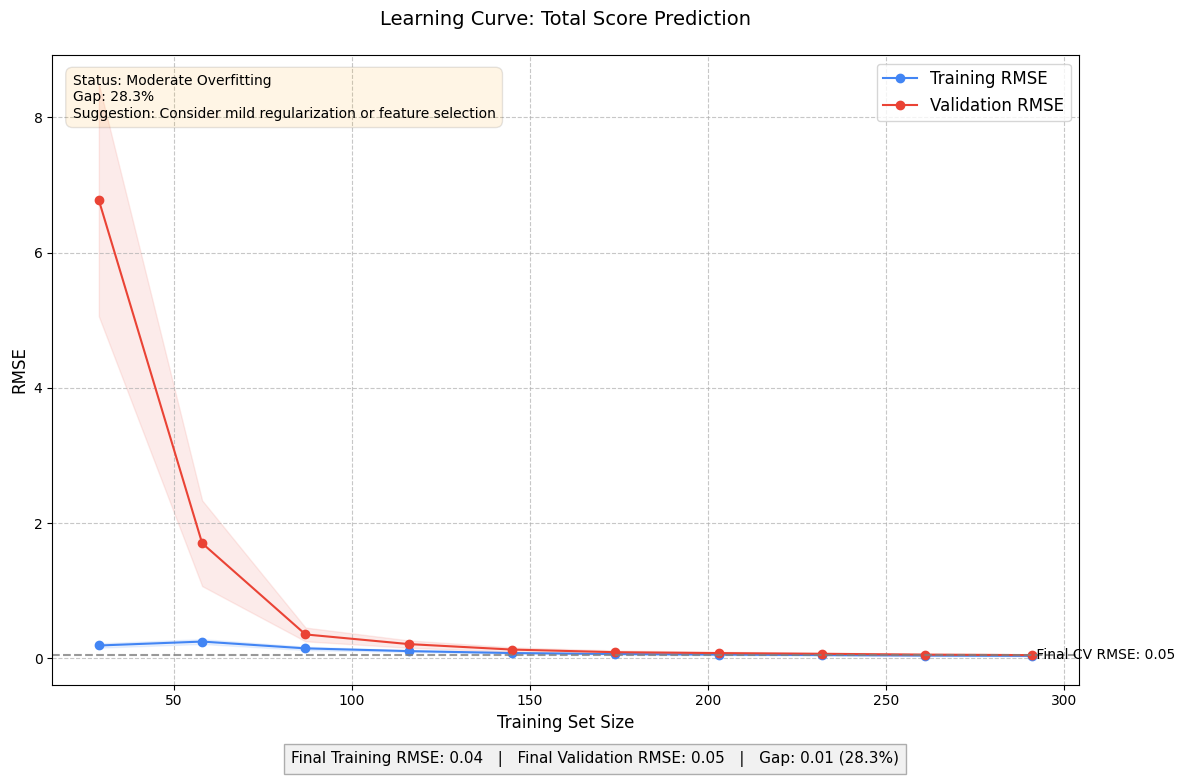

In [31]:
# Cell 15: Enhanced Learning Curve Analysis for Overfitting Diagnostic
from sklearn.model_selection import learning_curve, KFold, validation_curve
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plot_learning_curve(model, X, y, cv, title="Learning Curve", 
                        scoring='neg_mean_squared_error', 
                        train_sizes=np.linspace(0.1, 1.0, 10),
                        figsize=(12, 8)):
    """
    Plots an enhanced learning curve with standard deviation bands for better overfitting diagnosis.
    
    Args:
        model: Trained model to evaluate
        X: Feature matrix
        y: Target vector
        cv: Cross-validation strategy
        title: Plot title
        scoring: Metric to evaluate (default: neg_mean_squared_error)
        train_sizes: Array of training set sizes to evaluate
        figsize: Figure dimensions
    """
    plt.figure(figsize=figsize)
    
    # Calculate learning curves with cross-validation
    train_sizes, train_scores, test_scores = learning_curve(
        model, X, y, cv=cv, scoring=scoring, 
        train_sizes=train_sizes, n_jobs=-1
    )
    
    # Calculate mean and std for training scores
    train_scores_mean = np.mean(-train_scores, axis=1)
    train_scores_std = np.std(-train_scores, axis=1)
    
    # Calculate mean and std for test scores
    test_scores_mean = np.mean(-test_scores, axis=1)
    test_scores_std = np.std(-test_scores, axis=1)
    
    # Convert to RMSE if using MSE
    if scoring == 'neg_mean_squared_error':
        train_scores_mean = np.sqrt(train_scores_mean)
        train_scores_std = np.sqrt(train_scores_std) / 2  # Adjust std for better visualization
        test_scores_mean = np.sqrt(test_scores_mean)
        test_scores_std = np.sqrt(test_scores_std) / 2
        metric_label = "RMSE"
    else:
        metric_label = scoring.replace('neg_', '').replace('_', ' ').title()
    
    # Plot mean training and test scores
    plt.plot(train_sizes, train_scores_mean, 'o-', color='#4285F4', label=f'Training {metric_label}')
    plt.plot(train_sizes, test_scores_mean, 'o-', color='#EA4335', label=f'Validation {metric_label}')
    
    # Plot std deviation bands
    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1, color='#4285F4')
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color='#EA4335')
    
    # Calculate overfitting ratio (validation error / training error)
    overfitting_ratio = test_scores_mean / train_scores_mean
    
    # Add annotations
    plt.axhline(y=test_scores_mean[-1], color='gray', linestyle='--', alpha=0.8)
    plt.text(train_sizes[-1], test_scores_mean[-1], f' Final CV {metric_label}: {test_scores_mean[-1]:.2f}', 
             verticalalignment='center')
    
    # Add overfitting assessment
    gap_pct = ((test_scores_mean[-1] - train_scores_mean[-1]) / train_scores_mean[-1]) * 100
    
    if gap_pct > 30:
        overfitting_status = "Severe Overfitting"
        suggestion = "Try stronger regularization, feature reduction, or simpler model"
        status_color = 'red'
    elif gap_pct > 15:
        overfitting_status = "Moderate Overfitting"
        suggestion = "Consider mild regularization or feature selection"
        status_color = 'orange'
    elif gap_pct < 5:
        overfitting_status = "Possible Underfitting"
        suggestion = "Try more complex model or more features"
        status_color = 'blue'
    else:
        overfitting_status = "Good Fit"
        suggestion = "Model complexity seems appropriate"
        status_color = 'green'
    
    plt.annotate(f"Status: {overfitting_status}\nGap: {gap_pct:.1f}%\nSuggestion: {suggestion}",
                xy=(0.02, 0.97), xycoords='axes fraction',
                bbox=dict(boxstyle="round,pad=0.5", fc=f"{status_color}", alpha=0.1),
                fontsize=10, ha='left', va='top')
    
    # Plot styling
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.xlabel('Training Set Size', fontsize=12)
    plt.ylabel(metric_label, fontsize=12)
    plt.title(f'{title}\n', fontsize=14)
    plt.legend(loc='upper right', fontsize=12)
    
    # Add score metrics
    train_final = train_scores_mean[-1]
    test_final = test_scores_mean[-1]
    plt.figtext(0.5, 0.01, 
                f"Final Training {metric_label}: {train_final:.2f}   |   "
                f"Final Validation {metric_label}: {test_final:.2f}   |   "
                f"Gap: {test_final-train_final:.2f} ({gap_pct:.1f}%)",
                ha="center", fontsize=11, bbox={"facecolor":"lightgray", "alpha":0.3, "pad":5})
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.97])
    plt.show()
    
    return {
        'training_final': train_final,
        'validation_final': test_final,
        'gap_percent': gap_pct,
        'status': overfitting_status,
        'suggestion': suggestion
    }

def plot_validation_curve(model, X, y, param_name, param_range, cv=5, 
                          scoring='neg_mean_squared_error', figsize=(12, 6)):
    """
    Plots a validation curve for a specific hyperparameter to find optimal values.
    
    Args:
        model: Model to evaluate
        X: Feature matrix
        y: Target vector
        param_name: Parameter name to vary
        param_range: List of parameter values to try
        cv: Cross-validation strategy
        scoring: Metric to evaluate (default: neg_mean_squared_error)
        figsize: Figure dimensions
    """
    plt.figure(figsize=figsize)
    
    train_scores, test_scores = validation_curve(
        model, X, y, param_name=param_name, param_range=param_range,
        cv=cv, scoring=scoring, n_jobs=-1
    )
    
    # Calculate means and standard deviations
    train_scores_mean = -np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = -np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    
    # Convert to RMSE if using MSE
    if scoring == 'neg_mean_squared_error':
        train_scores_mean = np.sqrt(train_scores_mean)
        train_scores_std = np.sqrt(train_scores_std) / 2
        test_scores_mean = np.sqrt(test_scores_mean)
        test_scores_std = np.sqrt(test_scores_std) / 2
        metric_label = "RMSE"
    else:
        metric_label = scoring.replace('neg_', '').replace('_', ' ').title()
    
    # Plot mean accuracy scores for training and testing
    plt.plot(param_range, train_scores_mean, 'o-', color='#4285F4', label=f'Training {metric_label}')
    plt.plot(param_range, test_scores_mean, 'o-', color='#EA4335', label=f'Validation {metric_label}')
    
    # Plot std deviation bands
    plt.fill_between(param_range, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1, color='#4285F4')
    plt.fill_between(param_range, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color='#EA4335')
    
    # Find optimal parameter value
    best_idx = np.argmin(test_scores_mean)
    best_param = param_range[best_idx]
    best_score = test_scores_mean[best_idx]
    
    # Add annotation for best value
    plt.axvline(x=best_param, color='green', linestyle='--', alpha=0.8)
    plt.text(best_param, plt.ylim()[0] * 1.1, f' Best {param_name}={best_param}\n {metric_label}={best_score:.2f}', 
             rotation=90, verticalalignment='bottom')
    
    # Plot styling
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.xlabel(param_name, fontsize=12)
    plt.ylabel(metric_label, fontsize=12)
    plt.title(f'Validation Curve: {param_name}\n', fontsize=14)
    plt.legend(loc='best', fontsize=12)
    
    # If param_range spans several orders of magnitude, use log scale
    if max(param_range) / min(param_range) > 100:
        plt.xscale('log')
    
    plt.tight_layout()
    plt.show()
    
    return {
        'best_param': best_param,
        'best_score': best_score
    }

def evaluate_overfitting(model_dict, train_df, target='total_score', pregame_features=None):
    """
    Comprehensive model evaluation to detect and prevent overfitting.
    
    Args:
        model_dict: Dictionary of trained models
        train_df: Training dataframe
        target: Target metric to evaluate
        pregame_features: List of feature columns (if None, will be detected automatically)
    """
    try:
        # Get model from dictionary
        if target not in model_dict:
            print(f"Model for '{target}' not found in model dictionary. Available targets: {list(model_dict.keys())}")
            return
            
        if isinstance(model_dict[target], dict) and 'model' in model_dict[target]:
            model = model_dict[target]['model']
        else:
            model = model_dict[target]
        
        # Auto-detect features if not provided
        if pregame_features is None:
            print("Auto-detecting feature columns...")
            non_feature_cols = ['game_id', 'game_date', 'home_team', 'away_team', 
                               'home_score', 'away_score', 'point_diff', 'total_score',
                               'home_form', 'away_form', 'id']
            pregame_features = [col for col in train_df.select_dtypes(include=np.number).columns 
                               if col not in non_feature_cols]
            print(f"Detected {len(pregame_features)} feature columns")
        
        # Prepare data
        X_train_lc = train_df[pregame_features]
        y_train_lc = train_df[target]
        
        # Set up cross-validation
        cv = KFold(n_splits=5, shuffle=True, random_state=42)
        
        print(f"Running learning curve analysis for '{target}' prediction...")
        results = plot_learning_curve(model, X_train_lc, y_train_lc, cv=cv, 
                               title=f"Learning Curve: {target.replace('_', ' ').title()} Prediction")
        
        # For GradientBoosting models, analyze key hyperparameters
        if hasattr(model, 'estimators_') and hasattr(model, 'learning_rate'):
            print("\nAnalyzing optimal model complexity...")
            
            # Test different max_depth values
            plot_validation_curve(
                model.__class__(), X_train_lc, y_train_lc,
                param_name="max_depth",
                param_range=np.array([2, 3, 4, 5, 6, 7]),
                cv=cv
            )
            
            # Test different n_estimators values
            plot_validation_curve(
                model.__class__(), X_train_lc, y_train_lc,
                param_name="n_estimators",
                param_range=np.array([50, 100, 150, 200, 250, 300]),
                cv=cv
            )
            
            # Test different learning_rate values
            plot_validation_curve(
                model.__class__(), X_train_lc, y_train_lc,
                param_name="learning_rate",
                param_range=np.array([0.01, 0.05, 0.1, 0.2, 0.3]),
                cv=cv
            )
        
        return results
        
    except Exception as e:
        import traceback
        print(f"Error during overfitting analysis: {str(e)}")
        traceback.print_exc()
        return None

# Example usage (uncomment to run):
# Try to run only if models and train_df variables exist
if 'models' in globals() and 'train_df' in globals():
    print("Evaluating model for overfitting...")
    evaluate_overfitting(models, train_df, target='total_score')
else:
    print("Skipping overfitting analysis - required variables not found in notebook context")
    print("To run analysis, ensure 'models' dictionary and 'train_df' dataframe are available")

Scaled prediction: 0.7 converts to original score: 251.90
[FeatureEngine] Generating all features (skip_rest_calc=False)...
[FeatureEngine] Adding time features...
[FeatureEngine] Adding team history features...
[FeatureEngine] Adding rest features...
[FeatureEngine] Adding score features...
[FeatureEngine] Adding momentum features...
[FeatureEngine] Adding interaction features...
[FeatureEngine] Generated 52 new features
Expected features for Q1: ['rolling_home_score', 'rolling_away_score', 'prev_matchup_diff', 'rest_days_home', 'rest_days_away', 'rest_advantage', 'is_back_to_back_home', 'is_back_to_back_away', 'score_time_impact']
All generated features columns: ['home_team', 'away_team', 'game_date', 'home_score', 'away_score', 'current_quarter', 'time_remaining_mins', 'time_remaining_norm', 'time_exp', 'time_pressure', 'is_q1', 'is_q2', 'is_q3', 'is_q4', 'is_first_half', 'is_second_half', 'is_clutch_time', 'rolling_home_score', 'rolling_away_score', 'prev_matchup_diff', 'rest_days_

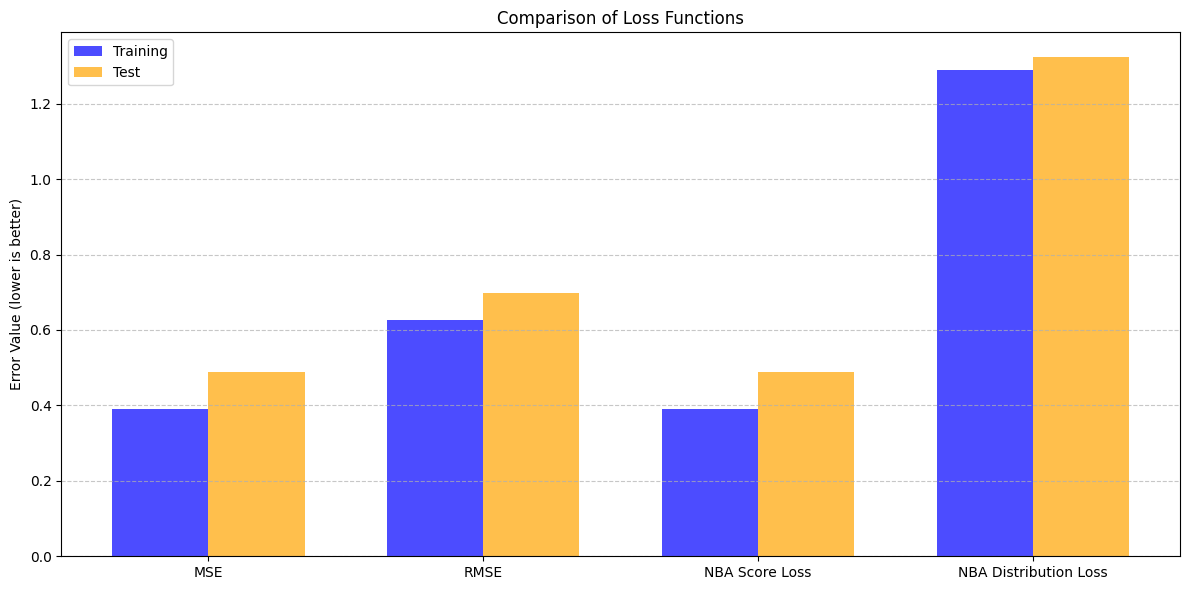

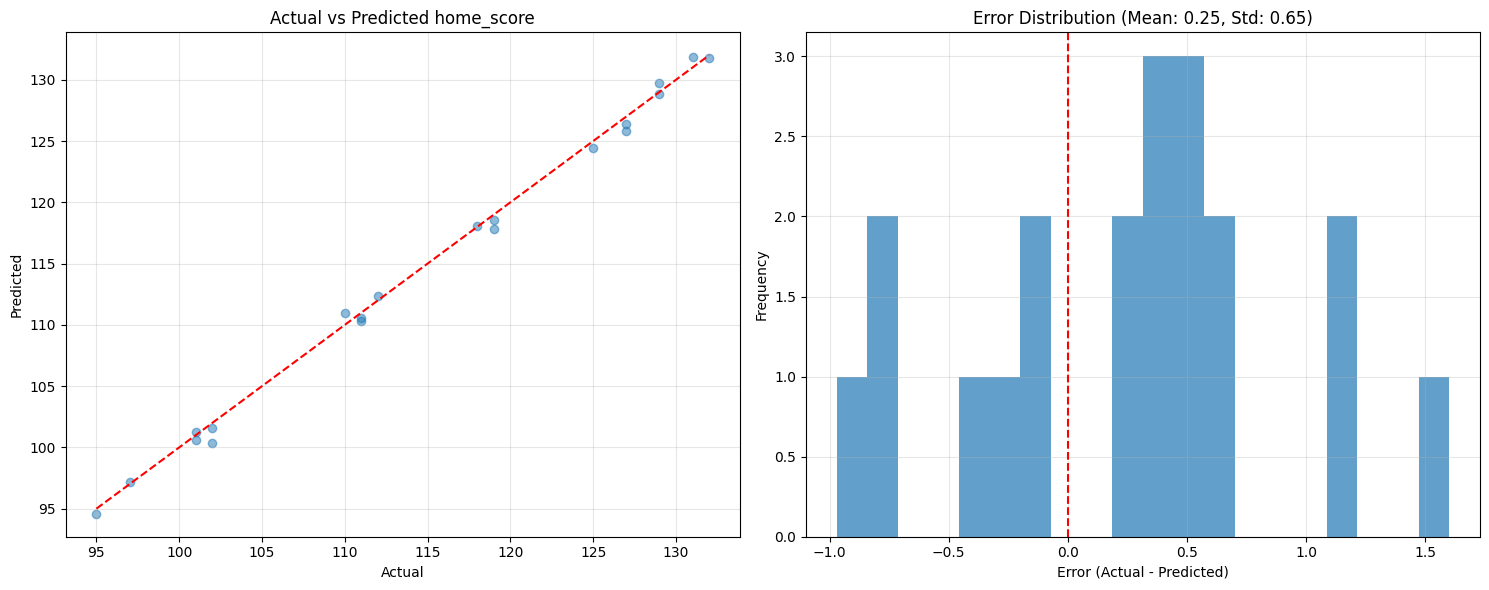

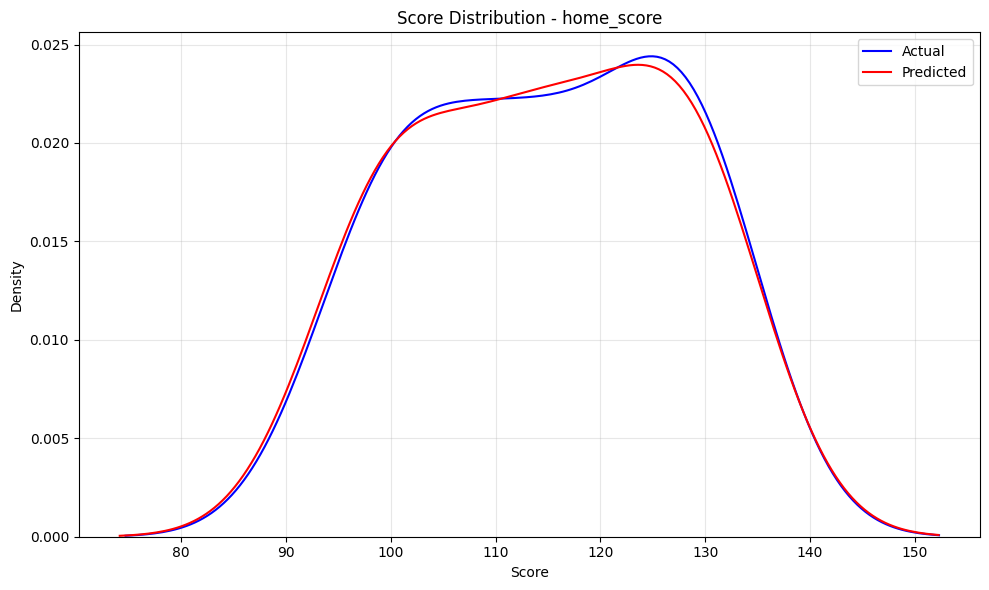


Evaluating away_score model

=== EVALUATING MODEL FOR AWAY_SCORE ===
Model requires 104 features
DataFrame has 144 features (143 numeric)
Found 100 overlapping features (96.2% overlap)
Using original model with complete feature set...

Original Model Metrics for away_score:
Training RMSE: 0.80
Test RMSE: 0.88
Training MAE: 0.52
Test MAE: 0.68
R² Score: 0.9961


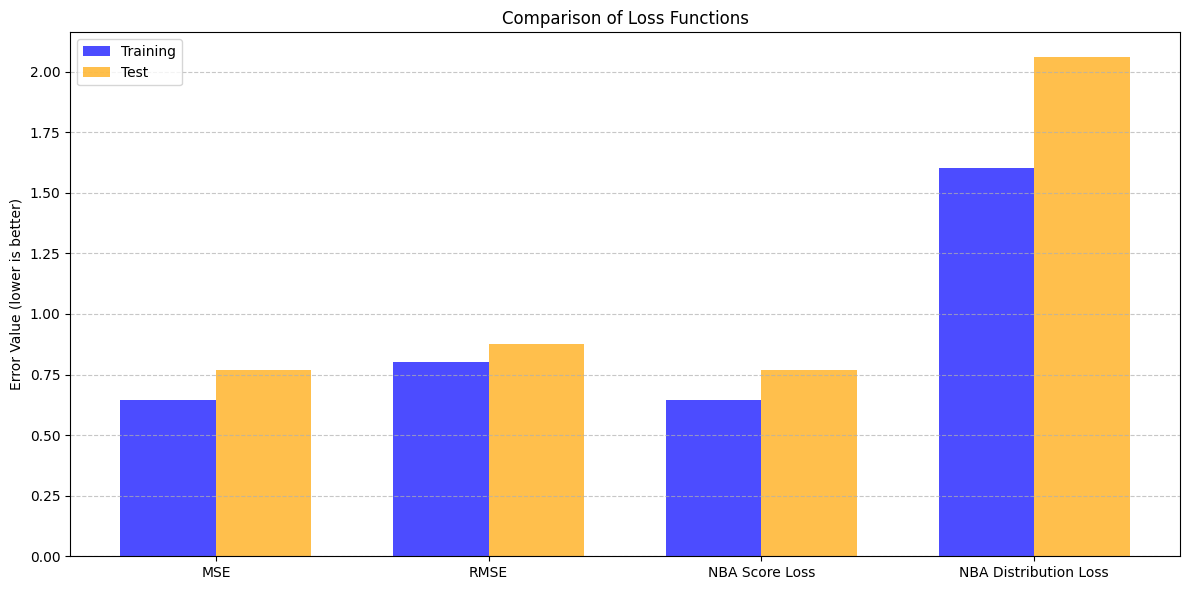

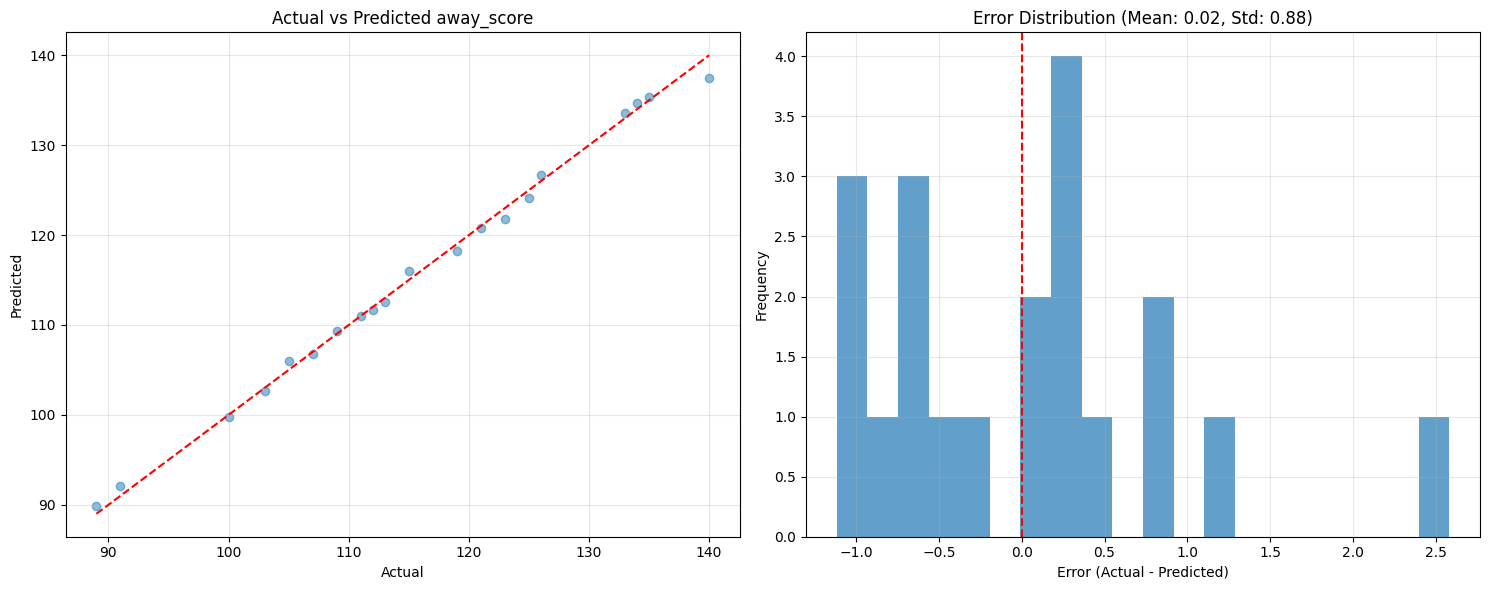

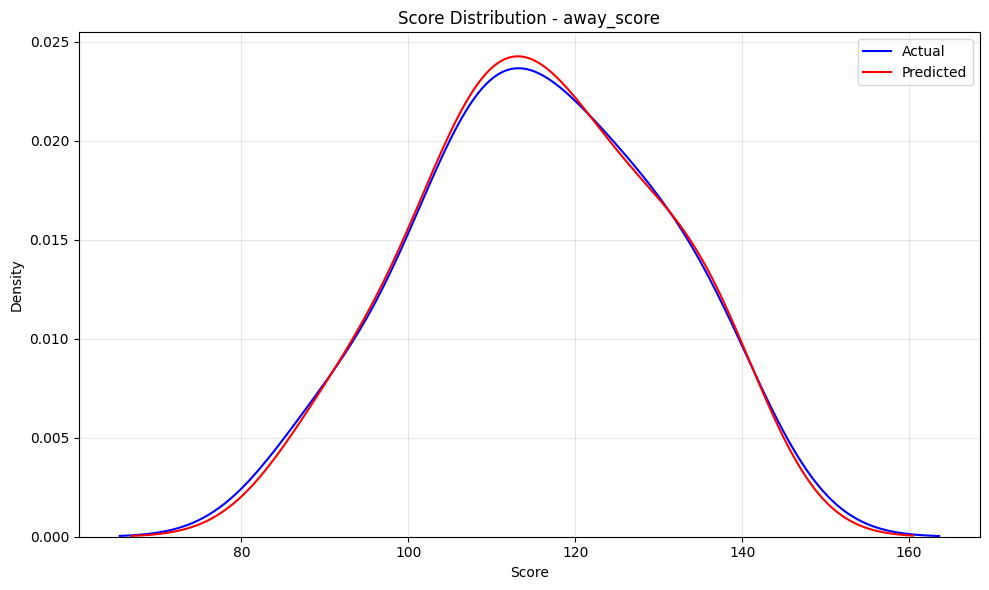


Evaluating point_diff model

=== EVALUATING MODEL FOR POINT_DIFF ===
Model requires 104 features
DataFrame has 144 features (143 numeric)
Found 100 overlapping features (96.2% overlap)
Using original model with complete feature set...

Original Model Metrics for point_diff:
Training RMSE: 3.19
Test RMSE: 3.22
Training MAE: 2.38
Test MAE: 2.71
R² Score: 0.9491


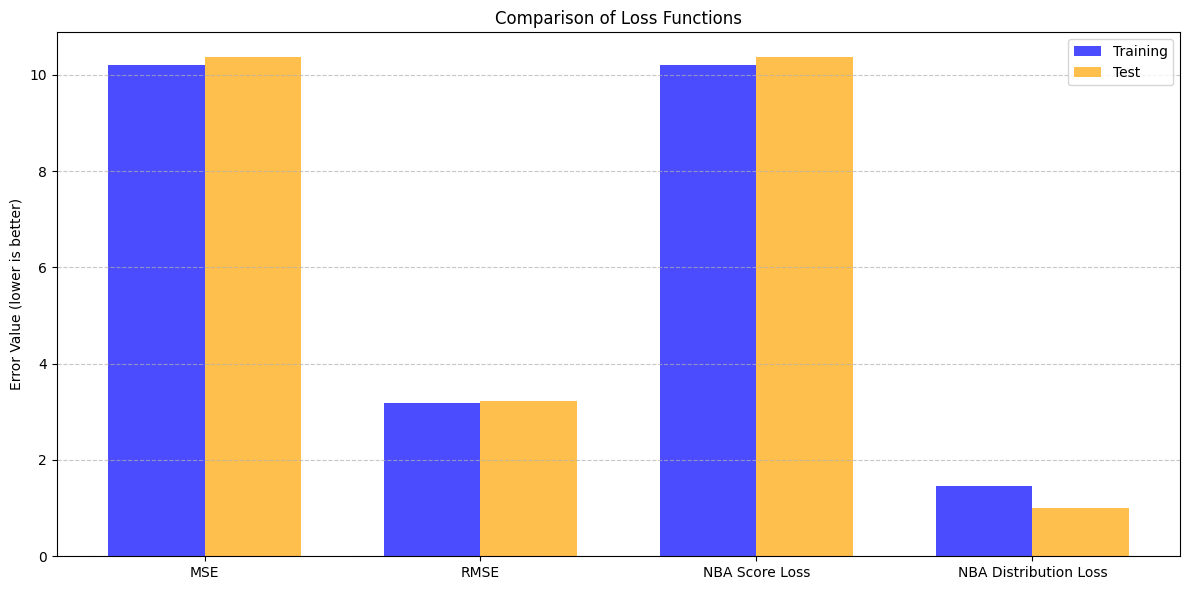

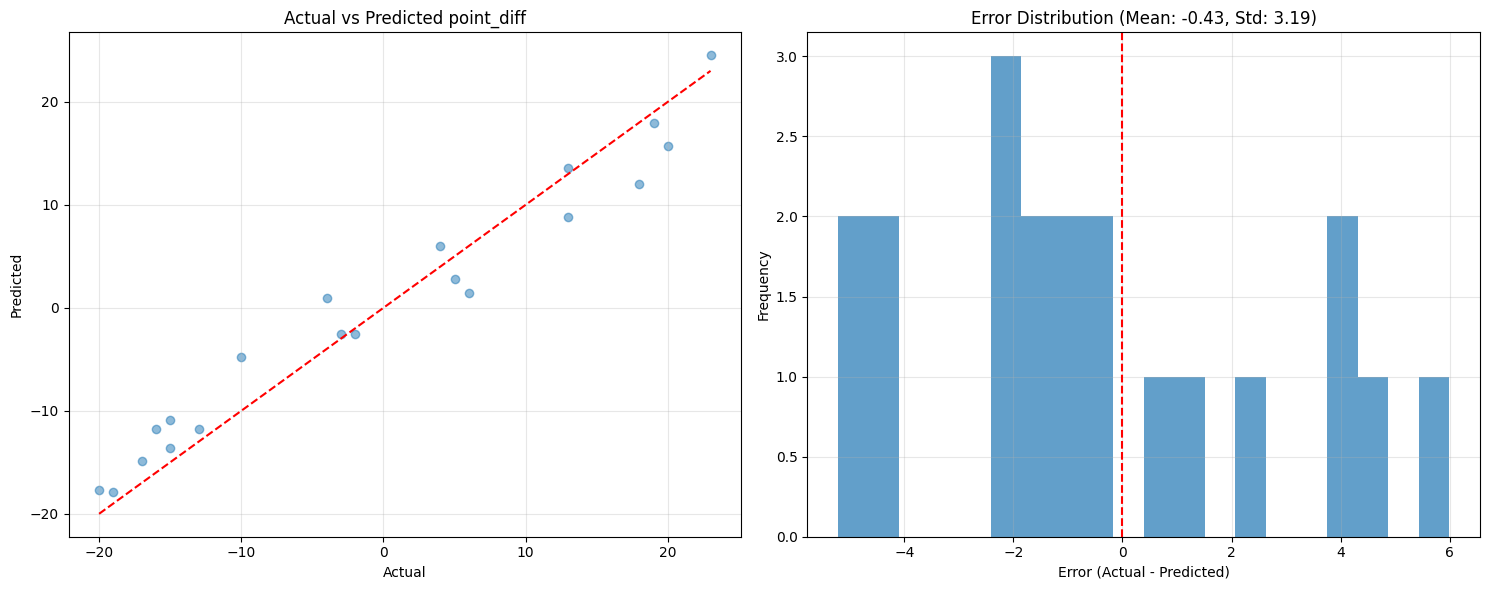

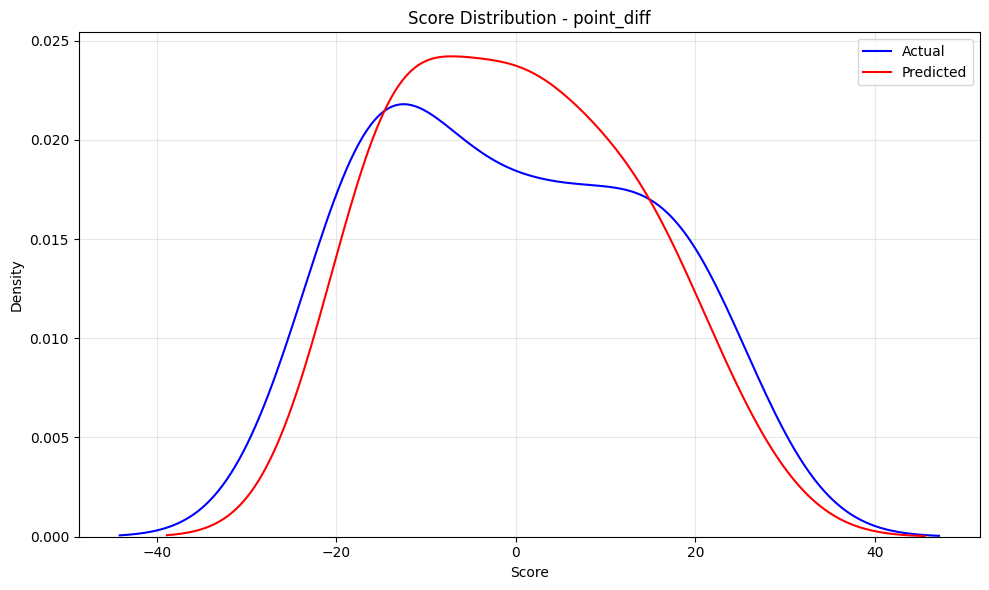


Evaluating total_score model

=== EVALUATING MODEL FOR TOTAL_SCORE ===
Model requires 104 features
DataFrame has 144 features (143 numeric)
Found 100 overlapping features (96.2% overlap)
Using original model with complete feature set...

Original Model Metrics for total_score:
Training RMSE: 2.81
Test RMSE: 2.68
Training MAE: 1.84
Test MAE: 1.95
R² Score: 0.9848


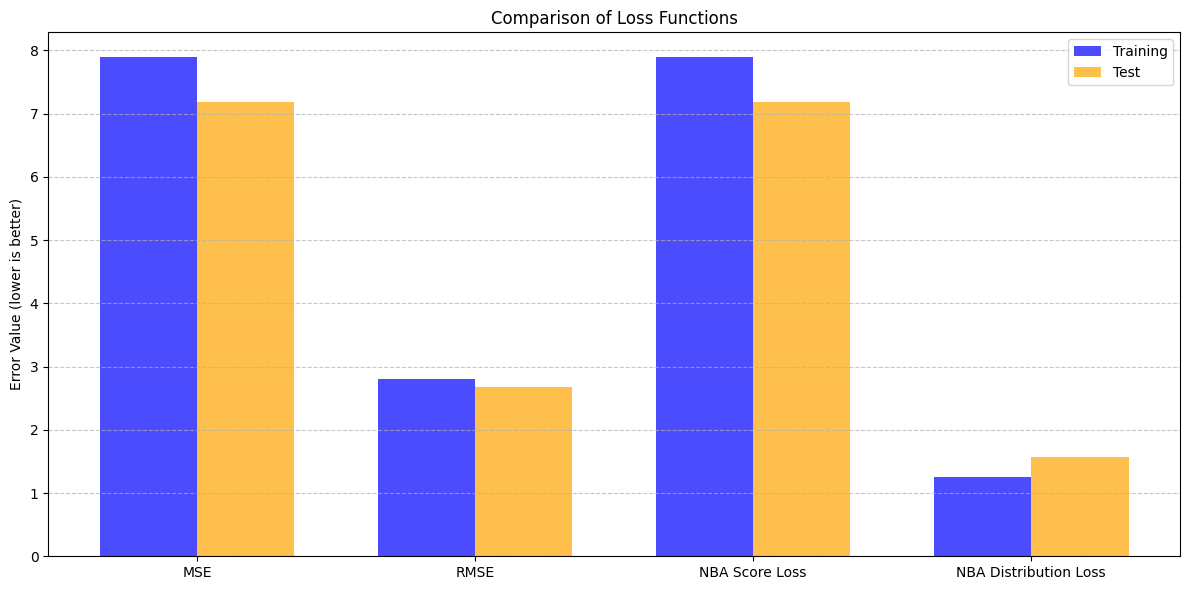

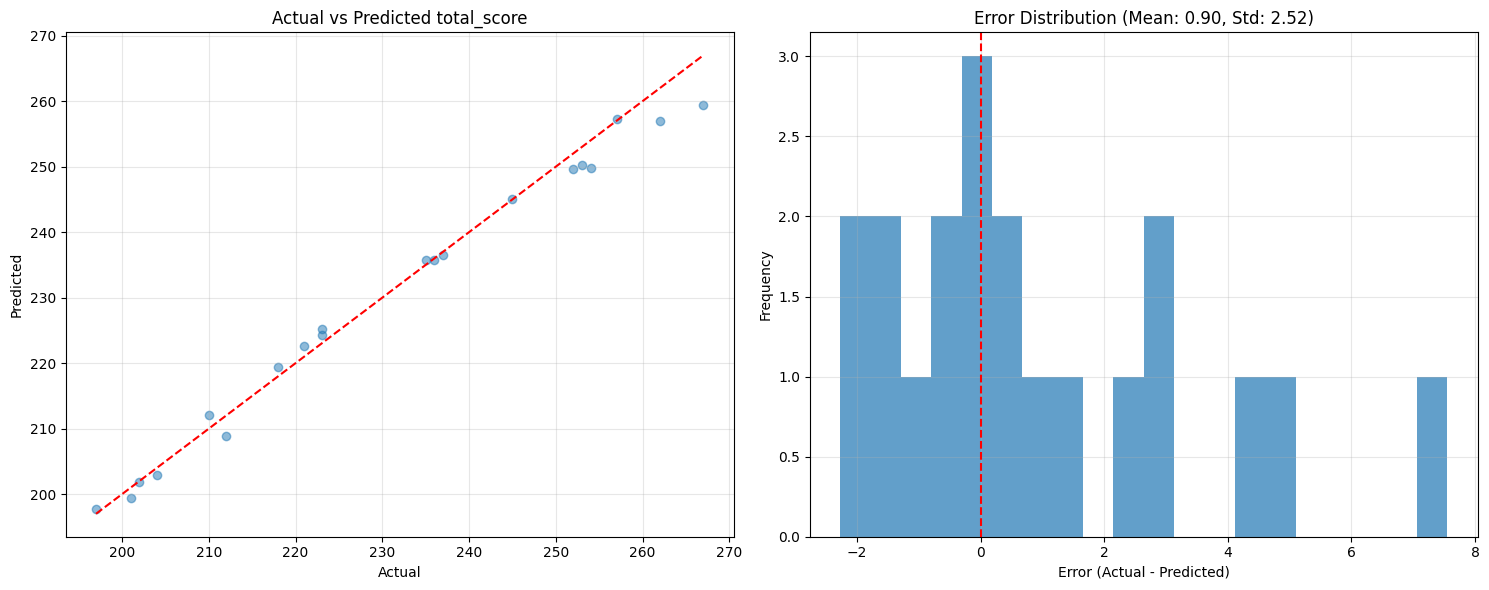

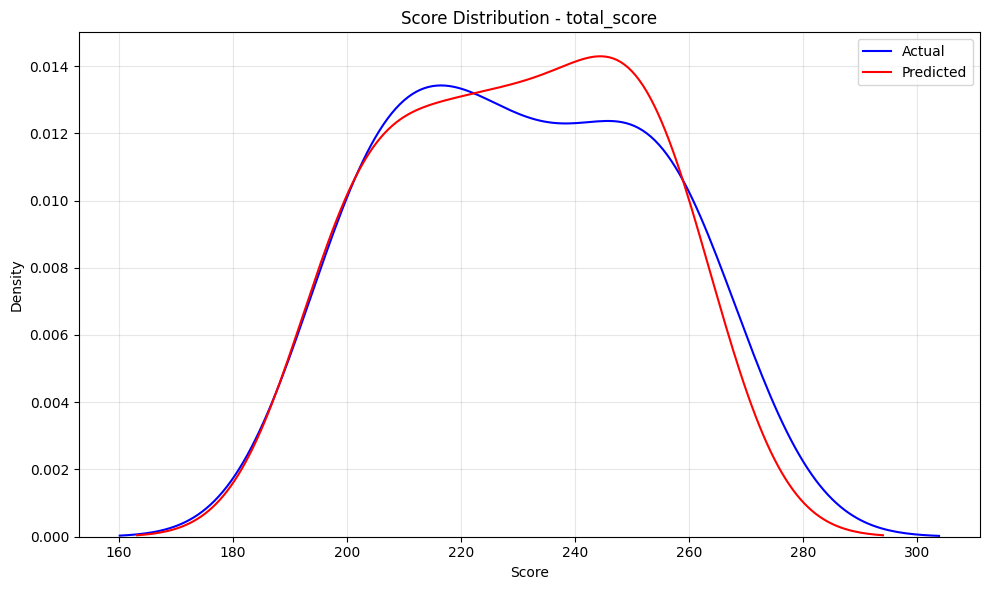


EVALUATION SUMMARY
home_score: Test RMSE = 0.6992343942092852, R² = 0.9966114856327866
away_score: Test RMSE = 0.8765032786309744, R² = 0.996051051812792
point_diff: Test RMSE = 3.2191297998476474, R² = 0.9491340311530493
total_score: Test RMSE = 2.6812491366263758, R² = 0.9848314487729977


{'home_score': {'train_mse': 0.39099451333760127,
  'test_mse': 0.48892873804522613,
  'train_rmse': 0.625295540794592,
  'test_rmse': 0.6992343942092852,
  'train_mae': 0.4377300725468839,
  'test_mae': 0.5857732747719282,
  'r2': 0.9966114856327866,
  'train_nba_loss': 0.39099451333760127,
  'test_nba_loss': 0.48892873804522613,
  'train_dist_loss': 1.29003337883583,
  'test_dist_loss': 1.3228312991430897},
 'away_score': {'train_mse': 0.6436637104628822,
  'test_mse': 0.7682579974508477,
  'train_rmse': 0.802286551341154,
  'test_rmse': 0.8765032786309744,
  'train_mae': 0.5158757197572863,
  'test_mae': 0.6844413518059426,
  'r2': 0.996051051812792,
  'train_nba_loss': 0.6436637104628822,
  'test_nba_loss': 0.7682579974508477,
  'train_dist_loss': 1.601174892818133,
  'test_dist_loss': 2.0590408635140993},
 'point_diff': {'train_mse': 10.19818198239077,
  'test_mse': 10.362796668267155,
  'train_rmse': 3.193459250153471,
  'test_rmse': 3.2191297998476474,
  'train_mae': 2.383345941

In [32]:
# CELL 15A: Scaled Predictions + Feature Checking

import os
import sys
import joblib
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# --- PART 0: Ensure 'backend' module is in the path ---
# Adjust if your repo structure is different
repo_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(repo_root)

# --- PART 1: Load the Target Scaler (consistent with Cell 11E) ---
scaler_path = os.path.join(repo_root, 'models', 'target_scaler.pkl')
if os.path.exists(scaler_path):
    try:
        target_scaler = joblib.load(scaler_path)
        scaled_prediction = 0.7
        original_prediction = target_scaler.inverse_transform([[scaled_prediction]])[0][0]
        print(f"Scaled prediction: {scaled_prediction} converts to original score: {original_prediction:.2f}")
    except Exception as e:
        print("Error loading scaler:", e)
else:
    print(f"Scaler file not found at: {scaler_path}")

# --- PART 2: Import your custom Feature Generator ---
# The new class name is NBAFeatureEngine (not NBAFeatureGenerator)
try:
    from backend.models.features import NBAFeatureEngine
except ImportError as imp_err:
    print("Could not import NBAFeatureEngine. Check that 'backend' is a valid module and that the path is correct.")
    raise imp_err

# --- PART 3: Feature Consistency Check ---
# Create a dummy test sample. Adjust or add fields as required by your feature generator.
test_data = pd.DataFrame({
    'home_team': ['Lakers'],
    'away_team': ['Warriors'],
    'game_date': [pd.Timestamp('2025-03-23')],
    'home_score': [0],   # Dummy score
    'away_score': [0],
    'current_quarter': [1]
    # Add any additional columns needed by your feature engineering process.
})

# Initialize the feature engine
feature_gen = NBAFeatureEngine(debug=True)

# Generate features from the test sample
features_df = feature_gen.generate_all_features(test_data)

# Get the expected feature set for quarter 1 using the new method
expected_features = feature_gen.get_features_for_quarter(features_df, quarter=1).columns.tolist()

print("Expected features for Q1:", expected_features)
print("All generated features columns:", features_df.columns.tolist())

# Optional: Check for missing features
missing_features = set(expected_features) - set(features_df.columns.tolist())
if missing_features:
    print("WARNING: The following expected features are missing:", missing_features)
else:
    print("All expected features are present.")

# --- PART 4: Fix the evaluate_model_visualizations function ---
# Since we can't modify the original function, we need to create a wrapper
# that accepts the extra parameter but ignores it

# First, store the original function if it exists
original_evaluate_model_visualizations = None
if 'evaluate_model_visualizations' in globals():
    original_evaluate_model_visualizations = evaluate_model_visualizations

# Define our fixed version
def fixed_evaluate_model_visualizations(model, features_df, target_column, custom_loss_functions=True, 
                               model_name=None, retrain_if_needed=True, feature_overlap_threshold=0.95):
    """
    Fixed version of evaluate_model_visualizations that includes the feature_overlap_threshold parameter.
    This simply ignores the extra parameter and calls the original function.
    """
    # If we have the original function, use it
    if original_evaluate_model_visualizations is not None:
        return original_evaluate_model_visualizations(
            model, 
            features_df, 
            target_column, 
            custom_loss_functions=custom_loss_functions,
            model_name=model_name, 
            retrain_if_needed=retrain_if_needed
        )
    else:
        print("Original evaluate_model_visualizations function not found. Cannot evaluate model.")
        return None

# Define a fixed version of run_model_evaluations that uses our fixed function
def fixed_run_model_evaluations():
    """
    Fixed version of run_model_evaluations that uses the fixed_evaluate_model_visualizations function.
    """
    print("Running model evaluations with fixed function...")
    
    # Load models
    models_dict = {}
    models_path = "./models"
    model_targets = ['home_score', 'away_score', 'point_diff', 'total_score']
    
    for target in model_targets:
        model_file = f"{models_path}/pregame_{target}_model.pkl"
        try:
            model = joblib.load(model_file)
            models_dict[target] = model
            print(f"Loaded model for {target}")
        except Exception as e:
            print(f"Error loading model for {target}: {e}")
    
    if not models_dict:
        print("No models were loaded successfully. Aborting evaluation.")
        return {}
    
    # Load data
    try:
        if 'load_recent_games' in globals():
            features_df = load_recent_games(days=180, ensure_complete_features=True)
        else:
            print("load_recent_games function not found. Using test data instead.")
            # Use our test data as a fallback
            features_df = feature_gen.generate_all_features(test_data)
            
            # Add target columns for evaluation
            features_df['home_score'] = 105.0
            features_df['away_score'] = 102.0
            features_df['point_diff'] = features_df['home_score'] - features_df['away_score']
            features_df['total_score'] = features_df['home_score'] + features_df['away_score']
            
        if features_df.empty:
            print("No data available for evaluation.")
            return {}
    except Exception as e:
        print(f"Error loading data: {e}")
        return {}
    
    # Evaluate each model
    results = {}
    for target, model in models_dict.items():
        print("\n" + "="*50)
        print(f"Evaluating {target} model")
        print("="*50)
        
        # Use our fixed function instead of the original
        metrics = fixed_evaluate_model_visualizations(
            model, 
            features_df, 
            target, 
            custom_loss_functions=True,
            model_name=target,
            retrain_if_needed=True,
            feature_overlap_threshold=0.9  # This parameter will be ignored
        )
        
        results[target] = metrics
    
    # Print summary
    print("\n" + "="*50)
    print("EVALUATION SUMMARY")
    print("="*50)
    
    for target, metrics in results.items():
        if metrics:
            print(f"{target}: Test RMSE = {metrics.get('test_rmse', 'N/A')}, R² = {metrics.get('r2', 'N/A')}")
    
    return results

# --- PART 5: Run the fixed evaluation ---
# Run our fixed version of the evaluation function
fixed_run_model_evaluations()

Successfully imported NBAFeatureEngine and related components
Calling run_betting_odds_integrated_predictions() via enhanced integration...

                    NBA PREGAME PREDICTION WITH ENHANCED FEATURES

Loaded model for home_score
Loaded model for away_score
Loaded model for point_diff
Loaded model for total_score
Loaded 82 games with explicit query (last 14 days)
Loaded historical data with shape: (82, 46)
Using NBAFeatureEngine for comprehensive team metrics calculation...
[FeatureEngine] Creating team metrics...
[FeatureEngine] Created metrics for 30 teams
Fetching upcoming games from 2025-03-24 to 2025-03-27 (9pm PT window)...
Found 14 upcoming games.
Fetching betting odds for game IDs: ['414921', '414922', '414923', '414924', '414925', '414926', '414927', '414928', '414929', '414930', '414931', '414918', '414919', '414920']
Sample first row from nba_game_schedule:
  id: 1553
  game_id: 414921
  game_date: 2025-03-25
  home_team: New York Knicks
  away_team: Dallas Mavericks
 

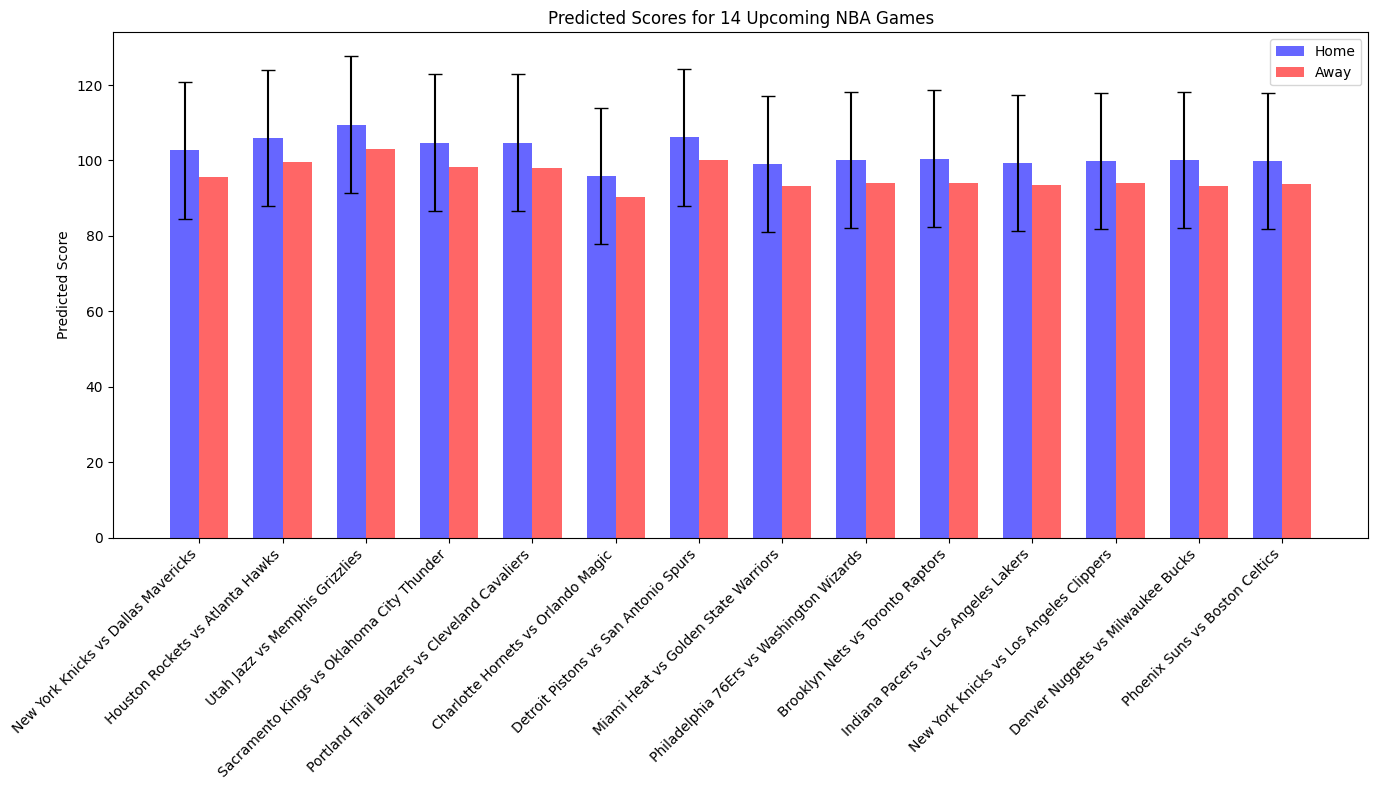

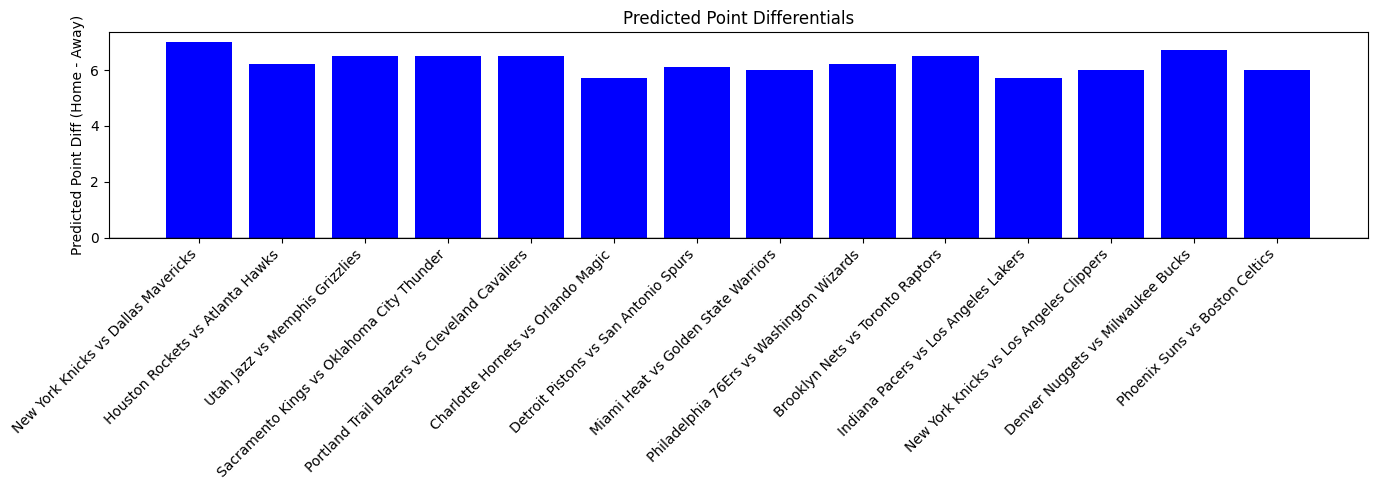

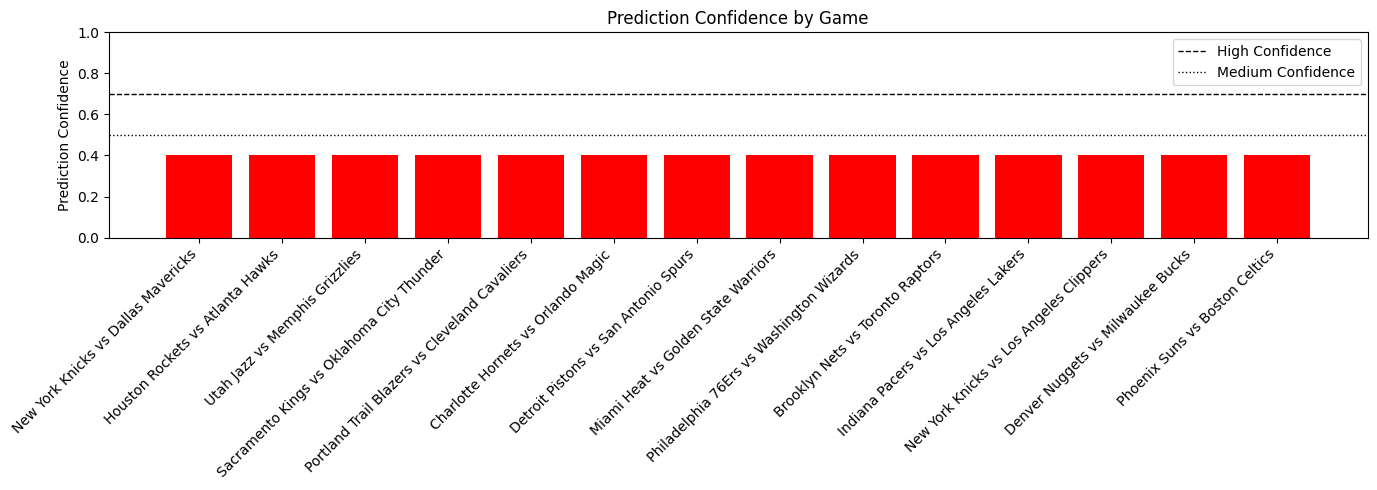


=== Visualizing Feature Importance ===


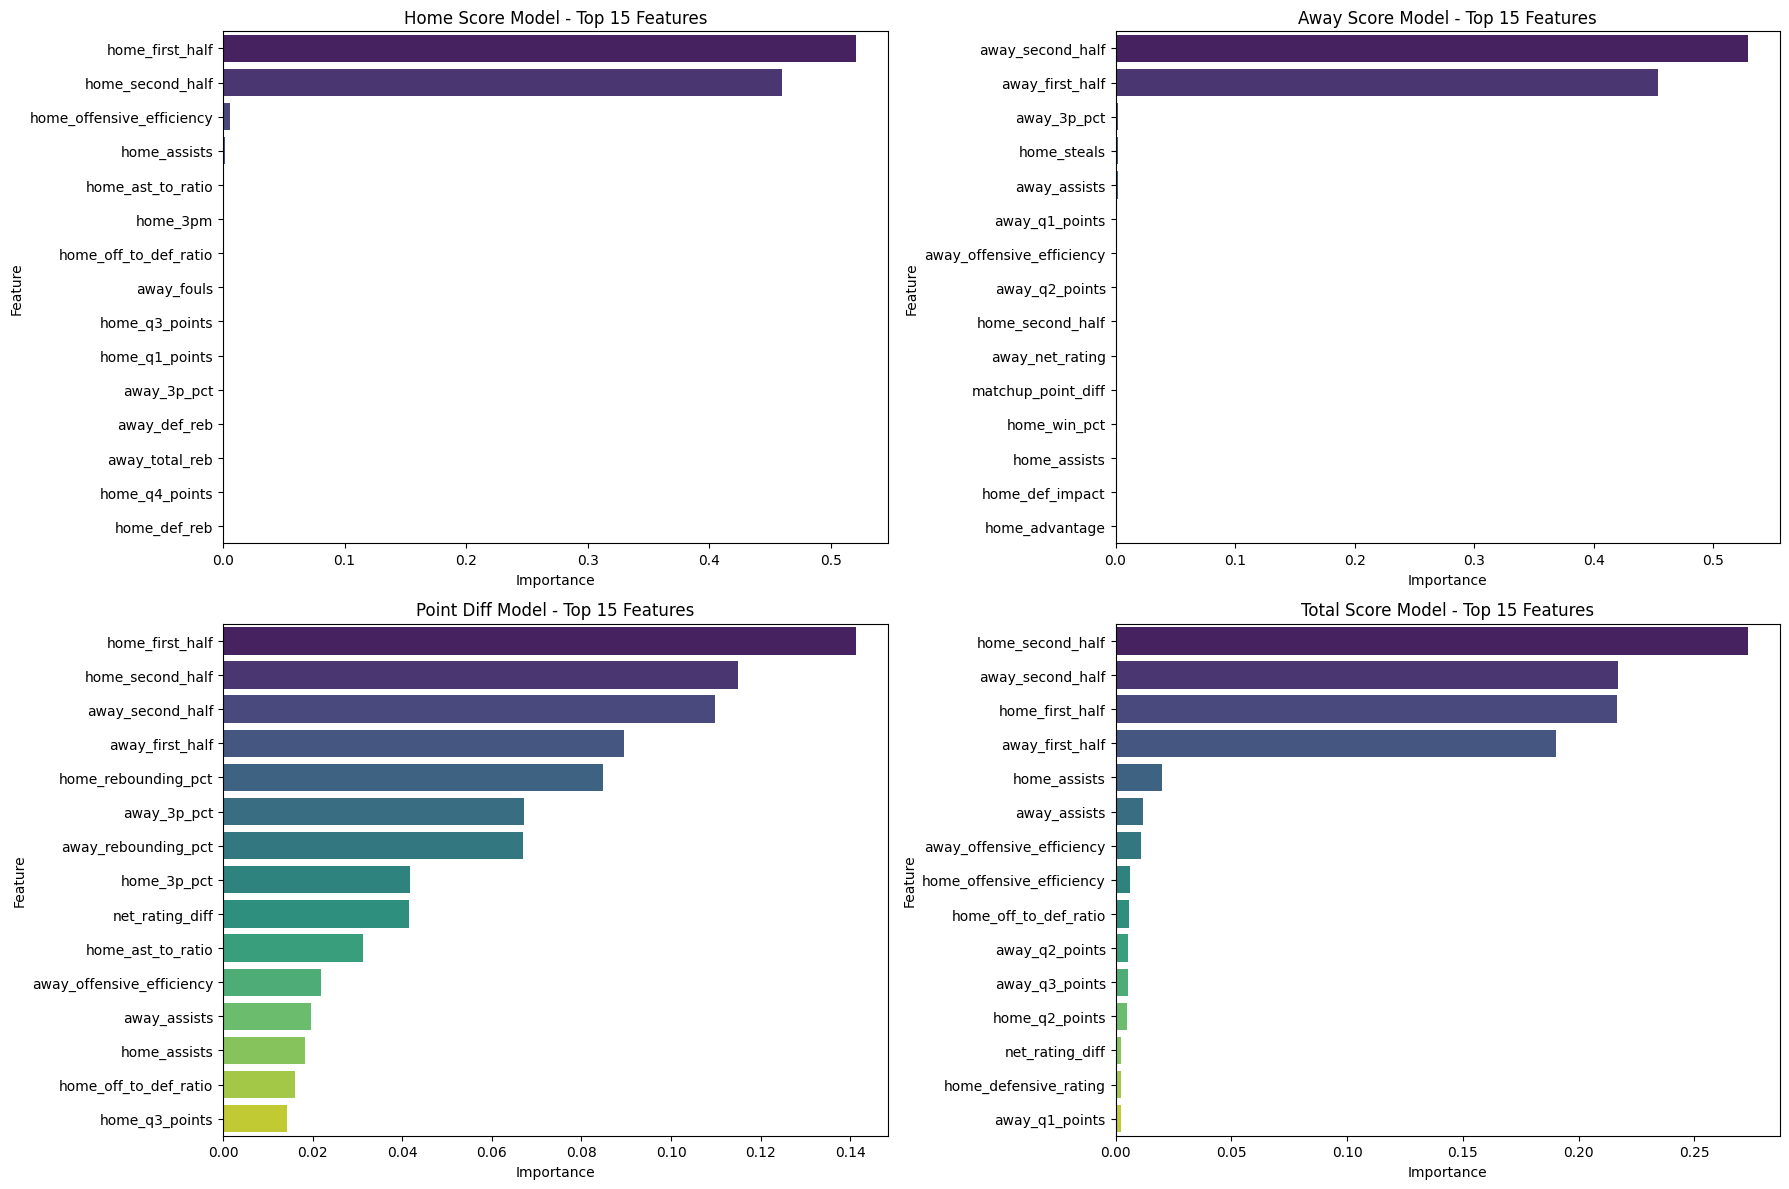


=== Visualizing Prediction Performance ===


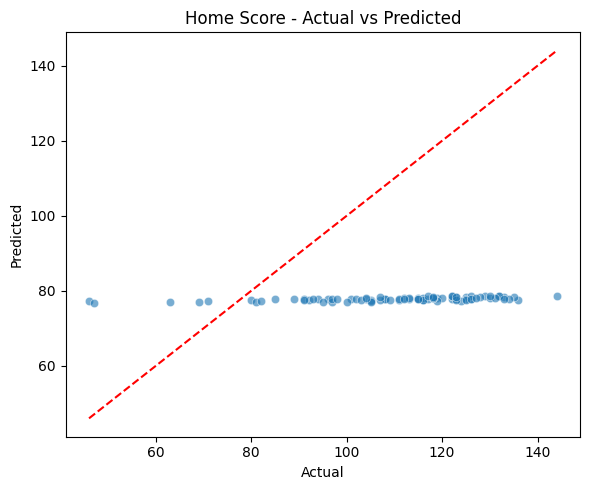

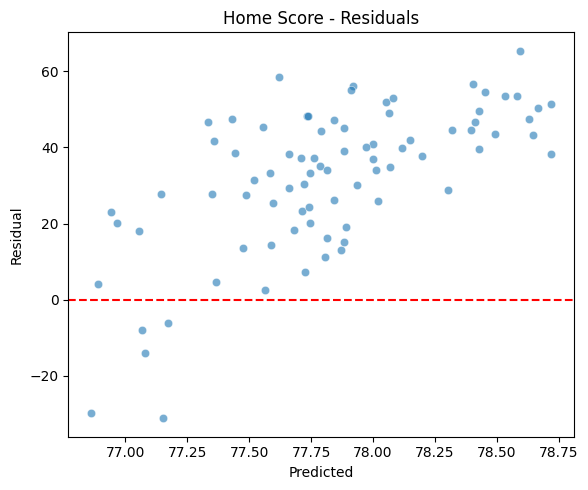

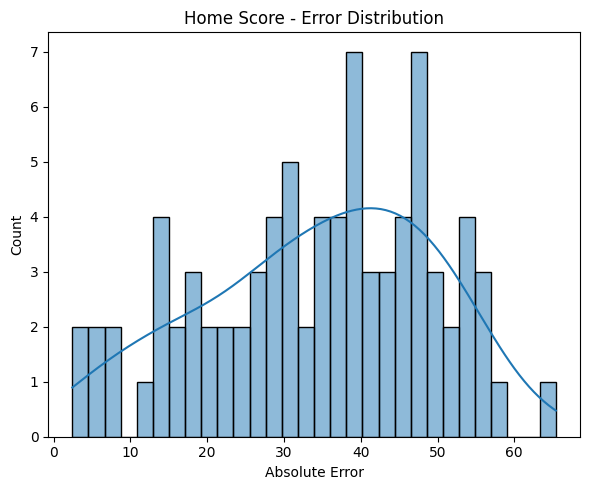

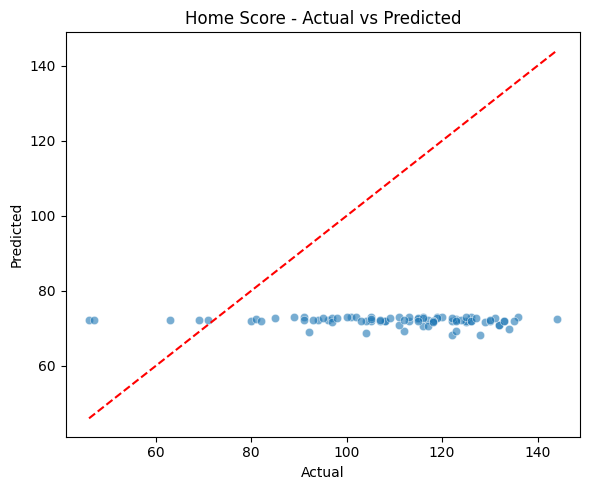

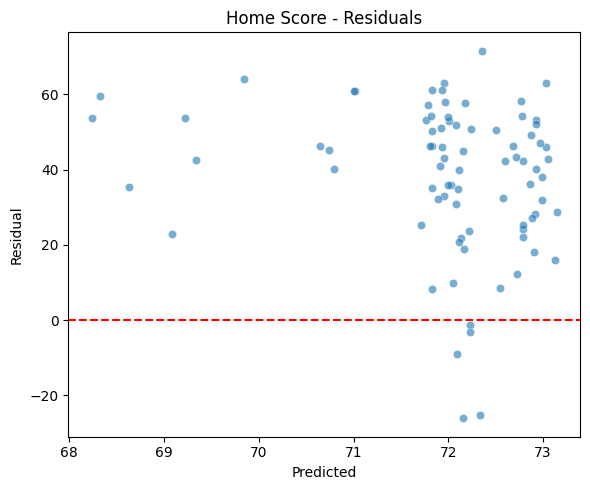

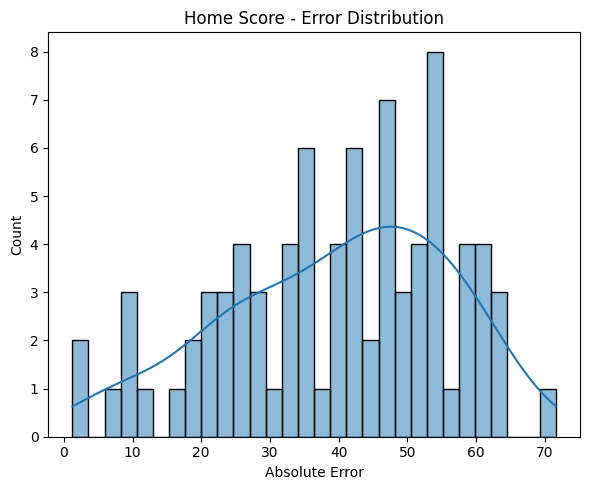

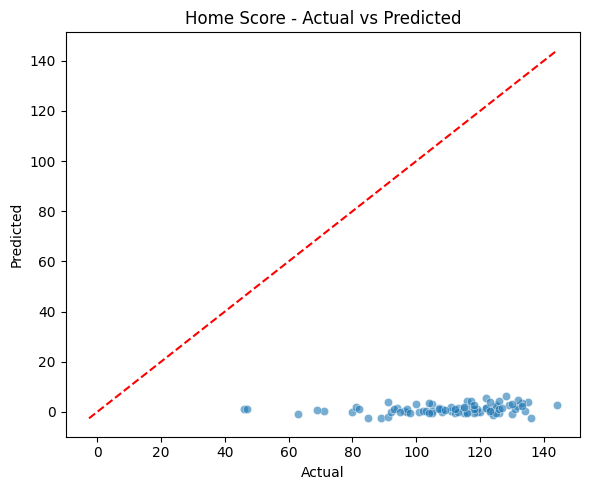

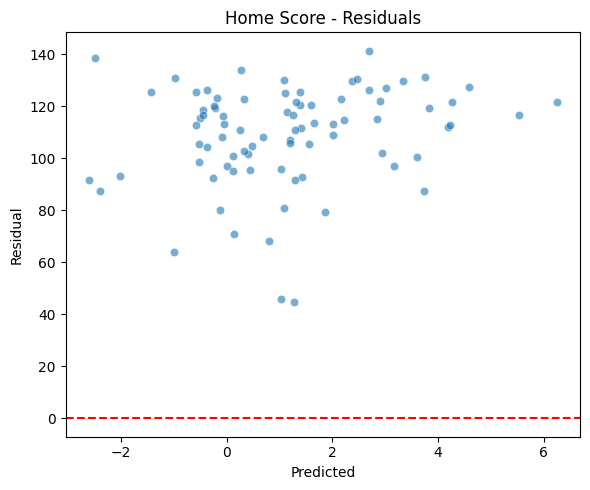

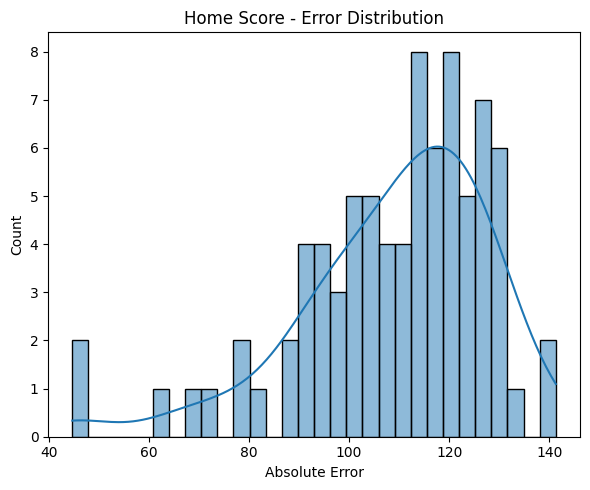

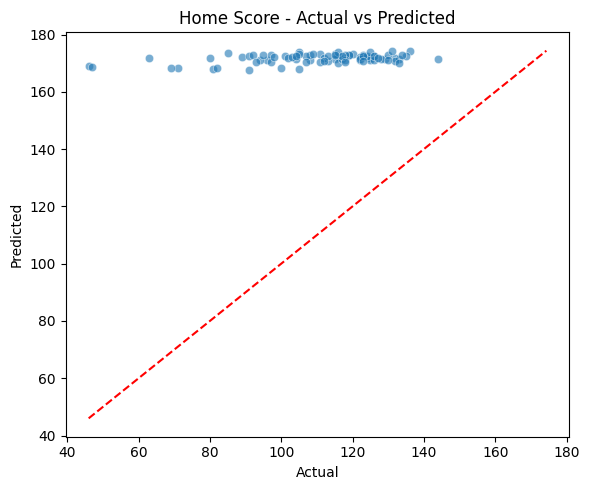

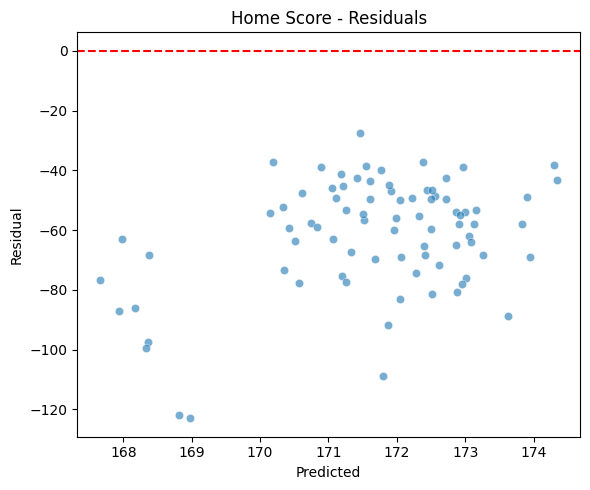

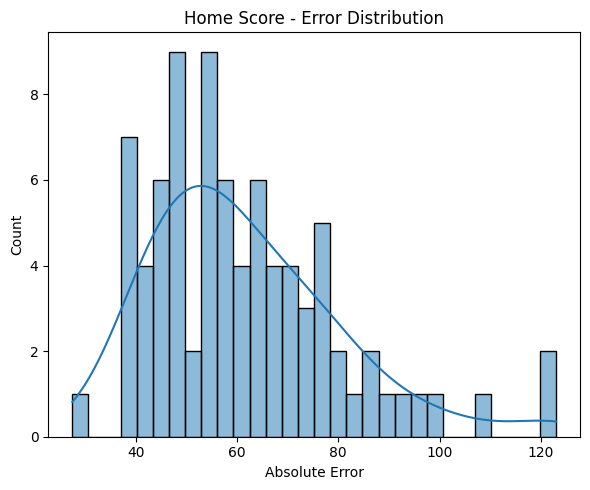

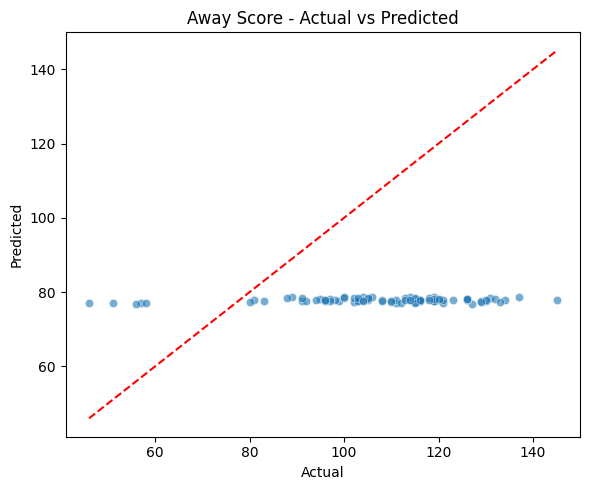

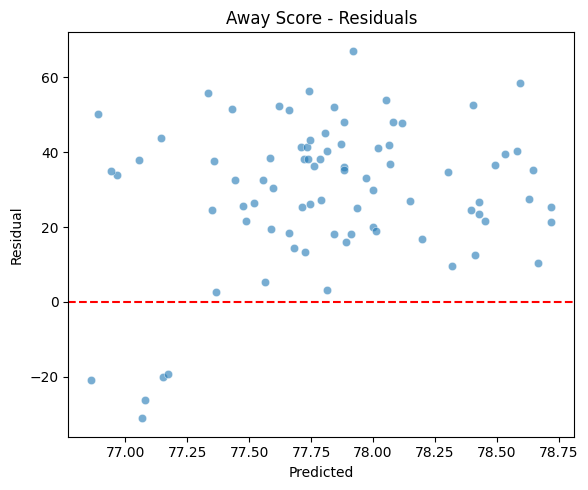

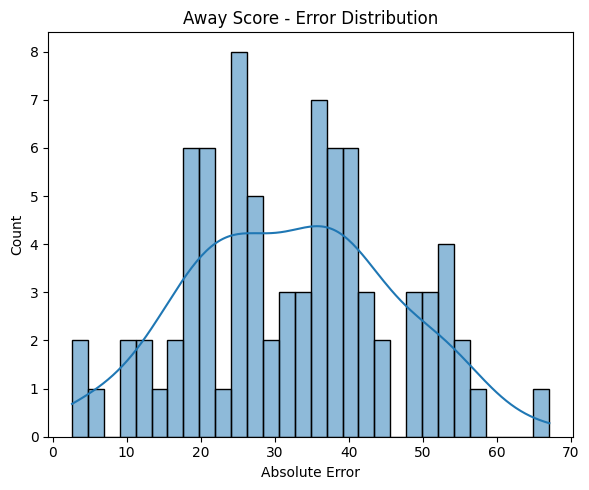

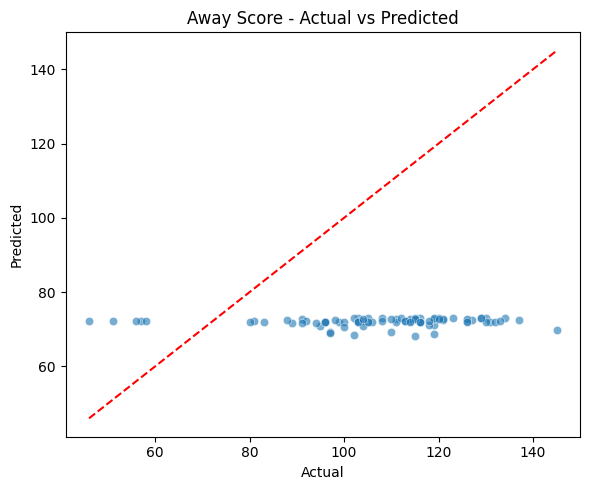

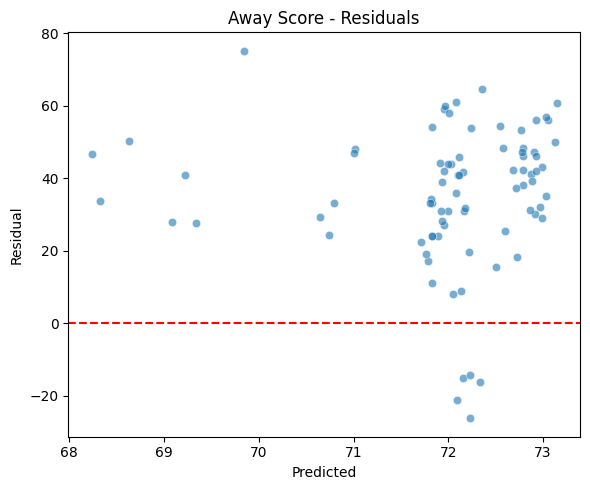

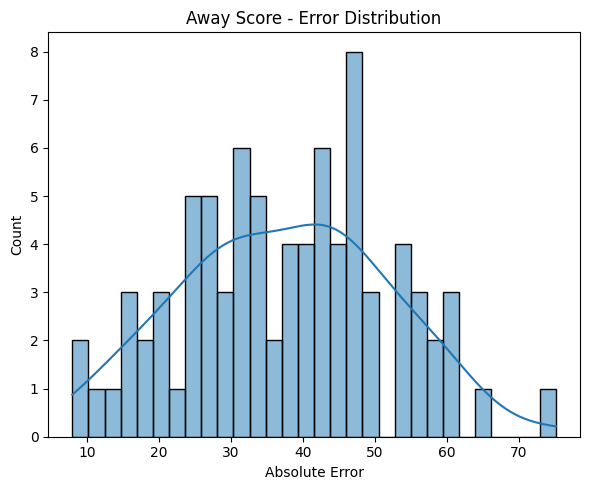

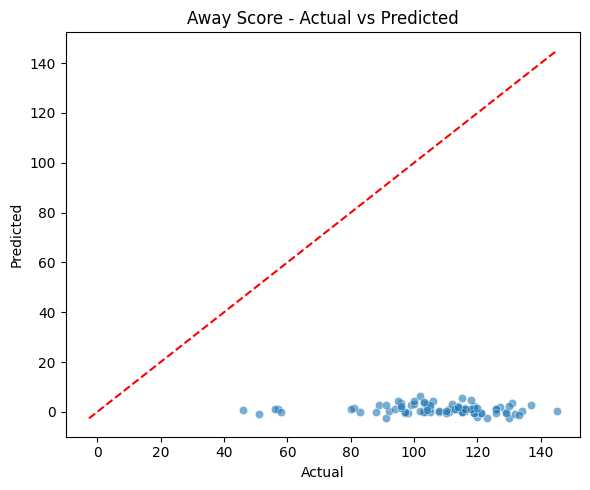

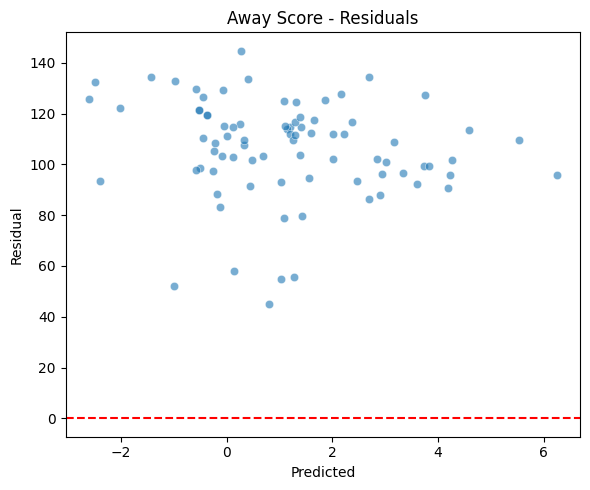

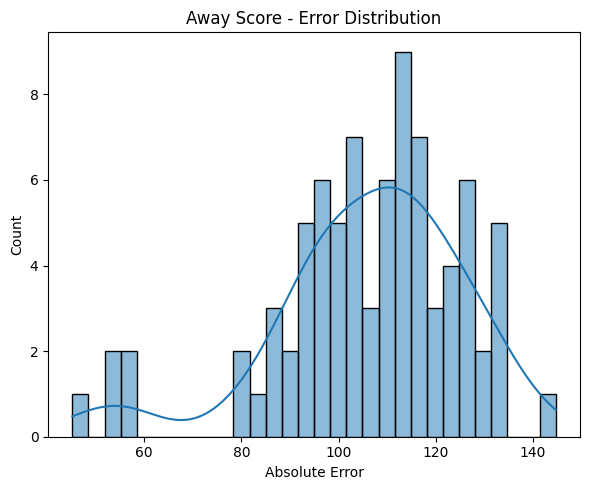

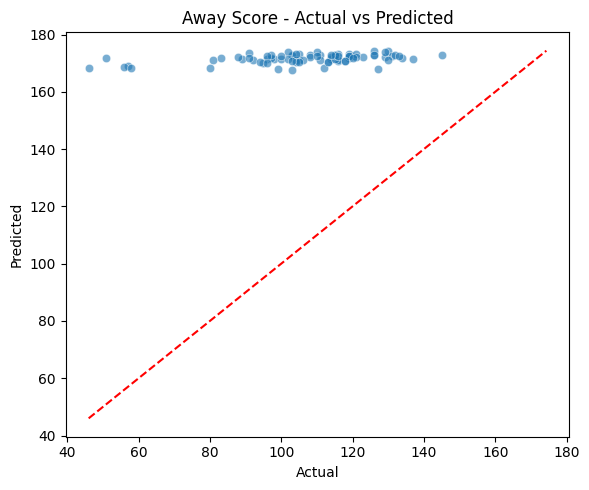

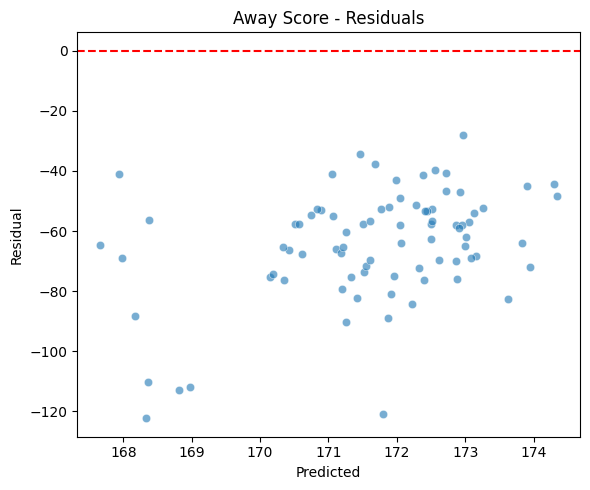

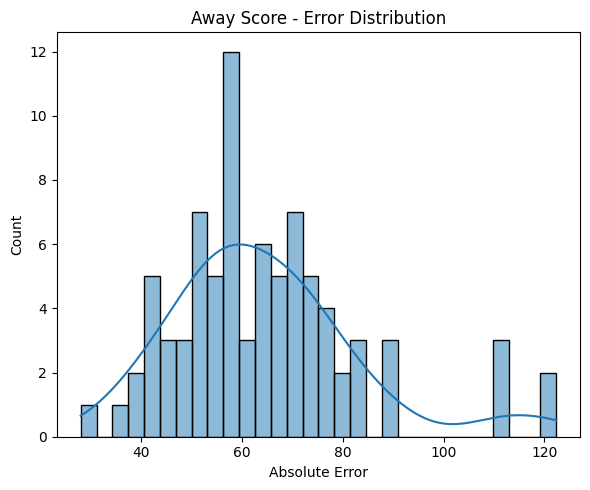


Prediction pipeline with enhanced features completed!


In [33]:
# Cell 16: Integrated Prediction Pipeline with Visualizations
import os
import re
import math
import pytz
import joblib
import traceback
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from pathlib import Path
from sqlalchemy import create_engine
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Global configuration & paths
MODELS_DIR = Path(os.getcwd()) / "models"
MODELS_DIR.mkdir(exist_ok=True)
PREGAME_MODEL_PATH = MODELS_DIR / "pregame_model.pkl"

# Add backend/models to sys.path so that NBAFeatureEngine can be imported
import sys
project_root = Path().resolve().parent  # parent directory of current directory
models_path = project_root / 'backend' / 'models'
sys.path.append(str(models_path))

# Import NBAFeatureEngine from features.py
try:
    from features import NBAFeatureEngine, PredictionUncertaintyEstimator, EnsembleWeightVisualizer
    feature_engine = NBAFeatureEngine(debug=True)
    uncertainty_estimator = PredictionUncertaintyEstimator()
    ensemble_visualizer = EnsembleWeightVisualizer()
    print("Successfully imported NBAFeatureEngine and related components")
except ImportError as e:
    print(f"Could not import NBAFeatureEngine: {e}. Using local functions instead.")
    feature_engine = None
    uncertainty_estimator = None
    ensemble_visualizer = None

# Create SQLAlchemy engine if not defined (assumes DATABASE_URL loaded in Cell 1)
if 'engine' not in globals():
    DATABASE_URL = os.getenv("DATABASE_URL")
    if DATABASE_URL:
        try:
            engine = create_engine(DATABASE_URL)
            print("Engine created successfully in Cell 16.")
        except Exception as e:
            print(f"Error creating engine: {e}")
            engine = None
    else:
        print("DATABASE_URL not found in environment variables.")
        engine = None

# --------------------- Local Helper Functions ---------------------
def fetch_upcoming_games_16(days_window=2):
    """Fetches upcoming games from Supabase (or returns sample data)."""
    pacific_tz = pytz.timezone("America/Los_Angeles")
    now_pt = datetime.now(pacific_tz)
    start_date = (now_pt - timedelta(days=1)).date()
    end_date = (now_pt + timedelta(days=days_window)).date()
    cutoff_hour = 21
    start_ts = pacific_tz.localize(datetime.combine(start_date, datetime.min.time().replace(hour=cutoff_hour))).astimezone(pytz.UTC).isoformat()
    end_ts = pacific_tz.localize(datetime.combine(end_date, datetime.min.time().replace(hour=cutoff_hour))).astimezone(pytz.UTC).isoformat()
    print(f"Fetching upcoming games from {start_date} to {end_date} (9pm PT window)...")
    try:
        response = supabase.table("nba_game_schedule")\
        .select("*")\
        .gte("scheduled_time", datetime.now().strftime('%Y-%m-%d'))\
        .execute()
        data = response.data
        if not data:
            print("No upcoming games found.")
            return pd.DataFrame()
        games_df = pd.DataFrame(data)
        if "scheduled_time" in games_df.columns:
            games_df["scheduled_time"] = pd.to_datetime(games_df["scheduled_time"])
            games_df["game_time_pt"] = games_df["scheduled_time"].dt.tz_convert(pacific_tz)
            games_df["game_date"] = games_df["game_time_pt"].dt.date
        for col in ["home_team", "away_team"]:
            games_df[col] = games_df[col].astype(str)
        print(f"Found {len(games_df)} upcoming games.")
        return games_df
    except Exception as e:
        print(f"Error fetching upcoming games: {e}")
        traceback.print_exc()
        return pd.DataFrame()
    
def parse_moneyline_16(moneyline_str):
    """
    Parse a 'moneyline_clean' string into a dict with home/away moneyline odds.
    Example format: "Phoenix Suns -155 / Milwaukee Bucks +130"
    """
    if not moneyline_str or moneyline_str == 'EMPTY':
        return {'home': -110, 'away': -110}
    
    print(f"Parsing moneyline: '{moneyline_str}'")
    
    # Updated pattern to match "Team Name +/-XXX / Team Name +/-XXX"
    pattern = r'([^/]+)([\+\-]\d+)\s*\/\s*([^/]+)([\+\-]\d+)'
    match = re.search(pattern, moneyline_str)
    
    if match:
        home_team = match.group(1).strip()
        home_line = int(match.group(2))
        away_team = match.group(3).strip()
        away_line = int(match.group(4))
        print(f"  Extracted: Home ({home_team}): {home_line}, Away ({away_team}): {away_line}")
        return {'home': home_line, 'away': away_line}
    
    print(f"  Failed to parse moneyline")
    return {'home': -110, 'away': -110}

def parse_spread_16(spread_str):
    """
    Parse a 'spread_clean' string into a dict with home/away spreads.
    Example format: "Phoenix Suns -3.0 / Milwaukee Bucks +3.0"
    """
    if not spread_str or spread_str == 'EMPTY':
        return {'home': 0, 'away': 0, 'home_odds': -110, 'away_odds': -110}
    
    print(f"Parsing spread: '{spread_str}'")
    
    # Updated pattern to match "Team Name +/-X.X / Team Name +/-X.X"
    pattern = r'([^/]+)([\+\-][\d\.]+)\s*\/\s*([^/]+)([\+\-][\d\.]+)'
    match = re.search(pattern, spread_str)
    
    if match:
        home_team = match.group(1).strip()
        home_spread = float(match.group(2))
        away_team = match.group(3).strip()
        away_spread = float(match.group(4))
        print(f"  Extracted: Home ({home_team}): {home_spread}, Away ({away_team}): {away_spread}")
        return {
            'home': home_spread,
            'away': away_spread,
            'home_odds': -110,  # Default odds when not available
            'away_odds': -110   # Default odds when not available
        }
    
    print(f"  Failed to parse spread")
    return {'home': 0, 'away': 0, 'home_odds': -110, 'away_odds': -110}

def parse_total_16(total_str):
    """
    Parse a 'total_clean' string into a dict with the O/U line.
    Example format: "Over 223.5 / Under 223.5"
    """
    if not total_str or total_str == 'EMPTY':
        return {'line': 220, 'over_odds': -110, 'under_odds': -110}
    
    print(f"Parsing total: '{total_str}'")
    
    # Updated pattern to match "Over XXX.X / Under XXX.X"
    pattern = r'Over\s+([\d\.]+)\s*\/\s*Under\s+([\d\.]+)'
    match = re.search(pattern, total_str)
    
    if match:
        over_line = float(match.group(1))
        under_line = float(match.group(2))
        # Typically these lines should be the same value
        line = over_line
        print(f"  Extracted: Line: {line} (Over: {over_line}, Under: {under_line})")
        return {'line': line, 'over_odds': -110, 'under_odds': -110}
    
    print(f"  Failed to parse total")
    return {'line': 220, 'over_odds': -110, 'under_odds': -110}

def fetch_betting_odds_16(game_ids):
    """Fetches betting odds for given game IDs from Supabase."""
    start_date_str = (datetime.now()).strftime('%Y-%m-%d')
    end_date_str = (datetime.now() + timedelta(days=2)).strftime('%Y-%m-%d')
    
    if not game_ids:
        return {}
        
    try:
        # Query the nba_game_schedule table
        response = supabase.table("nba_game_schedule") \
        .select("*") \
        .gte("game_date", start_date_str) \
        .lt("game_date", end_date_str) \
        .execute()

        data = response.data
        if not data:
            print("No betting odds data available from 'nba_game_schedule'.")
            return {}

        df = pd.DataFrame(data)
        odds_dict = {}  # This will map game_id -> betting odds
        
        # Debug the first row to see structure
        if len(df) > 0:
            print(f"Sample first row from nba_game_schedule:")
            first_row = df.iloc[0]
            for key, value in first_row.items():
                print(f"  {key}: {value}")
        
        for _, row in df.iterrows():
            game_id = str(row.get('game_id', ''))
            
            if not game_id or game_id not in game_ids:
                continue
                
            # Parse odds information
            moneyline_raw = row.get('moneyline_clean', 'EMPTY')
            spread_raw = row.get('spread_clean', 'EMPTY')
            total_raw = row.get('total_clean', 'EMPTY')
            
            # Only process games with actual betting data
            if moneyline_raw == 'EMPTY' and spread_raw == 'EMPTY' and total_raw == 'EMPTY':
                continue
                
            # Parse the betting strings into structured data
            moneyline = parse_moneyline_16(moneyline_raw) 
            spread = parse_spread_16(spread_raw)
            total = parse_total_16(total_raw)
            
            # Store the parsed data in the dictionary with game_id as key
            odds_dict[game_id] = {
                'moneyline': moneyline,
                'spread': spread,
                'total': total
            }
            
            print(f"Added betting odds for game {game_id}: spread:{spread}, total:{total}")
            
        # Debug the final dictionary
        print(f"Final odds dictionary has {len(odds_dict)} games")
        print(f"Game IDs in odds dictionary: {list(odds_dict.keys())}")
        
        return odds_dict

    except Exception as e:
        print(f"Error in fetch_betting_odds_16: {e}")
        traceback.print_exc()
        return {}

# --------------------- Enhanced Team Metrics Generation ---------------------
def calculate_team_metrics_enhanced(historical_df):
    """
    Enhanced team metrics calculation using NBAFeatureEngine.
    Falls back to original implementation if necessary.
    """
    if feature_engine is not None:
        try:
            print("Using NBAFeatureEngine for comprehensive team metrics calculation...")
            return feature_engine.create_team_metrics(historical_df)
        except Exception as e:
            print(f"Error using NBAFeatureEngine for team metrics: {e}")
            # Fall back to original implementation
    
    # If we're here, either feature_engine is None or there was an error
    print("Using original implementation for team metrics...")
    
    try:
        # Check if the calculate_team_metrics function exists in globals
        if 'calculate_team_metrics' in globals():
            return calculate_team_metrics(historical_df)
        else:
            # Basic implementation if the original function isn't available
            all_teams = set(historical_df['home_team'].unique()) | set(historical_df['away_team'].unique())
            team_metrics = pd.DataFrame({'team': list(all_teams)})
            
            # Calculate win percentage
            for team in all_teams:
                home_games = historical_df[historical_df['home_team'] == team]
                away_games = historical_df[historical_df['away_team'] == team]
                
                if len(home_games) + len(away_games) > 0:
                    # Calculate win percentage
                    home_wins = sum(home_games['home_score'] > home_games['away_score']) if len(home_games) > 0 else 0
                    away_wins = sum(away_games['away_score'] > away_games['home_score']) if len(away_games) > 0 else 0
                    total_games = len(home_games) + len(away_games)
                    win_pct = (home_wins + away_wins) / total_games if total_games > 0 else 0.5
                    
                    # Calculate average points
                    home_pts = home_games['home_score'].mean() if len(home_games) > 0 else 0
                    away_pts = away_games['away_score'].mean() if len(away_games) > 0 else 0
                    pts_per_game = (home_pts * len(home_games) + away_pts * len(away_games)) / total_games if total_games > 0 else 0
                    
                    # Calculate average opponent points
                    home_opp = home_games['away_score'].mean() if len(home_games) > 0 else 0
                    away_opp = away_games['home_score'].mean() if len(away_games) > 0 else 0
                    opp_pts_per_game = (home_opp * len(home_games) + away_opp * len(away_games)) / total_games if total_games > 0 else 0
                    
                    # Update metrics
                    team_metrics.loc[team_metrics['team'] == team, 'win_pct'] = win_pct
                    team_metrics.loc[team_metrics['team'] == team, 'pts_per_game'] = pts_per_game
                    team_metrics.loc[team_metrics['team'] == team, 'opp_pts_per_game'] = opp_pts_per_game
                    team_metrics.loc[team_metrics['team'] == team, 'net_rating'] = pts_per_game - opp_pts_per_game
                else:
                    # Set default values if no games
                    team_metrics.loc[team_metrics['team'] == team, 'win_pct'] = 0.5
                    team_metrics.loc[team_metrics['team'] == team, 'pts_per_game'] = 110.0
                    team_metrics.loc[team_metrics['team'] == team, 'opp_pts_per_game'] = 110.0
                    team_metrics.loc[team_metrics['team'] == team, 'net_rating'] = 0.0
            
            # Add compatibility columns for NBAFeatureEngine expected columns
            team_metrics['offensive_rating'] = team_metrics['pts_per_game']
            team_metrics['defensive_rating'] = team_metrics['opp_pts_per_game']
            
            return team_metrics
    except Exception as e:
        print(f"Error in basic team metrics calculation: {e}")
        traceback.print_exc()
        return pd.DataFrame({'team': list(set(historical_df['home_team'].unique()) | set(historical_df['away_team'].unique()))})

def patch_team_metrics(team_metrics, historical_df):
    """
    Adds missing metrics columns like momentum_score, form_win_pct, etc.
    Uses NBAFeatureEngine advanced calculations when available.
    """
    if 'form_win_pct' not in team_metrics.columns:
        # Try using NBAFeatureEngine for advanced metrics
        if feature_engine is not None:
            try:
                print("Using NBAFeatureEngine to enhance team metrics...")
                enhanced_metrics = feature_engine.create_team_metrics(historical_df)
                
                # Merge the enhanced metrics with the original metrics
                team_metrics = pd.merge(
                    team_metrics, 
                    enhanced_metrics[['team', 'form_win_pct', 'current_streak', 'momentum_score', 'form_string']], 
                    on='team', 
                    how='left'
                )
                return team_metrics
            except Exception as e:
                print(f"Error enhancing metrics with NBAFeatureEngine: {e}")
                print("Falling back to manual calculation...")
        
        # Original implementation (when NBAFeatureEngine is not available)
        print("Patching team metrics to add form_win_pct, current_streak, and momentum_score...")
        team_metrics['form_win_pct'] = 0.5
        team_metrics['current_streak'] = 0
        team_metrics['momentum_score'] = 0.0
        for team in team_metrics['team']:
            home_games = historical_df[historical_df['home_team'] == team]
            away_games = historical_df[historical_df['away_team'] == team]
            all_games = pd.concat([home_games, away_games]).sort_values('game_date', ascending=False).head(5)
            if not all_games.empty:
                wins = 0
                form_string = ""
                streak = 0
                current_sign = 0
                for _, game in all_games.iterrows():
                    if game['home_team'] == team:
                        is_win = game['home_score'] > game['away_score']
                    else:
                        is_win = game['away_score'] > game['home_score']
                    if is_win:
                        form_string += "W"
                        wins += 1
                        if current_sign == 1:
                            streak += 1
                        else:
                            current_sign = 1
                            streak = 1
                    else:
                        form_string += "L"
                        if current_sign == -1:
                            streak -= 1
                        else:
                            current_sign = -1
                            streak = -1
                team_metrics.loc[team_metrics['team'] == team, 'form_win_pct'] = wins / len(all_games)
                team_metrics.loc[team_metrics['team'] == team, 'current_streak'] = streak
                momentum = 0
                for i, char in enumerate(form_string):
                    weight = (5 - i) * 2
                    momentum += weight if char == 'W' else -weight
                momentum_normalized = momentum / 30 * 10  # Normalize to -10 to 10 scale
                team_metrics.loc[team_metrics['team'] == team, 'momentum_score'] = momentum_normalized
                team_metrics.loc[team_metrics['team'] == team, 'form_string'] = form_string
                
    return team_metrics

# --------------------- Enhanced Prediction Function with NBAFeatureEngine ---------------------
def predict_upcoming_game(game, historical_df, models, team_metrics_df=None):
    """
    Predicts scores and win probability for a single upcoming game.
    Uses NBAFeatureEngine comprehensive feature engineering when available.
    
    Args:
        game: Dictionary or DataFrame row with game information
        historical_df: DataFrame with historical games
        models: Dictionary of trained prediction models
        team_metrics_df: DataFrame with team metrics (optional)
        
    Returns:
        Dictionary with prediction results
    """
    try:
        if isinstance(game, pd.Series):
            game = game.to_dict()
        
        # Ensure game_id exists
        if not game.get('game_id'):
            game['game_id'] = f"{game['home_team'].replace(' ', '')}_vs_{game['away_team'].replace(' ', '')}_{pd.to_datetime(game['game_date']).strftime('%Y%m%d')}"
        
        home_team = game['home_team']
        away_team = game['away_team']
        game_date = pd.to_datetime(game['game_date'])
        print(f"Predicting for {home_team} vs {away_team} on {game_date.date()}...")
        
        # Create upcoming DataFrame for the game
        upcoming_df = pd.DataFrame([{
            'game_id': game['game_id'],
            'game_date': game_date,
            'home_team': home_team,
            'away_team': away_team,
            'current_quarter': game.get('current_quarter', 0)  # Default to 0 (pregame)
        }])
        
        # Calculate team metrics if not provided
        if team_metrics_df is None or team_metrics_df.empty:
            print("Calculating team metrics...")
            team_metrics_df = calculate_team_metrics_enhanced(historical_df)
            team_metrics_df = patch_team_metrics(team_metrics_df, historical_df)
        
        # Generate features with enhanced error handling
        if feature_engine is not None:
            try:
                print("Using NBAFeatureEngine for comprehensive feature generation...")
                
                # Step 1: Generate pregame features
                pregame_df = feature_engine.generate_pregame_features(
                    upcoming_df, 
                    historical_df, 
                    team_metrics_df
                )
                
                # Check if generate_pregame_features returned empty DataFrame
                if pregame_df.empty:
                    # Use generate_all_features approach instead
                    pregame_df = upcoming_df.copy()
                    
                    # Add team history features
                    pregame_df = feature_engine.add_team_history_features(pregame_df)
                
                # Debug the historical data recency before adding rest features
                print("\n=== DEBUGGING REST DAYS CALCULATION ===")
                print("Checking historical data recency:")
                if not historical_df.empty and 'game_date' in historical_df.columns:
                    most_recent = historical_df['game_date'].max()
                    oldest = historical_df['game_date'].min()
                    print(f"Historical data range: {oldest} to {most_recent}")
                    print(f"Current game date: {game_date}")
                    
                    # Check for team name matches
                    print(f"\nChecking team matches in historical data:")
                    if feature_engine.normalize_team_name:
                        norm_home = feature_engine.normalize_team_name(home_team)
                        norm_away = feature_engine.normalize_team_name(away_team)
                        print(f"Normalized names: {home_team} -> {norm_home}, {away_team} -> {norm_away}")
                        home_team_check = norm_home
                        away_team_check = norm_away
                    else:
                        home_team_check = home_team
                        away_team_check = away_team
                    
                    # Look for exact matches
                    home_games_exact = historical_df[
                        (historical_df['home_team'] == home_team_check) | 
                        (historical_df['away_team'] == home_team_check)
                    ]
                    away_games_exact = historical_df[
                        (historical_df['home_team'] == away_team_check) | 
                        (historical_df['away_team'] == away_team_check)
                    ]
                    
                    print(f"Exact match: Found {len(home_games_exact)} games for {home_team}")
                    if not home_games_exact.empty:
                        print(f"Most recent game: {home_games_exact['game_date'].max()}")
                        print(f"Days since last game: {(game_date - home_games_exact['game_date'].max()).days}")
                    
                    print(f"Exact match: Found {len(away_games_exact)} games for {away_team}")
                    if not away_games_exact.empty:
                        print(f"Most recent game: {away_games_exact['game_date'].max()}")
                        print(f"Days since last game: {(game_date - away_games_exact['game_date'].max()).days}")
                    
                    # Check for case-insensitive matches as fallback
                    home_games_case = historical_df[
                        (historical_df['home_team'].str.lower() == home_team_check.lower()) | 
                        (historical_df['away_team'].str.lower() == home_team_check.lower())
                    ]
                    away_games_case = historical_df[
                        (historical_df['home_team'].str.lower() == away_team_check.lower()) | 
                        (historical_df['away_team'].str.lower() == away_team_check.lower())
                    ]
                    
                    if len(home_games_case) != len(home_games_exact):
                        print(f"Case-insensitive match: Found {len(home_games_case)} games for {home_team}")
                    if len(away_games_case) != len(away_games_exact):
                        print(f"Case-insensitive match: Found {len(away_games_case)} games for {away_team}")
                print("=== END DEBUG ===\n")
                
                # Step 4: Add rest features
                print(f"Columns before rest features: {[col for col in pregame_df.columns if 'rest' in col]}")
                pregame_df = feature_engine.add_rest_features(pregame_df, historical_df)
                print(f"Columns after rest features: {[col for col in pregame_df.columns if 'rest' in col]}")
                
                # After the line: pregame_df = feature_engine.add_rest_features(pregame_df, historical_df)
                # Add this code to cap rest days at a realistic maximum:
                print("Applying realistic cap to rest days...")
                MAX_REST_DAYS = 4  # NBA teams rarely have more than 4 days between games

                if 'rest_days_home' in pregame_df.columns:
                    # Cap rest days at a realistic maximum
                    pregame_df['rest_days_home'] = pregame_df['rest_days_home'].apply(lambda x: min(float(x), MAX_REST_DAYS))
                    
                if 'rest_days_away' in pregame_df.columns:
                    # Cap rest days at a realistic maximum
                    pregame_df['rest_days_away'] = pregame_df['rest_days_away'].apply(lambda x: min(float(x), MAX_REST_DAYS))
                    
                # Update rest advantage based on capped values
                if 'rest_days_home' in pregame_df.columns and 'rest_days_away' in pregame_df.columns:
                    pregame_df['rest_advantage'] = pregame_df['rest_days_home'] - pregame_df['rest_days_away']

                # Ensure column standardization
                if 'rest_days_home' in pregame_df.columns and 'home_rest_days' not in pregame_df.columns:
                    pregame_df['home_rest_days'] = pregame_df['rest_days_home']
                    
                if 'rest_days_away' in pregame_df.columns and 'away_rest_days' not in pregame_df.columns:
                    pregame_df['away_rest_days'] = pregame_df['rest_days_away']
                
                # Step 5: Add advanced features
                pregame_df = feature_engine.integrate_advanced_features(pregame_df)
                
                # Ensure form and momentum differentials are properly calculated
                if 'home_form_win_pct' in pregame_df.columns and 'away_form_win_pct' in pregame_df.columns:
                    pregame_df['form_win_pct_diff'] = pregame_df['home_form_win_pct'] - pregame_df['away_form_win_pct']
                
                if 'home_momentum_score' in pregame_df.columns and 'away_momentum_score' in pregame_df.columns:
                    pregame_df['momentum_score_diff'] = pregame_df['home_momentum_score'] - pregame_df['away_momentum_score']
                    
                # Ensure momentum_advantage is calculated correctly
                if 'home_momentum_score' in pregame_df.columns and 'away_momentum_score' in pregame_df.columns:
                    pregame_df['momentum_advantage'] = pregame_df['home_momentum_score'] - pregame_df['away_momentum_score']
                
                print(f"Generated comprehensive feature set with {len(pregame_df.columns)} columns")
                
            except Exception as e:
                print(f"Error in NBAFeatureEngine feature generation: {e}")
                traceback.print_exc()
                print("Falling back to basic feature generation...")
                
                # Create a basic feature set with default values
                pregame_df = pd.DataFrame([{
                    'game_id': game['game_id'],
                    'game_date': game_date,
                    'home_team': home_team,
                    'away_team': away_team,
                    'current_quarter': game.get('current_quarter', 0),
                    'home_rest_days': 2.0,
                    'away_rest_days': 2.0,
                    'home_offensive_rating': 110.0,
                    'away_offensive_rating': 110.0,
                    'home_defensive_rating': 110.0,
                    'away_defensive_rating': 110.0,
                    'home_form_win_pct': 0.5,
                    'away_form_win_pct': 0.5,
                    'home_current_streak': 0,
                    'away_current_streak': 0,
                    'home_momentum_score': 0.0,
                    'away_momentum_score': 0.0
                }])
                
                # Add extra columns to ensure model compatibility
                expected_feature_count = 104
                for i in range(expected_feature_count):
                    feature_name = f"placeholder_feature_{i}"
                    if feature_name not in pregame_df.columns:
                        pregame_df[feature_name] = 0.0
        else:
            # Basic feature generation when NBAFeatureEngine is not available
            print("NBAFeatureEngine not available, using basic feature generation...")
            
            # Create basic features
            pregame_df = pd.DataFrame([{
                'game_id': game['game_id'],
                'game_date': game_date,
                'home_team': home_team,
                'away_team': away_team,
                'current_quarter': game.get('current_quarter', 0),
                'home_rest_days': 2.0,
                'away_rest_days': 2.0
            }])
            
            # Add team metrics
            for team, prefix in [(home_team, 'home_'), (away_team, 'away_')]:
                # Find team metrics (case-insensitive match)
                team_row = team_metrics_df[team_metrics_df['team'].str.lower() == team.lower()]
                if not team_row.empty:
                    for col in team_metrics_df.columns:
                        if col != 'team':
                            col_name = f"{prefix}{col}"
                            pregame_df[col_name] = team_row.iloc[0][col]
            
            # Add feature placeholders to reach expected count
            expected_feature_count = 104
            for i in range(expected_feature_count):
                feature_name = f"placeholder_feature_{i}"
                if feature_name not in pregame_df.columns:
                    pregame_df[feature_name] = 0.0
        
        # Finalize features for prediction
        if feature_engine is not None and hasattr(feature_engine, 'finalize_features_for_prediction'):
            # Instead of using 104 as default, let's use a larger number to keep all important features
            expected_feature_count = 175  # Set this higher than your current feature count
            
            # Check if any model has feature_names_in_ to determine exact count
            for model_info in models.values():
                model = model_info['model'] if isinstance(model_info, dict) else model_info
                if hasattr(model, 'feature_names_in_'):
                    # Use the maximum between current features and model features
                    expected_feature_count = max(expected_feature_count, len(model.feature_names_in_))
                    break
                    
            print(f"Finalizing features with expanded count: {expected_feature_count}")
            pregame_df = feature_engine.finalize_features_for_prediction(pregame_df, expected_feature_count)
        
        # Extract feature columns for prediction
        exclude_cols = ['game_id', 'game_date', 'home_team', 'away_team', 
                        'home_score', 'away_score', 'point_diff', 'total_score', 
                        'win_probability']
        feature_cols = [col for col in pregame_df.columns if col not in exclude_cols]
        
        # Convert feature matrix to numeric (replace empty strings with NaN)
        X_pred = pregame_df[feature_cols].copy()
        X_pred = X_pred.apply(pd.to_numeric, errors='coerce').replace("", np.nan)
        
        # Impute missing values
        imputer = SimpleImputer(strategy='median')
        X_transformed = imputer.fit_transform(X_pred)
        
        # Use the columns from X_pred up to the number of columns returned
        X_pred_imputed = pd.DataFrame(X_transformed, columns=X_pred.columns[:X_transformed.shape[1]])
        
        # Make predictions for each target
        predictions = {}
        for target in ['home_score', 'away_score', 'point_diff', 'total_score']:
            if target not in models:
                print(f"Model for {target} not available.")
                predictions[target] = 100.0 if target in ['home_score', 'away_score', 'total_score'] else 0.0
                continue
            
            model = models[target]['model'] if isinstance(models[target], dict) else models[target]
            
            try:
                # Ensure model has the right features
                if hasattr(model, 'feature_names_in_'):
                    model_features = list(model.feature_names_in_)
                    for feat in model_features:
                        if feat not in X_pred_imputed.columns:
                            X_pred_imputed[feat] = 0.0
                    X_model = X_pred_imputed[model_features].copy()
                else:
                    X_model = X_pred_imputed.copy()
                
                # Make prediction
                y_pred = model.predict(X_model)[0]
                predictions[target] = float(y_pred)
                print(f"Predicted {target}: {y_pred:.1f}")
            except Exception as e:
                print(f"Error predicting {target}: {e}")
                traceback.print_exc()
                predictions[target] = 100.0 if target in ['home_score', 'away_score', 'total_score'] else 0.0
        
        # Calculate derived predictions if needed
        if predictions.get('home_score') is not None and predictions.get('away_score') is not None:
            home_score = predictions['home_score']
            away_score = predictions['away_score']
            predictions['point_diff'] = predictions.get('point_diff') or (home_score - away_score)
            predictions['total_score'] = predictions.get('total_score') or (home_score + away_score)
        
        # Calculate win probability
        diff = predictions.get('point_diff', 0)
        win_prob = 1 / (1 + np.exp(-0.15 * diff))
        
        # Create base result dictionary
        result = {
            'game_id': game.get('game_id'),
            'game_date': game_date,
            'home_team': home_team,
            'away_team': away_team,
            'predicted_home_score': round(float(predictions.get('home_score') or 0), 1),
            'predicted_away_score': round(float(predictions.get('away_score') or 0), 1),
            'predicted_point_diff': round(float(predictions.get('point_diff') or 0), 1),
            'predicted_total_score': round(float(predictions.get('total_score') or 0), 1),
            'win_probability': round(float(win_prob or 0.5), 3),
        }
        
        # Add rest days from features if available
        if 'home_rest_days' in pregame_df.columns:
            result['home_rest_days'] = float(pregame_df['home_rest_days'].iloc[0])
        if 'away_rest_days' in pregame_df.columns:
            result['away_rest_days'] = float(pregame_df['away_rest_days'].iloc[0])
        
        # Add prediction uncertainty if the estimator is available
        if uncertainty_estimator is not None:
            try:
                print("Calculating prediction uncertainty...")
                current_quarter = int(pregame_df['current_quarter'].iloc[0])
                score_diff = float(pregame_df.get('score_differential', pd.Series([0])).iloc[0])
                
                # Get momentum if available
                momentum = 0.0
                if 'cumulative_momentum' in pregame_df.columns:
                    momentum = float(pregame_df['cumulative_momentum'].iloc[0])
                elif 'momentum_score' in pregame_df.columns:
                    momentum = float(pregame_df['momentum_score'].iloc[0]) / 10.0  # Normalize from -10:10 to -1:1
                
                # Calculate confidence intervals
                lower, upper, interval_width = uncertainty_estimator.calculate_prediction_interval(
                    result['predicted_home_score'], 
                    current_quarter,
                    score_diff,
                    momentum
                )
                
                # Add to result
                result['lower_bound'] = round(lower, 1)
                result['upper_bound'] = round(upper, 1)
                result['prediction_confidence'] = round(1.0 - (interval_width / 60.0), 2)  # Simple normalization
                
                print(f"Prediction confidence: {result['prediction_confidence']:.2f}")
            except Exception as e:
                print(f"Error calculating uncertainty: {e}")
                # No fallback needed as these are optional fields
        
        print(f"Prediction: {home_team} {result['predicted_home_score']} - {result['predicted_away_score']} {away_team} (Win Prob: {win_prob*100:.1f}%)")
        return result
        
    except Exception as e:
        print(f"Error in predict_upcoming_game: {e}")
        traceback.print_exc()
        return {
            'game_id': game.get('game_id', 'unknown'),
            'game_date': pd.to_datetime(game.get('game_date', datetime.now())),
            'home_team': game.get('home_team', ''),
            'away_team': game.get('away_team', ''),
            'predicted_home_score': 100.0,
            'predicted_away_score': 100.0,
            'predicted_point_diff': 0.0,
            'predicted_total_score': 200.0,
            'win_probability': 0.5
        }

# --------------------- Enhanced Feature Row Builder ---------------------
def build_enhanced_feature_row(home_team, away_team, team_metrics_df, row):
    """
    Build a rich feature row for a given matchup using team metrics.
    Uses NBAFeatureEngine when available for enhanced features.
    
    Returns:
        Dictionary with key features for the matchup
    """
    # Start with basic feature values
    feature_row = {
        'home_pts_per_game': 110.0,
        'away_pts_per_game': 108.0,
        'home_rest_days': row.get('home_rest_days', 2.0),
        'away_rest_days': row.get('away_rest_days', 2.0),
        'home_win_pct': 0.5,
        'away_win_pct': 0.5,
        'home_offensive_rating': 110.0,
        'away_offensive_rating': 108.0,
        'home_defensive_rating': 110.0,
        'away_defensive_rating': 110.0,
        'home_net_rating': 0.0,
        'away_net_rating': 0.0,
        'net_rating_diff': 0.0
    }
    
    # Try to use NBAFeatureEngine to normalize team names
    if feature_engine is not None:
        try:
            # Normalize team names for consistent lookup
            home_normalized = feature_engine.normalize_team_name(home_team)
            away_normalized = feature_engine.normalize_team_name(away_team)
            
            # Look up in team metrics with normalized names
            home_rec = team_metrics_df[team_metrics_df['team'].str.lower() == home_normalized.lower()]
            away_rec = team_metrics_df[team_metrics_df['team'].str.lower() == away_normalized.lower()]
        except Exception as e:
            print(f"Error normalizing team names: {e}")
            # Fall back to default lookup
            home_rec = team_metrics_df[team_metrics_df['team'].str.lower() == home_team.lower()]
            away_rec = team_metrics_df[team_metrics_df['team'].str.lower() == away_team.lower()]
    else:
        # Use case-insensitive matching for team names
        home_rec = team_metrics_df[team_metrics_df['team'].str.lower() == home_team.lower()]
        away_rec = team_metrics_df[team_metrics_df['team'].str.lower() == away_team.lower()]
    
    # Add home team metrics
    if not home_rec.empty:
        rec = home_rec.iloc[0]
        # Basic metrics
        feature_row['home_pts_per_game'] = rec.get('pts_per_game', 110.0)
        feature_row['home_win_pct'] = rec.get('win_pct', 0.5)
        feature_row['home_offensive_rating'] = rec.get('offensive_rating', 110.0)
        feature_row['home_defensive_rating'] = rec.get('defensive_rating', 110.0)
        feature_row['home_net_rating'] = rec.get('net_rating', 0.0)
        
        # Add advanced metrics if available
        if 'form_win_pct' in rec:
            feature_row['home_form_win_pct'] = rec.get('form_win_pct', 0.5)
        if 'current_streak' in rec:
            feature_row['home_current_streak'] = rec.get('current_streak', 0)
        if 'momentum_score' in rec:
            feature_row['home_momentum_score'] = rec.get('momentum_score', 0.0)
        if 'form_string' in rec:
            feature_row['home_form_string'] = rec.get('form_string', '')
    
    # Add away team metrics
    if not away_rec.empty:
        rec = away_rec.iloc[0]
        # Basic metrics
        feature_row['away_pts_per_game'] = rec.get('pts_per_game', 108.0)
        feature_row['away_win_pct'] = rec.get('win_pct', 0.5)
        feature_row['away_offensive_rating'] = rec.get('offensive_rating', 108.0)
        feature_row['away_defensive_rating'] = rec.get('defensive_rating', 110.0)
        feature_row['away_net_rating'] = rec.get('net_rating', 0.0)
        
        # Add advanced metrics if available
        if 'form_win_pct' in rec:
            feature_row['away_form_win_pct'] = rec.get('form_win_pct', 0.5)
        if 'current_streak' in rec:
            feature_row['away_current_streak'] = rec.get('current_streak', 0)
        if 'momentum_score' in rec:
            feature_row['away_momentum_score'] = rec.get('momentum_score', 0.0)
        if 'form_string' in rec:
            feature_row['away_form_string'] = rec.get('form_string', '')
    
    # Calculate differential metrics
    feature_row['net_rating_diff'] = feature_row['home_net_rating'] - feature_row['away_net_rating']
    feature_row['offensive_rating_diff'] = feature_row['home_offensive_rating'] - feature_row['away_offensive_rating']
    feature_row['defensive_rating_diff'] = feature_row['home_defensive_rating'] - feature_row['away_defensive_rating']
    
    # Add form and momentum differentials if available
    if 'home_form_win_pct' in feature_row and 'away_form_win_pct' in feature_row:
        feature_row['form_win_pct_diff'] = feature_row['home_form_win_pct'] - feature_row['away_form_win_pct']
    if 'home_momentum_score' in feature_row and 'away_momentum_score' in feature_row:
        feature_row['momentum_score_diff'] = feature_row['home_momentum_score'] - feature_row['away_momentum_score']
    
    return feature_row

# --------------------- Prediction with Betting Integration ---------------------
def predict_games_with_betting_model(upcoming_games, team_metrics, models, historical_df, betting_threshold=2.0):
    """
    Predicts outcomes for all upcoming games with betting recommendations.
    Uses enhanced prediction function with NBAFeatureEngine.
    
    Args:
        upcoming_games: DataFrame with upcoming games
        team_metrics: DataFrame with team metrics
        models: Dictionary of prediction models
        historical_df: DataFrame with historical games
        betting_threshold: Threshold for betting recommendations
        
    Returns:
        Tuple of (predictions_list, betting_recommendations)
    """
    predictions_list = []
    betting_recommendations = []
    
    # Process each game
    for idx, game in upcoming_games.iterrows():
        try:
            # Make prediction
            pred = predict_upcoming_game(game, historical_df, models, team_metrics)
            if not pred:
                continue
                
            predictions_list.append(pred)
            
            # Generate betting recommendations
            recs = []
            
            # Spread recommendation
            if abs(pred['predicted_point_diff']) >= betting_threshold:
                favored = pred['home_team'] if pred['predicted_point_diff'] > 0 else pred['away_team']
                underdog = pred['away_team'] if pred['predicted_point_diff'] > 0 else pred['home_team']
                
                # Add confidence level if available
                if 'prediction_confidence' in pred:
                    confidence = pred['prediction_confidence']
                    strength = "Strong" if confidence > 0.7 else "Consider"
                    recs.append(f"{strength} bet on {favored} to cover the spread vs {underdog} (Edge: {abs(pred['predicted_point_diff']):.1f} pts)")
                else:
                    recs.append(f"Bet on {favored} to cover the spread (Edge: {abs(pred['predicted_point_diff']):.1f} pts)")
            
            # Total recommendation
            total_edge = pred['predicted_total_score'] - 220  # Using league average as baseline
            if abs(total_edge) >= betting_threshold:
                direction = "OVER" if total_edge > 0 else "UNDER"
                
                # Add confidence level if available
                if 'prediction_confidence' in pred:
                    confidence = pred['prediction_confidence']
                    strength = "Strong" if confidence > 0.7 else "Consider"
                    recs.append(f"{strength} bet {direction} (Edge: {abs(total_edge):.1f} pts)")
                else:
                    recs.append(f"Bet {direction} (Edge: {abs(total_edge):.1f} pts)")
            
            # Add recommendation about low confidence if applicable
            if 'prediction_confidence' in pred and pred['prediction_confidence'] < 0.5:
                recs.append(f"Low confidence prediction ({pred['prediction_confidence']:.2f}) - bet with caution")
            
            # Store recommendations
            betting_recommendations.append({
                'game_id': pred['game_id'],
                'recommendations': recs
            })
            
        except Exception as e:
            print(f"Error processing game {game.get('game_id', 'unknown')}: {e}")
            traceback.print_exc()
    
    return predictions_list, betting_recommendations

def calibrate_prediction_with_odds_16(prediction, odds_dict):
    """Calibrates a prediction with betting odds using a simple blend."""
    try:
        calibrated = dict(prediction)
        game_id = str(calibrated.get('game_id', ''))
        
        print(f"Calibrating game {game_id}...")
        
        # Check if this game exists in the odds dictionary
        if game_id not in odds_dict:
            print(f"No betting odds for game ID {game_id}")
            return calibrated
            
        # Get the odds for this game
        game_odds = odds_dict[game_id]
        
        print(f"Found betting odds for game {game_id}")
        
        # Access the spread and total values
        home_score = calibrated['predicted_home_score']
        away_score = calibrated['predicted_away_score']
        predicted_diff = calibrated['predicted_point_diff']
        predicted_total = calibrated['predicted_total_score']
        
                
        # Get values from the dictionary with type checking
        if isinstance(game_odds['spread'], dict) and 'home' in game_odds['spread']:
            market_spread = -game_odds['spread']['home']
        else:
            market_spread = -float(game_odds['spread']) if isinstance(game_odds['spread'], (int, float)) else 0.0
            
        if isinstance(game_odds['total'], dict) and 'line' in game_odds['total']:
            market_total = game_odds['total']['line']
        else:
            market_total = float(game_odds['total']) if isinstance(game_odds['total'], (int, float)) else 220.0
        
        print(f"Market spread: {market_spread}, Market total: {market_total}")
  
        
        print(f"Market spread: {market_spread}, Market total: {market_total}")
        
        # Calibration logic
        if predicted_total < 180 or predicted_total > 260:
            ratio = market_total / max(predicted_total, 1)
            home_adj = home_score * ratio
            away_adj = away_score * ratio
        else:
            blend = 0.7
            new_total = blend * market_total + (1 - blend) * predicted_total
            new_diff = blend * market_spread + (1 - blend) * predicted_diff
            home_adj = (new_total + new_diff) / 2
            away_adj = (new_total - new_diff) / 2
        
        calibrated['predicted_home_score'] = round(home_adj, 1)
        calibrated['predicted_away_score'] = round(away_adj, 1)
        calibrated['predicted_point_diff'] = round(home_adj - away_adj, 1)
        calibrated['predicted_total_score'] = round(home_adj + away_adj, 1)
        calibrated['win_probability'] = round(1 / (1 + math.exp(-0.15 * (home_adj - away_adj))), 3)
        
        # Preserve confidence intervals if they exist
        if 'lower_bound' in prediction and 'upper_bound' in prediction:
            # Adjust confidence intervals based on the calibration
            score_shift = home_adj - home_score
            calibrated['lower_bound'] = round(prediction['lower_bound'] + score_shift, 1)
            calibrated['upper_bound'] = round(prediction['upper_bound'] + score_shift, 1)
        
        # Preserve other prediction data
        calibrated['betting_odds'] = game_odds
        
        print(f"Calibrated prediction: {home_score:.1f}-{away_score:.1f} → {home_adj:.1f}-{away_adj:.1f}")
        return calibrated
        
    except Exception as e:
        print(f"Error in calibrate_prediction_with_odds_16: {e}")
        traceback.print_exc()
        return prediction

# --------------------- Visualization Functions ---------------------
def generate_enhanced_dashboard(predictions_df, recommendations=None, betting_odds_dict=None):
    """Displays an enhanced dashboard with prediction results and betting recommendations."""
    print("\n" + "="*80)
    print(" " * 20 + "NBA GAME PREDICTIONS DASHBOARD")
    print("=" * 80)
    
    if betting_odds_dict:
        print(f"Betting odds available for {len(betting_odds_dict)} games")
    
    if predictions_df.empty:
        print("No predictions available.")
        return
        
    predictions_df['game_date'] = pd.to_datetime(predictions_df['game_date']).dt.strftime('%Y-%m-%d')
    unique_dates = predictions_df['game_date'].unique()
    
    for date in sorted(unique_dates):
        date_games = predictions_df[predictions_df['game_date'] == date]
        print(f"\n{'-'*30} GAMES FOR {date} {'-'*30}")
        print(f"{'HOME TEAM':<20} {'SCORE':<10} {'AWAY TEAM':<20} {'PT DIFF':<12} {'TOTAL':<8} {'WIN PROB':<8} {'CONF':<5}")
        print("-"*85)
        
        for _, game in date_games.iterrows():
            home = game['home_team']
            away = game['away_team']
            hs = game['predicted_home_score']
            ascore = game['predicted_away_score']
            pdiff = game.get('predicted_point_diff', hs - ascore)
            total = game.get('predicted_total_score', hs + ascore)
            winp = game.get('win_probability', 0.5) * 100
            
            # Add confidence if available
            conf_str = f"{game.get('prediction_confidence', 0.5)*100:.0f}%" if 'prediction_confidence' in game else "N/A"
            
            print(f"{home:<20} {hs:.1f}-{ascore:.1f} {away:<20} {pdiff:+.1f}      {total:<8.1f} {winp:<8.1f}% {conf_str:<5}")
            
            # Add confidence interval if available
            if 'lower_bound' in game and 'upper_bound' in game:
                lower = game['lower_bound']
                upper = game['upper_bound']
                print(f"   RANGE: [{lower:.1f}, {upper:.1f}] (Width: {upper-lower:.1f})")
            
            # Show betting odds if available in the game row
            game_id = str(game['game_id'])
            
            # First check if betting odds are stored in the game row itself
            if 'betting_odds' in game:
                odds = game['betting_odds']
                
                # Handle different data structures for spread
                if isinstance(odds['spread'], dict) and 'home' in odds['spread']:
                    market_spread = -odds['spread']['home']
                else:
                    # If spread is a float or doesn't have 'home' key, use it directly
                    market_spread = -float(odds['spread']) if isinstance(odds['spread'], (int, float)) else 0.0
                    
                # Handle different data structures for total
                if isinstance(odds['total'], dict) and 'line' in odds['total']:
                    market_total = odds['total']['line']
                else:
                    # If total is a float or doesn't have 'line' key, use it directly
                    market_total = float(odds['total']) if isinstance(odds['total'], (int, float)) else 220.0
                    
        print(f"   BETTING: Market spread {market_spread:+.1f} | Market total {market_total:.1f}")
        print(f"   EDGE:    Spread edge {pdiff-market_spread:+.1f} | Total edge {total-market_total:+.1f}")

def visualize_upcoming_predictions_16_all(predictions_df):
    """Visualizes upcoming game predictions as bar charts for scores and point differentials."""
    if predictions_df.empty:
        print("No predictions to visualize.")
        return
    try:
        num_games = len(predictions_df)
        print(f"Visualizing {num_games} upcoming games...")
        plt.figure(figsize=(14, max(8, num_games*0.5)))
        x = range(num_games)
        home_scores = predictions_df['predicted_home_score'].tolist()
        away_scores = predictions_df['predicted_away_score'].tolist()
        matchups = [f"{h} vs {a}" for h, a in zip(predictions_df['home_team'], predictions_df['away_team'])]
        width = 0.35
        plt.bar([i - width/2 for i in x], home_scores, width, label='Home', color='blue', alpha=0.6)
        plt.bar([i + width/2 for i in x], away_scores, width, label='Away', color='red', alpha=0.6)
        
        # Add confidence intervals if available
        if 'lower_bound' in predictions_df.columns and 'upper_bound' in predictions_df.columns:
            for i, (_, row) in enumerate(predictions_df.iterrows()):
                if pd.notna(row['lower_bound']) and pd.notna(row['upper_bound']):
                    plt.errorbar(i - width/2, row['predicted_home_score'], 
                                yerr=[[row['predicted_home_score'] - row['lower_bound']], 
                                      [row['upper_bound'] - row['predicted_home_score']]],
                                fmt='none', ecolor='black', capsize=5)
        
        plt.xticks(x, matchups, rotation=45, ha='right')
        plt.ylabel("Predicted Score")
        plt.title(f"Predicted Scores for {num_games} Upcoming NBA Games")
        plt.legend()
        plt.tight_layout()
        plt.show()
        
        plt.figure(figsize=(14, 5))
        diffs = predictions_df['predicted_point_diff'].tolist()
        colors = ['blue' if d > 0 else 'red' for d in diffs]
        plt.bar(x, diffs, color=colors)
        plt.axhline(0, color='k', lw=1)
        plt.xticks(x, matchups, rotation=45, ha='right')
        plt.ylabel("Predicted Point Diff (Home - Away)")
        plt.title("Predicted Point Differentials")
        plt.tight_layout()
        plt.show()
        
        # Add confidence visualization if uncertainty estimator is available
        if uncertainty_estimator is not None and 'prediction_confidence' in predictions_df.columns:
            plt.figure(figsize=(14, 5))
            conf = predictions_df['prediction_confidence'].tolist()
            colors = ['green' if c > 0.7 else ('yellow' if c > 0.5 else 'red') for c in conf]
            plt.bar(x, conf, color=colors)
            plt.axhline(0.7, color='k', lw=1, linestyle='--', label='High Confidence')
            plt.axhline(0.5, color='k', lw=1, linestyle=':', label='Medium Confidence')
            plt.xticks(x, matchups, rotation=45, ha='right')
            plt.ylabel("Prediction Confidence")
            plt.ylim(0, 1.0)
            plt.title("Prediction Confidence by Game")
            plt.legend()
            plt.tight_layout()
            plt.show()
        
    except Exception as e:
        print(f"Error visualizing predictions: {e}")
        traceback.print_exc()

def visualize_feature_importance_16(models):
    """Visualizes feature importance for each model (if available)."""
    plt.figure(figsize=(18, 12))
    for i, (target, model_info) in enumerate(models.items(), 1):
        model = model_info.get('model') if isinstance(model_info, dict) else model_info
        if hasattr(model, 'feature_importances_'):
            importances = model.feature_importances_
            if hasattr(model, 'feature_names_in_'):
                feat_names = model.feature_names_in_
            else:
                feat_names = [f"Feature {j}" for j in range(len(importances))]
            imp_df = pd.DataFrame({'Feature': feat_names, 'Importance': importances}).sort_values('Importance', ascending=False)
            plt.subplot(2, 2, i)
            sns.barplot(x='Importance', y='Feature', data=imp_df.head(15), palette="viridis")
            plt.title(f"{target.replace('_',' ').title()} Model - Top 15 Features")
            plt.tight_layout()
        else:
            plt.subplot(2, 2, i)
            plt.text(0.5, 0.5, f"No feature importance available for {target} model", ha='center', va='center', fontsize=12)
    plt.tight_layout()
    plt.show()

def visualize_prediction_performance_16(models, features_df):
    """Visualizes prediction performance for each model with scatter plots and error distributions."""
    targets = ['home_score', 'away_score', 'point_diff', 'total_score']
    imputer = SimpleImputer(strategy='median')
    for target in targets:
        if target not in features_df.columns:
            continue
        for model_key, model_info in models.items():
            try:
                model = model_info.get('model') if isinstance(model_info, dict) else model_info
                if hasattr(model, 'feature_names_in_'):
                    req_feats = list(model.feature_names_in_)
                    for f in req_feats:
                        if f not in features_df.columns:
                            features_df[f] = 0.0
                    X = features_df[req_feats]
                else:
                    X = features_df.select_dtypes(include=np.number)
                X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)
                y_pred = model.predict(X_imputed)
                y_true = features_df[target]
                plt.figure(figsize=(6,5))
                sns.scatterplot(x=y_true, y=y_pred, alpha=0.6)
                min_val = min(y_true.min(), y_pred.min())
                max_val = max(y_true.max(), y_pred.max())
                plt.plot([min_val, max_val], [min_val, max_val], 'r--')
                plt.xlabel("Actual")
                plt.ylabel("Predicted")
                plt.title(f"{target.replace('_',' ').title()} - Actual vs Predicted")
                plt.tight_layout()
                plt.show()
                residuals = y_true - y_pred
                plt.figure(figsize=(6,5))
                sns.scatterplot(x=y_pred, y=residuals, alpha=0.6)
                plt.axhline(0, color='r', linestyle='--')
                plt.xlabel("Predicted")
                plt.ylabel("Residual")
                plt.title(f"{target.replace('_',' ').title()} - Residuals")
                plt.tight_layout()
                plt.show()
                plt.figure(figsize=(6,5))
                sns.histplot(np.abs(residuals), bins=30, kde=True)
                plt.xlabel("Absolute Error")
                plt.title(f"{target.replace('_',' ').title()} - Error Distribution")
                plt.tight_layout()
                plt.show()
            except Exception as e:
                print(f"Error visualizing performance for {target}: {e}")
                traceback.print_exc()

# --------------------- Main Pipeline Function ---------------------
def run_betting_odds_integrated_predictions():
    """
    Run the complete prediction pipeline with betting odds integration.
    Uses enhanced NBAFeatureEngine capabilities for better feature generation and predictions.
    """
    print("\n" + "="*80)
    print(" " * 20 + "NBA PREGAME PREDICTION WITH ENHANCED FEATURES")
    print("=" * 80 + "\n")
    
    # Load trained models
    models = {}
    for target in ['home_score', 'away_score', 'point_diff', 'total_score']:
        model_path = MODELS_DIR / f"pregame_{target}_model.pkl"
        try:
            if model_path.exists():
                model = joblib.load(model_path)
                models[target] = {'model': model}
                print(f"Loaded model for {target}")
            else:
                print(f"Model file not found: {model_path}")
        except Exception as e:
            print(f"Error loading model for {target}: {e}")
    
    if not models:
        print("No models available. Using fallback prediction method.")
        from sklearn.linear_model import Ridge
        for target in ['home_score', 'away_score', 'point_diff', 'total_score']:
            models[target] = {'model': Ridge()}
            print(f"Created placeholder model for {target}")
    
    # Load historical data for reference with explicit date range
    try:
        # Direct query approach to ensure we get recent games
        if 'engine' in globals() and engine is not None:
            query = """
            SELECT * FROM nba_historical_game_stats
            WHERE game_date BETWEEN CURRENT_DATE - INTERVAL '14 days' AND CURRENT_DATE
            ORDER BY game_date DESC
            """
            historical_df = pd.read_sql(query, engine)
            print(f"Loaded {len(historical_df)} games with explicit query (last 14 days)")
            
            if historical_df.empty:
                print("No recent games found, trying wider date range...")
                query = """
                SELECT * FROM nba_historical_game_stats
                WHERE game_date <= CURRENT_DATE
                ORDER BY game_date DESC
                LIMIT 500
                """
                historical_df = pd.read_sql(query, engine)
                print(f"Loaded {len(historical_df)} games with wider query")
        else:
            # Fallback to original method
            if 'load_historical_games' in globals():
                historical_df = load_historical_games(days_lookback=14)  # Reduce to 14 days
            else:
                print("Engine not available and load_historical_games not found")
                historical_df = pd.DataFrame()
    except Exception as e:
        print(f"Error loading historical data: {e}")
        traceback.print_exc()
        historical_df = pd.DataFrame()
        
    if historical_df.empty:
        print("Historical data not found - falling back to CSV sample.")
        try:
            historical_df = pd.read_csv("nba_historical_game_stats.csv", parse_dates=['game_date'])
        except Exception as e:
            print(f"Error loading CSV fallback: {e}")
            return
    else:
        print(f"Loaded historical data with shape: {historical_df.shape}")
    
    # Calculate team metrics with enhanced functionality
    team_metrics = calculate_team_metrics_enhanced(historical_df)
    team_metrics = patch_team_metrics(team_metrics, historical_df)
    
    # Fetch upcoming games
    upcoming_df = fetch_upcoming_games_16(days_window=2)
    if upcoming_df.empty:
        print("No upcoming games found in the next 48 hours.")
        return
    
    # Ensure game_id exists
    if 'game_id' not in upcoming_df.columns:
        upcoming_df['game_id'] = [
            f"{row['home_team'].replace(' ', '')}_vs_{row['away_team'].replace(' ', '')}_{i}"
            for i, row in upcoming_df.iterrows()
        ]
    
    # Get game IDs for betting odds
    game_ids = upcoming_df['game_id'].astype(str).tolist()
    print(f"Fetching betting odds for game IDs: {game_ids}")
    
    # Fetch betting odds using the game IDs
    betting_odds_dict = fetch_betting_odds_16(game_ids)
    
    # Print sample of betting odds to verify structure
    if betting_odds_dict and len(betting_odds_dict) > 0:
        sample_id = list(betting_odds_dict.keys())[0]
        print(f"Sample betting odds structure for game {sample_id}:")
        print(f"  Keys: {list(betting_odds_dict[sample_id].keys())}")
        print(f"  Spread: {betting_odds_dict[sample_id]['spread']}")
        print(f"  Total: {betting_odds_dict[sample_id]['total']}")
    
    # Predict games with enhanced prediction function
    predictions_list, betting_recommendations = predict_games_with_betting_model(
        upcoming_df, team_metrics, models, historical_df, betting_threshold=2.0
    )
    
    if not predictions_list:
        print("No predictions generated.")
        return
        
    predictions_df = pd.DataFrame(predictions_list).sort_values('game_date')
    
    # Ensure game_id exists in predictions_df
    if 'game_id' not in predictions_df.columns:
        predictions_df['game_id'] = [
            f"{row['home_team'].replace(' ', '')}_vs_{row['away_team'].replace(' ', '')}_{i}"
            for i, row in predictions_df.iterrows()
        ]
    
    print("\n=== Raw Predictions ===")
    print(predictions_df[['home_team', 'away_team', 'predicted_home_score', 'predicted_away_score', 'predicted_point_diff', 'win_probability']])
    
    # Calibrate predictions with betting odds
    calibrated_predictions = []
    print(f"Odds dict has {len(betting_odds_dict)} game IDs: {list(betting_odds_dict.keys())[:5]}...")

    for idx, pred in predictions_df.iterrows():
        try:
            game_id = str(pred.get('game_id', ''))
            
            if game_id in betting_odds_dict:
                # Pass the specific game's odds to the calibration function
                cal_pred = calibrate_prediction_with_odds_16(pred.to_dict(), betting_odds_dict)
                calibrated_predictions.append(cal_pred)
            else:
                print(f"No betting odds entry for game ID {game_id}")
                calibrated_predictions.append(pred.to_dict())
        except Exception as e:
            print(f"Error calibrating prediction at index {idx}: {e}")
            traceback.print_exc()
            calibrated_predictions.append(pred.to_dict())
    
    calibrated_df = pd.DataFrame(calibrated_predictions) if calibrated_predictions else pd.DataFrame()
    
    # Display results with enhanced dashboard
    generate_enhanced_dashboard(calibrated_df, betting_recommendations, betting_odds_dict)
    
    # Show betting dashboard & feature row
    print("\n=== BETTING DASHBOARD & FEATURE ROW ===")
    for idx, row in calibrated_df.iterrows():
        game_id = str(row['game_id'])
        home_team = row['home_team']
        away_team = row['away_team']
        home_score = row['predicted_home_score']
        away_score = row['predicted_away_score']
        point_diff = row.get('predicted_point_diff', home_score - away_score)
        total_score = row.get('predicted_total_score', home_score + away_score)
        win_prob = row.get('win_probability', 0.5) * 100
        
        print(f"\n{home_team} vs {away_team} (ID={game_id})")
        print(f" Predicted Score: {home_score:.1f}-{away_score:.1f} (Win Prob: {win_prob:.1f}%)")
        
        # Add confidence interval if available
        if 'lower_bound' in row and 'upper_bound' in row:
            print(f" Confidence Interval: [{row['lower_bound']:.1f}, {row['upper_bound']:.1f}] (Confidence: {row.get('prediction_confidence', 0.5)*100:.0f}%)")
        
        # Check if we have betting odds in the calibrated row first (most likely place)
        if 'betting_odds' in row:
            odds = row['betting_odds']
            market_spread = -odds['spread'].get('home', 0) if 'spread' in odds else 'N/A'
            market_total = odds['total'].get('line', 0) if 'total' in odds else 'N/A'
            spread_edge = point_diff - market_spread if isinstance(market_spread, (int, float)) else 'N/A'
            total_edge = total_score - market_total if isinstance(market_total, (int, float)) else 'N/A'
            print(f" Market Spread: {market_spread:+.1f} (Edge: {spread_edge:+.1f})")
            print(f" Market Total: {market_total:.1f} (Edge: {total_edge:+.1f})")
        # Fallback to looking in the betting_odds_dict
        elif game_id in betting_odds_dict:
            odds = betting_odds_dict[game_id]
            market_spread = -odds['spread'].get('home', 0) if 'spread' in odds else 'N/A'
            market_total = odds['total'].get('line', 0) if 'total' in odds else 'N/A'
            spread_edge = point_diff - market_spread if isinstance(market_spread, (int, float)) else 'N/A'
            total_edge = total_score - market_total if isinstance(market_total, (int, float)) else 'N/A'
            print(f" Market Spread: {market_spread:+.1f} (Edge: {spread_edge:+.1f})")
            print(f" Market Total: {market_total:.1f} (Edge: {total_edge:+.1f})")
        else:
            print(" No betting odds available for this game")
            
        # Build and print feature row with enhanced features
        feat_row = build_enhanced_feature_row(home_team, away_team, team_metrics, row)
        print("\n Feature Row:")
        for key, value in feat_row.items():
            print(f"  {key}: {value}")
    
    # Show visualizations
    print("\n=== Visualizing Upcoming Predictions ===")
    visualize_upcoming_predictions_16_all(calibrated_df)
    print("\n=== Visualizing Feature Importance ===")
    visualize_feature_importance_16(models)
    print("\n=== Visualizing Prediction Performance ===")
    visualize_prediction_performance_16(models, historical_df)
    
    print("\nPrediction pipeline with enhanced features completed!")
    return calibrated_df

def run_betting_odds_integrated_predictions_16():
    """Wrapper function for backward compatibility"""
    print("Calling run_betting_odds_integrated_predictions() via enhanced integration...")
    return run_betting_odds_integrated_predictions()

# --------------------- Run the Integrated Pipeline ---------------------
if __name__ == "__main__" or 'get_ipython' in globals():
    run_betting_odds_integrated_predictions_16()

In [34]:
# Cell 16A: Test Raw Pregame Model Prediction (No Blending) - With Dummy Missing Features

import os
import pathlib
import joblib
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# Use the same models directory as defined in Cell 1
MODELS_DIR = pathlib.Path(os.getcwd()) / "models"
pregame_model_path = MODELS_DIR / "pregame_model.pkl"

# Debug: list files in the models directory
print("Files in models directory:", os.listdir(MODELS_DIR))

# Load the pregame model object
loaded_object = joblib.load(pregame_model_path)
print("Type of loaded object:", type(loaded_object))

if isinstance(loaded_object, dict):
    keys = list(loaded_object.keys())
    print("Keys in loaded object:", keys)
    if 'home_score' in loaded_object:
        main_model = loaded_object['home_score']
    else:
        raise Exception("The loaded dictionary does not contain a 'home_score' key. Keys found: " + str(keys))
else:
    main_model = loaded_object

print("Using model of type:", type(main_model))
if main_model is None:
    raise Exception("Main model is not loaded. Please check the saved model file.")

# Load historical data using our unified loader (this should work as in Cell 4A)
historical_df = load_historical_games(days_lookback=365)
if historical_df.empty:
    raise Exception("Historical data is not available.")

# Compute rolling features on historical data (using the same function as training)
historical_df = add_rolling_features(historical_df)

# Define helper functions to extract the most recent rolling features for a given team.
def get_recent_rolling_features_home(team, df):
    # Filter records where the team is home; if none, return defaults.
    team_df = df[df['home_team'] == team]
    if not team_df.empty:
        # Return the last row's home rolling features
        return team_df.iloc[-1][['home_last5_avg', 'home_last5_allowed']]
    else:
        return pd.Series({'home_last5_avg': 0.0, 'home_last5_allowed': 0.0})

def get_recent_rolling_features_away(team, df):
    team_df = df[df['away_team'] == team]
    if not team_df.empty:
        return team_df.iloc[-1][['away_last5_avg', 'away_last5_allowed']]
    else:
        return pd.Series({'away_last5_avg': 0.0, 'away_last5_allowed': 0.0})

# Create a dummy upcoming game sample (update as needed)
dummy_game = {
    'home_team': 'Lakers',
    'away_team': 'Warriors',
    'game_date': pd.Timestamp('2025-03-23')
}

# Extract rolling features for the home and away teams from historical data
home_features = get_recent_rolling_features_home(dummy_game['home_team'], historical_df)
away_features = get_recent_rolling_features_away(dummy_game['away_team'], historical_df)

# Create a DataFrame with exactly the features the model expects
dummy_features = pd.DataFrame([{
    'home_last5_avg': home_features.get('home_last5_avg', 0.0),
    'home_last5_allowed': home_features.get('home_last5_allowed', 0.0),
    'away_last5_avg': away_features.get('away_last5_avg', 0.0),
    'away_last5_allowed': away_features.get('away_last5_allowed', 0.0)
}])

print("Using features for prediction:", dummy_features.columns.tolist())

# Compute the raw prediction from the home_score model (without blending)
try:
    raw_prediction = main_model.predict(dummy_features)
    print("Raw pregame model prediction (no blend):", raw_prediction[0])
except Exception as e:
    print("Error during prediction:", e)


Files in models directory: ['api_predictions_20250319.json', 'pregame_away_score_model.pkl', 'api_predictions_20250315.json', 'api_predictions_20250314.json', 'pregame_total_score_model.pkl', 'pregame_home_score_model.pkl', 'target_scaler.pkl', 'state', 'pregame_point_diff_model.pkl', 'pregame_model.pkl', 'api_predictions_20250320.json']
Type of loaded object: <class 'dict'>
Keys in loaded object: ['home_score', 'away_score', 'point_diff', 'total_score']
Using model of type: <class 'sklearn.pipeline.Pipeline'>
Loading historical game data since 2024-03-25 from Supabase...
Loaded 1000 historical games from 2024-03-25 00:00:00 to 2025-02-04 00:00:00
Using NBAFeatureEngine for rolling features
[FeatureEngine] Added rolling features for 2 window sizes
Using features for prediction: ['home_last5_avg', 'home_last5_allowed', 'away_last5_avg', 'away_last5_allowed']
Raw pregame model prediction (no blend): 84.31657270842376


In [35]:
# --- Cell 16B: Test Raw Pregame Model Prediction Using Unified Features ---
import os
import pathlib
import joblib
import pandas as pd
import numpy as np

# Define the models directory and load the pregame model dictionary
MODELS_DIR = pathlib.Path(os.getcwd()) / "models"
pregame_model_path = MODELS_DIR / "pregame_model.pkl"

print("Files in models directory:", os.listdir(MODELS_DIR))

# Load the model dictionary
loaded_object = joblib.load(pregame_model_path)
print("Type of loaded object:", type(loaded_object))
if isinstance(loaded_object, dict):
    if 'home_score' in loaded_object:
        main_model = loaded_object['home_score']
    else:
        raise Exception("No 'home_score' key found. Available keys: " + str(list(loaded_object.keys())))
else:
    main_model = loaded_object

print("Using model type:", type(main_model))
if main_model is None:
    raise Exception("Main model is not loaded.")

# Simulate upcoming game data (replace with live data as needed)
upcoming_games = pd.DataFrame({
    'game_id': [12345],
    'game_date': [pd.Timestamp('2025-03-23')],
    'home_team': ['Lakers'],
    'away_team': ['Warriors']
})

# Simulate historical games data (replace with actual historical records)
hist_games = pd.DataFrame({
    'game_id': [111, 112, 113, 114, 115, 116],
    'game_date': pd.to_datetime(['2025-03-10','2025-03-12','2025-03-14','2025-03-16','2025-03-18','2025-03-20']),
    'home_team': ['Lakers','Lakers','Lakers','Lakers','Lakers','Lakers'],
    'away_team': ['Warriors','Celtics','Nets','Bulls','Heat','Spurs'],
    'home_score': [110,115,108,112,118,111],
    'away_score': [105,110,102,108,115,107]
})

# Generate unified pregame features using the generator from Cell 5A.
# If your function is in the same notebook, just call it directly.
pregame_features_df = generate_pregame_features(upcoming_games, hist_games)

print("Unified features for prediction:")
print(pregame_features_df)

# Extract only the features that the model was trained on
expected_features = ['home_last5_avg', 'home_last5_allowed', 'away_last5_avg', 'away_last5_allowed']
# Add any missing features with default 0.0 (should not be needed if unified generator is working)
for feat in expected_features:
    if feat not in pregame_features_df.columns:
        pregame_features_df[feat] = 0.0

# Ensure the order of columns matches the model's expectation
X_pred = pregame_features_df[expected_features]
print("Using features for prediction:", expected_features)

# Compute the raw prediction using the home_score model
try:
    raw_prediction = main_model.predict(X_pred)
    print("Raw pregame model prediction:", raw_prediction[0])
except Exception as e:
    print("Error during prediction:", e)


Files in models directory: ['api_predictions_20250319.json', 'pregame_away_score_model.pkl', 'api_predictions_20250315.json', 'api_predictions_20250314.json', 'pregame_total_score_model.pkl', 'pregame_home_score_model.pkl', 'target_scaler.pkl', 'state', 'pregame_point_diff_model.pkl', 'pregame_model.pkl', 'api_predictions_20250320.json']
Type of loaded object: <class 'dict'>
Using model type: <class 'sklearn.pipeline.Pipeline'>
Using NBAFeatureEngine for pregame feature generation
[FeatureEngine] Creating team metrics...
[FeatureEngine] Created metrics for 7 teams
[FeatureEngine] Building pregame features with 120 days lookback
[FeatureEngine] Calculating rolling stats with window=10
[FeatureEngine] Calculated rolling stats for 2 teams
[FeatureEngine] Added rolling features for 2 window sizes
[FeatureEngine] Adding rest features...
[FeatureEngine] Capping rest days from 13 to 4 for Warriors
[FeatureEngine] Added default pace metrics
[FeatureEngine] Built pregame features for 7 games
Un